In [1]:
#imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import erf, exp, log, sqrt

print("Imports completed")

Imports completed


## Part 1 - Longstaff–Schwartz Implementation and Validation

In [2]:
#### AMERICAN PUT PROJECT - INITIAL STAGE - CREATE DATAFRAME ####

# Goal:
# 1. Create a small dataframe of possible American put contracts
# 2. Select one put option to study first
# 3. Generate synthetic stock-price trajectories
# 4. Understand what the generated data is showing
# 5. Start with 10 intermediate exercise points
# 6. Show how the first Longstaff-Schwartz regression step works

# Important:
# - Put options only
# - Monte Carlo paths are generated forward
# - Longstaff-Schwartz works backward from expiry
# - This is still the initial stage, not the full project yet

# This fixes the random numbers, so every time the code is run, the same simulated stock paths are produced.
np.random.seed(42)

### CREATE OPTION CONTRACTS DATAFRAME

# Each row is a different American put option contract. These are different "trades" on the same stock
# Later, each option can be priced separately. For the initial stage, select one option and generate paths for it

S0 = 100   #Current stock price
r = 0.03   #Risk-free interest rate: 3%

df_options = pd.DataFrame({
    "Option_ID": [1, 2, 3, 4, 5],
    "Option_Type": ["American Put"] * 5,
    "Initial_Stock_Price": [S0] * 5,
    "Strike": [80, 90, 100, 110, 120],
    "Volatility": [0.20, 0.225, 0.25, 0.275, 0.30],
    "Risk_Free_Rate": [r] * 5,
    "Maturity_Years": [2] * 5
})

# Shows possible option contracts in dataframe form
display(df_options)

### SELECT ONE OPTION TO STUDY FIRST

# Start with at-the-money put:
# Initial stock price = 100, Strike = 100

# Good first test because option is not clearly in or out of the money
selected_option = df_options[df_options["Option_ID"] == 3].iloc[0]

# Displays the selected option clearly. Makes it obvious which contract the simulated paths belong to
display(selected_option.to_frame(name="Selected Option"))

# Pull out the selected option's main parameters
K = selected_option["Strike"]   #Strike price
sigma = selected_option["Volatility"]   #Volatility used in the stock simulation
T = selected_option["Maturity_Years"]   #Time to maturity in years

### SIMULATION SETTINGS

# Start simple with 10 time intervals (meaning 9 early-exercise/checking dates before expiry) (Bermudan option)
# and 1,000 rows/paths. Later, this will be increased
n_paths = 1000
n_intermediate_points = 10
n_steps = n_intermediate_points
dt = T / n_steps

### GENERATE SYNTHETIC STOCK-PRICE TRAJECTORIES

# Geometric Brownian Motion: dS = rSdt + sigma*S*dW
# This is the standard Black-Scholes stock-price model. It assumes the stock has a constant drift and volatility
# Discrete version: S(t+dt) = S(t) * exp((r - 0.5*sigma^2)dt + sigma*sqrt(dt)*Z)
# Z is a random number from the standard normal distribution

# Create an empty matrix for simulated stock paths
# Rows = simulated paths, Columns = time points
# As there are 10 intermediate steps plus Time_0, this gives 11 time columns
paths = np.zeros((n_paths, n_steps + 1))
# At Time_0, every path starts at the same current stock price S0
paths[:, 0] = S0

# Generate paths forward in time
for t in range(1, n_steps + 1):
    Z = np.random.standard_normal(n_paths)
    paths[:, t] = paths[:, t - 1] * np.exp((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z)

### CREATE MAIN PATH DATAFRAME

# Each row is one simulated stock-price trajectory
# Each time column is the stock price at that time
# Time_0 = today, Time_10 = expiry
time_columns = [f"Time_{i}" for i in range(n_steps + 1)]

df_paths = pd.DataFrame(paths, columns=time_columns)

# Add identifying columns so simulated data is easy to understand
df_paths.insert(0, "Path_ID", np.arange(1, n_paths + 1))
df_paths.insert(1, "Option_ID", selected_option["Option_ID"])
df_paths.insert(2, "Option_Type", selected_option["Option_Type"])
df_paths.insert(3, "Strike", K)
df_paths.insert(4, "Volatility", sigma)
df_paths.insert(5, "Risk_Free_Rate", r)
df_paths.insert(6, "Maturity_Years", T)

# Final stock price is the stock price at expiry
df_paths["Final_Stock_Price"] = df_paths[f"Time_{n_steps}"]

# Put payoff at expiry: max(K - S, 0)
# If final stock price is below the strike, the put has value
# If final stock price is above the strike, the put expires worthless
df_paths["Put_Payoff_At_Expiry"] = np.maximum(K - df_paths["Final_Stock_Price"], 0)

# Show first 10 simulated paths in dataframe form
display(df_paths.head(10))

df_paths.to_csv("options_path_data.csv", index=False)

### BASIC DATA CHECKS - helps understand what the simulated data is showing

# Time_0 shows the starting stock price
# Time_1 shows the first simulated step
# Time_10 shows the final stock price at expiry
# Put_Payoff_At_Expiry shows the payoff if the option is held until the end

df_payoff_check = df_paths[[
        "Path_ID",
        "Strike",
        "Volatility",
        "Time_0",
        "Time_1",
        f"Time_{n_steps}",
        "Final_Stock_Price",
        "Put_Payoff_At_Expiry"
    ]].copy()

display(df_payoff_check.head(10))


,Option_ID,Option_Type,Initial_Stock_Price,Strike,Volatility,Risk_Free_Rate,Maturity_Years
0,1,American Put,100,80,0.200,0.03,2
1,2,American Put,100,90,0.225,0.03,2
2,3,American Put,100,100,0.250,0.03,2
3,4,American Put,100,110,0.275,0.03,2
4,5,American Put,100,120,0.300,0.03,2


,Selected Option
Option_ID,3
Option_Type,American Put
Initial_Stock_Price,100
Strike,100
Volatility,0.25
Risk_Free_Rate,0.03
Maturity_Years,2


,Path_ID,Option_ID,Option_Type,Strike,Volatility,Risk_Free_Rate,Maturity_Years,Time_0,Time_1,Time_2,Time_3,Time_4,Time_5,Time_6,Time_7,Time_8,Time_9,Time_10,Final_Stock_Price,Put_Payoff_At_Expiry
0,1,3,American Put,100,0.25,0.03,2,100.0,105.684106,123.551393,114.539528,92.514984,83.980035,80.074009,70.678628,77.144447,76.840916,83.685174,83.685174,16.314826
1,2,3,American Put,100,0.25,0.03,2,100.0,98.441431,109.135361,107.359313,97.488781,97.124985,92.301040,85.992940,70.475450,66.600003,75.073363,75.073363,24.926637
2,3,3,American Put,100,0.25,0.03,2,100.0,107.483137,108.175060,98.978792,94.482355,94.649202,77.414061,69.657676,75.433683,73.975340,78.197449,78.197449,21.802551
3,4,3,American Put,100,0.25,0.03,2,100.0,118.534031,110.235653,106.478089,131.464798,138.563790,133.509895,125.544189,122.275495,132.414359,106.538694,106.538694,0.000000
4,5,3,American Put,100,0.25,0.03,2,100.0,97.391705,105.272769,85.165143,90.610197,77.749906,84.367321,82.350736,89.106615,102.765767,100.970211,100.970211,0.000000
5,6,3,American Put,100,0.25,0.03,2,100.0,97.391884,101.746648,104.176111,89.704548,95.824894,83.080417,91.209197,99.461371,105.985444,93.115413,93.115413,6.884587
6,7,3,American Put,100,0.25,0.03,2,100.0,119.280939,131.804161,131.788975,139.113824,102.789407,115.544556,111.441474,133.355690,134.847286,131.794107,131.794107,0.000000
7,8,3,American Put,100,0.25,0.03,2,100.0,108.931800,116.919582,106.685268,89.715112,83.593519,88.256812,73.900718,85.952366,101.598225,113.334528,113.334528,0.000000
8,9,3,American Put,100,0.25,0.03,2,100.0,94.862773,106.647064,114.775818,129.512754,122.601430,112.910888,128.228312,149.024937,143.866743,148.822508,148.822508,0.000000
9,10,3,American Put,100,0.25,0.03,2,100.0,106.227205,100.031899,111.059118,105.334323,113.034989,111.232646,101.269410,118.978362,133.480037,151.723895,151.723895,0.000000


,Path_ID,Strike,Volatility,Time_0,Time_1,Time_10,Final_Stock_Price,Put_Payoff_At_Expiry
0,1,100,0.25,100.0,105.684106,83.685174,83.685174,16.314826
1,2,100,0.25,100.0,98.441431,75.073363,75.073363,24.926637
2,3,100,0.25,100.0,107.483137,78.197449,78.197449,21.802551
3,4,100,0.25,100.0,118.534031,106.538694,106.538694,0.000000
4,5,100,0.25,100.0,97.391705,100.970211,100.970211,0.000000
5,6,100,0.25,100.0,97.391884,93.115413,93.115413,6.884587
6,7,100,0.25,100.0,119.280939,131.794107,131.794107,0.000000
7,8,100,0.25,100.0,108.931800,113.334528,113.334528,0.000000
8,9,100,0.25,100.0,94.862773,148.822508,148.822508,0.000000
9,10,100,0.25,100.0,106.227205,151.723895,151.723895,0.000000


,Final_Stock_Price,Put_Payoff_At_Expiry
count,1000.000000,1000.000000
mean,106.030998,11.623417
std,39.222938,15.673562
min,33.108163,0.000000
25%,78.485736,0.000000
50%,99.817796,0.182204
75%,124.649344,21.514264
max,325.732285,66.891837


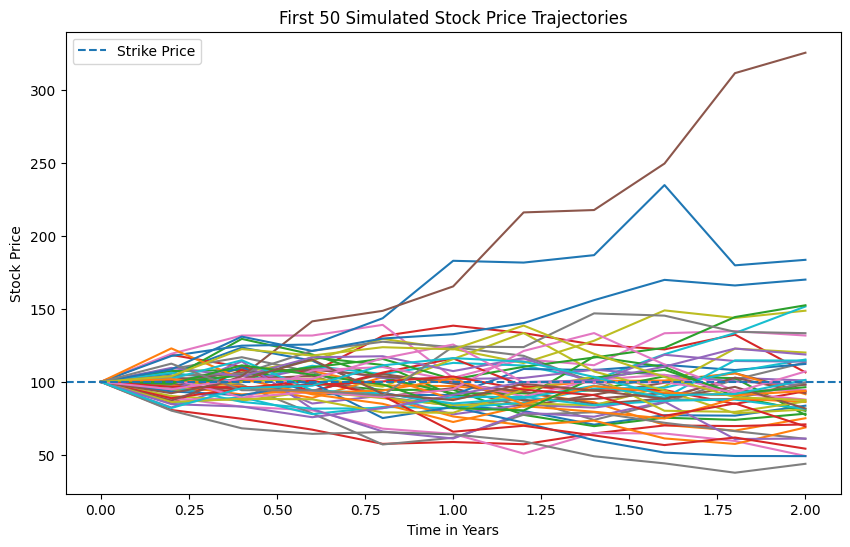

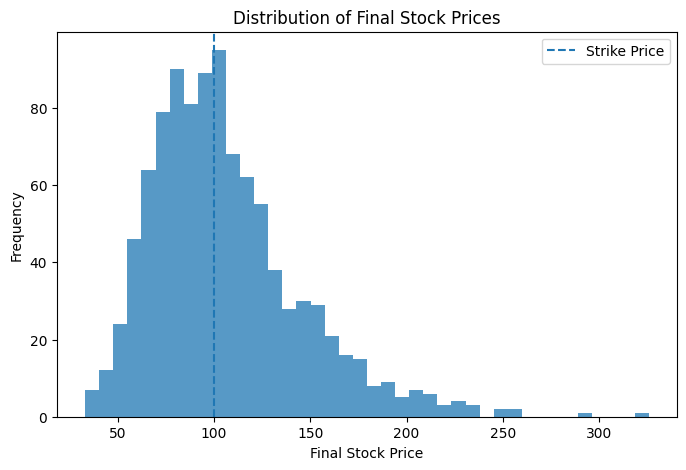

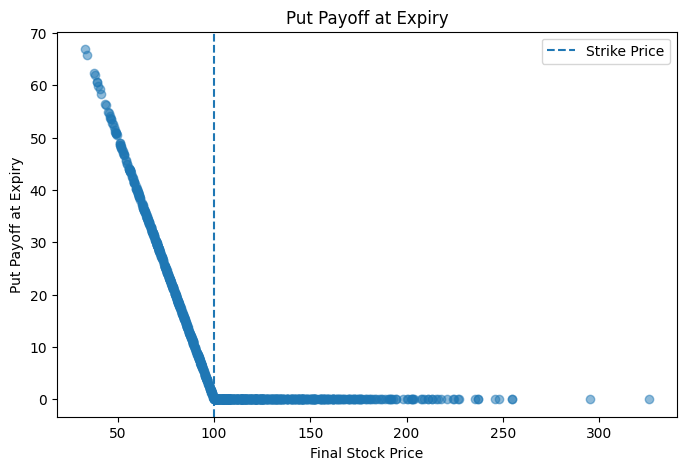

,Stock_Price_Time_9,Exercise_Value,Estimated_Continuation_Value,Decision
0,76.840916,23.159084,23.053728,Exercise
1,66.600003,33.399997,32.734751,Exercise
2,73.975340,26.024660,25.746927,Exercise
3,69.703146,30.296854,29.784797,Exercise
4,59.503545,40.496455,39.534690,Exercise
5,66.215940,33.784060,33.100849,Exercise
6,57.460930,42.539070,41.505834,Exercise
7,90.003047,9.996953,10.840180,Continue
8,84.877619,15.122381,15.565602,Continue
9,60.826009,39.173991,38.261808,Exercise


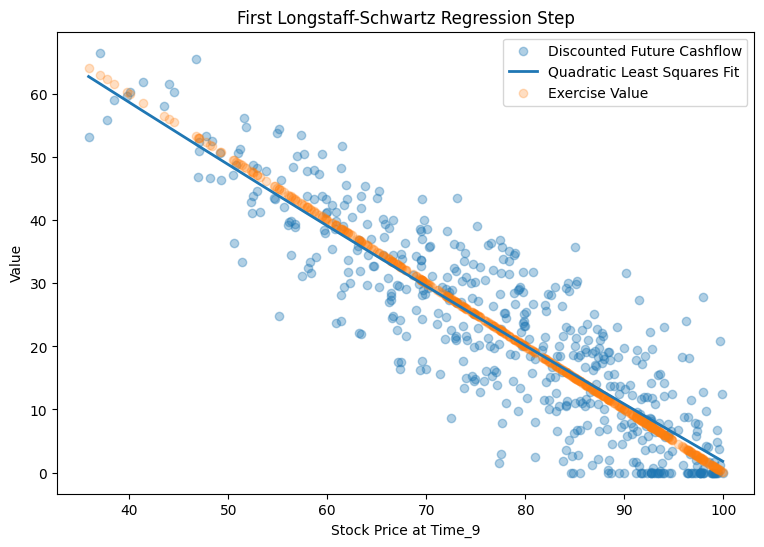

Selected option:
Option_ID                         3
Option_Type            American Put
Initial_Stock_Price             100
Strike                          100
Volatility                     0.25
Risk_Free_Rate                 0.03
Maturity_Years                    2
Name: 2, dtype: object

Number of simulated paths: 1000
Number of intermediate exercise points: 10
Time step dt: 0.2
Regression step shown: Time_9 back from expiry Time_10
Polynomial regression used: quadratic


In [3]:
#### INITIAL STAGE - TEACHING/SANITY PHASE - Check whether the simulated data looks sensible ####

### SUMMARY STATISTICS

# Summarises:
# - the spread of final stock prices
# - the average final stock price
# - the range of possible payoffs
# - how often the put ends up with value
df_summary_stats = df_paths[["Final_Stock_Price", "Put_Payoff_At_Expiry"]].describe()
display(df_summary_stats)

### PLOT 50 TRAJECTORIES

# Should see random stock movements around the initial price. Some paths go up, some go down
# For a put option, paths below the strike are especially important
time_grid = np.linspace(0, T, n_steps + 1)
plt.figure(figsize=(10, 6))

for i in range(50):
    plt.plot(time_grid, paths[i])

plt.axhline(K, linestyle="--", label="Strike Price")
plt.title("First 50 Simulated Stock Price Trajectories")
plt.xlabel("Time in Years")
plt.ylabel("Stock Price")
plt.legend()
plt.show()

### HISTOGRAM OF FINAL STOCK PRICES

# Shows the distribution of possible final stock prices. For a put option, the area to the left of the strike
# is vital, as those are the paths where the option finishes in the money
plt.figure(figsize=(8, 5))
plt.hist(df_paths["Final_Stock_Price"], bins=40, alpha=0.75)
plt.axvline(K, linestyle="--", label="Strike Price")
plt.title("Distribution of Final Stock Prices")
plt.xlabel("Final Stock Price")
plt.ylabel("Frequency")
plt.legend()
plt.show()

### PLOT FINAL STOCK PRICE VS PUT PAYOFF - shows when the put option has value at expiry

# If final stock price < strike, the put is in the money
# If final stock price >= strike, payoff is zero

# This plot should form standard put payoff shape
plt.figure(figsize=(8, 5))
plt.scatter(df_paths["Final_Stock_Price"], df_paths["Put_Payoff_At_Expiry"], alpha=0.5)
plt.axvline(K, linestyle="--", label="Strike Price")
plt.title("Put Payoff at Expiry")
plt.xlabel("Final Stock Price")
plt.ylabel("Put Payoff at Expiry")
plt.legend()
plt.show()

### FIRST LONGSTAFF-SCHWARTZ REGRESSION STEP - not the full method yet

# Only shows the first backward step: from expiry Time_10 back to Time_9
# At Time_9, for paths that are in the money:
# - Exercise value = K - S(Time_9)
# - Continuation value = estimated discounted payoff from waiting
# Fit continuation value ≈ a + bS + cS^2 using least squares polynomial regression

# Discount factor converts one step future value back to present value at Time_9
discount_factor = np.exp(-r * dt)

# Time_10 is expiry, so the first backward step is Time_9
t = n_steps - 1

# Stock price at Time_9 for every simulated path
S_t = df_paths[f"Time_{t}"].values

# Immediate exercise value at Time_9
exercise_value = np.maximum(K - S_t, 0)

# Future cashflow if the option is held until expiry
future_cashflow = df_paths["Put_Payoff_At_Expiry"].values

# Discount the expiry payoff back one step to Time_9
discounted_future_cashflow = future_cashflow * discount_factor

# Longstaff-Schwartz regression is done only on in-the-money paths here
# If the put is out of the money, there is no reason to exercise immediately
in_the_money = exercise_value > 0

# Keep only in-the-money paths for the regression
S_itm = S_t[in_the_money]
exercise_itm = exercise_value[in_the_money]
continuation_target_itm = discounted_future_cashflow[in_the_money]

# Polynomial regression basis: [1, S, S^2]
# This means the fitted continuation value has the form: a + bS + cS^2
X = np.column_stack([np.ones(len(S_itm)), S_itm, S_itm**2])

# Least squares finds the coefficients a, b, c that best fit the continuation value data
coefficients, *_ = np.linalg.lstsq(X, continuation_target_itm, rcond=None)

# Estimated continuation value from the fitted quadratic regression
estimated_continuation_value = X @ coefficients

# Longstaff-Schwartz decision: Exercise if immediate exercise value is greater than estimated continuation value
exercise_now = exercise_itm > estimated_continuation_value

# Create dataframe showing this first backward decision step
df_lsm_step = pd.DataFrame({
    "Stock_Price_Time_9": S_itm,
    "Exercise_Value": exercise_itm,
    "Estimated_Continuation_Value": estimated_continuation_value,
    "Decision": np.where(exercise_now, "Exercise", "Continue")
})
display(df_lsm_step.head(20))

### VISUALISE FIRST REGRESSION STEP - shows whether the polynomial fit is representing the data sensibly

# The scatter points are the observed discounted future cashflows
# The line is the quadratic least squares fit
# The exercise value points show what would be received by exercising immediately
sort_index = np.argsort(S_itm)
plt.figure(figsize=(9, 6))
plt.scatter(S_itm, continuation_target_itm, alpha=0.35, label="Discounted Future Cashflow")
plt.plot(S_itm[sort_index], estimated_continuation_value[sort_index], linewidth=2, label="Quadratic Least Squares Fit")
plt.scatter(S_itm, exercise_itm, alpha=0.25, label="Exercise Value")
plt.title("First Longstaff-Schwartz Regression Step")
plt.xlabel("Stock Price at Time_9")
plt.ylabel("Value")
plt.legend()
plt.show()

### SIMPLE SUMMARY OUTPUT

print("Selected option:")
print(selected_option)

print("\nNumber of simulated paths:", n_paths)
print("Number of intermediate exercise points:", n_intermediate_points)
print("Time step dt:", dt)
print("Regression step shown: Time_9 back from expiry Time_10")
print("Polynomial regression used: quadratic")

Estimated American Put Price using Longstaff-Schwartz:
11.2486

Discounting validation check:
Price from backward cashflow recursion: 11.2485901663
Price from stored exercise times: 11.2485901663
Absolute difference: 1.7763568394002505e-15
Discounting calculations agree: True


,Time_Index,Time_Years,Number_In_The_Money,Number_Exercise_Decisions,Exercise_Boundary,Estimated_Option_Value_Mean
0,1,0.2,490,7,77.289459,11.316285
1,2,0.4,478,24,73.284548,11.375994
2,3,0.6,493,68,76.767974,11.402414
3,4,0.8,499,96,76.826494,11.308553
4,5,1.0,501,118,77.146494,11.411772
5,6,1.2,509,120,74.987646,11.547452
6,7,1.4,508,159,73.535404,11.711241
7,8,1.6,508,235,79.141755,11.768919
8,9,1.8,510,238,78.471539,11.747120


,Path_ID,Exercise_Time_Index,Exercise_Time_Years,Exercise_Stock_Price,Cashflow_At_Exercise,Present_Value_At_Time_0,Final_Stock_Price,Final_Payoff,Final_Cashflow_Used_In_Pricing
0,1,7,1.4,70.678628,29.321372,28.115377,83.685174,16.314826,28.284577
1,2,8,1.6,70.475450,29.524550,28.140846,75.073363,24.926637,28.310198
2,3,7,1.4,69.657676,30.342324,29.094337,78.197449,21.802551,29.269428
3,4,10,2.0,106.538694,0.000000,0.000000,106.538694,0.000000,0.000000
4,5,10,2.0,100.970211,0.000000,0.000000,100.970211,0.000000,0.000000
5,6,10,2.0,93.115413,6.884587,6.483660,93.115413,6.884587,6.522679
6,7,10,2.0,131.794107,0.000000,0.000000,131.794107,0.000000,0.000000
7,8,10,2.0,113.334528,0.000000,0.000000,113.334528,0.000000,0.000000
8,9,10,2.0,148.822508,0.000000,0.000000,148.822508,0.000000,0.000000
9,10,10,2.0,151.723895,0.000000,0.000000,151.723895,0.000000,0.000000


,Exercise_Time_Index,Final_Number_Of_Paths,Exercise_Time_Years,Time_Description
0,1,7,0.2,Early Exercise
1,2,21,0.4,Early Exercise
2,3,48,0.6,Early Exercise
3,4,55,0.8,Early Exercise
4,5,53,1.0,Early Exercise
5,6,31,1.2,Early Exercise
6,7,31,1.4,Early Exercise
7,8,57,1.6,Early Exercise
8,9,29,1.8,Early Exercise
9,10,668,2.0,Expiry or Expired Worthless


,Path_Index,Stock_Price_Time_9,Exercise_Value,Discounted_Future_Cashflow_Target,Estimated_Continuation_Value,Decision
0,1,76.840916,23.159084,16.217230,23.053728,Exercise
1,2,66.600003,33.399997,24.777525,32.734751,Exercise
2,3,73.975340,26.024660,21.672128,25.746927,Exercise
3,14,69.703146,30.296854,28.970848,29.784797,Exercise
4,17,59.503545,40.496455,50.508026,39.534690,Exercise
5,18,66.215940,33.784060,38.787885,33.100849,Exercise
6,22,57.460930,42.539070,31.051724,41.505834,Exercise
7,23,90.003047,9.996953,19.738459,10.840180,Continue
8,24,84.877619,15.122381,6.321193,15.565602,Continue
9,25,60.826009,39.173991,38.634264,38.261808,Exercise


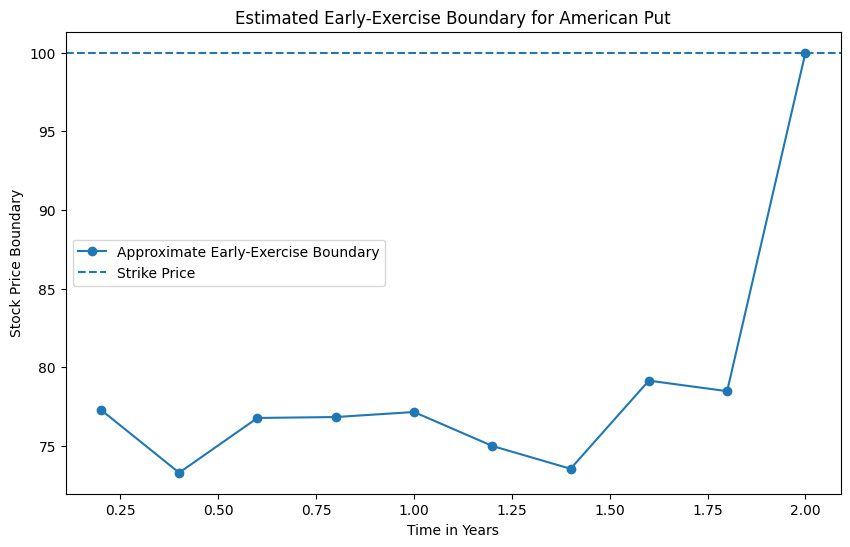

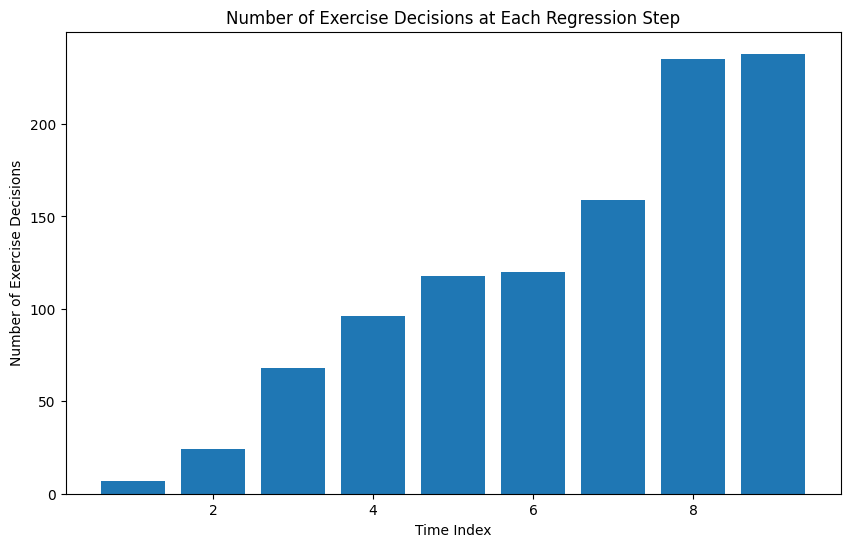

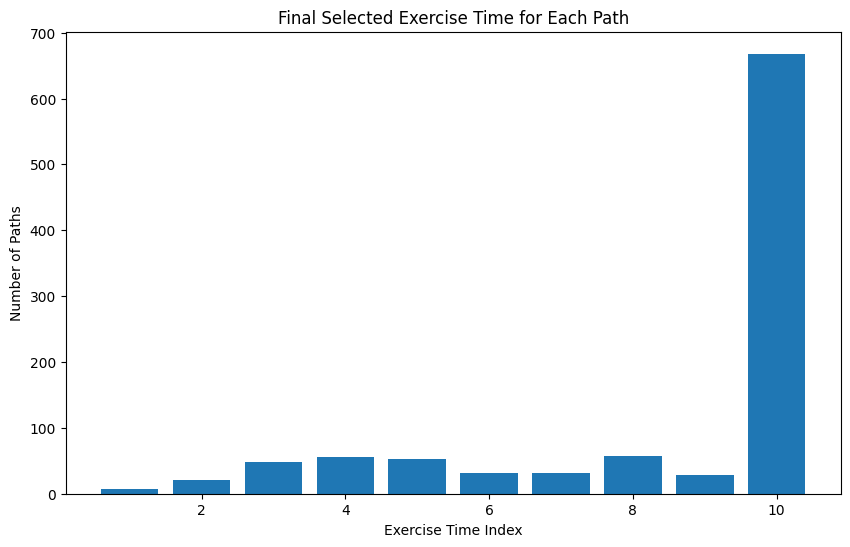

Longstaff-Schwartz full backward induction completed
Regression used: quadratic polynomial
Estimated American put price: 11.2486
Estimated continuation value at Time_0: 11.2486
Immediate exercise value at Time_0: 0
Number of simulated paths: 1000
Number of intermediate exercise points: 10
Number of time intervals: 10
Number of early-exercise decision dates: 9
First backward regression step: Time_10 to Time_9
Discounting validation difference: 1.7763568394002505e-15


In [4]:
#### PART 1 - FULL LONGSTAFF-SCHWARTZ IMPLEMENTATION ####

# Goal:
# 1. Use the simulated paths already generated in the initial stage
# 2. Work backwards from expiry to the start
# 3. Estimate continuation value at every time step using regression
# 4. Decide whether to exercise or continue at each step
# 5. Calculate the American put option price
# 6. Estimate and plot the early-exercise boundary

# Important:
# - It uses the same simulated paths in df_paths
# - It still uses a quadratic polynomial regression
# - This is the full Longstaff-Schwartz backward induction
# - This block contains the actual full pricing method

### INITIALISE CASHFLOWS AT EXPIRY

# At expiry, there is no decision left. The option value is simply the payoff: max(K - S, 0)
# This is the starting cashflow to work backwards from
cashflows = df_paths["Put_Payoff_At_Expiry"].values.copy()

# Stores the time at which each path's final selected cashflow occurs
# Initially, assume every path reaches expiry. Some paths will have a positive payoff at expiry
# Other paths will expire worthless. If the algorithm decides to exercise earlier, this value will be updated
exercise_time = np.full(n_paths, n_steps, dtype=int)

# This stores the stock price at which each path's final cashflow occurs
# Initially, this is the stock price at expiry. If early exercise is selected, it will be replaced by the earlier stock price
exercise_stock_price = df_paths[f"Time_{n_steps}"].values.copy()

# Stores estimated early-exercise boundary values
# For a put option, the boundary is about the highest stock price at which the current regression chooses exercise
## Important:
# This is currently a sample-based approximation of the boundary
# It is not yet the exact intersection between the exercise-value curve and the fitted continuation-value curve
exercise_boundary = np.full(n_steps + 1, np.nan)

# At maturity, the exercise boundary for a put is the strike price
# The put has a positive payoff whenever the final stock price is below K
exercise_boundary[n_steps] = K

# Stores summary of each backward regression step
lsm_summary_rows = []

# This dictionary will store detailed decision dataframes for each time step
## Example:
# When n_steps = 10: lsm_decision_tables[9] gives the exercise/continue decision table at Time_9.
# When n_steps = 50: lsm_decision_tables[49] gives the first backward decision table at Time_49.
lsm_decision_tables = {}


### WORK BACKWARDS THROUGH TIME

# Longstaff-Schwartz works backwards
# When n_steps = 10: Time_10 -> Time_9 -> Time_8 -> ... -> Time_1

# At each time step:
# 1. Calculate immediate exercise value
# 2. Discount the currently selected future cashflow back one step
# 3. Estimate continuation value using regression
# 4. Compare exercise vs continue
# 5. Update cashflows where early exercise is optimal

for t in range(n_steps - 1, 0, -1):
    S_t = df_paths[f"Time_{t}"].values   #Stock price at current time t
    exercise_value = np.maximum(K - S_t, 0)   #Immediate exercise value for an American put: max(K - S_t, 0)
    in_the_money = exercise_value > 0   #Only paths that are currently in the money are used in regression
    # If the put is out of the money, exercise value is zero, so it would not make sense to exercise immediately
    
    discounted_cashflows = cashflows * np.exp(-r * dt)   #Discount existing future cashflows back one time step
    # At the beginning of this iteration, cashflows represent values at Time_(t+1)
    # Multiplying by exp(-r * dt) converts them into values at Time_t

    # If there are no in-the-money paths at this time, skip regression
    if np.sum(in_the_money) == 0:
        cashflows = discounted_cashflows   #All paths continue, so use the one-step discounted cashflows
        lsm_summary_rows.append({
            "Time_Index": t,
            "Time_Years": t * dt,
            "Number_In_The_Money": 0,
            "Number_Exercise_Decisions": 0,   #This records exercise decisions made during this regression step
            # It is not necessarily the final number of paths exercised at this time
            "Exercise_Boundary": np.nan, 
            "Estimated_Option_Value_Mean": np.mean(cashflows)
        })
        continue

    # Keep only in-the-money observations for regression
    S_itm = S_t[in_the_money]
    exercise_itm = exercise_value[in_the_money]
    continuation_target_itm = discounted_cashflows[in_the_money]

    ## QUADRATIC POLYNOMIAL REGRESSION

    # Continuation value ≈ a + bS + cS^2
    # Same idea as the one-step teaching example, but now it is repeated at every time point
    X = np.column_stack([np.ones(len(S_itm)), S_itm, S_itm**2])
    coefficients, *_ = np.linalg.lstsq(X, continuation_target_itm, rcond=None)
    estimated_continuation_value = X @ coefficients

    # Decide whether to exercise now - exercise if: immediate exercise value > estimated continuation value
    exercise_now_itm = exercise_itm > estimated_continuation_value

    # Convert the in-the-money positions back to the full path index
    itm_indices = np.where(in_the_money)[0]
    exercise_indices = itm_indices[exercise_now_itm]

    ## UPDATE CASHFLOWS

    # First assume all paths continue, so cashflows are discounted from Time_(t+1) to Time_t
    cashflows = discounted_cashflows.copy()

    # For paths where exercise is optimal, replace the discounted future cashflow with the immediate exercise value at Time_t
    cashflows[exercise_indices] = exercise_value[exercise_indices]

    # Update the selected exercise time and stock price for paths where model chooses exercise at current time
    # As loop works backwards, an earlier exercise decision replaces any later exercise decision previously stored
    exercise_time[exercise_indices] = t
    exercise_stock_price[exercise_indices] = S_t[exercise_indices]

    ## ESTIMATE EARLY-EXERCISE BOUNDARY

    # For a put option, early exercise usually happens when the stock price is sufficiently low
    # The current simple boundary estimate: highest stock price among the simulated paths where exercise is chosen
    # This is useful for the initial project stage, but it remains an approximate sample-based boundary
    if len(exercise_indices) > 0:
        exercise_boundary[t] = np.max(S_t[exercise_indices])
    else:
        exercise_boundary[t] = np.nan

    ## STORE DETAILED DECISION DATA FOR THIS TIME STEP

    df_decision_t = pd.DataFrame({
        "Path_Index": itm_indices + 1,
        f"Stock_Price_Time_{t}": S_itm,
        "Exercise_Value": exercise_itm,
        "Discounted_Future_Cashflow_Target": continuation_target_itm,
        "Estimated_Continuation_Value": estimated_continuation_value,
        "Decision": np.where(exercise_now_itm, "Exercise", "Continue")
    })
    lsm_decision_tables[t] = df_decision_t

    # Store summary row for this time step
    lsm_summary_rows.append({
        "Time_Index": t,
        "Time_Years": t * dt,
        "Number_In_The_Money": int(np.sum(in_the_money)),
        # This is the number classified as exercise during this backward regression step
        "Number_Exercise_Decisions": int(len(exercise_indices)),
        "Exercise_Boundary": exercise_boundary[t],
        # At the end of this iteration, cashflows are expressed in value terms at Time_t
        "Estimated_Option_Value_Mean": np.mean(cashflows)
    })

### ESTIMATE AMERICAN PUT PRICE TODAY

# After working backwards from expiry to Time_1, cashflows currently represent path values at Time_1
# Discount them one final step from Time_1 to Time_0
continuation_value_time_0 = (np.mean(cashflows) * np.exp(-r * dt))

# An American option can also be exercised immediately at Time_0
immediate_exercise_value_time_0 = max(K - S0, 0)

# The American put value today is the greater of the immediate exercise value or the estimated continuation value
american_put_price = max(immediate_exercise_value_time_0, continuation_value_time_0)
print("Estimated American Put Price using Longstaff-Schwartz:")
print(round(american_put_price, 4))

### INDEPENDENT CASHFLOW AND DISCOUNTING CHECK

# Calculate the actual payoff associated with each path's final selected exercise time and exercise stock price
cashflow_at_exercise = np.maximum(K - exercise_stock_price, 0)

# Convert the selected exercise time index into years
exercise_time_years = exercise_time * dt

# Discount each selected path cashflow directly from its exercise time back to Time_0
present_value_at_time_0 = (cashflow_at_exercise * np.exp(-r * exercise_time_years))

# This independently calculates the continuation value at Time_0 using the stored exercise decisions
price_from_exercise_times = np.mean(present_value_at_time_0)

# This is the price calculated using the recursive backward-discounting method
price_from_backward_loop = continuation_value_time_0

# These two continuation-value calculations should be equal, apart from tiny numerical differences
discounting_check_difference = abs(price_from_backward_loop - price_from_exercise_times)

print("\nDiscounting validation check:")
print("Price from backward cashflow recursion:", round(price_from_backward_loop, 10))
print("Price from stored exercise times:", round(price_from_exercise_times, 10))
print("Absolute difference:", discounting_check_difference)
print("Discounting calculations agree:", np.isclose(price_from_backward_loop, price_from_exercise_times, rtol=1e-10, atol=1e-10))

### CREATE SUMMARY DATAFRAMES

df_lsm_summary = pd.DataFrame(lsm_summary_rows)
# Since we worked backwards, sort by time so it reads naturally
df_lsm_summary = (df_lsm_summary.sort_values("Time_Index").reset_index(drop=True))
display(df_lsm_summary)

# Create the path-level exercise-results dataframe
df_exercise_results = pd.DataFrame({
    "Path_ID": np.arange(1, n_paths + 1),
    "Exercise_Time_Index": exercise_time,
    "Exercise_Time_Years": exercise_time_years,
    "Exercise_Stock_Price": exercise_stock_price,
    "Cashflow_At_Exercise": cashflow_at_exercise,
    "Present_Value_At_Time_0": present_value_at_time_0,
    "Final_Stock_Price": df_paths[f"Time_{n_steps}"].values,
    "Final_Payoff": df_paths["Put_Payoff_At_Expiry"].values,
    # This represents the recursively discounted cashflow at Time_1 after completion of the backward loop
    "Final_Cashflow_Used_In_Pricing": cashflows
})
display(df_exercise_results.head(20))


### CREATE FINAL EXERCISE-TIME COUNTS

# Number_Exercise_Decisions values stored during the backward loop describe decisions made during each regression step
# exercise_time array contains each path's final selected stopping time after entire backward induction finishes
df_final_exercise_counts = (
    pd.Series(exercise_time, name="Exercise_Time_Index")
    .value_counts()
    .sort_index()
    .rename_axis("Exercise_Time_Index")
    .reset_index(name="Final_Number_Of_Paths")
)

# Add the corresponding time in years
df_final_exercise_counts["Exercise_Time_Years"] = (df_final_exercise_counts["Exercise_Time_Index"] * dt)

# Add label showing whether the terminal paths produced a positive payoff or may simply have expired worthless
df_final_exercise_counts["Time_Description"] = np.where(
    df_final_exercise_counts["Exercise_Time_Index"] == n_steps, "Expiry or Expired Worthless", "Early Exercise"
)
display(df_final_exercise_counts)


### DISPLAY VISUALS

#shows one decision table
# Shows the same type of table as before, but now taken from the full backward algorithm
# The first backward regression step is always: Time_(n_steps - 1) back from Time_n_steps
first_backward_time = n_steps - 1
display(lsm_decision_tables[first_backward_time].head(20))

# Plot early-exercise boundary
# The early-exercise boundary is the main object of interest
# For a put option:
# - below the boundary, exercise is more likely
# - above the boundary, continuation is more likely
# This boundary is approximate because it is currently estimated as the max simulated stock price classified as exercise
plt.figure(figsize=(10, 6))
plt.plot(time_grid, exercise_boundary, marker="o", label="Approximate Early-Exercise Boundary")
plt.axhline(K, linestyle="--", label="Strike Price")
plt.title("Estimated Early-Exercise Boundary for American Put")
plt.xlabel("Time in Years")
plt.ylabel("Stock Price Boundary")
plt.legend()
plt.show()

# Plot number of exercise decisions at each regression step
# These values show how many paths were classified as exercise during each backward regression step
# They're not necessarily the final exercise-time counts, because an earlier exercise decision can replace a later one
plt.figure(figsize=(10, 6))
plt.bar(df_lsm_summary["Time_Index"], df_lsm_summary["Number_Exercise_Decisions"])
plt.title("Number of Exercise Decisions at Each Regression Step")
plt.xlabel("Time Index")
plt.ylabel("Number of Exercise Decisions")
plt.show()

# Plot final selected exercise time
# Uses the final exercise_time value stored for every path after the complete backward induction has finished
plt.figure(figsize=(10, 6))
plt.bar(df_final_exercise_counts["Exercise_Time_Index"], df_final_exercise_counts["Final_Number_Of_Paths"])
plt.title("Final Selected Exercise Time for Each Path")
plt.xlabel("Exercise Time Index")
plt.ylabel("Number of Paths")
plt.show()

# Summary Output
print("Longstaff-Schwartz full backward induction completed")
print("Regression used: quadratic polynomial")
print("Estimated American put price:", round(american_put_price, 4))
print("Estimated continuation value at Time_0:", round(continuation_value_time_0, 4))
print("Immediate exercise value at Time_0:", round(immediate_exercise_value_time_0, 4))
print("Number of simulated paths:", n_paths)
print("Number of intermediate exercise points:", n_intermediate_points)
print("Number of time intervals:", n_steps)
print("Number of early-exercise decision dates:", n_steps - 1)
print(f"First backward regression step: Time_{n_steps} to Time_{n_steps - 1}")
print("Discounting validation difference:", discounting_check_difference)

In [5]:
#### PART 1 VALIDATION - VALIDATE THE CURRENT LONGSTAFF-SCHWARTZ IMPLEMENTATION ####

# Goal:
# 1. Confirm that the simulated stock paths behave sensibly
# 2. Confirm that cashflows have been discounted correctly
# 3. Compare the Longstaff-Schwartz price with a European put
# 4. Compare the Longstaff-Schwartz price with an American put price from a Cox-Ross-Rubinstein binomial tree
# 5. Check that stored exercise times and cashflows are valid

### ENSURE MATURITY BOUNDARY IS STORED CORRECTLY

# Create the boundary array only if it does not already exist or if it has an incorrect length
if ("exercise_boundary" not in globals() or len(exercise_boundary) != n_steps + 1):
    exercise_boundary = np.full(n_steps + 1, np.nan)

# At maturity, the put exercise boundary equals strike as the option has a positive payoff whenever final stock price is below K
exercise_boundary[n_steps] = K

### BLACK-SCHOLES EUROPEAN PUT BENCHMARK

# An American put has all the rights of a European put plus the possibility of early exercise
# Therefore, the American put value should be at least as large as the corresponding European put value
# Small Monte Carlo or regression error can occasionally cause a simulated estimate to fall slightly below the benchmark

#Standard normal cumulative distribution function
def standard_normal_cdf(x):
    return 0.5 * (1.0 + erf(x / sqrt(2.0)))

#Calculate the Black-Scholes price of a European put option
#Assumptions:
# - No dividends
# - Constant risk-free rate and volatility
def black_scholes_european_put(S0, K, r, sigma, T):
    if S0 <= 0:
        raise ValueError("S0 must be greater than zero.")
    if K <= 0:
        raise ValueError("K must be greater than zero.")
    if sigma <= 0:
        raise ValueError("sigma must be greater than zero.")
    if T <= 0:
        raise ValueError("T must be greater than zero.")
    d1 = (log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * sqrt(T))
    d2 = d1 - sigma * sqrt(T)
    european_put_price = (K * exp(-r * T) * standard_normal_cdf(-d2) - S0 * standard_normal_cdf(-d1))
    return european_put_price

european_put_price = black_scholes_european_put(S0=S0, K=K, r=r, sigma=sigma, T=T)

### COX-ROSS-RUBINSTEIN AMERICAN PUT BENCHMARK

# The binomial tree provides a separate American-option pricing method against which the Longstaff-Schwartz estimate can be checked
# A large number of tree steps is used to create a stable benchmark

# Price an American put using a Cox-Ross-Rubinstein binomial tree
    # At every tree node, the method compares:
    # 1. Immediate exercise value
    # 2. Discounted continuation value
def crr_american_put(S0, K, r, sigma, T, tree_steps=2000):
    if tree_steps < 1:
        raise ValueError("tree_steps must be at least 1.")
    if S0 <= 0:
        raise ValueError("S0 must be greater than zero.")
    if K <= 0:
        raise ValueError("K must be greater than zero.")
    if sigma <= 0:
        raise ValueError("sigma must be greater than zero.")
    if T <= 0:
        raise ValueError("T must be greater than zero.")
    tree_dt = T / tree_steps
    
    # CRR upward and downward stock-price multipliers
    up_factor = np.exp(sigma * np.sqrt(tree_dt))
    down_factor = 1.0 / up_factor

    # Risk-neutral probability of an upward movement
    risk_neutral_probability = (np.exp(r * tree_dt) - down_factor) / (up_factor - down_factor)
    if not 0 <= risk_neutral_probability <= 1:
        raise ValueError("The CRR risk-neutral probability is outside [0, 1].")
    tree_discount_factor = np.exp(-r * tree_dt)

    # Stock prices at expiry
    number_of_up_moves = np.arange(tree_steps + 1)
    terminal_stock_prices = (S0 * up_factor**number_of_up_moves * down_factor**(tree_steps - number_of_up_moves))

    # Put values at expiry
    option_values = np.maximum(K - terminal_stock_prices, 0)

    # Work backwards through the tree
    for step in range(tree_steps - 1, -1, -1):
        # Discounted expected continuation value
        continuation_values = tree_discount_factor * (
            risk_neutral_probability * option_values[1:step + 2]
            + (1.0 - risk_neutral_probability) * option_values[0:step + 1]
        )

        # Stock prices at the current tree level
        number_of_up_moves = np.arange(step + 1)
        current_stock_prices = (S0 * up_factor**number_of_up_moves * down_factor**(step - number_of_up_moves))

        # Immediate exercise value at each node
        immediate_exercise_values = np.maximum(K - current_stock_prices, 0)

        # American option value is the better of exercise and continuation
        option_values = np.maximum(immediate_exercise_values, continuation_values)
    return float(option_values[0])

crr_tree_steps = 2000
crr_american_put_price = crr_american_put(S0=S0, K=K, r=r, sigma=sigma, T=T, tree_steps=crr_tree_steps)

### SIMULATED STOCK-PATH CHECK

# Under risk-neutral geometric Brownian motion: E[S_T] = S0 * exp(rT)
# The simulated mean will not be exactly equal to this value, but it should be reasonably close
theoretical_mean_final_stock_price = S0 * np.exp(r * T)
simulated_mean_final_stock_price = (df_paths[f"Time_{n_steps}"].mean())
final_stock_mean_difference = (simulated_mean_final_stock_price - theoretical_mean_final_stock_price)
final_stock_mean_relative_error = abs(final_stock_mean_difference) / theoretical_mean_final_stock_price

### MONTE CARLO STANDARD ERROR

# Standard error estimates how much the Longstaff-Schwartz price could vary because only a finite number of simulated paths were used
lsm_present_value_standard_deviation = np.std(present_value_at_time_0, ddof=1)
lsm_price_standard_error = (lsm_present_value_standard_deviation / np.sqrt(n_paths))

# The approximate 95% confidence interval describes the likely range of the estimate due to Monte Carlo path-sampling uncertainty
lsm_confidence_interval_lower = (price_from_exercise_times - 1.96 * lsm_price_standard_error)
lsm_confidence_interval_upper = (price_from_exercise_times + 1.96 * lsm_price_standard_error)

### PRICE COMPARISONS

american_minus_european = (american_put_price - european_put_price)
lsm_minus_crr = (american_put_price - crr_american_put_price)
absolute_lsm_crr_difference = abs(lsm_minus_crr)
percentage_lsm_crr_difference = (absolute_lsm_crr_difference / crr_american_put_price * 100)

### INTERNAL CONSISTENCY CHECKS

# Test 1 checks that every stored final exercise time occurs between the first possible exercise date and maturity
exercise_times_are_valid = np.all((exercise_time >= 1) & (exercise_time <= n_steps))

# Test 2 checks that every simulated path has exactly one final stopping-time record in the final exercise-count dataframe
exercise_count_total = int(df_final_exercise_counts["Final_Number_Of_Paths"].sum())
exercise_counts_match_paths = (exercise_count_total == n_paths)

# Test 3 checks that no option payoff is negative because a put payoff must always be zero or positive
cashflows_are_non_negative = np.all(cashflow_at_exercise >= 0)

# Test 4 checks that discounting has not produced any negative present values from otherwise valid non-negative put cashflows
present_values_are_non_negative = np.all(present_value_at_time_0 >= 0)

# Test 5 checks that the exercise boundary at maturity equals the strike, which is the point separating a positive payoff from a zero payoff
maturity_boundary_is_strike = np.isclose(exercise_boundary[n_steps], K)

# Test 6 checks that the American option is not valued below the amount that could be received by exercising immediately at Time 0
american_above_intrinsic = (american_put_price >= immediate_exercise_value_time_0)

# Test 7 checks that recursive one-step discounting gives the same result as directly discounting each selected exercise payoff back to Time 0
discounting_methods_agree = np.isclose(price_from_backward_loop, price_from_exercise_times, rtol=1e-10, atol=1e-10)

# Test 8 checks that the American put estimate is not materially below the European put value after allowing for Monte Carlo uncertainty
american_above_european_with_tolerance = (american_put_price + 2 * lsm_price_standard_error >= european_put_price)

# Test 9 creates a reasonable comparison tolerance for the difference between the simulation-based LSM price and the CRR benchmark
crr_comparison_tolerance = max(3 * lsm_price_standard_error,0.25) 

# Test 10 checks whether the LSM estimate is reasonably close to an independently calculated American put price from the CRR tree
lsm_close_to_crr = (absolute_lsm_crr_difference <= crr_comparison_tolerance)

# Test 11 checks whether the simulated average terminal stock price is within 5% of its theoretical risk-neutral expected value
simulated_terminal_mean_is_reasonable = (final_stock_mean_relative_error <= 0.05)

### CREATE PRICE-COMPARISON TABLE

# This table compares the European benchmark, the LSM estimate, and the independent American put benchmark from the CRR tree
df_price_validation = pd.DataFrame({
    "Pricing_Method": [
        "European Put - Black-Scholes",
        "American Put - Longstaff-Schwartz",
        f"American Put - CRR Tree ({crr_tree_steps} steps)"
    ],
    "Estimated_Price": [
        european_put_price,
        american_put_price,
        crr_american_put_price
    ]
})
df_price_validation["Difference_From_LSM"] = (df_price_validation["Estimated_Price"] - american_put_price)
display(df_price_validation.round(6))

### CREATE VALIDATION-CHECK TABLE

validation_results = [
    # This test confirms that the two independent discounting calculations produce the same Time-0 value
    {
        "Validation_Check": "Backward discounting matches exercise-time discounting",
        "Result": "PASS" if discounting_methods_agree else "FAIL",
        "Observed_Value": discounting_check_difference,
        "Expected": "Difference approximately zero"
    },
    # This test confirms that the model never values the option below the amount available from immediate exercise
    {
        "Validation_Check": "American price is at least immediate exercise value",
        "Result": "PASS" if american_above_intrinsic else "FAIL",
        "Observed_Value": american_put_price - immediate_exercise_value_time_0,
        "Expected": "Difference greater than or equal to zero"
    },
    # This test confirms that the American put is not materially below the corresponding European put benchmark
    {
        "Validation_Check": "American price is not materially below European price",
        "Result": ("PASS" if american_above_european_with_tolerance else "CHECK"),
        "Observed_Value": american_minus_european,
        "Expected": "Normally greater than or equal to zero"
    },
    # This test checks whether the LSM estimate is reasonably close to an independently calculated American put price
    {
        "Validation_Check": "Longstaff-Schwartz is reasonably close to CRR benchmark",
        "Result": "PASS" if lsm_close_to_crr else "CHECK", 
        "Observed_Value": absolute_lsm_crr_difference,
        "Expected":(f"Absolute difference no greater than {crr_comparison_tolerance:.6f}")
    },
    # This test checks that the simulated stock paths have an average terminal value close to the theoretical risk-neutral expectation
    {
        "Validation_Check": "Simulated terminal stock mean is sensible",
        "Result": ("PASS" if simulated_terminal_mean_is_reasonable else "CHECK"),
        "Observed_Value": final_stock_mean_relative_error,
        "Expected": "Relative error no greater than 5%"
    },
    # This test checks that no path has an impossible exercise time before Time 1 or after maturity
    {
        "Validation_Check": "Final exercise times are valid",
        "Result": "PASS" if exercise_times_are_valid else "FAIL",
        "Observed_Value": int(exercise_times_are_valid),
        "Expected": f"Every value between 1 and {n_steps}"
    },
    # This test checks that the final exercise-time table accounts for every simulated path exactly once
    {
        "Validation_Check": "Final exercise counts equal number of paths",
        "Result": "PASS" if exercise_counts_match_paths else "FAIL",
        "Observed_Value": exercise_count_total,
        "Expected": n_paths
    },
    # This test checks that all stored put payoffs are zero or positive
    {
        "Validation_Check": "Exercise cashflows are non-negative",
        "Result": "PASS" if cashflows_are_non_negative else "FAIL",
        "Observed_Value": float(np.min(cashflow_at_exercise)),
        "Expected": "Minimum greater than or equal to zero"
    },
    # This test checks that all discounted cashflows remain zero or positive after being brought back to Time 0
    {
        "Validation_Check": "Present values are non-negative",
        "Result": "PASS" if present_values_are_non_negative else "FAIL",
        "Observed_Value": float(np.min(present_value_at_time_0)),
        "Expected": "Minimum greater than or equal to zero"
    },
    # This test checks that the maturity exercise boundary equals K, which separates positive terminal put payoffs from zero payoffs
    {
        "Validation_Check": "Boundary at maturity equals strike",
        "Result": "PASS" if maturity_boundary_is_strike else "FAIL",
        "Observed_Value": exercise_boundary[n_steps],
        "Expected": K
    }
]
df_validation_checks = pd.DataFrame(validation_results)
display(df_validation_checks)

### PRINT VALIDATION SUMMARY

print("Longstaff-Schwartz Validation Summary:")

print("\nOption parameters:")
print("Initial stock price:", S0)
print("Strike price:", K)
print("Risk-free rate:", r)
print("Volatility:", sigma)
print("Maturity in years:", T)
print("Number of paths:", n_paths)
print("Number of time intervals:", n_steps)

print("\nPrice benchmarks:")
print("European Black-Scholes put:", round(european_put_price, 6))
print("American Longstaff-Schwartz put:", round(american_put_price, 6))
print(f"American CRR put ({crr_tree_steps} tree steps):", round(crr_american_put_price, 6))
print("American minus European:", round(american_minus_european, 6))
print("Longstaff-Schwartz minus CRR:", round(lsm_minus_crr, 6))
print("Absolute LSM-CRR difference:", round(absolute_lsm_crr_difference, 6))
print("Percentage LSM-CRR difference:", round(percentage_lsm_crr_difference, 4), "%")

print("\nMonte Carlo uncertainty:")
print("Estimated standard error:", round(lsm_price_standard_error, 6))
print("Approximate 95% confidence interval:", (round(lsm_confidence_interval_lower, 6), round(lsm_confidence_interval_upper, 6)))

print("\nStock-path validation:")
print("Theoretical mean final stock price:", round(theoretical_mean_final_stock_price, 6))
print("Simulated mean final stock price:", round(simulated_mean_final_stock_price, 6))
print("Relative error in final stock mean:", round(final_stock_mean_relative_error * 100, 4), "%")

print("\nInternal consistency:")
print("Discounting validation difference:", discounting_check_difference)
print("Final exercise counts:", exercise_count_total)
print("Expected number of paths:", n_paths)
print("Boundary at maturity:", exercise_boundary[n_steps])
print("Expected maturity boundary:", K)
      
number_of_failed_checks = int((df_validation_checks["Result"] == "FAIL").sum())
number_of_checks_to_review = int((df_validation_checks["Result"] == "CHECK").sum())
print("\nOverall validation result:")
if number_of_failed_checks == 0 and number_of_checks_to_review == 0:
    print("All checks passed. The current implementation is ready for the next convergence tests.")
elif number_of_failed_checks == 0:
    print("No structural checks failed, but one or more benchmark comparisons should be reviewed before scaling.")
else:
    print("At least one structural validation failed. Review the implementation before increasing paths or time steps.")

,Pricing_Method,Estimated_Price,Difference_From_LSM
0,European Put - Black-Scholes,10.904878,-0.343712
1,American Put - Longstaff-Schwartz,11.248590,0.000000
2,American Put - CRR Tree (2000 steps),11.545709,0.297119


,Validation_Check,Result,Observed_Value,Expected
0,Backward discounting matches exercise-time dis...,PASS,1.776357e-15,Difference approximately zero
1,American price is at least immediate exercise ...,PASS,1.124859e+01,Difference greater than or equal to zero
2,American price is not materially below Europea...,PASS,3.437122e-01,Normally greater than or equal to zero
3,Longstaff-Schwartz is reasonably close to CRR ...,PASS,2.971193e-01,Absolute difference no greater than 1.208943
4,Simulated terminal stock mean is sensible,PASS,1.437666e-03,Relative error no greater than 5%
5,Final exercise times are valid,PASS,1.000000e+00,Every value between 1 and 10
6,Final exercise counts equal number of paths,PASS,1.000000e+03,1000
7,Exercise cashflows are non-negative,PASS,0.000000e+00,Minimum greater than or equal to zero
8,Present values are non-negative,PASS,0.000000e+00,Minimum greater than or equal to zero
9,Boundary at maturity equals strike,PASS,1.000000e+02,100


Longstaff-Schwartz Validation Summary:

Option parameters:
Initial stock price: 100
Strike price: 100
Risk-free rate: 0.03
Volatility: 0.25
Maturity in years: 2
Number of paths: 1000
Number of time intervals: 10

Price benchmarks:
European Black-Scholes put: 10.904878
American Longstaff-Schwartz put: 11.24859
American CRR put (2000 tree steps): 11.545709
American minus European: 0.343712
Longstaff-Schwartz minus CRR: -0.297119
Absolute LSM-CRR difference: 0.297119
Percentage LSM-CRR difference: 2.5734 %

Monte Carlo uncertainty:
Estimated standard error: 0.402981
Approximate 95% confidence interval: (10.458747, 12.038433)

Stock-path validation:
Theoretical mean final stock price: 106.183655
Simulated mean final stock price: 106.030998
Relative error in final stock mean: 0.1438 %

Internal consistency:
Discounting validation difference: 1.7763568394002505e-15
Final exercise counts: 1000
Expected number of paths: 1000
Boundary at maturity: 100.0
Expected maturity boundary: 100

Overall 

## Part 2 - Regression Model Development and Selection

,Seed,Number_Of_Paths,Number_Of_Time_Intervals,LSM_Price,Independent_Price,Discounting_Difference,Path_Present_Value_SD,Number_Early_Exercised
0,1,500,10,11.839197,11.839197,1.776357e-15,12.853582,212
1,1,1000,10,11.497421,11.497421,0.000000e+00,12.349085,388
2,1,2000,10,11.429942,11.429942,0.000000e+00,13.434565,685
3,1,5000,10,11.635817,11.635817,1.776357e-15,13.186494,1774
4,1,10000,10,11.641485,11.641485,0.000000e+00,13.075598,3598
5,2,500,10,12.159662,12.159662,1.776357e-15,13.678067,137
6,2,1000,10,11.962871,11.962871,1.776357e-15,13.390241,291
7,2,2000,10,12.014229,12.014229,1.776357e-15,13.310749,696
8,2,5000,10,11.532960,11.532960,0.000000e+00,12.699946,1824
9,2,10000,10,11.480898,11.480898,0.000000e+00,12.815095,3721


,Number_Of_Paths,Mean_LSM_Price,Standard_Deviation_Across_Seeds,Standard_Error_Of_Mean,Confidence_Interval_Lower,Confidence_Interval_Upper,Difference_From_CRR,Absolute_Difference_From_CRR,Percentage_Difference_From_CRR,Minimum_LSM_Price,Maximum_LSM_Price,Mean_Early_Exercise_Percentage,Maximum_Discounting_Difference
0,500,11.822073,0.649819,0.205491,11.419311,12.224835,0.276363,0.276363,2.393645,10.794140,12.718689,34.700,0.0
1,1000,11.685914,0.337860,0.106841,11.476505,11.895322,0.140204,0.140204,1.214339,11.291770,12.160297,36.030,0.0
2,2000,11.550097,0.281432,0.088997,11.375664,11.724530,0.004388,0.004388,0.038002,11.000308,12.014229,36.410,0.0
3,5000,11.443672,0.190603,0.060274,11.325535,11.561809,-0.102038,0.102038,0.883771,11.115331,11.739467,36.278,0.0
4,10000,11.451844,0.100532,0.031791,11.389534,11.514155,-0.093865,0.093865,0.812989,11.341625,11.641485,36.077,0.0


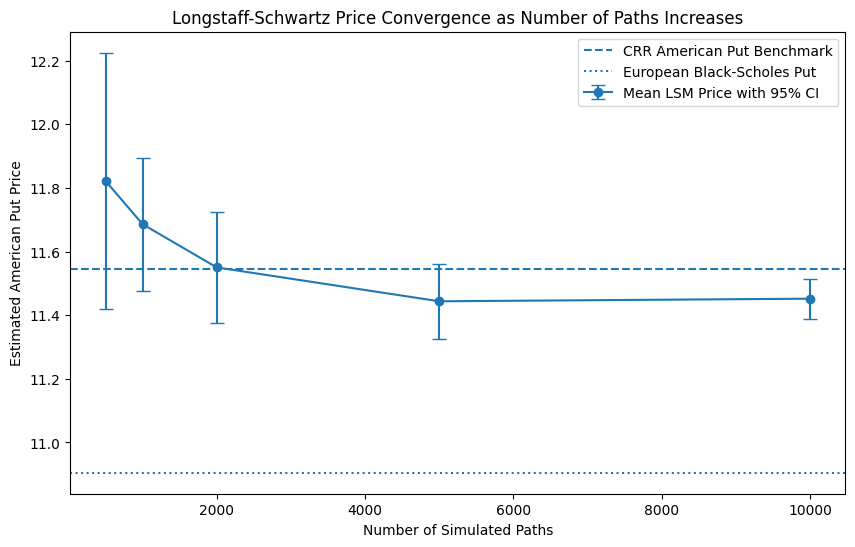

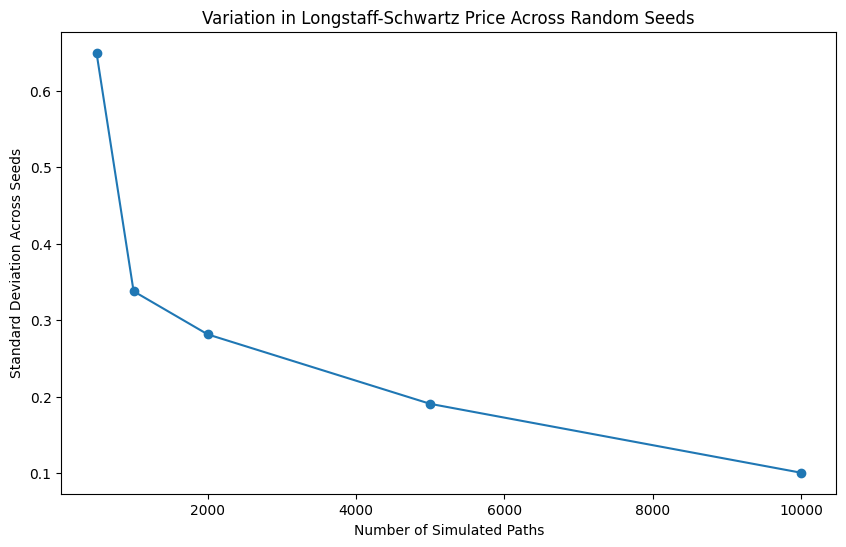

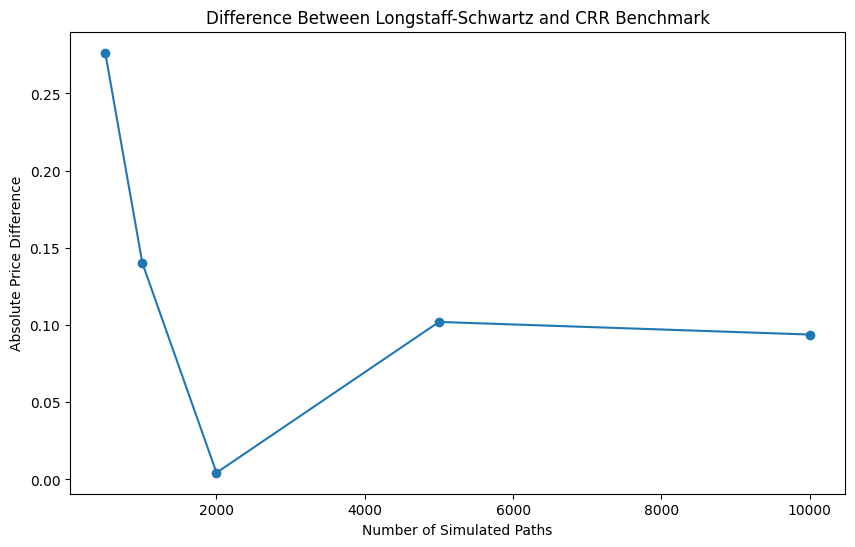

 Monte Carlo Path Convergence Summary: 

Experiment settings:
Path counts tested: [500, 1000, 2000, 5000, 10000]
Random seeds tested: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Number of time intervals held fixed: 10
Regression held fixed: quadratic
CRR American put benchmark: 11.545709

Internal consistency:
All discounting checks passed: True

Price variability:
Price SD with 500 paths: 0.649819
Price SD with 10000 paths: 0.100532
Variability lower at largest path count: True

Interpretation:
The path-convergence experiment behaves as expected. The pricing calculations remain internally consistent and estimates are more stable at the largest path count.


In [6]:
#### PART 2A - MONTE CARLO PATH CONVERGENCE ####

# Goal:
# 1. Test how the Longstaff-Schwartz price changes as the number of simulated paths increases
# 2. Measure variation across different random seeds
# 3. Check whether the estimated price becomes more stable
# 4. Compare each path count with the CRR American put benchmark

# Important:
# - Keep the number of time intervals fixed at the current value
# - Keep the quadratic regression fixed
# - Keep all option parameters fixed
# - Only the number of Monte Carlo paths changes

### EXPERIMENT SETTINGS

# Number of simulated paths to compare
path_counts = [500, 1000, 2000, 5000, 10000]

# Use several random seeds for each path count
# Multiple seeds are necessary because one simulation alone does not show whether the price estimate is stable
convergence_seeds = list(range(1, 11))

# Keep the number of time intervals fixed at its current value. At this stage, this is still be 10
convergence_n_steps = n_steps

# Store the maximum path count so that one large set of shocks can be generated for each seed and then sliced into smaller samples
maximum_path_count = max(path_counts)

### SIMULATE PATHS FROM STORED RANDOM SHOCKS

#Simulate risk-neutral geometric Brownian motion stock-price paths using a matrix of standard-normal random shocks
## Parameters:
# S0 : float - Initial stock price
# r : float - Risk-free interest rate
# sigma : float - Stock-price volatility
# T : float - Time to maturity in year
# random_shocks : numpy.ndarray - Matrix with shape: number of time steps x number of paths
## Returns: numpy.ndarray - Simulated stock paths with shape: number of paths x (number of time steps + 1)
def simulate_gbm_paths_from_shocks(S0, r, sigma, T, random_shocks):
    experiment_n_steps, experiment_n_paths = (random_shocks.shape)
    experiment_dt = T / experiment_n_steps
    simulated_paths = np.zeros((experiment_n_paths, experiment_n_steps + 1))
    simulated_paths[:, 0] = S0

    for t in range(1, experiment_n_steps + 1):
        Z_t = random_shocks[t - 1, :]
        simulated_paths[:, t] = (
            simulated_paths[:, t - 1] * np.exp((r - 0.5 * sigma**2) * experiment_dt + sigma * np.sqrt(experiment_dt) * Z_t)
        )
    return simulated_paths

### LONGSTAFF-SCHWARTZ PRICING FUNCTION

# Price an American put using the Longstaff-Schwartz method with quadratic polynomial regression
# The function returns only the quantities needed for the path-convergence experiment
def longstaff_schwartz_quadratic_price(simulated_paths, K, r, T):
    experiment_n_paths = simulated_paths.shape[0]
    experiment_n_steps = (simulated_paths.shape[1] - 1)
    experiment_dt = T / experiment_n_steps
    one_step_discount_factor = np.exp(-r * experiment_dt)
    #Initialise cashflows at maturity
    cashflows_experiment = np.maximum(K - simulated_paths[:, -1], 0)
    # Store the final selected exercise time for each path
    exercise_time_experiment = np.full(experiment_n_paths, experiment_n_steps, dtype=int)
    # Store the corresponding stock price
    exercise_stock_experiment = (simulated_paths[:, -1].copy())

    # Work backwards from the step immediately before expiry to the first possible exercise date
    for t in range(experiment_n_steps - 1, 0, -1):
        current_stock_prices = simulated_paths[:, t]
        immediate_exercise_values = np.maximum(K - current_stock_prices, 0)

        # Discount currently selected future cashflows back by one time interval
        discounted_cashflows_experiment = (cashflows_experiment * one_step_discount_factor)

        # If no paths are in the money, all paths continue
        in_the_money = (immediate_exercise_values > 0)
        if np.sum(in_the_money) == 0:
            cashflows_experiment = (discounted_cashflows_experiment)
            continue

        stock_prices_itm = (current_stock_prices[in_the_money])
        exercise_values_itm = (immediate_exercise_values[in_the_money])
        continuation_targets_itm = (discounted_cashflows_experiment[in_the_money])

        # Quadratic continuation-value regression: C(S) = a + bS + cS²
        regression_matrix = np.column_stack([np.ones(len(stock_prices_itm)), stock_prices_itm, stock_prices_itm**2])
        regression_coefficients, *_ = np.linalg.lstsq(regression_matrix, continuation_targets_itm, rcond=None)
        estimated_continuation_values = (regression_matrix @ regression_coefficients)
        exercise_now_itm = (exercise_values_itm > estimated_continuation_values)
        itm_indices = np.where(in_the_money)[0]
        exercise_indices = itm_indices[exercise_now_itm]

        # First assume every path continues
        cashflows_experiment = (discounted_cashflows_experiment.copy())

        # Replace the future value with immediate exercise value on paths where early exercise is selected
        cashflows_experiment[exercise_indices] = (immediate_exercise_values[exercise_indices])
        exercise_time_experiment[exercise_indices] = t
        exercise_stock_experiment[exercise_indices] = current_stock_prices[exercise_indices]

    # Discount from Time_1 to Time_0
    continuation_value_time_0_experiment = (np.mean(cashflows_experiment) * one_step_discount_factor)
    immediate_exercise_time_0_experiment = max(K - simulated_paths[0, 0], 0)
    estimated_price = max(immediate_exercise_time_0_experiment, continuation_value_time_0_experiment)

    # Independently calculate the present value using the final stored exercise decisions
    cashflow_at_exercise_experiment = np.maximum(K - exercise_stock_experiment, 0)
    present_values_experiment = (cashflow_at_exercise_experiment * np.exp(-r * exercise_time_experiment * experiment_dt))
    independent_price = np.mean(present_values_experiment)
    discounting_difference = abs(continuation_value_time_0_experiment - independent_price)

    return {
        "Price": estimated_price,
        "Independent_Price": independent_price,
        "Discounting_Difference": discounting_difference,
        "Present_Value_SD": np.std(present_values_experiment, ddof=1),
        "Number_Early_Exercised": int(np.sum(exercise_time_experiment < experiment_n_steps))
    }

### RUN THE PATH-CONVERGENCE EXPERIMENT

# Each row will store one combination of: random seed x number of paths
path_convergence_rows = []

# Generate one maximum-sized shock matrix for this seed
# Smaller path experiments use the first columns of this same matrix, so the path samples are nested
for seed in convergence_seeds:
    random_generator = np.random.default_rng(seed)
    maximum_random_shocks = (random_generator.standard_normal(size=(convergence_n_steps, maximum_path_count)))

    for experiment_n_paths in path_counts:
        # Use the first N paths from the maximum shock matrix
        experiment_shocks = maximum_random_shocks[:, :experiment_n_paths]
        experiment_paths = (simulate_gbm_paths_from_shocks(S0=S0, r=r, sigma=sigma, T=T, random_shocks=experiment_shocks))
        experiment_result = (longstaff_schwartz_quadratic_price(simulated_paths=experiment_paths, K=K, r=r, T=T))
        path_convergence_rows.append({
            "Seed": seed,
            "Number_Of_Paths": experiment_n_paths,
            "Number_Of_Time_Intervals": convergence_n_steps,
            "LSM_Price": experiment_result["Price"],
            "Independent_Price": experiment_result["Independent_Price"],
            "Discounting_Difference":experiment_result["Discounting_Difference"],
            "Path_Present_Value_SD":experiment_result["Present_Value_SD"],
            "Number_Early_Exercised":experiment_result["Number_Early_Exercised"]
        })

# Create the full seed-level result dataframe
df_path_convergence_all = pd.DataFrame(path_convergence_rows)
display(df_path_convergence_all.head(20))

### SUMMARISE RESULTS BY NUMBER OF PATHS

df_path_convergence_summary = (df_path_convergence_all.groupby("Number_Of_Paths").agg(
        Mean_LSM_Price=("LSM_Price", "mean"),
        Standard_Deviation_Across_Seeds=("LSM_Price", "std"),
        Minimum_LSM_Price=("LSM_Price", "min"),
        Maximum_LSM_Price=("LSM_Price", "max"),
        Maximum_Discounting_Difference=("Discounting_Difference", "max"),
        Mean_Number_Early_Exercised=("Number_Early_Exercised", "mean")
    ).reset_index())

# Standard error of the mean price across random seeds
df_path_convergence_summary["Standard_Error_Of_Mean"] = (
    df_path_convergence_summary["Standard_Deviation_Across_Seeds"] / np.sqrt(len(convergence_seeds))
)

# Approximate 95% confidence interval for the mean across seeds
df_path_convergence_summary["Confidence_Interval_Lower"] = (
    df_path_convergence_summary["Mean_LSM_Price"] - 1.96 * df_path_convergence_summary["Standard_Error_Of_Mean"]
)
df_path_convergence_summary["Confidence_Interval_Upper"] = (
    df_path_convergence_summary["Mean_LSM_Price"] + 1.96 * df_path_convergence_summary["Standard_Error_Of_Mean"]
)

# Compare the mean LSM price with the previously calculated CRR American put benchmark
df_path_convergence_summary["Difference_From_CRR"] = (df_path_convergence_summary["Mean_LSM_Price"] - crr_american_put_price)
df_path_convergence_summary["Absolute_Difference_From_CRR"] = abs(df_path_convergence_summary["Difference_From_CRR"])
df_path_convergence_summary["Percentage_Difference_From_CRR"] = (
    df_path_convergence_summary["Absolute_Difference_From_CRR"] / crr_american_put_price * 100
)

# Mean proportion of paths selected for early exercise
df_path_convergence_summary["Mean_Early_Exercise_Percentage"] = (
    df_path_convergence_summary["Mean_Number_Early_Exercised"] / df_path_convergence_summary["Number_Of_Paths"] * 100)

# Most important columns first
df_path_convergence_summary = (df_path_convergence_summary[[
            "Number_Of_Paths",
            "Mean_LSM_Price",
            "Standard_Deviation_Across_Seeds",
            "Standard_Error_Of_Mean",
            "Confidence_Interval_Lower",
            "Confidence_Interval_Upper",
            "Difference_From_CRR",
            "Absolute_Difference_From_CRR",
            "Percentage_Difference_From_CRR",
            "Minimum_LSM_Price",
            "Maximum_LSM_Price",
            "Mean_Early_Exercise_Percentage",
            "Maximum_Discounting_Difference"
        ]])
display(df_path_convergence_summary.round(6))

### PATH-CONVERGENCE CHECKS

# This check confirms that direct exercise-time discounting continues to match recursive discounting in every experiment
all_discounting_checks_pass = np.allclose(df_path_convergence_all["Discounting_Difference"], 0, rtol=1e-9, atol=1e-9)

# Compare variability at the smallest and largest path counts
smallest_path_price_sd = (df_path_convergence_summary.loc[
        df_path_convergence_summary["Number_Of_Paths"] == min(path_counts), "Standard_Deviation_Across_Seeds"].iloc[0]
)
largest_path_price_sd = (df_path_convergence_summary.loc[
        df_path_convergence_summary["Number_Of_Paths"] == max(path_counts), "Standard_Deviation_Across_Seeds"].iloc[0]
)

# The main convergence expectation is that estimates should generally become less variable as more paths are used
# It does not have to decrease perfectly at every path count
variability_reduced_at_largest_sample = (largest_path_price_sd < smallest_path_price_sd)

### DISPLAY VISUAL

# Plot mean price by number of paths
plt.figure(figsize=(10, 6))
plt.errorbar(df_path_convergence_summary["Number_Of_Paths"], df_path_convergence_summary["Mean_LSM_Price"],
    yerr=1.96 * df_path_convergence_summary["Standard_Error_Of_Mean"], marker="o", capsize=5, label="Mean LSM Price with 95% CI"
)
plt.axhline(crr_american_put_price, linestyle="--", label="CRR American Put Benchmark")
plt.axhline(european_put_price, linestyle=":", label="European Black-Scholes Put")
plt.title("Longstaff-Schwartz Price Convergence as Number of Paths Increases")
plt.xlabel("Number of Simulated Paths")
plt.ylabel("Estimated American Put Price")
plt.legend()
plt.show()

# Plot price variability by number of paths
plt.figure(figsize=(10, 6))
plt.plot(df_path_convergence_summary["Number_Of_Paths"], df_path_convergence_summary["Standard_Deviation_Across_Seeds"], marker="o")
plt.title("Variation in Longstaff-Schwartz Price Across Random Seeds")
plt.xlabel("Number of Simulated Paths")
plt.ylabel("Standard Deviation Across Seeds")
plt.show()

# Plot absolute difference from CRR benchmark
plt.figure(figsize=(10, 6))
plt.plot(df_path_convergence_summary["Number_Of_Paths"], df_path_convergence_summary["Absolute_Difference_From_CRR"], marker="o")
plt.title("Difference Between Longstaff-Schwartz and CRR Benchmark")
plt.xlabel("Number of Simulated Paths")
plt.ylabel("Absolute Price Difference")
plt.show()

#Display path-convergence summary
print(" Monte Carlo Path Convergence Summary: ")

print("\nExperiment settings:")
print("Path counts tested:", path_counts)
print("Random seeds tested:", convergence_seeds)
print("Number of time intervals held fixed:", convergence_n_steps)
print("Regression held fixed: quadratic")
print("CRR American put benchmark:", round(crr_american_put_price, 6))

print("\nInternal consistency:")
print("All discounting checks passed:", all_discounting_checks_pass)

print("\nPrice variability:")
print(f"Price SD with {min(path_counts)} paths:", round(smallest_path_price_sd, 6))
print(f"Price SD with {max(path_counts)} paths:", round(largest_path_price_sd, 6))
print("Variability lower at largest path count:", variability_reduced_at_largest_sample)

print("\nInterpretation:")
if (all_discounting_checks_pass and variability_reduced_at_largest_sample):
    print(
        "The path-convergence experiment behaves as expected. "
        "The pricing calculations remain internally consistent and estimates are more stable at the largest path count."
    )
elif all_discounting_checks_pass:
    print(
        "The pricing calculations remain internally consistent, but price variability did not clearly fall between the "
        "smallest and largest path counts. Review the seed-level results before changing the number of time intervals."
    )
else:
    print(
        "At least one internal discounting check failed during the convergence experiment. Review the pricing function before continuing."
    )

,Parameter,LSM_Value,CRR_Value,Parameters_Match
0,Initial Stock Price,100.00,100.00,True
1,Strike,100.00,100.00,True
2,Risk-Free Rate,0.03,0.03,True
3,Volatility,0.25,0.25,True
4,Maturity,2.00,2.00,True


,CRR_Tree_Steps,CRR_Price,Difference_From_4000_Step_CRR,Absolute_Difference_From_4000_Step_CRR
0,100,11.530144,-0.015962,0.015962
1,200,11.538407,-0.007700,0.007700
2,500,11.543293,-0.002814,0.002814
3,1000,11.544921,-0.001186,0.001186
4,2000,11.545709,-0.000397,0.000397
5,4000,11.546106,0.000000,0.000000


,Seed,Number_Of_Paths,Number_Of_Time_Intervals,Number_Of_Early_Exercise_Dates,LSM_Price,Independent_Price,Discounting_Difference,Path_Present_Value_SD,Number_Early_Exercised,Early_Exercise_Percentage
0,1,10000,10,9,11.424403,11.424403,0.000000e+00,12.731006,3692,36.92
1,1,10000,25,24,11.495647,11.495647,3.552714e-15,12.677673,3965,39.65
2,1,10000,50,49,11.528429,11.528429,3.552714e-15,12.484597,4156,41.56
3,1,10000,100,99,11.519747,11.519747,2.131628e-14,12.328226,4229,42.29
4,1,10000,200,199,11.544042,11.544042,2.664535e-14,12.258065,4293,42.93
5,2,10000,10,9,11.337557,11.337557,1.776357e-15,12.784619,3557,35.57
6,2,10000,25,24,11.392827,11.392827,1.776357e-15,12.551799,3928,39.28
7,2,10000,50,49,11.398640,11.398640,3.552714e-15,12.451109,4076,40.76
8,2,10000,100,99,11.421990,11.421990,1.953993e-14,12.352637,4218,42.18
9,2,10000,200,199,11.427871,11.427871,3.019807e-14,12.307140,4285,42.85


,Number_Of_Time_Intervals,Number_Of_Early_Exercise_Dates,Mean_LSM_Price,Standard_Deviation_Across_Seeds,Standard_Error_Of_Mean,Confidence_Interval_Lower,Confidence_Interval_Upper,Full_CRR_Price,Full_CRR_Inside_95CI,Difference_From_Full_CRR,...,Percentage_Difference_From_Full_CRR,Matched_CRR_Price,Matched_CRR_Inside_95CI,Difference_From_Matched_CRR,Absolute_Difference_From_Matched_CRR,Percentage_Difference_From_Matched_CRR,Minimum_LSM_Price,Maximum_LSM_Price,Mean_Early_Exercise_Percentage,Maximum_Discounting_Difference
0,10,9,11.458743,0.135704,0.042913,11.374633,11.542853,11.545709,False,-0.086966,...,0.753236,11.470908,True,-0.012165,0.012165,0.106053,11.245876,11.691856,35.142,0.0
1,25,24,11.512201,0.114309,0.036148,11.441351,11.583050,11.545709,True,-0.033509,...,0.290226,11.515167,True,-0.002966,0.002966,0.025758,11.378797,11.685607,38.543,0.0
2,50,49,11.524425,0.132224,0.041813,11.442472,11.606378,11.545709,True,-0.021285,...,0.184350,11.530280,True,-0.005855,0.005855,0.050776,11.327124,11.747306,40.059,0.0
3,100,99,11.531312,0.138427,0.043775,11.445514,11.617110,11.545709,True,-0.014398,...,0.124701,11.538140,True,-0.006828,0.006828,0.059180,11.287530,11.762107,41.325,0.0
4,200,199,11.534836,0.128045,0.040491,11.455473,11.614199,11.545709,True,-0.010874,...,0.094181,11.541990,True,-0.007155,0.007155,0.061989,11.341071,11.755397,41.724,0.0


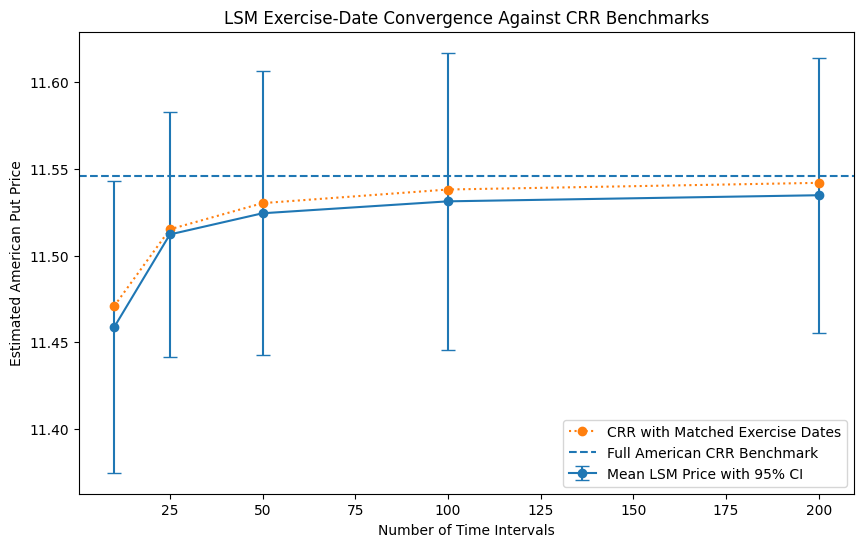

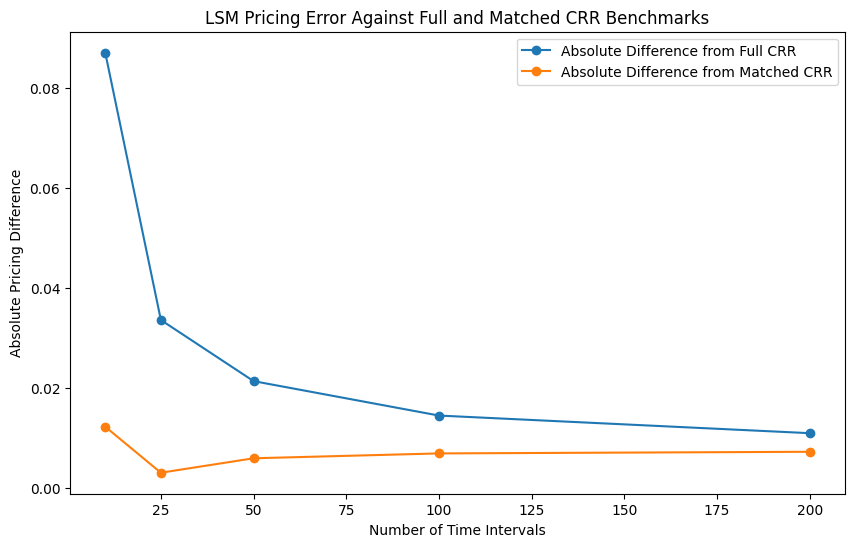

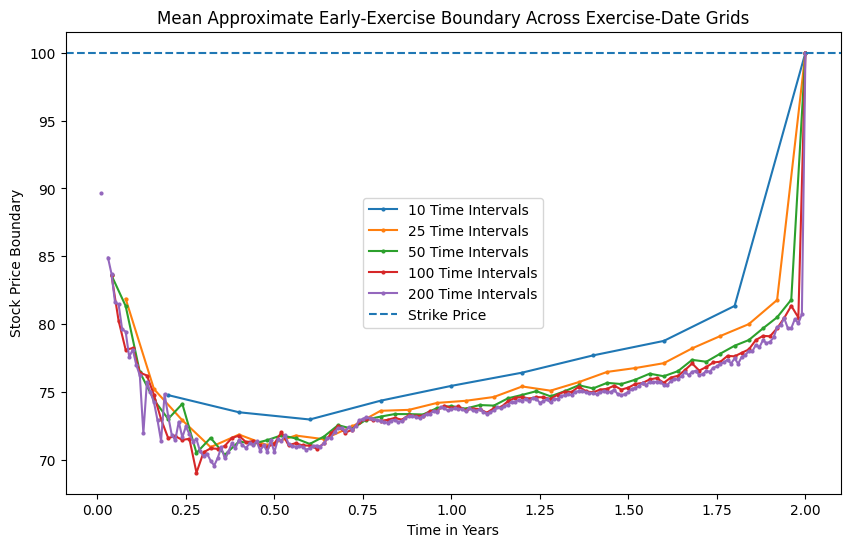

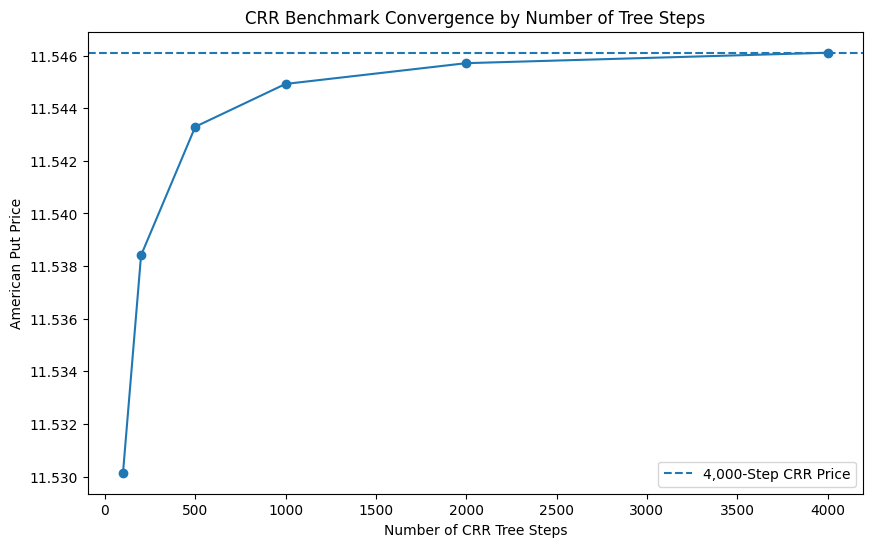

 CRR Benchmark and Exercise-Date Validation Summary: 

Parameter validation:
Initial stock price: 100
Strike price: 100
Risk-free rate: 0.03
Volatility: 0.25
Maturity in years: 2
All LSM and CRR parameters match: True
Volatility adjustment applied: False

CRR benchmark validation:
Main CRR tree steps: 2000
CRR 2,000-step price: 11.54570947
CRR 4,000-step price: 11.54610639
Absolute 2,000 vs 4,000-step difference: 0.00039693
2,000-step benchmark matches original notebook CRR: True

LSM experiment settings:
Number of paths: 10000
Time intervals tested: [10, 25, 50, 100, 200]
Random seeds tested: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Regression held fixed: quadratic
All discounting checks passed: True

Full CRR comparison:
50-interval mean LSM price: 11.524425
50-interval absolute difference from full CRR: 0.021285
50-interval full CRR inside 95% CI: True
100-interval mean LSM price: 11.531312
100-interval absolute difference from full CRR: 0.014398
100-interval full CRR inside 95% CI: True
200

In [7]:
#### PART 2B - CRR BENCHMARK AND EXERCISE-DATE VALIDATION ####

# Goal:
# 1. Confirm that the LSM and CRR calculations use exactly the same option parameters
# 2. Confirm that the 2,000-step CRR benchmark is numerically converged
# 3. Extend the exercise-date convergence study from 10, 25 and 50 intervals to 100 and 200 intervals
# 4. Test whether the full American CRR benchmark enters LSM 95% confidence interval as exercise grid becomes finer
# 5. Separate LSM error from finite exercise-date error
# 6. Create matched CRR benchmarks that only permit early exercise on the same dates as each LSM experiment
# 7. Keep volatility unchanged so any improvement is not created by manually adjusting model parameters
# 8. Determine whether the original CRR discrepancy is mainly explained by finite exercise-date spacing

# Important:
# - Partially in response to CRR benchmark being outside 10,000 path 95% confidence interval (due to only 10 intervals)
# - Number of paths remains 10,000
# - Regression remains quadratic
# - Random seeds remain 1 to 10
# - The same Brownian movements are used across all LSM exercise grids within each seed
# - S0, K, r, sigma and T are identical for LSM and CRR
# - The full CRR benchmark uses 2,000 tree steps
# - The matched CRR calculations also use 2,000-step tree but restrict exercise to corresponding LSM exercise dates

### EXPERIMENT SETTINGS

crr_validation_n_paths = 10000
crr_validation_step_counts = [10, 25, 50, 100, 200]
crr_validation_seeds = list(range(1, 11))
crr_validation_tree_steps = 2000
crr_validation_finest_steps = max(crr_validation_step_counts)

### CONFIRM LSM AND CRR PARAMETERS MATCH

df_crr_parameter_check = pd.DataFrame({
    "Parameter": ["Initial Stock Price", "Strike", "Risk-Free Rate", "Volatility", "Maturity"],
    "LSM_Value": [S0, K, r, sigma, T],
    "CRR_Value": [S0, K, r, sigma, T]
})
df_crr_parameter_check["Parameters_Match"] = np.isclose(
    df_crr_parameter_check["LSM_Value"], df_crr_parameter_check["CRR_Value"], rtol=0, atol=1e-12
)

all_crr_parameters_match = bool(df_crr_parameter_check["Parameters_Match"].all())
display(df_crr_parameter_check)

### CHECK CRR TREE-STEP CONVERGENCE

# Recalculate the CRR price over increasingly fine trees to confirm that 2,000 steps is a stable benchmark
crr_tree_step_counts = [100, 200, 500, 1000, 2000, 4000]
crr_tree_rows = []

for tree_steps_test in crr_tree_step_counts:
    tree_price_test = crr_american_put(S0=S0, K=K, r=r, sigma=sigma, T=T, tree_steps=tree_steps_test)
    crr_tree_rows.append({"CRR_Tree_Steps": tree_steps_test, "CRR_Price": tree_price_test})

df_crr_tree_convergence = pd.DataFrame(crr_tree_rows)
crr_4000_step_price = float(df_crr_tree_convergence.loc[
    df_crr_tree_convergence["CRR_Tree_Steps"] == 4000, "CRR_Price"
].iloc[0])
df_crr_tree_convergence["Difference_From_4000_Step_CRR"] = (
    df_crr_tree_convergence["CRR_Price"] - crr_4000_step_price
)
df_crr_tree_convergence["Absolute_Difference_From_4000_Step_CRR"] = abs(
    df_crr_tree_convergence["Difference_From_4000_Step_CRR"]
)

crr_validation_benchmark = float(df_crr_tree_convergence.loc[
    df_crr_tree_convergence["CRR_Tree_Steps"] == crr_validation_tree_steps, "CRR_Price"
].iloc[0])
crr_2000_matches_original = np.isclose(crr_validation_benchmark, crr_american_put_price, rtol=1e-12, atol=1e-12)

display(df_crr_tree_convergence.round(8))

### AGGREGATE FINE BROWNIAN SHOCKS

# Convert the common 200-step shocks for use with fewer time steps
def aggregate_standard_normal_shocks(fine_shocks, coarse_n_steps):
    fine_n_steps, number_of_paths = fine_shocks.shape
    if fine_n_steps % coarse_n_steps != 0:
        raise ValueError("The fine number of steps must be exactly divisible by the coarse number of steps.")
    aggregation_size = fine_n_steps // coarse_n_steps
    reshaped_shocks = fine_shocks.reshape(coarse_n_steps, aggregation_size, number_of_paths)
    return reshaped_shocks.sum(axis=1) / np.sqrt(aggregation_size)

### LONGSTAFF-SCHWARTZ FUNCTION WITH BOUNDARY OUTPUT

# Price an American put using quadratic Longstaff-Schwartz regression
def longstaff_schwartz_quadratic_full_results(simulated_paths, K, r, T):
    experiment_n_paths = simulated_paths.shape[0]
    experiment_n_steps = simulated_paths.shape[1] - 1
    experiment_dt = T / experiment_n_steps
    one_step_discount_factor = np.exp(-r * experiment_dt)

    cashflows_experiment = np.maximum(K - simulated_paths[:, -1], 0)
    exercise_time_experiment = np.full(experiment_n_paths, experiment_n_steps, dtype=int)
    exercise_stock_experiment = simulated_paths[:, -1].copy()

    boundary_experiment = np.full(experiment_n_steps + 1, np.nan)
    boundary_experiment[experiment_n_steps] = K
    exercise_decisions_experiment = np.zeros(experiment_n_steps + 1, dtype=int)

    for t in range(experiment_n_steps - 1, 0, -1):
        current_stock_prices = simulated_paths[:, t]
        immediate_exercise_values = np.maximum(K - current_stock_prices, 0)
        discounted_cashflows_experiment = cashflows_experiment * one_step_discount_factor
        in_the_money = immediate_exercise_values > 0

        if np.sum(in_the_money) == 0:
            cashflows_experiment = discounted_cashflows_experiment
            continue

        stock_prices_itm = current_stock_prices[in_the_money]
        exercise_values_itm = immediate_exercise_values[in_the_money]
        continuation_targets_itm = discounted_cashflows_experiment[in_the_money]

        # Quadratic continuation-value regression: C(S) = a + bS + cS²
        regression_matrix = np.column_stack([np.ones(len(stock_prices_itm)), stock_prices_itm, stock_prices_itm**2])
        regression_coefficients, *_ = np.linalg.lstsq(regression_matrix, continuation_targets_itm, rcond=None)
        estimated_continuation_values = regression_matrix @ regression_coefficients

        exercise_now_itm = exercise_values_itm > estimated_continuation_values
        itm_indices = np.where(in_the_money)[0]
        exercise_indices = itm_indices[exercise_now_itm]

        cashflows_experiment = discounted_cashflows_experiment.copy()
        cashflows_experiment[exercise_indices] = immediate_exercise_values[exercise_indices]
        exercise_time_experiment[exercise_indices] = t
        exercise_stock_experiment[exercise_indices] = current_stock_prices[exercise_indices]
        exercise_decisions_experiment[t] = len(exercise_indices)

        if len(exercise_indices) > 0:
            boundary_experiment[t] = np.max(current_stock_prices[exercise_indices])

    continuation_value_time_0_experiment = np.mean(cashflows_experiment) * one_step_discount_factor
    initial_stock_price_experiment = simulated_paths[0, 0]
    immediate_exercise_time_0_experiment = max(K - initial_stock_price_experiment, 0)
    estimated_price = max(immediate_exercise_time_0_experiment, continuation_value_time_0_experiment)

    cashflow_at_exercise_experiment = np.maximum(K - exercise_stock_experiment, 0)
    present_values_experiment = cashflow_at_exercise_experiment * np.exp(-r * exercise_time_experiment * experiment_dt)
    independent_price = np.mean(present_values_experiment)
    discounting_difference = abs(continuation_value_time_0_experiment - independent_price)

    number_early_exercised = int(np.sum(exercise_time_experiment < experiment_n_steps))
    early_exercise_percentage = number_early_exercised / experiment_n_paths * 100

    return {
        "Price": estimated_price,
        "Independent_Price": independent_price,
        "Discounting_Difference": discounting_difference,
        "Boundary": boundary_experiment,
        "Exercise_Times": exercise_time_experiment,
        "Exercise_Decisions": exercise_decisions_experiment,
        "Number_Early_Exercised": number_early_exercised,
        "Early_Exercise_Percentage": early_exercise_percentage,
        "Present_Value_SD": np.std(present_values_experiment, ddof=1)
    }

### MATCHED-EXERCISE-DATE CRR FUNCTION

# Use a 2,000-step CRR tree but allow early exercise only on the same dates as the LSM model
# Creates a matched benchmark to separate finite exercise-date error from LSM error
def crr_put_with_matched_exercise_dates(S0, K, r, sigma, T, tree_steps, exercise_intervals):
    if tree_steps < 1 or exercise_intervals < 1:
        raise ValueError("tree_steps and exercise_intervals must both be at least 1.")
    if tree_steps % exercise_intervals != 0:
        raise ValueError("tree_steps must be exactly divisible by exercise_intervals.")

    tree_dt = T / tree_steps
    up_factor = np.exp(sigma * np.sqrt(tree_dt))
    down_factor = 1.0 / up_factor
    risk_neutral_probability = (np.exp(r * tree_dt) - down_factor) / (up_factor - down_factor)

    if not 0 <= risk_neutral_probability <= 1:
        raise ValueError("The CRR risk-neutral probability is outside [0, 1].")

    tree_discount_factor = np.exp(-r * tree_dt)
    exercise_step_spacing = tree_steps // exercise_intervals

    number_of_up_moves = np.arange(tree_steps + 1)
    terminal_stock_prices = S0 * up_factor**number_of_up_moves * down_factor**(tree_steps - number_of_up_moves)
    option_values = np.maximum(K - terminal_stock_prices, 0)

    for step in range(tree_steps - 1, -1, -1):
        continuation_values = tree_discount_factor * (
            risk_neutral_probability * option_values[1:step + 2] + (1.0 - risk_neutral_probability) * option_values[0:step + 1]
        )

        # Only permit early exercise on dates corresponding exactly to the LSM exercise grid
        if step % exercise_step_spacing == 0:
            number_of_up_moves = np.arange(step + 1)
            stock_prices_at_step = S0 * up_factor**number_of_up_moves * down_factor**(step - number_of_up_moves)
            immediate_exercise_values = np.maximum(K - stock_prices_at_step, 0)
            option_values = np.maximum(immediate_exercise_values, continuation_values)
        else:
            option_values = continuation_values

    return float(option_values[0])

### CALCULATE MATCHED CRR BENCHMARKS

matched_crr_rows = []

for experiment_n_steps in crr_validation_step_counts:
    matched_crr_price = crr_put_with_matched_exercise_dates(
        S0=S0, K=K, r=r, sigma=sigma, T=T,
        tree_steps=crr_validation_tree_steps,
        exercise_intervals=experiment_n_steps
    )
    matched_crr_rows.append({
        "Number_Of_Time_Intervals": experiment_n_steps,
        "Matched_CRR_Price": matched_crr_price,
        "Matched_CRR_Difference_From_Full_CRR": matched_crr_price - crr_validation_benchmark,
        "Matched_CRR_Absolute_Difference_From_Full_CRR": abs(matched_crr_price - crr_validation_benchmark)
    })

df_matched_crr = pd.DataFrame(matched_crr_rows)

### RUN EXTENDED LSM EXERCISE-DATE EXPERIMENT

crr_validation_rows = []
crr_validation_boundaries = {step_count: [] for step_count in crr_validation_step_counts}

for seed in crr_validation_seeds:
    random_generator = np.random.default_rng(seed)
    fine_random_shocks = random_generator.standard_normal(
        size=(crr_validation_finest_steps, crr_validation_n_paths)
    )

    for experiment_n_steps in crr_validation_step_counts:
        experiment_shocks = aggregate_standard_normal_shocks(
            fine_shocks=fine_random_shocks, coarse_n_steps=experiment_n_steps
        )
        experiment_paths = simulate_gbm_paths_from_shocks(
            S0=S0, r=r, sigma=sigma, T=T, random_shocks=experiment_shocks
        )
        experiment_result = longstaff_schwartz_quadratic_full_results(
            simulated_paths=experiment_paths, K=K, r=r, T=T
        )

        crr_validation_rows.append({
            "Seed": seed,
            "Number_Of_Paths": crr_validation_n_paths,
            "Number_Of_Time_Intervals": experiment_n_steps,
            "Number_Of_Early_Exercise_Dates": experiment_n_steps - 1,
            "LSM_Price": experiment_result["Price"],
            "Independent_Price": experiment_result["Independent_Price"],
            "Discounting_Difference": experiment_result["Discounting_Difference"],
            "Path_Present_Value_SD": experiment_result["Present_Value_SD"],
            "Number_Early_Exercised": experiment_result["Number_Early_Exercised"],
            "Early_Exercise_Percentage": experiment_result["Early_Exercise_Percentage"]
        })
        crr_validation_boundaries[experiment_n_steps].append(experiment_result["Boundary"])

df_crr_validation_all = pd.DataFrame(crr_validation_rows)
display(df_crr_validation_all.head(20))

### SUMMARISE LSM RESULTS

df_crr_validation_summary = (df_crr_validation_all.groupby("Number_Of_Time_Intervals").agg(
    Number_Of_Early_Exercise_Dates=("Number_Of_Early_Exercise_Dates", "first"),
    Mean_LSM_Price=("LSM_Price", "mean"),
    Standard_Deviation_Across_Seeds=("LSM_Price", "std"),
    Minimum_LSM_Price=("LSM_Price", "min"),
    Maximum_LSM_Price=("LSM_Price", "max"),
    Mean_Early_Exercise_Percentage=("Early_Exercise_Percentage", "mean"),
    Maximum_Discounting_Difference=("Discounting_Difference", "max")
).reset_index())

df_crr_validation_summary["Standard_Error_Of_Mean"] = (
    df_crr_validation_summary["Standard_Deviation_Across_Seeds"] / np.sqrt(len(crr_validation_seeds))
)
df_crr_validation_summary["Confidence_Interval_Lower"] = (
    df_crr_validation_summary["Mean_LSM_Price"] - 1.96 * df_crr_validation_summary["Standard_Error_Of_Mean"]
)
df_crr_validation_summary["Confidence_Interval_Upper"] = (
    df_crr_validation_summary["Mean_LSM_Price"] + 1.96 * df_crr_validation_summary["Standard_Error_Of_Mean"]
)

# Add the full American CRR benchmark and the CRR benchmark with matched exercise dates
df_crr_validation_summary["Full_CRR_Price"] = crr_validation_benchmark
df_crr_validation_summary = df_crr_validation_summary.merge(
    df_matched_crr[["Number_Of_Time_Intervals", "Matched_CRR_Price"]],
    on="Number_Of_Time_Intervals", how="left"
)

### COMPARE LSM WITH FULL AND MATCHED CRR BENCHMARKS

df_crr_validation_summary["Difference_From_Full_CRR"] = (
    df_crr_validation_summary["Mean_LSM_Price"] - df_crr_validation_summary["Full_CRR_Price"]
)
df_crr_validation_summary["Absolute_Difference_From_Full_CRR"] = abs(
    df_crr_validation_summary["Difference_From_Full_CRR"]
)
df_crr_validation_summary["Percentage_Difference_From_Full_CRR"] = (
    df_crr_validation_summary["Absolute_Difference_From_Full_CRR"] / df_crr_validation_summary["Full_CRR_Price"] * 100
)

df_crr_validation_summary["Difference_From_Matched_CRR"] = (
    df_crr_validation_summary["Mean_LSM_Price"] - df_crr_validation_summary["Matched_CRR_Price"]
)
df_crr_validation_summary["Absolute_Difference_From_Matched_CRR"] = abs(
    df_crr_validation_summary["Difference_From_Matched_CRR"]
)
df_crr_validation_summary["Percentage_Difference_From_Matched_CRR"] = (
    df_crr_validation_summary["Absolute_Difference_From_Matched_CRR"] / df_crr_validation_summary["Matched_CRR_Price"] * 100
)

# Test whether each benchmark lies inside the LSM 95% confidence interval
df_crr_validation_summary["Full_CRR_Inside_95CI"] = (
    (df_crr_validation_summary["Full_CRR_Price"] >= df_crr_validation_summary["Confidence_Interval_Lower"])
    & (df_crr_validation_summary["Full_CRR_Price"] <= df_crr_validation_summary["Confidence_Interval_Upper"])
)
df_crr_validation_summary["Matched_CRR_Inside_95CI"] = (
    (df_crr_validation_summary["Matched_CRR_Price"] >= df_crr_validation_summary["Confidence_Interval_Lower"])
    & (df_crr_validation_summary["Matched_CRR_Price"] <= df_crr_validation_summary["Confidence_Interval_Upper"])
)

df_crr_validation_summary = df_crr_validation_summary[[
    "Number_Of_Time_Intervals",
    "Number_Of_Early_Exercise_Dates",
    "Mean_LSM_Price",
    "Standard_Deviation_Across_Seeds",
    "Standard_Error_Of_Mean",
    "Confidence_Interval_Lower",
    "Confidence_Interval_Upper",
    "Full_CRR_Price",
    "Full_CRR_Inside_95CI",
    "Difference_From_Full_CRR",
    "Absolute_Difference_From_Full_CRR",
    "Percentage_Difference_From_Full_CRR",
    "Matched_CRR_Price",
    "Matched_CRR_Inside_95CI",
    "Difference_From_Matched_CRR",
    "Absolute_Difference_From_Matched_CRR",
    "Percentage_Difference_From_Matched_CRR",
    "Minimum_LSM_Price",
    "Maximum_LSM_Price",
    "Mean_Early_Exercise_Percentage",
    "Maximum_Discounting_Difference"
]]

display(df_crr_validation_summary.round(6))

### CREATE MEAN BOUNDARY DATA

mean_boundary_by_steps = {}
boundary_standard_deviation_by_steps = {}
time_grid_by_steps = {}

for experiment_n_steps in crr_validation_step_counts:
    boundary_matrix = np.array(crr_validation_boundaries[experiment_n_steps])
    number_of_valid_boundaries = np.sum(~np.isnan(boundary_matrix), axis=0)

    mean_boundary = np.full(boundary_matrix.shape[1], np.nan)
    boundary_standard_deviation = np.full(boundary_matrix.shape[1], np.nan)

    valid_mean_dates = number_of_valid_boundaries > 0
    valid_sd_dates = number_of_valid_boundaries > 1

    mean_boundary[valid_mean_dates] = np.nanmean(boundary_matrix[:, valid_mean_dates], axis=0)
    boundary_standard_deviation[valid_sd_dates] = np.nanstd(boundary_matrix[:, valid_sd_dates], axis=0, ddof=1)

    mean_boundary_by_steps[experiment_n_steps] = mean_boundary
    boundary_standard_deviation_by_steps[experiment_n_steps] = boundary_standard_deviation
    time_grid_by_steps[experiment_n_steps] = np.linspace(0, T, experiment_n_steps + 1)

### VALIDATION CHECKS

all_crr_validation_discounting_checks_pass = np.allclose(
    df_crr_validation_all["Discounting_Difference"], 0, rtol=1e-9, atol=1e-9
)

row_50 = df_crr_validation_summary.loc[df_crr_validation_summary["Number_Of_Time_Intervals"] == 50].iloc[0]
row_100 = df_crr_validation_summary.loc[df_crr_validation_summary["Number_Of_Time_Intervals"] == 100].iloc[0]
row_200 = df_crr_validation_summary.loc[df_crr_validation_summary["Number_Of_Time_Intervals"] == 200].iloc[0]

full_crr_error_reduction_50_to_200 = (
    row_50["Absolute_Difference_From_Full_CRR"] - row_200["Absolute_Difference_From_Full_CRR"]
)
matched_crr_error_200 = row_200["Absolute_Difference_From_Matched_CRR"]
crr_2000_vs_4000_difference = abs(crr_validation_benchmark - crr_4000_step_price)

### DISPLAY VISUAL

# Plot LSM price convergence against the full and matched CRR benchmarks
plt.figure(figsize=(10, 6))
plt.errorbar(
    df_crr_validation_summary["Number_Of_Time_Intervals"],
    df_crr_validation_summary["Mean_LSM_Price"],
    yerr=1.96 * df_crr_validation_summary["Standard_Error_Of_Mean"],
    marker="o", capsize=5, label="Mean LSM Price with 95% CI"
)
plt.plot(
    df_crr_validation_summary["Number_Of_Time_Intervals"],
    df_crr_validation_summary["Matched_CRR_Price"],
    marker="o", linestyle=":", label="CRR with Matched Exercise Dates"
)
plt.axhline(crr_validation_benchmark, linestyle="--", label="Full American CRR Benchmark")
plt.title("LSM Exercise-Date Convergence Against CRR Benchmarks")
plt.xlabel("Number of Time Intervals")
plt.ylabel("Estimated American Put Price")
plt.legend()
plt.show()

# Plot absolute pricing error against the full and matched CRR benchmarks
plt.figure(figsize=(10, 6))
plt.plot(
    df_crr_validation_summary["Number_Of_Time_Intervals"],
    df_crr_validation_summary["Absolute_Difference_From_Full_CRR"],
    marker="o", label="Absolute Difference from Full CRR"
)
plt.plot(
    df_crr_validation_summary["Number_Of_Time_Intervals"],
    df_crr_validation_summary["Absolute_Difference_From_Matched_CRR"],
    marker="o", label="Absolute Difference from Matched CRR"
)
plt.title("LSM Pricing Error Against Full and Matched CRR Benchmarks")
plt.xlabel("Number of Time Intervals")
plt.ylabel("Absolute Pricing Difference")
plt.legend()
plt.show()

# Plot mean early-exercise boundaries across the extended exercise grids
plt.figure(figsize=(10, 6))
for experiment_n_steps in crr_validation_step_counts:
    plt.plot(
        time_grid_by_steps[experiment_n_steps],
        mean_boundary_by_steps[experiment_n_steps],
        marker="o", markersize=2, label=f"{experiment_n_steps} Time Intervals"
    )
plt.axhline(K, linestyle="--", label="Strike Price")
plt.title("Mean Approximate Early-Exercise Boundary Across Exercise-Date Grids")
plt.xlabel("Time in Years")
plt.ylabel("Stock Price Boundary")
plt.legend()
plt.show()

# Plot CRR tree-step convergence
plt.figure(figsize=(10, 6))
plt.plot(
    df_crr_tree_convergence["CRR_Tree_Steps"],
    df_crr_tree_convergence["CRR_Price"],
    marker="o"
)
plt.axhline(crr_4000_step_price, linestyle="--", label="4,000-Step CRR Price")
plt.title("CRR Benchmark Convergence by Number of Tree Steps")
plt.xlabel("Number of CRR Tree Steps")
plt.ylabel("American Put Price")
plt.legend()
plt.show()

### CRR VALIDATION SUMMARY

print(" CRR Benchmark and Exercise-Date Validation Summary: ")

print("\nParameter validation:")
print("Initial stock price:", S0)
print("Strike price:", K)
print("Risk-free rate:", r)
print("Volatility:", sigma)
print("Maturity in years:", T)
print("All LSM and CRR parameters match:", all_crr_parameters_match)
print("Volatility adjustment applied:", False)

print("\nCRR benchmark validation:")
print("Main CRR tree steps:", crr_validation_tree_steps)
print("CRR 2,000-step price:", round(crr_validation_benchmark, 8))
print("CRR 4,000-step price:", round(crr_4000_step_price, 8))
print("Absolute 2,000 vs 4,000-step difference:", round(crr_2000_vs_4000_difference, 8))
print("2,000-step benchmark matches original notebook CRR:", crr_2000_matches_original)

print("\nLSM experiment settings:")
print("Number of paths:", crr_validation_n_paths)
print("Time intervals tested:", crr_validation_step_counts)
print("Random seeds tested:", crr_validation_seeds)
print("Regression held fixed: quadratic")
print("All discounting checks passed:", all_crr_validation_discounting_checks_pass)

print("\nFull CRR comparison:")
print("50-interval mean LSM price:", round(row_50["Mean_LSM_Price"], 6))
print("50-interval absolute difference from full CRR:", round(row_50["Absolute_Difference_From_Full_CRR"], 6))
print("50-interval full CRR inside 95% CI:", bool(row_50["Full_CRR_Inside_95CI"]))
print("100-interval mean LSM price:", round(row_100["Mean_LSM_Price"], 6))
print("100-interval absolute difference from full CRR:", round(row_100["Absolute_Difference_From_Full_CRR"], 6))
print("100-interval full CRR inside 95% CI:", bool(row_100["Full_CRR_Inside_95CI"]))
print("200-interval mean LSM price:", round(row_200["Mean_LSM_Price"], 6))
print("200-interval absolute difference from full CRR:", round(row_200["Absolute_Difference_From_Full_CRR"], 6))
print("200-interval full CRR inside 95% CI:", bool(row_200["Full_CRR_Inside_95CI"]))
print("Reduction in absolute full-CRR error from 50 to 200 intervals:", round(full_crr_error_reduction_50_to_200, 6))

print("\nMatched exercise-date comparison:")
print("50-interval matched CRR price:", round(row_50["Matched_CRR_Price"], 6))
print("50-interval absolute LSM-matched CRR difference:", round(row_50["Absolute_Difference_From_Matched_CRR"], 6))
print("50-interval matched CRR inside 95% CI:", bool(row_50["Matched_CRR_Inside_95CI"]))
print("100-interval matched CRR price:", round(row_100["Matched_CRR_Price"], 6))
print("100-interval absolute LSM-matched CRR difference:", round(row_100["Absolute_Difference_From_Matched_CRR"], 6))
print("100-interval matched CRR inside 95% CI:", bool(row_100["Matched_CRR_Inside_95CI"]))
print("200-interval matched CRR price:", round(row_200["Matched_CRR_Price"], 6))
print("200-interval absolute LSM-matched CRR difference:", round(matched_crr_error_200, 6))
print("200-interval matched CRR inside 95% CI:", bool(row_200["Matched_CRR_Inside_95CI"]))

print("\nInterpretation:")
if not all_crr_parameters_match:
    print("The LSM and CRR option parameters do not match. Resolve the parameter difference before interpreting the benchmark comparison.")
elif crr_2000_vs_4000_difference > 0.01:
    print("The 2,000-step CRR benchmark has not fully converged, so further testing may be needed.")
elif full_crr_error_reduction_50_to_200 > 0 and row_200["Matched_CRR_Inside_95CI"]:
    print(
        "The CRR benchmark is stable and uses the same option parameters as LSM. "
        "As the number of LSM exercise intervals increases, the difference from the full CRR benchmark decreases. "
        "At 25+ intervals, the matched CRR price is within the LSM 95% confidence interval. "
        "This suggests that finite exercise-date error explains part of the original difference, "
        "while the remaining difference is due to Monte Carlo and LSM regression error."
    )
elif row_200["Matched_CRR_Inside_95CI"]:
    print(
        "The matched CRR price is within the 200-interval LSM 95% confidence interval, although convergence toward the full CRR benchmark is not consistent. "
        "This suggests that finite exercise-date error explains an important part of the original difference."
    )
else:
    print(
        "The 200-interval LSM estimate remains different from both the full and matched CRR benchmarks. "
        "Finite exercise-date error alone therefore does not explain the difference, with the remaining error likely due to Monte Carlo and LSM regression error."
    )

,Seed,Polynomial_Degree,Number_Of_Paths,Number_Of_Time_Intervals,LSM_Price,Independent_Price,Discounting_Difference,Path_Present_Value_SD,Number_Early_Exercised,Early_Exercise_Percentage,Mean_Condition_Number,Maximum_Condition_Number,Mean_Regression_MSE,Mean_Number_ITM
0,1,1,10000,50,11.575418,11.575418,3.552714e-15,13.317025,3514,35.14,1.817235e+01,6.725987e+01,124.392294,5082.795918
1,1,2,10000,50,11.730486,11.730486,5.329071e-15,13.260464,4048,40.48,3.611099e+02,3.481130e+03,106.536716,5082.795918
2,1,3,10000,50,11.791037,11.791037,3.552714e-15,13.254563,4399,43.99,8.500091e+03,1.585647e+05,103.640650,5082.795918
3,1,4,10000,50,11.814439,11.814439,5.329071e-15,13.340959,4527,45.27,2.413417e+05,6.663967e+06,104.952454,5082.795918
4,1,5,10000,50,11.817117,11.817117,5.329071e-15,13.146130,4658,46.58,8.231797e+06,2.864225e+08,101.277174,5082.795918
5,2,1,10000,50,11.282369,11.282369,3.552714e-15,12.816247,3293,32.93,1.838057e+01,6.647839e+01,119.269369,5019.714286
6,2,2,10000,50,11.445955,11.445955,1.776357e-15,12.518235,4078,40.78,3.693882e+02,3.548549e+03,93.799192,5019.714286
7,2,3,10000,50,11.505328,11.505328,5.329071e-15,12.735739,4374,43.74,8.779609e+03,1.619798e+05,96.242936,5019.714286
8,2,4,10000,50,11.525359,11.525359,5.329071e-15,12.762473,4575,45.75,2.505001e+05,6.857732e+06,94.421081,5019.714286
9,2,5,10000,50,11.500595,11.500595,3.552714e-15,12.655113,4629,46.29,8.431584e+06,2.860227e+08,91.340215,5019.714286


,Polynomial_Degree,Mean_LSM_Price,Standard_Deviation_Across_Seeds,Standard_Error_Of_Mean,Confidence_Interval_Lower,Confidence_Interval_Upper,Difference_From_CRR,Absolute_Difference_From_CRR,Percentage_Difference_From_CRR,Minimum_LSM_Price,Maximum_LSM_Price,Mean_Early_Exercise_Percentage,Mean_Regression_MSE,Mean_Condition_Number,Maximum_Condition_Number,Maximum_Discounting_Difference
0,1,11.379816,0.121095,0.038294,11.304761,11.454872,-0.165893,0.165893,1.436838,11.226571,11.575418,31.035,122.043981,1.836865e+01,6.855041e+01,0.0
1,2,11.511453,0.130404,0.041237,11.430628,11.592279,-0.034256,0.034256,0.296701,11.350979,11.730486,39.896,96.857812,3.702534e+02,3.790982e+03,0.0
2,3,11.531225,0.132696,0.041962,11.448980,11.613471,-0.014484,0.014484,0.125452,11.371749,11.791037,43.520,93.582774,8.749241e+03,1.851406e+05,0.0
3,4,11.548308,0.139000,0.043956,11.462155,11.634461,0.002598,0.002598,0.022505,11.398918,11.814439,44.926,93.827158,2.562179e+05,9.099729e+06,0.0
4,5,11.558238,0.138321,0.043741,11.472506,11.643970,0.012529,0.012529,0.108513,11.411901,11.817117,45.725,92.987041,9.127103e+06,4.466232e+08,0.0


,Polynomial_Degree,Mean_Boundary_SD_Across_Time,Maximum_Boundary_SD_Across_Time,Number_Of_Boundary_Dates
0,1,1.149490,4.078205,50
1,2,1.739152,3.599658,49
2,3,2.948277,9.429459,50
3,4,4.883127,10.944819,50
4,5,4.399160,9.279058,50


,Polynomial_Degree,Mean_LSM_Price,Standard_Deviation_Across_Seeds,Standard_Error_Of_Mean,Confidence_Interval_Lower,Confidence_Interval_Upper,Difference_From_CRR,Absolute_Difference_From_CRR,Percentage_Difference_From_CRR,Minimum_LSM_Price,Maximum_LSM_Price,Mean_Early_Exercise_Percentage,Mean_Regression_MSE,Mean_Condition_Number,Maximum_Condition_Number,Maximum_Discounting_Difference,Mean_Boundary_SD_Across_Time,Maximum_Boundary_SD_Across_Time,Number_Of_Boundary_Dates
0,1,11.379816,0.121095,0.038294,11.304761,11.454872,-0.165893,0.165893,1.436838,11.226571,11.575418,31.035,122.043981,1.836865e+01,6.855041e+01,0.0,1.149490,4.078205,50
1,2,11.511453,0.130404,0.041237,11.430628,11.592279,-0.034256,0.034256,0.296701,11.350979,11.730486,39.896,96.857812,3.702534e+02,3.790982e+03,0.0,1.739152,3.599658,49
2,3,11.531225,0.132696,0.041962,11.448980,11.613471,-0.014484,0.014484,0.125452,11.371749,11.791037,43.520,93.582774,8.749241e+03,1.851406e+05,0.0,2.948277,9.429459,50
3,4,11.548308,0.139000,0.043956,11.462155,11.634461,0.002598,0.002598,0.022505,11.398918,11.814439,44.926,93.827158,2.562179e+05,9.099729e+06,0.0,4.883127,10.944819,50
4,5,11.558238,0.138321,0.043741,11.472506,11.643970,0.012529,0.012529,0.108513,11.411901,11.817117,45.725,92.987041,9.127103e+06,4.466232e+08,0.0,4.399160,9.279058,50


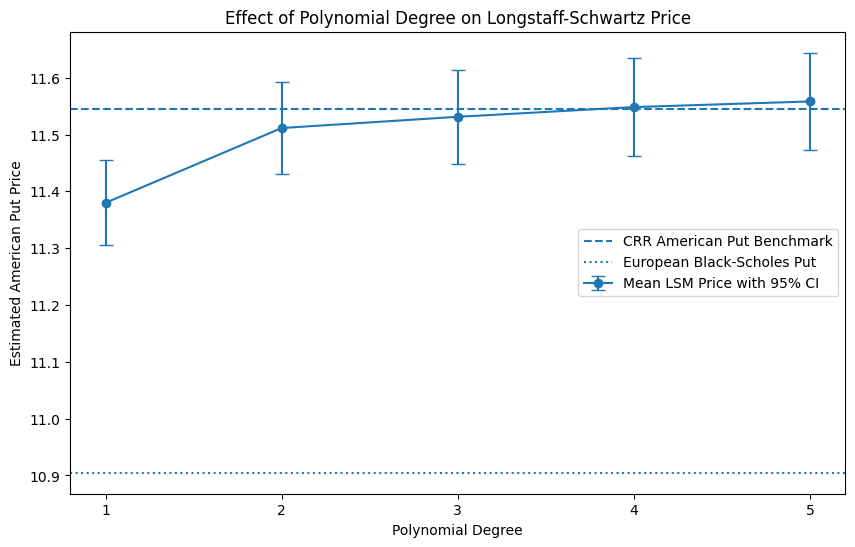

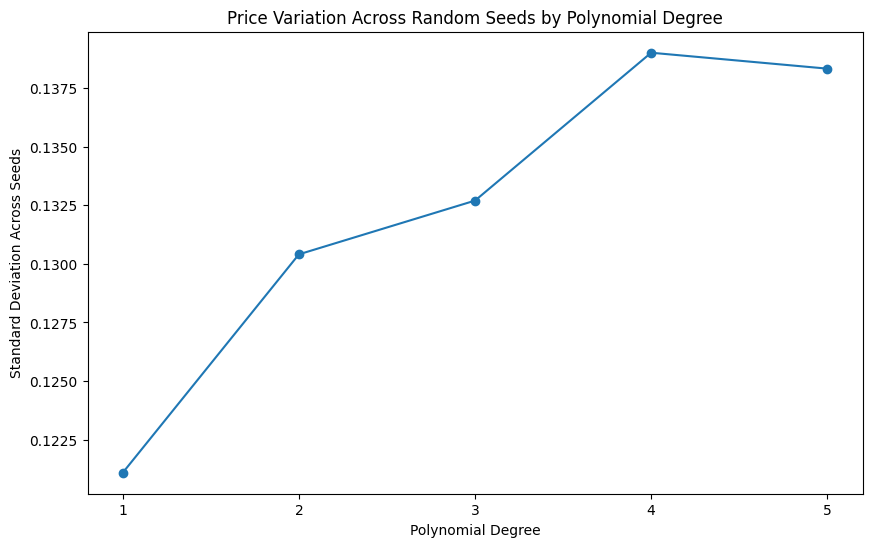

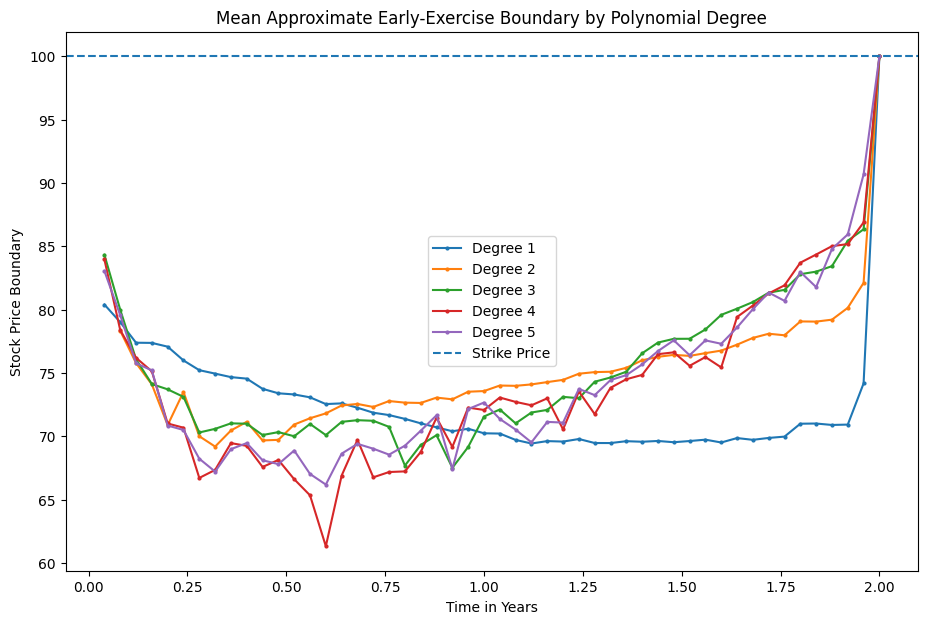

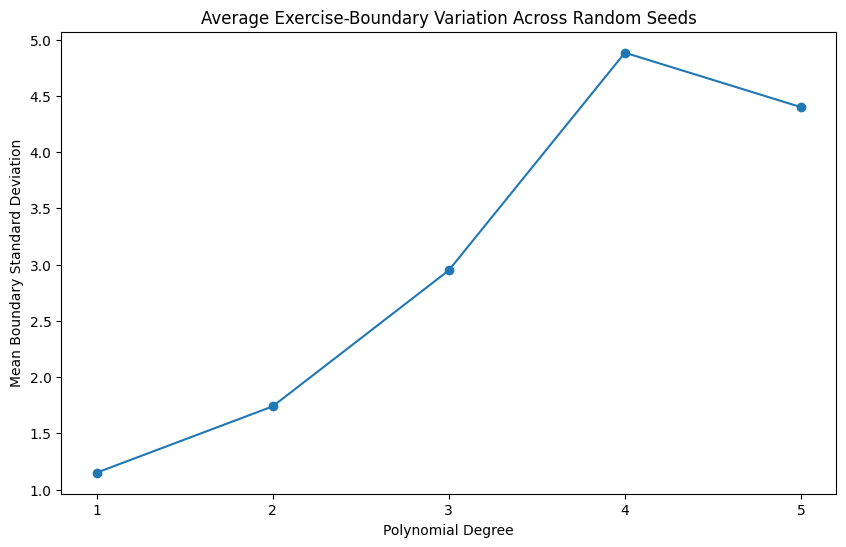

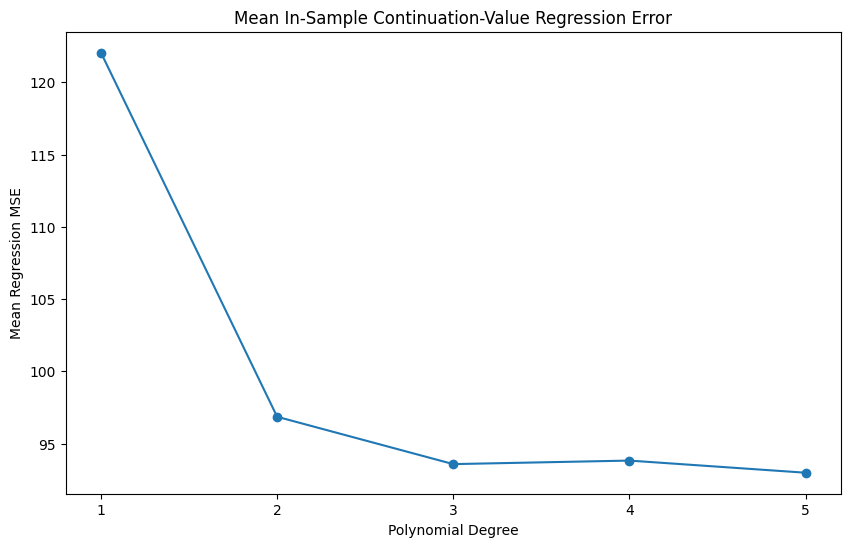

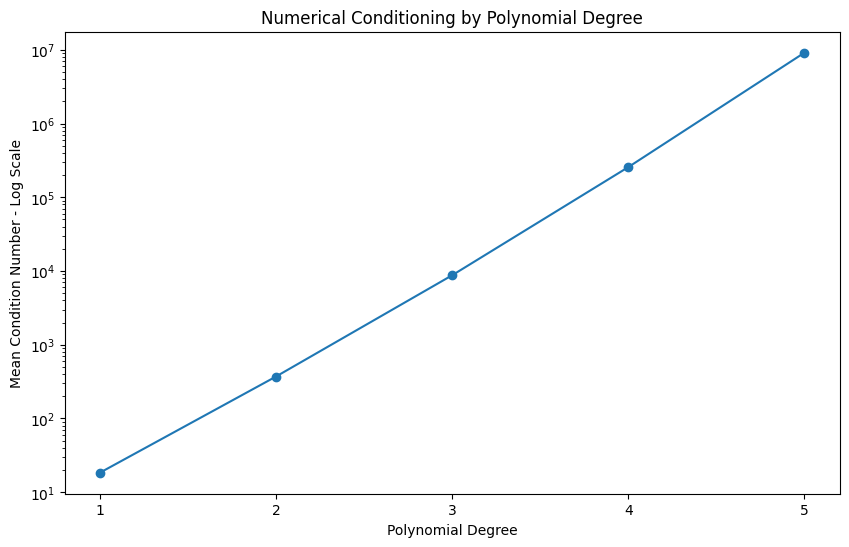

 Polynomial Regression Comparison: 

Experiment settings:
Number of paths held fixed: 10000
Number of time intervals held fixed: 50
Polynomial degrees tested: [1, 2, 3, 4, 5]
Random seeds tested: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Stock-price regression input: S / K
CRR American put benchmark: 11.545709

Internal consistency:
All discounting checks passed: True

Price comparison:
Lowest mean regression price: 11.379816
Highest mean regression price: 11.558238
Range of mean prices: 0.178422
Degree closest to CRR price: 4
Degree with lowest price variation: 1
Degree with lowest boundary variation: 1

Interpretation:
All regression models remain internally consistent. Compare price accuracy, variation across seeds, boundary stability, regression error, and numerical conditioning before selecting a preferred polynomial degree.


In [8]:
#### PART 2C - POLYNOMIAL REGRESSION DEGREE COMPARISON ####

# Goal:
# 1. Compare polynomial continuation-value regressions of degree 1 to 5
# 2. Measure how regression degree affects:
#    - American put price
#    - Price stability across random seeds
#    - Early-exercise boundary
#    - Early-exercise frequency
#    - Numerical conditioning

# Important:
# - Number of paths is fixed at 10,000
# - Number of time intervals is fixed at 50
# - The same simulated paths are used for every polynomial degree
# - Stock prices are scaled by K before polynomial fitting
# - Scaling improves numerical stability without changing the polynomial model

### EXPERIMENT SETTINGS

regression_n_paths = 10000
regression_n_steps = 50
regression_degrees = [1, 2, 3, 4, 5]
regression_seeds = list(range(1, 11))
regression_dt = T / regression_n_steps

### GENERAL LONGSTAFF-SCHWARTZ POLYNOMIAL FUNCTION

# Price an American put using Longstaff-Schwartz with a polynomial continuation-value regression
# The stock-price input is scaled by the strike: x = S / K
# The regression basis is:
# degree 1: 1, x
# degree 2: 1, x, x²
# degree 3: 1, x, x², x³...
# This returns the price, boundary, exercise information, numerical-conditioning information, and discounting check
def longstaff_schwartz_polynomial_results(simulated_paths, K, r, T, polynomial_degree):
    if polynomial_degree < 1:
        raise ValueError("polynomial_degree must be at least 1")

    experiment_n_paths = simulated_paths.shape[0]
    experiment_n_steps = simulated_paths.shape[1] - 1
    experiment_dt = T / experiment_n_steps
    one_step_discount_factor = np.exp(-r * experiment_dt)

    # Initialise cashflows at maturity
    cashflows_experiment = np.maximum(K - simulated_paths[:, -1], 0)

    # Initially, every path reaches maturity
    exercise_time_experiment = np.full(experiment_n_paths, experiment_n_steps, dtype=int)
    exercise_stock_experiment = simulated_paths[:, -1].copy()

    # Approximate sample-based exercise boundary
    boundary_experiment = np.full(experiment_n_steps + 1, np.nan)
    boundary_experiment[experiment_n_steps] = K

    # Number of exercise decisions made during each regression
    exercise_decisions_experiment = np.zeros(experiment_n_steps + 1, dtype=int)

    # Store regression results for each time step
    condition_numbers = []
    regression_mse_values = []
    number_itm_values = []

    # Work backwards through the exercise dates
    for t in range(experiment_n_steps - 1, 0, -1):
        current_stock_prices = simulated_paths[:, t]
        immediate_exercise_values = np.maximum(K - current_stock_prices, 0)
        discounted_cashflows_experiment = cashflows_experiment * one_step_discount_factor
        in_the_money = immediate_exercise_values > 0
        number_itm = int(np.sum(in_the_money))
        number_itm_values.append(number_itm)

        # If there are no in-the-money paths, every path continues
        if number_itm == 0:
            cashflows_experiment = discounted_cashflows_experiment
            continue

        stock_prices_itm = current_stock_prices[in_the_money]
        exercise_values_itm = immediate_exercise_values[in_the_money]
        continuation_targets_itm = discounted_cashflows_experiment[in_the_money]

        # Scale stock prices by the strike to avoid very large raw values such as S⁵
        scaled_stock_prices_itm = stock_prices_itm / K

        # Polynomial design matrix: [1, x, x², ..., x^degree]
        regression_matrix = np.polynomial.polynomial.polyvander(scaled_stock_prices_itm, polynomial_degree)

        # Record the numerical condition number
        # A large condition number indicates that fitted coefficients may be sensitive to small data changes
        condition_number = np.linalg.cond(regression_matrix)
        condition_numbers.append(condition_number)

        regression_coefficients, *_ = np.linalg.lstsq(regression_matrix, continuation_targets_itm, rcond=None)

        estimated_continuation_values = regression_matrix @ regression_coefficients

        # Record in-sample mean squared prediction error (MSE)
        regression_mse = np.mean((continuation_targets_itm - estimated_continuation_values)**2)
        regression_mse_values.append(regression_mse)

        # Exercise when immediate exercise value exceeds estimated continuation value
        exercise_now_itm = exercise_values_itm > estimated_continuation_values
        itm_indices = np.where(in_the_money)[0]
        exercise_indices = itm_indices[exercise_now_itm]

        # First assume every path continues
        cashflows_experiment = discounted_cashflows_experiment.copy()

        # Replace future cashflows with immediate exercise value where exercise is selected
        cashflows_experiment[exercise_indices] = immediate_exercise_values[exercise_indices]

        # Earlier decisions replace later exercise decisions
        exercise_time_experiment[exercise_indices] = t
        exercise_stock_experiment[exercise_indices] = current_stock_prices[exercise_indices]
        exercise_decisions_experiment[t] = len(exercise_indices)

        # Current approximate exercise boundary: highest exercised simulated stock price
        if len(exercise_indices) > 0:
            boundary_experiment[t] = np.max(current_stock_prices[exercise_indices])

    # Discount the remaining Time_1 values to Time_0
    continuation_value_time_0_experiment = np.mean(cashflows_experiment) * one_step_discount_factor
    initial_stock_price_experiment = simulated_paths[0, 0]
    immediate_exercise_time_0_experiment = max(K - initial_stock_price_experiment, 0)
    estimated_price = max(immediate_exercise_time_0_experiment, continuation_value_time_0_experiment)

    # Independent price calculation using final exercise times
    cashflow_at_exercise_experiment = np.maximum(K - exercise_stock_experiment, 0)
    present_values_experiment = (cashflow_at_exercise_experiment * np.exp(-r * exercise_time_experiment * experiment_dt))
    independent_price = np.mean(present_values_experiment)
    discounting_difference = abs(continuation_value_time_0_experiment - independent_price)
    number_early_exercised = int(np.sum(exercise_time_experiment < experiment_n_steps))
    early_exercise_percentage = number_early_exercised / experiment_n_paths * 100

    return {
        "Price": estimated_price,
        "Independent_Price": independent_price,
        "Discounting_Difference": discounting_difference,
        "Boundary": boundary_experiment,
        "Exercise_Times": exercise_time_experiment,
        "Exercise_Decisions": exercise_decisions_experiment,
        "Number_Early_Exercised": number_early_exercised,
        "Early_Exercise_Percentage": early_exercise_percentage,
        "Present_Value_SD": np.std(present_values_experiment, ddof=1),
        "Mean_Condition_Number": np.mean(condition_numbers) if len(condition_numbers) > 0 else np.nan,
        "Maximum_Condition_Number": np.max(condition_numbers) if len(condition_numbers) > 0 else np.nan,
        "Mean_Regression_MSE": np.mean(regression_mse_values) if len(regression_mse_values) > 0 else np.nan,
        "Mean_Number_ITM": np.mean(number_itm_values) if len(number_itm_values) > 0 else np.nan
    }

### RUN THE REGRESSION-DEGREE EXPERIMENT

regression_comparison_rows = []

# Store boundaries separately so that they can be averaged across random seeds for each polynomial degree
regression_boundaries = {degree: [] for degree in regression_degrees}

for seed in regression_seeds:

    # Generate one shock matrix for this seed. The same paths are then used for every polynomial degree
    random_generator = np.random.default_rng(seed)
    shared_random_shocks = random_generator.standard_normal(size=(regression_n_steps, regression_n_paths))

    shared_simulated_paths = simulate_gbm_paths_from_shocks(
        S0=S0, r=r, sigma=sigma, T=T, random_shocks=shared_random_shocks
    )

    for degree in regression_degrees:
        experiment_result = longstaff_schwartz_polynomial_results(
            simulated_paths=shared_simulated_paths, K=K, r=r, T=T, polynomial_degree=degree
        )
        regression_comparison_rows.append({
            "Seed": seed,
            "Polynomial_Degree": degree,
            "Number_Of_Paths": regression_n_paths,
            "Number_Of_Time_Intervals": regression_n_steps,
            "LSM_Price": experiment_result["Price"],
            "Independent_Price": experiment_result["Independent_Price"],
            "Discounting_Difference": experiment_result["Discounting_Difference"],
            "Path_Present_Value_SD": experiment_result["Present_Value_SD"],
            "Number_Early_Exercised": experiment_result["Number_Early_Exercised"],
            "Early_Exercise_Percentage": experiment_result["Early_Exercise_Percentage"],
            "Mean_Condition_Number": experiment_result["Mean_Condition_Number"],
            "Maximum_Condition_Number": experiment_result["Maximum_Condition_Number"],
            "Mean_Regression_MSE": experiment_result["Mean_Regression_MSE"],
            "Mean_Number_ITM": experiment_result["Mean_Number_ITM"]
        })
        regression_boundaries[degree].append(experiment_result["Boundary"])

df_regression_comparison_all = pd.DataFrame(regression_comparison_rows)
display(df_regression_comparison_all.head(20))

### SUMMARISE RESULTS BY POLYNOMIAL DEGREE

df_regression_comparison_summary = (df_regression_comparison_all.groupby("Polynomial_Degree").agg(
        Mean_LSM_Price=("LSM_Price", "mean"),
        Standard_Deviation_Across_Seeds=("LSM_Price", "std"),
        Minimum_LSM_Price=("LSM_Price", "min"),
        Maximum_LSM_Price=("LSM_Price", "max"),
        Mean_Early_Exercise_Percentage=("Early_Exercise_Percentage", "mean"),
        Mean_Regression_MSE=("Mean_Regression_MSE", "mean"),
        Mean_Condition_Number=("Mean_Condition_Number", "mean"),
        Maximum_Condition_Number=("Maximum_Condition_Number", "max"),
        Maximum_Discounting_Difference=("Discounting_Difference", "max")
    ).reset_index())

# Standard error of the mean price across seeds
df_regression_comparison_summary["Standard_Error_Of_Mean"] = (
    df_regression_comparison_summary["Standard_Deviation_Across_Seeds"] / np.sqrt(len(regression_seeds))
)

# Approximate 95% confidence intervals
df_regression_comparison_summary["Confidence_Interval_Lower"] = (
    df_regression_comparison_summary["Mean_LSM_Price"] - 1.96 * df_regression_comparison_summary["Standard_Error_Of_Mean"]
)
df_regression_comparison_summary["Confidence_Interval_Upper"] = (
    df_regression_comparison_summary["Mean_LSM_Price"] + 1.96 * df_regression_comparison_summary["Standard_Error_Of_Mean"]
)

# Compare each regression model with the CRR benchmark
df_regression_comparison_summary["Difference_From_CRR"] = (
    df_regression_comparison_summary["Mean_LSM_Price"] - crr_american_put_price
)
df_regression_comparison_summary["Absolute_Difference_From_CRR"] = abs(
    df_regression_comparison_summary["Difference_From_CRR"]
)
df_regression_comparison_summary["Percentage_Difference_From_CRR"] = (
    df_regression_comparison_summary["Absolute_Difference_From_CRR"] / crr_american_put_price * 100
)

# Arrange the main output columns
df_regression_comparison_summary = df_regression_comparison_summary[[
    "Polynomial_Degree",
    "Mean_LSM_Price",
    "Standard_Deviation_Across_Seeds",
    "Standard_Error_Of_Mean",
    "Confidence_Interval_Lower",
    "Confidence_Interval_Upper",
    "Difference_From_CRR",
    "Absolute_Difference_From_CRR",
    "Percentage_Difference_From_CRR",
    "Minimum_LSM_Price",
    "Maximum_LSM_Price",
    "Mean_Early_Exercise_Percentage",
    "Mean_Regression_MSE",
    "Mean_Condition_Number",
    "Maximum_Condition_Number",
    "Maximum_Discounting_Difference"
]]
display(df_regression_comparison_summary.round(6))

### CALCULATE MEAN BOUNDARY FOR EACH DEGREE

regression_time_grid = np.linspace(0, T, regression_n_steps + 1)
mean_boundary_by_degree = {}
boundary_sd_by_degree = {}

for degree in regression_degrees:
    boundary_matrix = np.array(regression_boundaries[degree])
    mean_boundary = np.full(regression_n_steps + 1, np.nan)
    boundary_sd = np.full(regression_n_steps + 1, np.nan)

    # Calculate statistics only where at least one seed has an observed boundary
    # This avoids warnings caused by all-NaN columns
    for boundary_index in range(regression_n_steps + 1):
        available_boundaries = boundary_matrix[:, boundary_index]
        available_boundaries = available_boundaries[~np.isnan(available_boundaries)]

        if len(available_boundaries) > 0:
            mean_boundary[boundary_index] = np.mean(available_boundaries)

        if len(available_boundaries) > 1:
            boundary_sd[boundary_index] = np.std(available_boundaries, ddof=1)

    mean_boundary_by_degree[degree] = mean_boundary
    boundary_sd_by_degree[degree] = boundary_sd

### CREATE BOUNDARY-STABILITY SUMMARY

boundary_stability_rows = []

for degree in regression_degrees:
    boundary_sd = boundary_sd_by_degree[degree]
    valid_boundary_sd = boundary_sd[~np.isnan(boundary_sd)]
    boundary_stability_rows.append({
        "Polynomial_Degree": degree,
        "Mean_Boundary_SD_Across_Time": (np.mean(valid_boundary_sd) if len(valid_boundary_sd) > 0 else np.nan),
        "Maximum_Boundary_SD_Across_Time": (np.max(valid_boundary_sd) if len(valid_boundary_sd) > 0 else np.nan),
        "Number_Of_Boundary_Dates": int(np.sum(~np.isnan(mean_boundary_by_degree[degree])))
    })

df_boundary_stability_summary = pd.DataFrame(boundary_stability_rows)
display(df_boundary_stability_summary.round(6))

# Merge the boundary-stability results into the main summary
df_regression_comparison_summary = df_regression_comparison_summary.merge(df_boundary_stability_summary, on="Polynomial_Degree", how="left")
display(df_regression_comparison_summary.round(6))

### REGRESSION-COMPARISON CHECKS

# Check that the LSM price matches the independent discounting calculation
all_regression_discounting_checks_pass = np.allclose(
    df_regression_comparison_all["Discounting_Difference"], 0, rtol=1e-9, atol=1e-9
)

# The lowest and highest mean prices
lowest_mean_regression_price = df_regression_comparison_summary["Mean_LSM_Price"].min()
highest_mean_regression_price = df_regression_comparison_summary["Mean_LSM_Price"].max()
range_of_mean_regression_prices = highest_mean_regression_price - lowest_mean_regression_price

# Find the degree with the smallest absolute difference from CRR
best_price_degree = int(df_regression_comparison_summary.loc[
        df_regression_comparison_summary["Absolute_Difference_From_CRR"].idxmin(), "Polynomial_Degree"
    ])

# Find the degree with the lowest price variability across seeds
most_price_stable_degree = int(df_regression_comparison_summary.loc[
        df_regression_comparison_summary["Standard_Deviation_Across_Seeds"].idxmin(), "Polynomial_Degree"
    ])

# Find the degree with the lowest average boundary variability
most_boundary_stable_degree = int(df_regression_comparison_summary.loc[
        df_regression_comparison_summary["Mean_Boundary_SD_Across_Time"].idxmin(), "Polynomial_Degree"
    ])

### DISPLAY VISUALS

# Plot option price by polynomial degree
plt.figure(figsize=(10, 6))
plt.errorbar(
    df_regression_comparison_summary["Polynomial_Degree"],
    df_regression_comparison_summary["Mean_LSM_Price"],
    yerr=(1.96 * df_regression_comparison_summary["Standard_Error_Of_Mean"]),
    marker="o",
    capsize=5,
    label="Mean LSM Price with 95% CI"
)
plt.axhline(crr_american_put_price, linestyle="--", label="CRR American Put Benchmark")
plt.axhline(european_put_price, linestyle=":", label="European Black-Scholes Put")
plt.title("Effect of Polynomial Degree on Longstaff-Schwartz Price")
plt.xlabel("Polynomial Degree")
plt.ylabel("Estimated American Put Price")
plt.xticks(regression_degrees)
plt.legend()
plt.show()

# Plot price variability by polynomial degree
plt.figure(figsize=(10, 6))
plt.plot(
    df_regression_comparison_summary["Polynomial_Degree"],
    df_regression_comparison_summary["Standard_Deviation_Across_Seeds"],
    marker="o"
)
plt.title("Price Variation Across Random Seeds by Polynomial Degree")
plt.xlabel("Polynomial Degree")
plt.ylabel("Standard Deviation Across Seeds")
plt.xticks(regression_degrees)
plt.show()

# Plot mean exercise boundaries
plt.figure(figsize=(11, 7))
for degree in regression_degrees:
    plt.plot(
        regression_time_grid, mean_boundary_by_degree[degree], marker="o", markersize=2, label=f"Degree {degree}"
    )
plt.axhline(K, linestyle="--", label="Strike Price")
plt.title("Mean Approximate Early-Exercise Boundary by Polynomial Degree")
plt.xlabel("Time in Years")
plt.ylabel("Stock Price Boundary")
plt.legend()
plt.show()

# Plot boundary variability
plt.figure(figsize=(10, 6))
plt.plot(
    df_regression_comparison_summary["Polynomial_Degree"],
    df_regression_comparison_summary["Mean_Boundary_SD_Across_Time"],
    marker="o"
)
plt.title("Average Exercise-Boundary Variation Across Random Seeds")
plt.xlabel("Polynomial Degree")
plt.ylabel("Mean Boundary Standard Deviation")
plt.xticks(regression_degrees)
plt.show()

# Plot regression error
plt.figure(figsize=(10, 6))
plt.plot(
    df_regression_comparison_summary["Polynomial_Degree"],
    df_regression_comparison_summary["Mean_Regression_MSE"],
    marker="o"
)
plt.title("Mean In-Sample Continuation-Value Regression Error")
plt.xlabel("Polynomial Degree")
plt.ylabel("Mean Regression MSE")
plt.xticks(regression_degrees)
plt.show()

# Plot numerical conditioning
plt.figure(figsize=(10, 6))
plt.plot(
    df_regression_comparison_summary["Polynomial_Degree"],
    df_regression_comparison_summary["Mean_Condition_Number"],
    marker="o"
)
plt.yscale("log")
plt.title("Numerical Conditioning by Polynomial Degree")
plt.xlabel("Polynomial Degree")
plt.ylabel("Mean Condition Number - Log Scale")
plt.xticks(regression_degrees)
plt.show()

# Polynomial regression comparison summary
print(" Polynomial Regression Comparison: ")

print("\nExperiment settings:")
print("Number of paths held fixed:", regression_n_paths)
print("Number of time intervals held fixed:", regression_n_steps)
print("Polynomial degrees tested:", regression_degrees)
print("Random seeds tested:", regression_seeds)
print("Stock-price regression input: S / K")
print("CRR American put benchmark:", round(crr_american_put_price, 6))

print("\nInternal consistency:")
print("All discounting checks passed:", all_regression_discounting_checks_pass)

print("\nPrice comparison:")
print("Lowest mean regression price:", round(lowest_mean_regression_price, 6))
print("Highest mean regression price:", round(highest_mean_regression_price, 6))
print("Range of mean prices:", round(range_of_mean_regression_prices, 6))
print("Degree closest to CRR price:", best_price_degree)
print("Degree with lowest price variation:", most_price_stable_degree)
print("Degree with lowest boundary variation:", most_boundary_stable_degree)

print("\nInterpretation:")
if all_regression_discounting_checks_pass:
    print(
        "All regression models remain internally consistent. Compare price accuracy, variation across seeds, boundary "
        "stability, regression error, and numerical conditioning before selecting a preferred polynomial degree."
    )
else:
    print(
        "At least one discounting check failed. Review the results."
    )

,Seed,Polynomial_Degree,Training_Paths,Test_Paths,Number_Of_Time_Intervals,Training_Price,Out_Of_Sample_Policy_Price,Training_Minus_Test_Price,Test_Difference_From_CRR,Absolute_Test_Difference_From_CRR,Mean_Training_MSE,Mean_Test_MSE,MSE_Generalisation_Gap,Test_To_Training_MSE_Ratio,Training_Early_Exercise_Percentage,Test_Early_Exercise_Percentage,Mean_Condition_Number,Maximum_Condition_Number,Training_Discounting_Difference,Test_Discounting_Difference
0,1,1,10000,10000,50,11.571738,11.324431,0.247307,-0.221279,0.221279,125.620483,124.350863,-1.269620,0.989893,34.43,33.85,1.831107e+01,6.725987e+01,5.329071e-15,7.105427e-15
1,1,2,10000,10000,50,11.618331,11.516575,0.101756,-0.029134,0.029134,97.098015,97.443933,0.345918,1.003563,41.63,41.05,3.645096e+02,3.481130e+03,3.552714e-15,1.776357e-15
2,1,3,10000,10000,50,11.653671,11.524266,0.129406,-0.021444,0.021444,93.651914,94.447716,0.795801,1.008497,44.78,44.26,8.500804e+03,1.585647e+05,1.776357e-15,5.329071e-15
3,1,4,10000,10000,50,11.672955,11.513969,0.158987,-0.031741,0.031741,96.369476,97.497206,1.127730,1.011702,46.20,45.46,2.476504e+05,6.663967e+06,5.329071e-15,7.105427e-15
4,1,5,10000,10000,50,11.639399,11.521899,0.117500,-0.023810,0.023810,95.067126,96.176698,1.109573,1.011671,47.91,47.21,8.693852e+06,2.864225e+08,5.329071e-15,3.552714e-15
5,2,1,10000,10000,50,11.284959,11.304788,-0.019829,-0.240922,0.240922,121.633103,121.380811,-0.252292,0.997926,31.74,31.41,1.831296e+01,6.647839e+01,3.552714e-15,5.329071e-15
6,2,2,10000,10000,50,11.332027,11.497352,-0.165325,-0.048357,0.048357,94.420200,94.119357,-0.300843,0.996814,40.28,40.70,3.705326e+02,3.548549e+03,3.552714e-15,1.776357e-15
7,2,3,10000,10000,50,11.366503,11.528389,-0.161886,-0.017321,0.017321,94.011548,93.385657,-0.625891,0.993342,42.53,43.34,8.804808e+03,1.619798e+05,3.552714e-15,5.329071e-15
8,2,4,10000,10000,50,11.365150,11.503773,-0.138624,-0.041936,0.041936,92.123192,91.296774,-0.826418,0.991029,44.56,45.55,2.593018e+05,6.857732e+06,5.329071e-15,5.329071e-15
9,2,5,10000,10000,50,11.399924,11.518668,-0.118744,-0.027041,0.027041,90.995135,90.671134,-0.324001,0.996439,45.37,46.07,8.892880e+06,2.860227e+08,5.329071e-15,3.552714e-15


,Polynomial_Degree,Mean_Training_Price,Mean_Out_Of_Sample_Price,Out_Of_Sample_Price_SD,Out_Of_Sample_Price_SE,Out_Of_Sample_CI_Lower,Out_Of_Sample_CI_Upper,Mean_Training_Minus_Test_Price,Mean_Test_Difference_From_CRR,Mean_Absolute_Test_Difference_From_CRR,...,Mean_Training_MSE,Mean_Test_MSE,Mean_MSE_Generalisation_Gap,Mean_Test_To_Training_MSE_Ratio,Mean_Training_Early_Exercise_Percentage,Mean_Test_Early_Exercise_Percentage,Mean_Condition_Number,Maximum_Condition_Number,Maximum_Training_Discounting_Difference,Maximum_Test_Discounting_Difference
0,1,11.418914,11.357906,0.093774,0.029654,11.299784,11.416027,0.061008,-0.187804,0.187804,...,122.071777,121.403558,-0.668220,0.994657,33.083,32.868,1.835417e+01,6.855041e+01,0.0,0.0
1,2,11.523635,11.477311,0.086907,0.027482,11.423445,11.531176,0.046324,-0.068399,0.075617,...,95.666257,95.839450,0.173192,1.001949,41.269,40.975,3.707278e+02,3.790982e+03,0.0,0.0
2,3,11.541844,11.487327,0.081389,0.025737,11.436881,11.537772,0.054518,-0.058383,0.070525,...,92.256908,92.372289,0.115381,1.001350,44.717,44.433,8.803849e+03,1.851406e+05,0.0,0.0
3,4,11.562147,11.478776,0.111882,0.035380,11.409431,11.548120,0.083372,-0.066934,0.082677,...,93.296956,93.361174,0.064217,1.000745,46.002,45.745,2.601356e+05,9.099729e+06,0.0,0.0
4,5,11.555387,11.470304,0.106346,0.033630,11.404390,11.536218,0.085084,-0.075406,0.088902,...,91.639028,91.925954,0.286926,1.003141,47.058,46.780,9.327193e+06,4.466232e+08,0.0,0.0


,Polynomial_Degree,Mean_Out_Of_Sample_Boundary_SD,Maximum_Out_Of_Sample_Boundary_SD,Number_Of_Observed_Boundary_Dates
0,1,1.057845,4.304168,50
1,2,1.388772,2.802272,50
2,3,2.663926,9.534538,50
3,4,4.157330,10.621579,50
4,5,4.005164,8.771628,50


,Polynomial_Degree,Mean_Training_Price,Mean_Out_Of_Sample_Price,Out_Of_Sample_Price_SD,Out_Of_Sample_Price_SE,Out_Of_Sample_CI_Lower,Out_Of_Sample_CI_Upper,Mean_Training_Minus_Test_Price,Mean_Test_Difference_From_CRR,Mean_Absolute_Test_Difference_From_CRR,...,Mean_Test_To_Training_MSE_Ratio,Mean_Training_Early_Exercise_Percentage,Mean_Test_Early_Exercise_Percentage,Mean_Condition_Number,Maximum_Condition_Number,Maximum_Training_Discounting_Difference,Maximum_Test_Discounting_Difference,Mean_Out_Of_Sample_Boundary_SD,Maximum_Out_Of_Sample_Boundary_SD,Number_Of_Observed_Boundary_Dates
0,1,11.418914,11.357906,0.093774,0.029654,11.299784,11.416027,0.061008,-0.187804,0.187804,...,0.994657,33.083,32.868,1.835417e+01,6.855041e+01,0.0,0.0,1.057845,4.304168,50
1,2,11.523635,11.477311,0.086907,0.027482,11.423445,11.531176,0.046324,-0.068399,0.075617,...,1.001949,41.269,40.975,3.707278e+02,3.790982e+03,0.0,0.0,1.388772,2.802272,50
2,3,11.541844,11.487327,0.081389,0.025737,11.436881,11.537772,0.054518,-0.058383,0.070525,...,1.001350,44.717,44.433,8.803849e+03,1.851406e+05,0.0,0.0,2.663926,9.534538,50
3,4,11.562147,11.478776,0.111882,0.035380,11.409431,11.548120,0.083372,-0.066934,0.082677,...,1.000745,46.002,45.745,2.601356e+05,9.099729e+06,0.0,0.0,4.157330,10.621579,50
4,5,11.555387,11.470304,0.106346,0.033630,11.404390,11.536218,0.085084,-0.075406,0.088902,...,1.003141,47.058,46.780,9.327193e+06,4.466232e+08,0.0,0.0,4.005164,8.771628,50


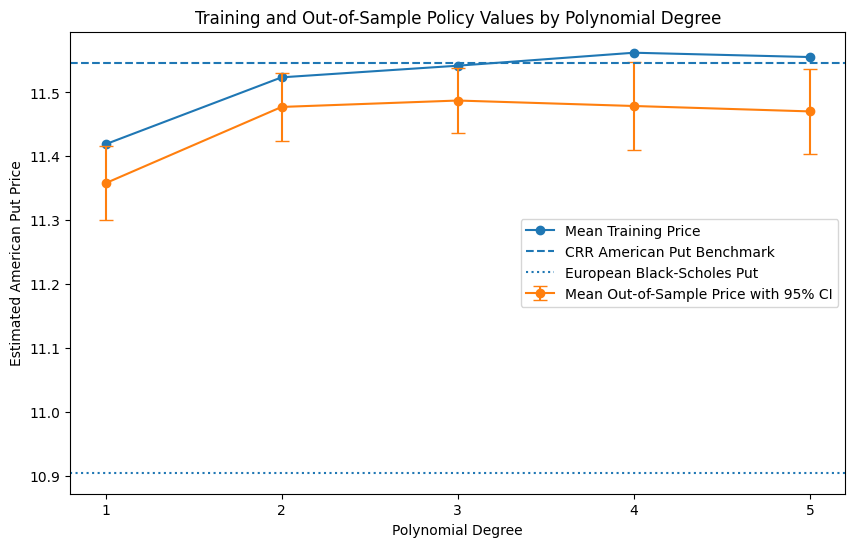

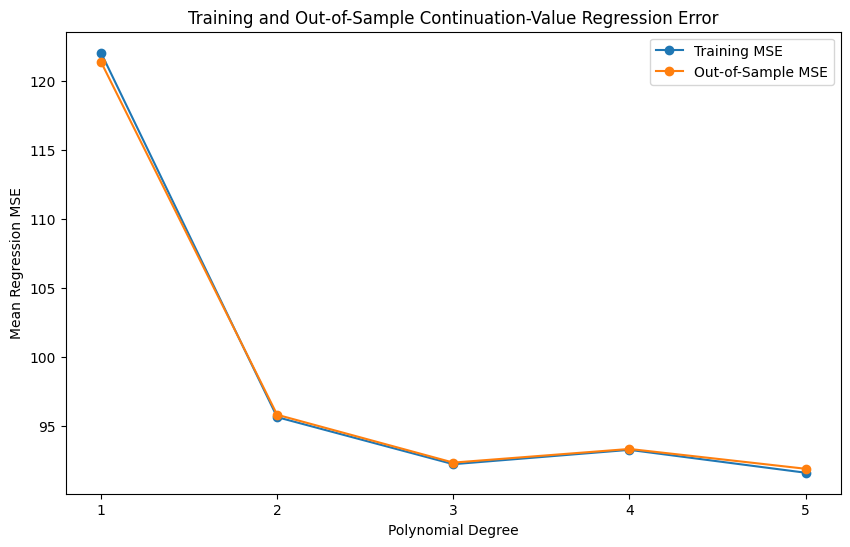

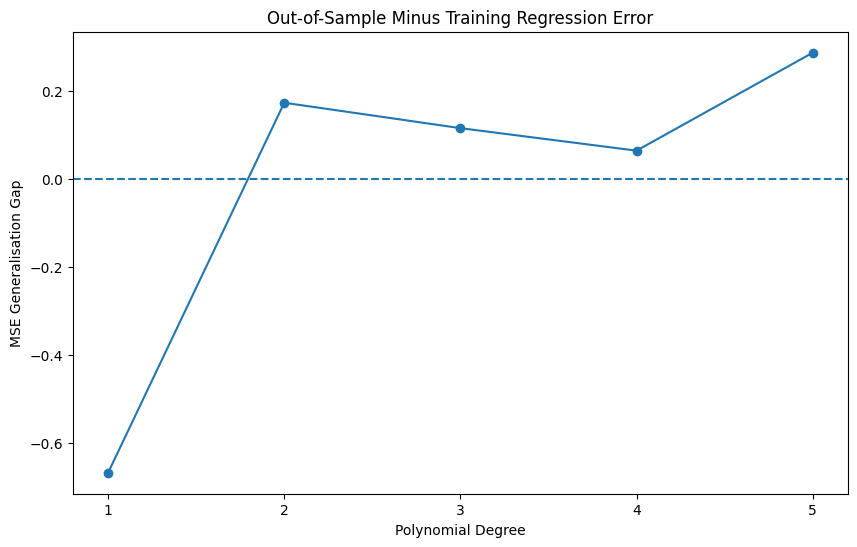

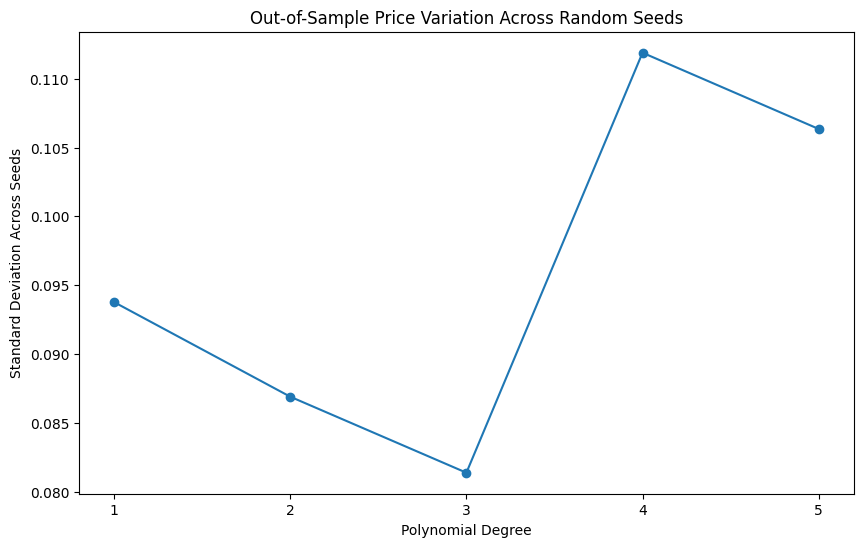

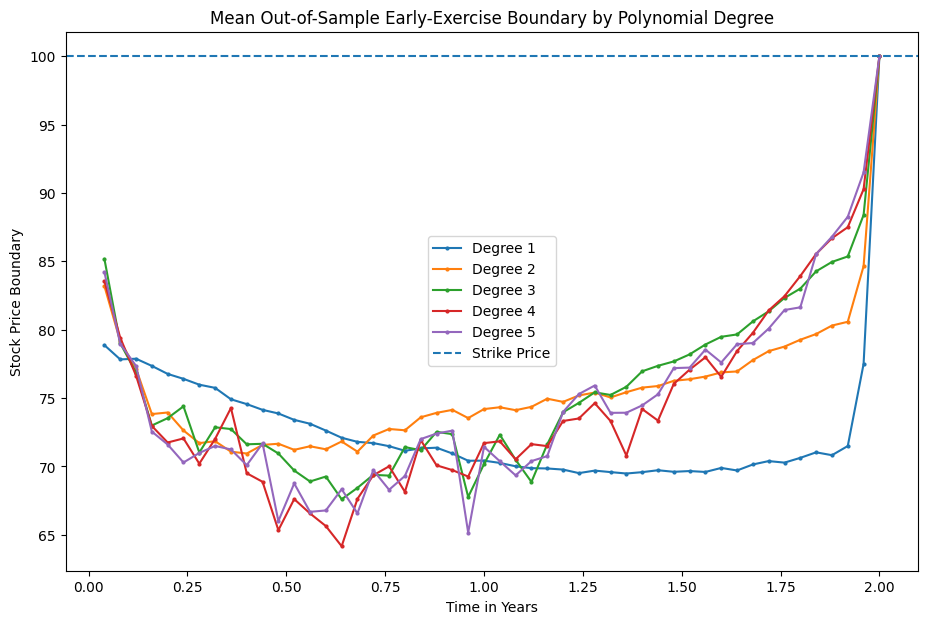

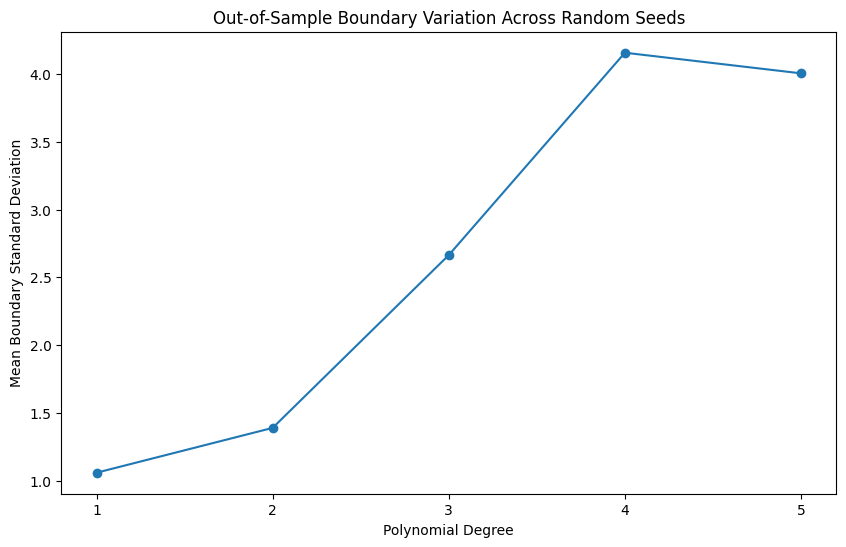

 OUT-OF-SAMPLE POLICY TEST SUMMARY 

Experiment settings:
Training paths per seed: 10000
Test paths per seed: 10000
Number of time intervals: 50
Polynomial degrees tested: [1, 2, 3, 4, 5]
Random seeds tested: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
CRR American put benchmark: 11.545709

Internal consistency:
All training discounting checks passed: True
All test discounting checks passed: True

Out-of-sample results:
Degree with lowest test regression MSE: 5
Degree with smallest MSE generalisation gap: 4
Degree with test price closest to CRR: 3
Degree with lowest out-of-sample price variation: 3
Degree with lowest out-of-sample boundary variation: 1

Interpretation:
All training and test valuations are internally consistent. A preferred regression degree should not be selected only because it has the lowest training error or the price closest to CRR. The strongest model should also maintain a low out-of-sample error, a small training-test gap, and a stable exercise boundary across random seeds.

In [9]:
#### PART 2D - OUT-OF-SAMPLE REGRESSION AND STOPPING-POLICY TEST ####

# Goal:
# 1. Fit each Longstaff-Schwartz regression model on training paths
# 2. Apply the fitted stopping policy to completely separate test paths
# 3. Compare in-sample and out-of-sample continuation-value errors
# 4. Compare training prices with out-of-sample policy values
# 5. Determine whether higher polynomial degrees perform well on new data or overfit the training data

# Important:
# - Training paths and test paths are separate
# - Each set contains 10,000 paths
# - Number of time intervals remains fixed at 50
# - Polynomial degrees 1 to 5 are compared
# - The same training and test paths are used for every degree within each random seed
# - No regression is refitted on the test paths

### EXPERIMENT SETTINGS

oos_training_paths = 10000
oos_test_paths = 10000
oos_total_paths = oos_training_paths + oos_test_paths
oos_n_steps = 50
oos_degrees = [1, 2, 3, 4, 5]
oos_seeds = list(range(1, 11))

### FIT LONGSTAFF-SCHWARTZ POLICY ON TRAINING PATHS

# Fit a Longstaff-Schwartz stopping policy using training paths
# The function works backwards through time and stores the polynomial continuation-value coefficients at every interval
# The stock-price input is scaled using x = S / K
# This returns fitted coefficients, training price, regression error, exercise boundary, and exercise information
def fit_lsm_polynomial_policy(training_paths, K, r, T, polynomial_degree):
    if polynomial_degree < 1:
        raise ValueError("polynomial_degree must be at least 1")

    number_of_training_paths = training_paths.shape[0]
    number_of_steps = training_paths.shape[1] - 1
    dt_training = T / number_of_steps
    discount_factor_training = np.exp(-r * dt_training)

    # Set cashflows at maturity
    training_cashflows = np.maximum(K - training_paths[:, -1], 0)

    # Initially, every path reaches maturity
    training_exercise_time = np.full(number_of_training_paths, number_of_steps, dtype=int)
    training_exercise_stock = training_paths[:, -1].copy()

    # Store fitted coefficients at every time step
    coefficients_by_time = {}

    # Store training boundaries
    training_boundary = np.full(number_of_steps + 1, np.nan)
    training_boundary[number_of_steps] = K

    # Store regression errors and condition numbers
    training_mse_by_time = {}
    condition_number_by_time = {}
    number_itm_by_time = {}

    # Work backwards through all early-exercise dates
    for t in range(number_of_steps - 1, 0, -1):
        current_stock_prices = training_paths[:, t]
        immediate_exercise_values = np.maximum(K - current_stock_prices, 0)
        discounted_future_cashflows = training_cashflows * discount_factor_training
        in_the_money = immediate_exercise_values > 0
        number_itm = int(np.sum(in_the_money))
        number_itm_by_time[t] = number_itm

        # If no training paths are in the money, no regression can be fitted at this time
        if number_itm == 0:
            coefficients_by_time[t] = None
            training_mse_by_time[t] = np.nan
            condition_number_by_time[t] = np.nan
            training_cashflows = discounted_future_cashflows
            continue

        stock_prices_itm = current_stock_prices[in_the_money]
        exercise_values_itm = immediate_exercise_values[in_the_money]
        continuation_targets_itm = discounted_future_cashflows[in_the_money]
        scaled_stock_prices_itm = stock_prices_itm / K

        training_design_matrix = np.polynomial.polynomial.polyvander(scaled_stock_prices_itm, polynomial_degree)
        condition_number_by_time[t] = np.linalg.cond(training_design_matrix)
        coefficients, *_ = np.linalg.lstsq(training_design_matrix, continuation_targets_itm, rcond=None)

        coefficients_by_time[t] = coefficients.copy()
        estimated_continuation_values = training_design_matrix @ coefficients
        training_mse_by_time[t] = np.mean((continuation_targets_itm - estimated_continuation_values)**2)

        exercise_now_itm = exercise_values_itm > estimated_continuation_values
        itm_indices = np.where(in_the_money)[0]
        exercise_indices = itm_indices[exercise_now_itm]

        # First assume every path continues
        training_cashflows = discounted_future_cashflows.copy()

        # Replace future cashflows with immediate exercise values where the fitted policy selects exercise
        training_cashflows[exercise_indices] = immediate_exercise_values[exercise_indices]
        training_exercise_time[exercise_indices] = t
        training_exercise_stock[exercise_indices] = current_stock_prices[exercise_indices]

        # Approximate sample boundary: highest training stock price classified as exercise
        if len(exercise_indices) > 0:
            training_boundary[t] = np.max(current_stock_prices[exercise_indices])

    # Discount Time_1 values back to Time_0
    training_continuation_value_time_0 = np.mean(training_cashflows) * discount_factor_training
    training_immediate_exercise_time_0 = max(K - training_paths[0, 0], 0)
    training_price = max(training_immediate_exercise_time_0, training_continuation_value_time_0)

    # Independently calculate the price using stored exercise times
    training_cashflow_at_exercise = np.maximum(K - training_exercise_stock, 0)
    training_present_values = (training_cashflow_at_exercise * np.exp(-r * training_exercise_time * dt_training))
    training_independent_price = np.mean(training_present_values)
    training_discounting_difference = abs(training_continuation_value_time_0 - training_independent_price)

    valid_training_mse = np.array([value for value in training_mse_by_time.values() if not np.isnan(value)])
    valid_condition_numbers = np.array([value for value in condition_number_by_time.values() if not np.isnan(value)])

    return {
        "Coefficients_By_Time": coefficients_by_time,
        "Training_Price": training_price,
        "Training_Independent_Price": training_independent_price,
        "Training_Discounting_Difference": training_discounting_difference,
        "Training_MSE_By_Time": training_mse_by_time,
        "Mean_Training_MSE": np.mean(valid_training_mse) if len(valid_training_mse) > 0 else np.nan,
        "Mean_Condition_Number": np.mean(valid_condition_numbers) if len(valid_condition_numbers) > 0 else np.nan,
        "Maximum_Condition_Number": np.max(valid_condition_numbers) if len(valid_condition_numbers) > 0 else np.nan,
        "Training_Boundary": training_boundary,
        "Training_Exercise_Time": training_exercise_time,
        "Training_Early_Exercise_Percentage": np.mean(training_exercise_time < number_of_steps) * 100
    }

### APPLY FITTED POLICY TO SEPARATE TEST PATHS

# Apply a previously fitted Longstaff-Schwartz stopping policy to separate test paths
# No regression coefficients are estimated using the test paths
# This returns the out-of-sample policy value, continuation-value MSE, test boundary, and final test exercise times
def evaluate_lsm_policy_out_of_sample(test_paths, K, r, T, polynomial_degree, coefficients_by_time):
    number_of_test_paths = test_paths.shape[0]
    number_of_steps = test_paths.shape[1] - 1
    dt_test = T / number_of_steps
    discount_factor_test = np.exp(-r * dt_test)

    # Initialise test-path cashflows at maturity
    test_cashflows = np.maximum(K - test_paths[:, -1], 0)
    test_exercise_time = np.full(number_of_test_paths, number_of_steps, dtype=int)
    test_exercise_stock = test_paths[:, -1].copy()

    test_boundary = np.full(number_of_steps + 1, np.nan)
    test_boundary[number_of_steps] = K

    test_mse_by_time = {}
    number_test_itm_by_time = {}

    # Work backwards using the coefficients fitted on the training paths
    for t in range(number_of_steps - 1, 0, -1):
        current_stock_prices = test_paths[:, t]
        immediate_exercise_values = np.maximum(K - current_stock_prices, 0)
        discounted_future_cashflows = test_cashflows * discount_factor_test
        in_the_money = immediate_exercise_values > 0
        number_test_itm = int(np.sum(in_the_money))
        number_test_itm_by_time[t] = number_test_itm
        fitted_coefficients = coefficients_by_time.get(t, None)

        # If there is no fitted model or no test paths are in the money, all test paths continue
        if fitted_coefficients is None or number_test_itm == 0:
            test_mse_by_time[t] = np.nan
            test_cashflows = discounted_future_cashflows
            continue

        stock_prices_itm = current_stock_prices[in_the_money]
        exercise_values_itm = immediate_exercise_values[in_the_money]
        continuation_targets_itm = discounted_future_cashflows[in_the_money]
        scaled_stock_prices_itm = stock_prices_itm / K

        test_design_matrix = np.polynomial.polynomial.polyvander(scaled_stock_prices_itm, polynomial_degree)

        estimated_continuation_values = test_design_matrix @ fitted_coefficients

        # Compare predictions from the training regression with continuation targets on separate test paths
        test_mse_by_time[t] = np.mean((continuation_targets_itm - estimated_continuation_values)**2)
        exercise_now_itm = exercise_values_itm > estimated_continuation_values
        itm_indices = np.where(in_the_money)[0]
        exercise_indices = itm_indices[exercise_now_itm]

        # First assume every test path continues
        test_cashflows = discounted_future_cashflows.copy()

        # Apply the trained stopping rule
        test_cashflows[exercise_indices] = immediate_exercise_values[exercise_indices]
        test_exercise_time[exercise_indices] = t
        test_exercise_stock[exercise_indices] = current_stock_prices[exercise_indices]

        if len(exercise_indices) > 0:
            test_boundary[t] = np.max(current_stock_prices[exercise_indices])

    # Discount from Time_1 to Time_0
    test_continuation_value_time_0 = np.mean(test_cashflows) * discount_factor_test
    test_immediate_exercise_time_0 = max(K - test_paths[0, 0], 0)
    out_of_sample_policy_price = max(test_immediate_exercise_time_0, test_continuation_value_time_0)

    # Independent discounting check
    test_cashflow_at_exercise = np.maximum(K - test_exercise_stock, 0)
    test_present_values = test_cashflow_at_exercise * np.exp(-r * test_exercise_time * dt_test)
    independent_test_price = np.mean(test_present_values)
    test_discounting_difference = abs(test_continuation_value_time_0 - independent_test_price)

    valid_test_mse = np.array([value for value in test_mse_by_time.values() if not np.isnan(value)])

    return {
        "Out_Of_Sample_Price": out_of_sample_policy_price,
        "Independent_Test_Price": independent_test_price,
        "Test_Discounting_Difference": test_discounting_difference,
        "Test_MSE_By_Time": test_mse_by_time,
        "Mean_Test_MSE": np.mean(valid_test_mse) if len(valid_test_mse) > 0 else np.nan,
        "Test_Boundary": test_boundary,
        "Test_Exercise_Time": test_exercise_time,
        "Test_Early_Exercise_Percentage": np.mean(test_exercise_time < number_of_steps) * 100,
        "Test_Present_Value_SD": np.std(test_present_values, ddof=1)
    }

### RUN TRAINING AND OUT-OF-SAMPLE EXPERIMENT

oos_comparison_rows = []
oos_test_boundaries = {degree: [] for degree in oos_degrees}

for seed in oos_seeds:

    # Generate one shared set of paths for this seed
    random_generator = np.random.default_rng(seed)
    all_random_shocks = random_generator.standard_normal(size=(oos_n_steps, oos_total_paths))
    all_simulated_paths = simulate_gbm_paths_from_shocks(S0=S0, r=r, sigma=sigma, T=T, random_shocks=all_random_shocks)

    # First half is used only for model fitting
    training_paths = all_simulated_paths[:oos_training_paths, :]

    # Second half is used only for out-of-sample evaluation
    test_paths = all_simulated_paths[oos_training_paths:, :]

    for degree in oos_degrees:
        fitted_policy = fit_lsm_polynomial_policy(training_paths=training_paths, K=K, r=r, T=T, polynomial_degree=degree)
        test_result = evaluate_lsm_policy_out_of_sample(
            test_paths=test_paths,
            K=K, r=r, T=T, polynomial_degree=degree, coefficients_by_time=fitted_policy["Coefficients_By_Time"]
        )

        training_price = fitted_policy["Training_Price"]
        out_of_sample_price = test_result["Out_Of_Sample_Price"]
        mean_training_mse = fitted_policy["Mean_Training_MSE"]
        mean_test_mse = test_result["Mean_Test_MSE"]

        oos_comparison_rows.append({
            "Seed": seed,
            "Polynomial_Degree": degree,
            "Training_Paths": oos_training_paths,
            "Test_Paths": oos_test_paths,
            "Number_Of_Time_Intervals": oos_n_steps,
            "Training_Price": training_price,
            "Out_Of_Sample_Policy_Price": out_of_sample_price,
            "Training_Minus_Test_Price": training_price - out_of_sample_price,
            "Test_Difference_From_CRR": out_of_sample_price - crr_american_put_price,
            "Absolute_Test_Difference_From_CRR": abs(out_of_sample_price - crr_american_put_price),
            "Mean_Training_MSE": mean_training_mse,
            "Mean_Test_MSE": mean_test_mse,
            "MSE_Generalisation_Gap": mean_test_mse - mean_training_mse,
            "Test_To_Training_MSE_Ratio": (mean_test_mse / mean_training_mse if mean_training_mse > 0 else np.nan),
            "Training_Early_Exercise_Percentage": fitted_policy["Training_Early_Exercise_Percentage"],
            "Test_Early_Exercise_Percentage": test_result["Test_Early_Exercise_Percentage"],
            "Mean_Condition_Number": fitted_policy["Mean_Condition_Number"],
            "Maximum_Condition_Number": fitted_policy["Maximum_Condition_Number"],
            "Training_Discounting_Difference": fitted_policy["Training_Discounting_Difference"],
            "Test_Discounting_Difference": test_result["Test_Discounting_Difference"]
        })

        oos_test_boundaries[degree].append(test_result["Test_Boundary"])

df_oos_comparison_all = pd.DataFrame(oos_comparison_rows)
display(df_oos_comparison_all.head(20))

### SUMMARISE OUT-OF-SAMPLE RESULTS BY DEGREE

df_oos_comparison_summary = (df_oos_comparison_all.groupby("Polynomial_Degree").agg(
        Mean_Training_Price=("Training_Price", "mean"),
        Mean_Out_Of_Sample_Price=("Out_Of_Sample_Policy_Price", "mean"),
        Out_Of_Sample_Price_SD=("Out_Of_Sample_Policy_Price", "std"),
        Mean_Training_Minus_Test_Price=("Training_Minus_Test_Price", "mean"),
        Mean_Test_Difference_From_CRR=("Test_Difference_From_CRR", "mean"),
        Mean_Absolute_Test_Difference_From_CRR=("Absolute_Test_Difference_From_CRR", "mean"),
        Mean_Training_MSE=("Mean_Training_MSE", "mean"),
        Mean_Test_MSE=("Mean_Test_MSE", "mean"),
        Mean_MSE_Generalisation_Gap=("MSE_Generalisation_Gap", "mean"),
        Mean_Test_To_Training_MSE_Ratio=("Test_To_Training_MSE_Ratio", "mean"),
        Mean_Training_Early_Exercise_Percentage=("Training_Early_Exercise_Percentage", "mean"),
        Mean_Test_Early_Exercise_Percentage=("Test_Early_Exercise_Percentage", "mean"),
        Mean_Condition_Number=("Mean_Condition_Number", "mean"),
        Maximum_Condition_Number=("Maximum_Condition_Number", "max"),
        Maximum_Training_Discounting_Difference=("Training_Discounting_Difference", "max"),
        Maximum_Test_Discounting_Difference=("Test_Discounting_Difference", "max")
    ).reset_index())

# Standard error and confidence interval for the out-of-sample policy price
df_oos_comparison_summary["Out_Of_Sample_Price_SE"] = (
    df_oos_comparison_summary["Out_Of_Sample_Price_SD"] / np.sqrt(len(oos_seeds))
)
df_oos_comparison_summary["Out_Of_Sample_CI_Lower"] = (
    df_oos_comparison_summary["Mean_Out_Of_Sample_Price"]
    - 1.96 * df_oos_comparison_summary["Out_Of_Sample_Price_SE"]
)
df_oos_comparison_summary["Out_Of_Sample_CI_Upper"] = (
    df_oos_comparison_summary["Mean_Out_Of_Sample_Price"]
    + 1.96 * df_oos_comparison_summary["Out_Of_Sample_Price_SE"]
)
df_oos_comparison_summary["Percentage_Test_Difference_From_CRR"] = (
    abs(df_oos_comparison_summary["Mean_Out_Of_Sample_Price"] - crr_american_put_price)
    / crr_american_put_price * 100
)

# Arrange the main columns
df_oos_comparison_summary = df_oos_comparison_summary[[
    "Polynomial_Degree",
    "Mean_Training_Price",
    "Mean_Out_Of_Sample_Price",
    "Out_Of_Sample_Price_SD",
    "Out_Of_Sample_Price_SE",
    "Out_Of_Sample_CI_Lower",
    "Out_Of_Sample_CI_Upper",
    "Mean_Training_Minus_Test_Price",
    "Mean_Test_Difference_From_CRR",
    "Mean_Absolute_Test_Difference_From_CRR",
    "Percentage_Test_Difference_From_CRR",
    "Mean_Training_MSE",
    "Mean_Test_MSE",
    "Mean_MSE_Generalisation_Gap",
    "Mean_Test_To_Training_MSE_Ratio",
    "Mean_Training_Early_Exercise_Percentage",
    "Mean_Test_Early_Exercise_Percentage",
    "Mean_Condition_Number",
    "Maximum_Condition_Number",
    "Maximum_Training_Discounting_Difference",
    "Maximum_Test_Discounting_Difference"
]]

display(df_oos_comparison_summary.round(6))

### CALCULATE OUT-OF-SAMPLE BOUNDARY STABILITY

oos_time_grid = np.linspace(0, T, oos_n_steps + 1)
mean_oos_boundary_by_degree = {}
oos_boundary_sd_by_degree = {}
oos_boundary_stability_rows = []

for degree in oos_degrees:
    boundary_matrix = np.array(oos_test_boundaries[degree])
    mean_boundary = np.full(oos_n_steps + 1, np.nan)
    boundary_sd = np.full(oos_n_steps + 1, np.nan)

    for boundary_index in range(oos_n_steps + 1):
        available_boundaries = boundary_matrix[:, boundary_index]
        available_boundaries = available_boundaries[~np.isnan(available_boundaries)]

        if len(available_boundaries) > 0:
            mean_boundary[boundary_index] = np.mean(available_boundaries)

        if len(available_boundaries) > 1:
            boundary_sd[boundary_index] = np.std(available_boundaries, ddof=1)

    mean_oos_boundary_by_degree[degree] = mean_boundary
    oos_boundary_sd_by_degree[degree] = boundary_sd
    valid_boundary_sd = boundary_sd[~np.isnan(boundary_sd)]

    oos_boundary_stability_rows.append({
        "Polynomial_Degree": degree,
        "Mean_Out_Of_Sample_Boundary_SD": (np.mean(valid_boundary_sd) if len(valid_boundary_sd) > 0 else np.nan),
        "Maximum_Out_Of_Sample_Boundary_SD": (np.max(valid_boundary_sd) if len(valid_boundary_sd) > 0 else np.nan),
        "Number_Of_Observed_Boundary_Dates": int(np.sum(~np.isnan(mean_boundary)))
    })

df_oos_boundary_stability = pd.DataFrame(oos_boundary_stability_rows)
display(df_oos_boundary_stability.round(6))

df_oos_comparison_summary = df_oos_comparison_summary.merge(df_oos_boundary_stability, on="Polynomial_Degree", how="left")
display(df_oos_comparison_summary.round(6))

### OUT-OF-SAMPLE CONSISTENCY CHECKS

all_training_discounting_checks_pass = np.allclose(
    df_oos_comparison_all["Training_Discounting_Difference"], 0, rtol=1e-9, atol=1e-9
)

all_test_discounting_checks_pass = np.allclose(
    df_oos_comparison_all["Test_Discounting_Difference"], 0, rtol=1e-9, atol=1e-9
)

# Find the degree with the lowest test regression error
best_test_mse_degree = int(df_oos_comparison_summary.loc[
        df_oos_comparison_summary["Mean_Test_MSE"].idxmin(), "Polynomial_Degree"
    ])

# Find the degree with the smallest MSE generalisation gap
smallest_generalisation_gap_degree = int(df_oos_comparison_summary.loc[
        df_oos_comparison_summary["Mean_MSE_Generalisation_Gap"].abs().idxmin(), "Polynomial_Degree"
    ])

# Find the degree with the out-of-sample price closest to the CRR benchmark
best_oos_price_degree = int(df_oos_comparison_summary.loc[
        (df_oos_comparison_summary["Mean_Out_Of_Sample_Price"] - crr_american_put_price).abs().idxmin(),
        "Polynomial_Degree"
    ])

# Find the degree with the lowest out-of-sample price variation across seeds
most_stable_oos_price_degree = int(df_oos_comparison_summary.loc[
        df_oos_comparison_summary["Out_Of_Sample_Price_SD"].idxmin(), "Polynomial_Degree"
    ])

# Find the degree with the most stable out-of-sample boundary
most_stable_oos_boundary_degree = int(df_oos_comparison_summary.loc[
        df_oos_comparison_summary["Mean_Out_Of_Sample_Boundary_SD"].idxmin(), "Polynomial_Degree"
    ])

### DISPLAY VISUALS

# Plot training and out-of-sample prices
plt.figure(figsize=(10, 6))
plt.plot(
    df_oos_comparison_summary["Polynomial_Degree"],
    df_oos_comparison_summary["Mean_Training_Price"],
    marker="o",
    label="Mean Training Price"
)
plt.errorbar(
    df_oos_comparison_summary["Polynomial_Degree"],
    df_oos_comparison_summary["Mean_Out_Of_Sample_Price"],
    yerr=(1.96 * df_oos_comparison_summary["Out_Of_Sample_Price_SE"]),
    marker="o",
    capsize=5,
    label="Mean Out-of-Sample Price with 95% CI"
)
plt.axhline(crr_american_put_price, linestyle="--", label="CRR American Put Benchmark")
plt.axhline(european_put_price, linestyle=":", label="European Black-Scholes Put")
plt.title("Training and Out-of-Sample Policy Values by Polynomial Degree")
plt.xlabel("Polynomial Degree")
plt.ylabel("Estimated American Put Price")
plt.xticks(oos_degrees)
plt.legend()
plt.show()

# Plot training and test regression MSE
plt.figure(figsize=(10, 6))
plt.plot(
    df_oos_comparison_summary["Polynomial_Degree"],
    df_oos_comparison_summary["Mean_Training_MSE"],
    marker="o",
    label="Training MSE"
)
plt.plot(
    df_oos_comparison_summary["Polynomial_Degree"],
    df_oos_comparison_summary["Mean_Test_MSE"],
    marker="o",
    label="Out-of-Sample MSE"
)
plt.title("Training and Out-of-Sample Continuation-Value Regression Error")
plt.xlabel("Polynomial Degree")
plt.ylabel("Mean Regression MSE")
plt.xticks(oos_degrees)
plt.legend()
plt.show()

# Plot MSE generalisation gap
plt.figure(figsize=(10, 6))
plt.plot(
    df_oos_comparison_summary["Polynomial_Degree"],
    df_oos_comparison_summary["Mean_MSE_Generalisation_Gap"],
    marker="o"
)
plt.axhline(0, linestyle="--")
plt.title("Out-of-Sample Minus Training Regression Error")
plt.xlabel("Polynomial Degree")
plt.ylabel("MSE Generalisation Gap")
plt.xticks(oos_degrees)
plt.show()

# Plot out-of-sample price stability
plt.figure(figsize=(10, 6))
plt.plot(
    df_oos_comparison_summary["Polynomial_Degree"],
    df_oos_comparison_summary["Out_Of_Sample_Price_SD"],
    marker="o"
)
plt.title("Out-of-Sample Price Variation Across Random Seeds")
plt.xlabel("Polynomial Degree")
plt.ylabel("Standard Deviation Across Seeds")
plt.xticks(oos_degrees)
plt.show()

# Plot out-of-sample exercise boundaries
plt.figure(figsize=(11, 7))
for degree in oos_degrees:
    plt.plot(
        oos_time_grid,
        mean_oos_boundary_by_degree[degree],
        marker="o",
        markersize=2,
        label=f"Degree {degree}"
    )
plt.axhline(K, linestyle="--", label="Strike Price")
plt.title("Mean Out-of-Sample Early-Exercise Boundary by Polynomial Degree")
plt.xlabel("Time in Years")
plt.ylabel("Stock Price Boundary")
plt.legend()
plt.show()

# Plot out-of-sample boundary variation
plt.figure(figsize=(10, 6))
plt.plot(
    df_oos_comparison_summary["Polynomial_Degree"],
    df_oos_comparison_summary["Mean_Out_Of_Sample_Boundary_SD"],
    marker="o"
)
plt.title("Out-of-Sample Boundary Variation Across Random Seeds")
plt.xlabel("Polynomial Degree")
plt.ylabel("Mean Boundary Standard Deviation")
plt.xticks(oos_degrees)
plt.show()

# Out-of-sample policy test summary
print(" OUT-OF-SAMPLE POLICY TEST SUMMARY ")

print("\nExperiment settings:")
print("Training paths per seed:", oos_training_paths)
print("Test paths per seed:", oos_test_paths)
print("Number of time intervals:", oos_n_steps)
print("Polynomial degrees tested:", oos_degrees)
print("Random seeds tested:", oos_seeds)
print("CRR American put benchmark:", round(crr_american_put_price, 6))

print("\nInternal consistency:")
print("All training discounting checks passed:", all_training_discounting_checks_pass)
print("All test discounting checks passed:", all_test_discounting_checks_pass)

print("\nOut-of-sample results:")
print("Degree with lowest test regression MSE:", best_test_mse_degree)
print("Degree with smallest MSE generalisation gap:", smallest_generalisation_gap_degree)
print("Degree with test price closest to CRR:", best_oos_price_degree)
print("Degree with lowest out-of-sample price variation:", most_stable_oos_price_degree)
print("Degree with lowest out-of-sample boundary variation:", most_stable_oos_boundary_degree)

print("\nInterpretation:")
if all_training_discounting_checks_pass and all_test_discounting_checks_pass:
    print(
        "All training and test valuations are internally consistent. A preferred regression degree should not be selected "
        "only because it has the lowest training error or the price closest to CRR. The strongest model should also maintain "
        "a low out-of-sample error, a small training-test gap, and a stable exercise boundary across random seeds."
    )
else:
    print(
        "At least one training or test discounting check failed. Review the results."
    )

,Seed,Laguerre_Order,Number_Of_Basis_Functions,Training_Paths,Test_Paths,Number_Of_Time_Intervals,Training_Price,Out_Of_Sample_Policy_Price,Training_Minus_Test_Price,Test_Difference_From_CRR,...,Mean_Training_MSE,Mean_Test_MSE,MSE_Generalisation_Gap,Test_To_Training_MSE_Ratio,Training_Early_Exercise_Percentage,Test_Early_Exercise_Percentage,Mean_Condition_Number,Maximum_Condition_Number,Training_Discounting_Difference,Test_Discounting_Difference
0,1,1,2,10000,10000,50,11.651918,11.512532,0.139387,-0.033178,...,98.975054,99.818305,0.843251,1.008520,43.52,42.88,1.047451e+01,3.453726e+01,7.105427e-15,8.881784e-15
1,1,2,3,10000,10000,50,11.600082,11.489481,0.110602,-0.056229,...,96.371896,96.644721,0.272826,1.002831,42.36,41.79,3.623977e+02,2.974737e+03,5.329071e-15,1.776357e-15
2,1,3,4,10000,10000,50,11.641169,11.512587,0.128582,-0.033122,...,92.224206,92.692923,0.468718,1.005082,44.64,44.19,2.643759e+04,4.309420e+05,5.329071e-15,5.329071e-15
3,1,4,5,10000,10000,50,11.667587,11.516918,0.150669,-0.028791,...,95.959370,96.658554,0.699185,1.007286,45.96,45.30,3.181252e+06,7.702467e+07,5.329071e-15,5.329071e-15
4,1,5,6,10000,10000,50,11.674100,11.484336,0.189763,-0.061373,...,96.107738,97.146953,1.039214,1.010813,47.66,46.68,5.610719e+08,1.718405e+10,7.105427e-15,3.552714e-15
5,2,1,2,10000,10000,50,11.328495,11.480078,-0.151583,-0.065631,...,97.832060,97.835545,0.003485,1.000036,42.79,43.40,1.045537e+01,3.415075e+01,3.552714e-15,7.105427e-15
6,2,2,3,10000,10000,50,11.324213,11.483763,-0.159549,-0.061947,...,94.612427,94.130589,-0.481837,0.994907,40.65,41.20,3.680790e+02,3.033660e+03,3.552714e-15,5.329071e-15
7,2,3,4,10000,10000,50,11.377993,11.511193,-0.133200,-0.034516,...,94.053750,93.404967,-0.648782,0.993102,42.34,43.03,2.736406e+04,4.398688e+05,3.552714e-15,7.105427e-15
8,2,4,5,10000,10000,50,11.368518,11.516846,-0.148328,-0.028864,...,91.700883,90.950817,-0.750066,0.991821,44.48,45.43,3.330475e+06,7.923199e+07,5.329071e-15,3.552714e-15
9,2,5,6,10000,10000,50,11.385772,11.527559,-0.141787,-0.018151,...,91.048026,90.713836,-0.334190,0.996330,45.34,46.20,5.739124e+08,1.709316e+10,3.552714e-15,3.552714e-15


,Laguerre_Order,Number_Of_Basis_Functions,Mean_Training_Price,Mean_Out_Of_Sample_Price,Out_Of_Sample_Price_SD,Mean_Training_Minus_Test_Price,Mean_Test_Difference_From_CRR,Mean_Absolute_Test_Difference_From_CRR,Mean_Training_MSE,Mean_Test_MSE,...,Mean_Training_Early_Exercise_Percentage,Mean_Test_Early_Exercise_Percentage,Mean_Condition_Number,Maximum_Condition_Number,Maximum_Training_Discounting_Difference,Maximum_Test_Discounting_Difference,Out_Of_Sample_Price_SE,Out_Of_Sample_CI_Lower,Out_Of_Sample_CI_Upper,Percentage_Test_Difference_From_CRR
0,1,2,11.509100,11.469422,0.090378,0.039678,-0.076288,0.081508,98.339775,98.477613,...,43.179,42.896,1.048227e+01,3.526549e+01,0.0,0.0,0.028580,11.413405,11.525438,0.660747
1,2,3,11.515361,11.470072,0.085009,0.045289,-0.075638,0.088696,95.556728,95.623574,...,41.682,41.409,3.682554e+02,3.237960e+03,0.0,0.0,0.026882,11.417383,11.522761,0.655115
2,3,4,11.539890,11.482884,0.090953,0.057006,-0.062825,0.072554,92.355066,92.518305,...,44.400,44.111,2.734404e+04,5.029355e+05,0.0,0.0,0.028762,11.426511,11.539258,0.544142
3,4,5,11.561247,11.487503,0.106144,0.073744,-0.058206,0.073839,92.932528,93.018525,...,45.861,45.633,3.337935e+06,1.048298e+08,0.0,0.0,0.033566,11.421714,11.553292,0.504139
4,5,6,11.561397,11.474105,0.102378,0.087292,-0.071605,0.085299,91.957199,92.121285,...,47.003,46.738,5.977853e+08,2.640716e+10,0.0,0.0,0.032375,11.410650,11.537559,0.620186


,Laguerre_Order,Number_Of_Basis_Functions,Mean_Training_Price,Mean_Out_Of_Sample_Price,Out_Of_Sample_Price_SD,Mean_Training_Minus_Test_Price,Mean_Test_Difference_From_CRR,Mean_Absolute_Test_Difference_From_CRR,Mean_Training_MSE,Mean_Test_MSE,...,Maximum_Condition_Number,Maximum_Training_Discounting_Difference,Maximum_Test_Discounting_Difference,Out_Of_Sample_Price_SE,Out_Of_Sample_CI_Lower,Out_Of_Sample_CI_Upper,Percentage_Test_Difference_From_CRR,Mean_Out_Of_Sample_Boundary_SD,Maximum_Out_Of_Sample_Boundary_SD,Number_Of_Observed_Boundary_Dates
0,1,2,11.509100,11.469422,0.090378,0.039678,-0.076288,0.081508,98.339775,98.477613,...,3.526549e+01,0.0,0.0,0.028580,11.413405,11.525438,0.660747,0.856495,1.936539,50
1,2,3,11.515361,11.470072,0.085009,0.045289,-0.075638,0.088696,95.556728,95.623574,...,3.237960e+03,0.0,0.0,0.026882,11.417383,11.522761,0.655115,1.364319,3.828711,50
2,3,4,11.539890,11.482884,0.090953,0.057006,-0.062825,0.072554,92.355066,92.518305,...,5.029355e+05,0.0,0.0,0.028762,11.426511,11.539258,0.544142,3.118445,10.531356,50
3,4,5,11.561247,11.487503,0.106144,0.073744,-0.058206,0.073839,92.932528,93.018525,...,1.048298e+08,0.0,0.0,0.033566,11.421714,11.553292,0.504139,3.908601,10.517559,50
4,5,6,11.561397,11.474105,0.102378,0.087292,-0.071605,0.085299,91.957199,92.121285,...,2.640716e+10,0.0,0.0,0.032375,11.410650,11.537559,0.620186,4.369120,10.463892,50


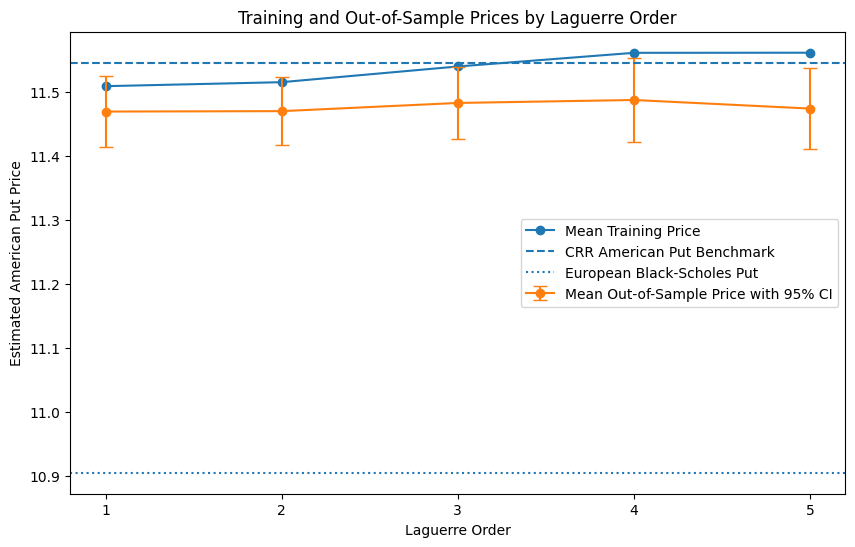

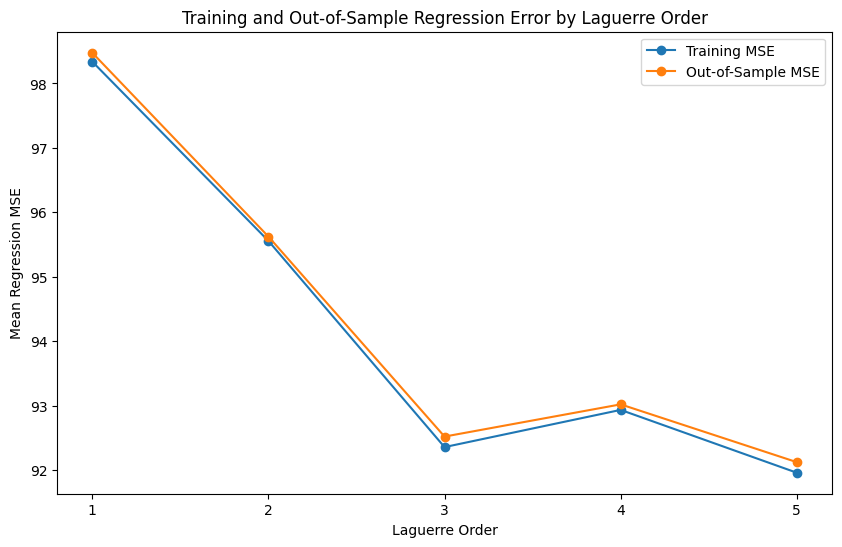

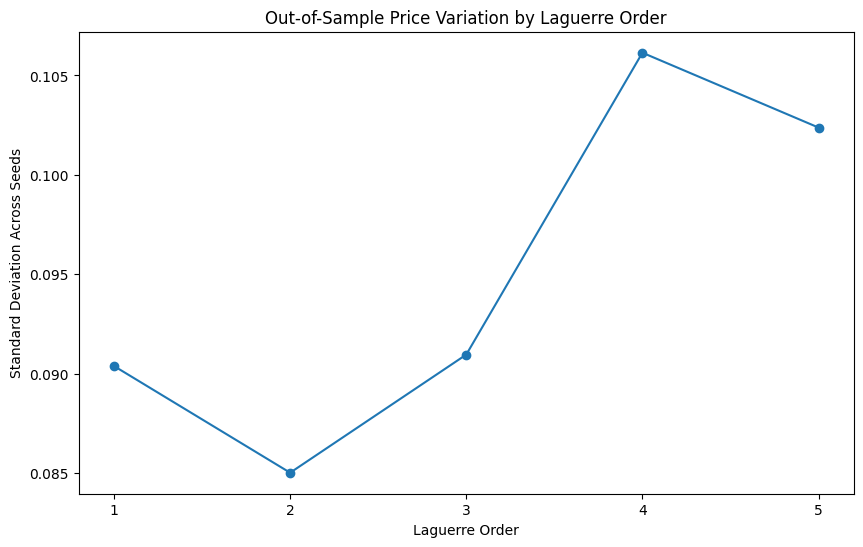

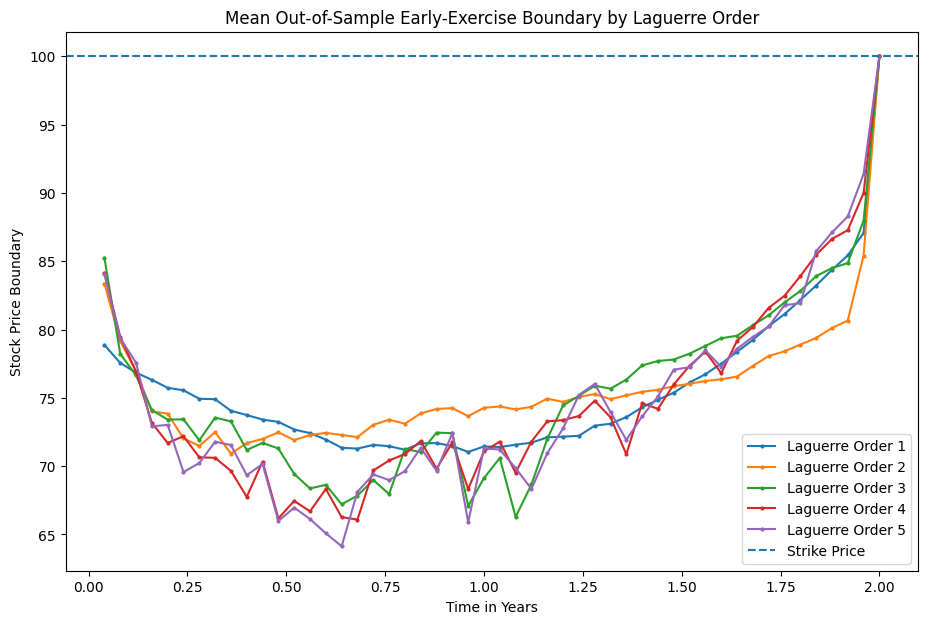

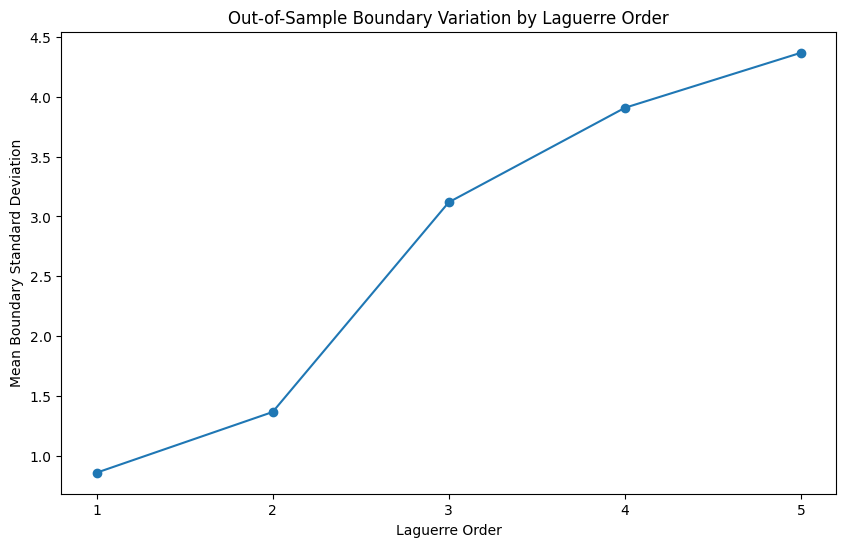

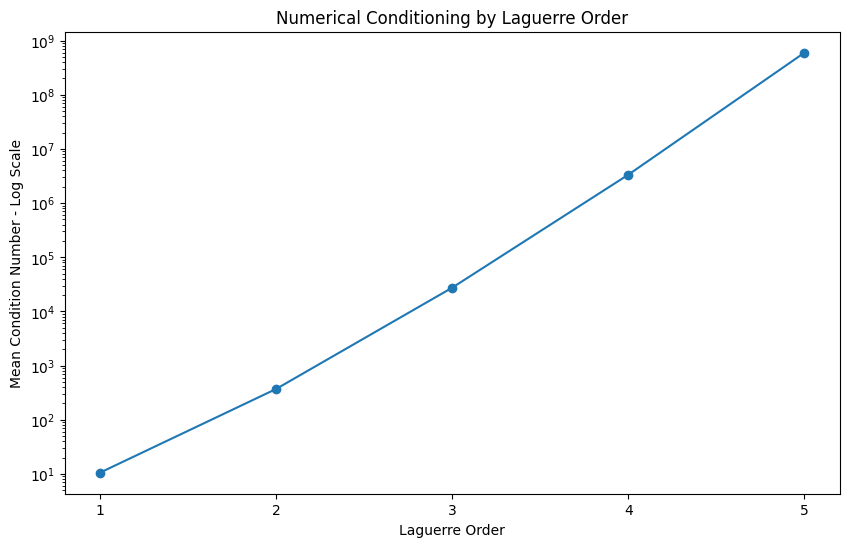

,Regression_Model,Basis_Type,Mean_Out_Of_Sample_Price,Absolute_Difference_From_CRR,Out_Of_Sample_Price_SD,Mean_Test_MSE,Mean_Boundary_SD,Mean_Condition_Number
0,Quadratic Polynomial,Ordinary polynomial,11.477311,0.068399,0.086907,95.839450,1.388772,3.707278e+02
1,Cubic Polynomial,Ordinary polynomial,11.487327,0.058383,0.081389,92.372289,2.663926,8.803849e+03
2,Weighted Laguerre Order 4,Weighted Laguerre,11.487503,0.058206,0.106144,93.018525,3.908601,3.337935e+06


 Laguerre Regression Comparison: 

Experiment settings:
Training paths per seed: 10000
Test paths per seed: 10000
Number of time intervals: 50
Laguerre orders tested: [1, 2, 3, 4, 5]
Random seeds tested: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Basis used: exp(-S / (2K)) * L_n(S / K)

Internal consistency:
All training discounting checks passed: True
All test discounting checks passed: True

Laguerre results:
Laguerre order with lowest test MSE: 5
Laguerre order with price closest to CRR: 4
Laguerre order with lowest price variation: 2
Laguerre order with lowest boundary variation: 1

Final Part 2 Basis Comparison: 
Model with price closest to CRR: Weighted Laguerre Order 4
Model with lowest out-of-sample price variation: Cubic Polynomial
Model with lowest test regression MSE: Cubic Polynomial
Model with most stable boundary: Quadratic Polynomial
Model with best numerical conditioning: Quadratic Polynomial

Interpretation:
The Laguerre models are internally consistent and can be compared direct

In [10]:
#### PART 2E - LAGUERRE BASIS REGRESSION AND OUT-OF-SAMPLE COMPARISON ####

# Goal:
# 1. Replace ordinary polynomial basis functions with Laguerre functions and compare Laguerre orders 1 through 5
# 2. Train the stopping policy on 10,000 paths
# 3. Evaluate the fitted policy on 10,000 separate test paths
# 4. Compare:
#    - option prices
#    - training and test regression errors
#    - price stability across random seeds
#    - exercise-boundary stability
#    - numerical conditioning
# 5. Compare the strongest Laguerre model with the previously selected quadratic and cubic polynomial models

# Important:
# - Number of time intervals remains fixed at 50
# - Training and test paths remain separate
# - The same simulated paths are used for every Laguerre order
# - No model is refitted using the test paths
# - Weighted Laguerre functions are used:
#       exp(-x / 2) * L_n(x)
#   where:
#       x = S / K
# - L_n(x) is the Laguerre polynomial of order n

### EXPERIMENT SETTINGS

laguerre_training_paths = 10000
laguerre_test_paths = 10000
laguerre_total_paths = laguerre_training_paths + laguerre_test_paths
laguerre_n_steps = 50
laguerre_orders = [1, 2, 3, 4, 5]
laguerre_seeds = list(range(1, 11))

### CREATE WEIGHTED LAGUERRE DESIGN MATRIX

# Create a weighted Laguerre regression design matrix
# The scaled input is x = S / K
# The basis functions are exp(-x / 2) * L_0(x), ..., exp(-x / 2) * L_order(x)
def weighted_laguerre_design_matrix(stock_prices, K, laguerre_order):
    if laguerre_order < 1:
        raise ValueError("laguerre_order must be at least 1")

    if K <= 0:
        raise ValueError("K must be greater than zero")

    scaled_stock_prices = stock_prices / K

    # Creates [L_0(x), L_1(x), ..., L_order(x)]
    laguerre_vandermonde = np.polynomial.laguerre.lagvander(scaled_stock_prices, laguerre_order)

    # Apply the standard exponential Laguerre weighting
    laguerre_weight = np.exp(-scaled_stock_prices / 2)
    weighted_matrix = laguerre_vandermonde * laguerre_weight[:, None]

    return weighted_matrix

### FIT LAGUERRE STOPPING POLICY ON TRAINING PATHS

# Fit a Longstaff-Schwartz stopping policy using weighted Laguerre basis functions
# This returns fitted coefficients, training price, regression error, numerical-conditioning diagnostics,
# training exercise boundary, and training exercise information
def fit_lsm_laguerre_policy(training_paths, K, r, T, laguerre_order):
    number_of_training_paths = training_paths.shape[0]
    number_of_steps = training_paths.shape[1] - 1
    dt_training = T / number_of_steps
    discount_factor_training = np.exp(-r * dt_training)

    # Set cashflows at maturity
    training_cashflows = np.maximum(K - training_paths[:, -1], 0)

    # Initially, every path reaches maturity
    training_exercise_time = np.full(number_of_training_paths, number_of_steps, dtype=int)
    training_exercise_stock = training_paths[:, -1].copy()

    # Store fitted Laguerre coefficients at each time
    coefficients_by_time = {}

    # Store approximate training exercise boundary
    training_boundary = np.full(number_of_steps + 1, np.nan)
    training_boundary[number_of_steps] = K

    # Store regression results
    training_mse_by_time = {}
    condition_number_by_time = {}
    number_itm_by_time = {}

    # Work backwards through all possible exercise dates
    for t in range(number_of_steps - 1, 0, -1):
        current_stock_prices = training_paths[:, t]
        immediate_exercise_values = np.maximum(K - current_stock_prices, 0)
        discounted_future_cashflows = training_cashflows * discount_factor_training
        in_the_money = immediate_exercise_values > 0
        number_itm = int(np.sum(in_the_money))
        number_itm_by_time[t] = number_itm

        # If no paths are in the money, no regression is fitted
        if number_itm == 0:
            coefficients_by_time[t] = None
            training_mse_by_time[t] = np.nan
            condition_number_by_time[t] = np.nan
            training_cashflows = discounted_future_cashflows
            continue

        stock_prices_itm = current_stock_prices[in_the_money]
        exercise_values_itm = immediate_exercise_values[in_the_money]
        continuation_targets_itm = discounted_future_cashflows[in_the_money]

        # Create weighted Laguerre basis
        training_design_matrix = weighted_laguerre_design_matrix(
            stock_prices=stock_prices_itm, K=K, laguerre_order=laguerre_order
        )

        # Numerical condition number
        condition_number_by_time[t] = np.linalg.cond(training_design_matrix)

        # Least-squares regression
        coefficients, *_ = np.linalg.lstsq(training_design_matrix, continuation_targets_itm, rcond=None)
        coefficients_by_time[t] = coefficients.copy()
        estimated_continuation_values = training_design_matrix @ coefficients

        # In-sample continuation-value regression error
        training_mse_by_time[t] = np.mean((continuation_targets_itm - estimated_continuation_values)**2)

        # Exercise when immediate payoff exceeds estimated continuation value
        exercise_now_itm = exercise_values_itm > estimated_continuation_values
        itm_indices = np.where(in_the_money)[0]
        exercise_indices = itm_indices[exercise_now_itm]

        # First assume every path continues
        training_cashflows = discounted_future_cashflows.copy()

        # Replace future cashflow with immediate exercise payoff
        training_cashflows[exercise_indices] = immediate_exercise_values[exercise_indices]

        # Earlier decisions replace later decisions
        training_exercise_time[exercise_indices] = t
        training_exercise_stock[exercise_indices] = current_stock_prices[exercise_indices]

        # Approximate sample-based boundary
        if len(exercise_indices) > 0:
            training_boundary[t] = np.max(current_stock_prices[exercise_indices])

    # Discount Time_1 values back to Time_0
    training_continuation_value_time_0 = np.mean(training_cashflows) * discount_factor_training
    training_immediate_exercise_time_0 = max(K - training_paths[0, 0], 0)
    training_price = max(training_immediate_exercise_time_0, training_continuation_value_time_0)

    # Independent price calculation using stored exercise times
    training_cashflow_at_exercise = np.maximum(K - training_exercise_stock, 0)
    training_present_values = (training_cashflow_at_exercise * np.exp(-r * training_exercise_time * dt_training))
    training_independent_price = np.mean(training_present_values)
    training_discounting_difference = abs(training_continuation_value_time_0 - training_independent_price)

    valid_training_mse = np.array([value for value in training_mse_by_time.values() if not np.isnan(value)])
    valid_condition_numbers = np.array([value for value in condition_number_by_time.values() if not np.isnan(value)])

    return {
        "Coefficients_By_Time": coefficients_by_time,
        "Training_Price": training_price,
        "Training_Independent_Price": training_independent_price,
        "Training_Discounting_Difference": training_discounting_difference,
        "Training_MSE_By_Time": training_mse_by_time,
        "Mean_Training_MSE": np.mean(valid_training_mse) if len(valid_training_mse) > 0 else np.nan,
        "Mean_Condition_Number": np.mean(valid_condition_numbers) if len(valid_condition_numbers) > 0 else np.nan,
        "Maximum_Condition_Number": np.max(valid_condition_numbers) if len(valid_condition_numbers) > 0 else np.nan,
        "Training_Boundary": training_boundary,
        "Training_Exercise_Time": training_exercise_time,
        "Training_Early_Exercise_Percentage": np.mean(training_exercise_time < number_of_steps) * 100
    }

### APPLY LAGUERRE POLICY TO SEPARATE TEST PATHS

# Apply a Laguerre stopping policy fitted on training paths to completely separate test paths
# No coefficients are estimated using the test paths
def evaluate_laguerre_policy_out_of_sample(test_paths, K, r, T, laguerre_order, coefficients_by_time):
    number_of_test_paths = test_paths.shape[0]
    number_of_steps = test_paths.shape[1] - 1
    dt_test = T / number_of_steps
    discount_factor_test = np.exp(-r * dt_test)

    # Set test cashflows at maturity
    test_cashflows = np.maximum(K - test_paths[:, -1], 0)
    test_exercise_time = np.full(number_of_test_paths, number_of_steps, dtype=int)
    test_exercise_stock = test_paths[:, -1].copy()

    test_boundary = np.full(number_of_steps + 1, np.nan)
    test_boundary[number_of_steps] = K

    test_mse_by_time = {}

    # Work backwards using only coefficients fitted from the training sample
    for t in range(number_of_steps - 1, 0, -1):
        current_stock_prices = test_paths[:, t]
        immediate_exercise_values = np.maximum(K - current_stock_prices, 0)
        discounted_future_cashflows = test_cashflows * discount_factor_test
        in_the_money = immediate_exercise_values > 0
        number_test_itm = int(np.sum(in_the_money))
        fitted_coefficients = coefficients_by_time.get(t, None)

        if fitted_coefficients is None or number_test_itm == 0:
            test_mse_by_time[t] = np.nan
            test_cashflows = discounted_future_cashflows
            continue

        stock_prices_itm = current_stock_prices[in_the_money]
        exercise_values_itm = immediate_exercise_values[in_the_money]
        continuation_targets_itm = discounted_future_cashflows[in_the_money]

        test_design_matrix = weighted_laguerre_design_matrix(
            stock_prices=stock_prices_itm, K=K, laguerre_order=laguerre_order
        )

        estimated_continuation_values = test_design_matrix @ fitted_coefficients

        # Out-of-sample continuation-value error
        test_mse_by_time[t] = np.mean((continuation_targets_itm - estimated_continuation_values)**2)

        exercise_now_itm = exercise_values_itm > estimated_continuation_values
        itm_indices = np.where(in_the_money)[0]
        exercise_indices = itm_indices[exercise_now_itm]

        # First assume every path continues
        test_cashflows = discounted_future_cashflows.copy()

        # Apply trained stopping policy
        test_cashflows[exercise_indices] = immediate_exercise_values[exercise_indices]
        test_exercise_time[exercise_indices] = t
        test_exercise_stock[exercise_indices] = current_stock_prices[exercise_indices]

        if len(exercise_indices) > 0:
            test_boundary[t] = np.max(current_stock_prices[exercise_indices])

    # Discount from Time_1 to Time_0
    test_continuation_value_time_0 = np.mean(test_cashflows) * discount_factor_test
    test_immediate_exercise_time_0 = max(K - test_paths[0, 0], 0)
    out_of_sample_policy_price = max(test_immediate_exercise_time_0, test_continuation_value_time_0)

    # Independent discounting check
    test_cashflow_at_exercise = np.maximum(K - test_exercise_stock, 0)
    test_present_values = test_cashflow_at_exercise * np.exp(-r * test_exercise_time * dt_test)
    independent_test_price = np.mean(test_present_values)
    test_discounting_difference = abs(test_continuation_value_time_0 - independent_test_price)

    valid_test_mse = np.array([value for value in test_mse_by_time.values() if not np.isnan(value)])

    return {
        "Out_Of_Sample_Price": out_of_sample_policy_price,
        "Independent_Test_Price": independent_test_price,
        "Test_Discounting_Difference": test_discounting_difference,
        "Mean_Test_MSE": np.mean(valid_test_mse) if len(valid_test_mse) > 0 else np.nan,
        "Test_Boundary": test_boundary,
        "Test_Exercise_Time": test_exercise_time,
        "Test_Early_Exercise_Percentage": np.mean(test_exercise_time < number_of_steps) * 100,
        "Test_Present_Value_SD": np.std(test_present_values, ddof=1)
    }

### RUN LAGUERRE TRAINING AND TEST EXPERIMENT

laguerre_comparison_rows = []
laguerre_test_boundaries = {order: [] for order in laguerre_orders}

for seed in laguerre_seeds:

    # Generate one common set of paths for this seed
    random_generator = np.random.default_rng(seed)
    all_random_shocks = random_generator.standard_normal(size=(laguerre_n_steps, laguerre_total_paths))
    all_simulated_paths = simulate_gbm_paths_from_shocks(S0=S0, r=r, sigma=sigma, T=T, random_shocks=all_random_shocks)

    training_paths = all_simulated_paths[:laguerre_training_paths, :]
    test_paths = all_simulated_paths[laguerre_training_paths:, :]

    for order in laguerre_orders:
        fitted_policy = fit_lsm_laguerre_policy(training_paths=training_paths, K=K, r=r, T=T, laguerre_order=order)
        test_result = evaluate_laguerre_policy_out_of_sample(
            test_paths=test_paths,
            K=K, r=r, T=T, laguerre_order=order, coefficients_by_time=fitted_policy["Coefficients_By_Time"]
        )

        training_price = fitted_policy["Training_Price"]
        test_price = test_result["Out_Of_Sample_Price"]
        training_mse = fitted_policy["Mean_Training_MSE"]
        test_mse = test_result["Mean_Test_MSE"]

        laguerre_comparison_rows.append({
            "Seed": seed,
            "Laguerre_Order": order,
            "Number_Of_Basis_Functions": order + 1,
            "Training_Paths": laguerre_training_paths,
            "Test_Paths": laguerre_test_paths,
            "Number_Of_Time_Intervals": laguerre_n_steps,
            "Training_Price": training_price,
            "Out_Of_Sample_Policy_Price": test_price,
            "Training_Minus_Test_Price": training_price - test_price,
            "Test_Difference_From_CRR": test_price - crr_american_put_price,
            "Absolute_Test_Difference_From_CRR": abs(test_price - crr_american_put_price),
            "Mean_Training_MSE": training_mse,
            "Mean_Test_MSE": test_mse,
            "MSE_Generalisation_Gap": test_mse - training_mse,
            "Test_To_Training_MSE_Ratio": (test_mse / training_mse if training_mse > 0 else np.nan),
            "Training_Early_Exercise_Percentage": fitted_policy["Training_Early_Exercise_Percentage"],
            "Test_Early_Exercise_Percentage": test_result["Test_Early_Exercise_Percentage"],
            "Mean_Condition_Number": fitted_policy["Mean_Condition_Number"],
            "Maximum_Condition_Number": fitted_policy["Maximum_Condition_Number"],
            "Training_Discounting_Difference": fitted_policy["Training_Discounting_Difference"],
            "Test_Discounting_Difference": test_result["Test_Discounting_Difference"]
        })

        laguerre_test_boundaries[order].append(test_result["Test_Boundary"])

df_laguerre_comparison_all = pd.DataFrame(laguerre_comparison_rows)
display(df_laguerre_comparison_all.head(20))

### SUMMARISE LAGUERRE RESULTS BY ORDER

df_laguerre_comparison_summary = (df_laguerre_comparison_all.groupby("Laguerre_Order").agg(
        Number_Of_Basis_Functions=("Number_Of_Basis_Functions", "first"),
        Mean_Training_Price=("Training_Price", "mean"),
        Mean_Out_Of_Sample_Price=("Out_Of_Sample_Policy_Price", "mean"),
        Out_Of_Sample_Price_SD=("Out_Of_Sample_Policy_Price", "std"),
        Mean_Training_Minus_Test_Price=("Training_Minus_Test_Price", "mean"),
        Mean_Test_Difference_From_CRR=("Test_Difference_From_CRR", "mean"),
        Mean_Absolute_Test_Difference_From_CRR=("Absolute_Test_Difference_From_CRR", "mean"),
        Mean_Training_MSE=("Mean_Training_MSE", "mean"),
        Mean_Test_MSE=("Mean_Test_MSE", "mean"),
        Mean_MSE_Generalisation_Gap=("MSE_Generalisation_Gap", "mean"),
        Mean_Test_To_Training_MSE_Ratio=("Test_To_Training_MSE_Ratio", "mean"),
        Mean_Training_Early_Exercise_Percentage=("Training_Early_Exercise_Percentage", "mean"),
        Mean_Test_Early_Exercise_Percentage=("Test_Early_Exercise_Percentage", "mean"),
        Mean_Condition_Number=("Mean_Condition_Number", "mean"),
        Maximum_Condition_Number=("Maximum_Condition_Number", "max"),
        Maximum_Training_Discounting_Difference=("Training_Discounting_Difference", "max"),
        Maximum_Test_Discounting_Difference=("Test_Discounting_Difference", "max")
    ).reset_index())

# Standard error and 95% confidence interval
df_laguerre_comparison_summary["Out_Of_Sample_Price_SE"] = (
    df_laguerre_comparison_summary["Out_Of_Sample_Price_SD"] / np.sqrt(len(laguerre_seeds))
)
df_laguerre_comparison_summary["Out_Of_Sample_CI_Lower"] = (
    df_laguerre_comparison_summary["Mean_Out_Of_Sample_Price"] - 1.96 * df_laguerre_comparison_summary["Out_Of_Sample_Price_SE"]
)
df_laguerre_comparison_summary["Out_Of_Sample_CI_Upper"] = (
    df_laguerre_comparison_summary["Mean_Out_Of_Sample_Price"] + 1.96 * df_laguerre_comparison_summary["Out_Of_Sample_Price_SE"]
)
df_laguerre_comparison_summary["Percentage_Test_Difference_From_CRR"] = (
    abs(df_laguerre_comparison_summary["Mean_Out_Of_Sample_Price"] - crr_american_put_price) / crr_american_put_price * 100
)
display(df_laguerre_comparison_summary.round(6))

### CALCULATE LAGUERRE BOUNDARY STABILITY

laguerre_time_grid = np.linspace(0, T, laguerre_n_steps + 1)
mean_laguerre_boundary_by_order = {}
laguerre_boundary_sd_by_order = {}
laguerre_boundary_stability_rows = []

for order in laguerre_orders:
    boundary_matrix = np.array(laguerre_test_boundaries[order])
    mean_boundary = np.full(laguerre_n_steps + 1, np.nan)
    boundary_sd = np.full(laguerre_n_steps + 1, np.nan)

    for boundary_index in range(laguerre_n_steps + 1):
        available_boundaries = boundary_matrix[:, boundary_index]
        available_boundaries = available_boundaries[~np.isnan(available_boundaries)]

        if len(available_boundaries) > 0:
            mean_boundary[boundary_index] = np.mean(available_boundaries)

        if len(available_boundaries) > 1:
            boundary_sd[boundary_index] = np.std(available_boundaries, ddof=1)

    mean_laguerre_boundary_by_order[order] = mean_boundary
    laguerre_boundary_sd_by_order[order] = boundary_sd
    valid_boundary_sd = boundary_sd[~np.isnan(boundary_sd)]

    laguerre_boundary_stability_rows.append({
        "Laguerre_Order": order,
        "Mean_Out_Of_Sample_Boundary_SD": (np.mean(valid_boundary_sd) if len(valid_boundary_sd) > 0 else np.nan),
        "Maximum_Out_Of_Sample_Boundary_SD": (np.max(valid_boundary_sd) if len(valid_boundary_sd) > 0 else np.nan),
        "Number_Of_Observed_Boundary_Dates": int(np.sum(~np.isnan(mean_boundary)))
    })
df_laguerre_boundary_stability = pd.DataFrame(laguerre_boundary_stability_rows)

df_laguerre_comparison_summary = df_laguerre_comparison_summary.merge(df_laguerre_boundary_stability, on="Laguerre_Order", how="left")
display(df_laguerre_comparison_summary.round(6))

### LAGUERRE CONSISTENCY CHECKS

all_laguerre_training_discounting_checks_pass = np.allclose(
    df_laguerre_comparison_all["Training_Discounting_Difference"], 0, rtol=1e-9, atol=1e-9
)

all_laguerre_test_discounting_checks_pass = np.allclose(
    df_laguerre_comparison_all["Test_Discounting_Difference"], 0, rtol=1e-9, atol=1e-9
)

best_laguerre_test_mse_order = int(df_laguerre_comparison_summary.loc[
        df_laguerre_comparison_summary["Mean_Test_MSE"].idxmin(), "Laguerre_Order"
    ])

best_laguerre_price_order = int(df_laguerre_comparison_summary.loc[
        (df_laguerre_comparison_summary["Mean_Out_Of_Sample_Price"] - crr_american_put_price).abs().idxmin(),
        "Laguerre_Order"
    ])

most_stable_laguerre_price_order = int(df_laguerre_comparison_summary.loc[
        df_laguerre_comparison_summary["Out_Of_Sample_Price_SD"].idxmin(), "Laguerre_Order"
    ])

most_stable_laguerre_boundary_order = int(df_laguerre_comparison_summary.loc[
        df_laguerre_comparison_summary["Mean_Out_Of_Sample_Boundary_SD"].idxmin(), "Laguerre_Order"
    ])

### DISPLAY VISUALS

# Plot Laguerre training and test prices
plt.figure(figsize=(10, 6))
plt.plot(
    df_laguerre_comparison_summary["Laguerre_Order"],
    df_laguerre_comparison_summary["Mean_Training_Price"],
    marker="o",
    label="Mean Training Price"
)
plt.errorbar(
    df_laguerre_comparison_summary["Laguerre_Order"],
    df_laguerre_comparison_summary["Mean_Out_Of_Sample_Price"],
    yerr=(1.96 * df_laguerre_comparison_summary["Out_Of_Sample_Price_SE"]),
    marker="o",
    capsize=5,
    label="Mean Out-of-Sample Price with 95% CI"
)
plt.axhline(crr_american_put_price, linestyle="--", label="CRR American Put Benchmark")
plt.axhline(european_put_price, linestyle=":", label="European Black-Scholes Put")
plt.title("Training and Out-of-Sample Prices by Laguerre Order")
plt.xlabel("Laguerre Order")
plt.ylabel("Estimated American Put Price")
plt.xticks(laguerre_orders)
plt.legend()
plt.show()

# Plot Laguerre training and test MSE
plt.figure(figsize=(10, 6))
plt.plot(
    df_laguerre_comparison_summary["Laguerre_Order"],
    df_laguerre_comparison_summary["Mean_Training_MSE"],
    marker="o",
    label="Training MSE"
)
plt.plot(
    df_laguerre_comparison_summary["Laguerre_Order"],
    df_laguerre_comparison_summary["Mean_Test_MSE"],
    marker="o",
    label="Out-of-Sample MSE"
)
plt.title("Training and Out-of-Sample Regression Error by Laguerre Order")
plt.xlabel("Laguerre Order")
plt.ylabel("Mean Regression MSE")
plt.xticks(laguerre_orders)
plt.legend()
plt.show()

# Plot Laguerre price stability
plt.figure(figsize=(10, 6))
plt.plot(
    df_laguerre_comparison_summary["Laguerre_Order"],
    df_laguerre_comparison_summary["Out_Of_Sample_Price_SD"],
    marker="o"
)
plt.title("Out-of-Sample Price Variation by Laguerre Order")
plt.xlabel("Laguerre Order")
plt.ylabel("Standard Deviation Across Seeds")
plt.xticks(laguerre_orders)
plt.show()

# Plot Laguerre exercise boundaries
plt.figure(figsize=(11, 7))
for order in laguerre_orders:
    plt.plot(
        laguerre_time_grid,
        mean_laguerre_boundary_by_order[order],
        marker="o",
        markersize=2,
        label=f"Laguerre Order {order}"
    )
plt.axhline(K, linestyle="--", label="Strike Price")
plt.title("Mean Out-of-Sample Early-Exercise Boundary by Laguerre Order")
plt.xlabel("Time in Years")
plt.ylabel("Stock Price Boundary")
plt.legend()
plt.show()

# Plot Laguerre boundary variability
plt.figure(figsize=(10, 6))
plt.plot(
    df_laguerre_comparison_summary["Laguerre_Order"],
    df_laguerre_comparison_summary["Mean_Out_Of_Sample_Boundary_SD"],
    marker="o"
)
plt.title("Out-of-Sample Boundary Variation by Laguerre Order")
plt.xlabel("Laguerre Order")
plt.ylabel("Mean Boundary Standard Deviation")
plt.xticks(laguerre_orders)
plt.show()

# Plot Laguerre numerical conditioning
plt.figure(figsize=(10, 6))
plt.plot(
    df_laguerre_comparison_summary["Laguerre_Order"],
    df_laguerre_comparison_summary["Mean_Condition_Number"],
    marker="o"
)
plt.yscale("log")
plt.title("Numerical Conditioning by Laguerre Order")
plt.xlabel("Laguerre Order")
plt.ylabel("Mean Condition Number - Log Scale")
plt.xticks(laguerre_orders)
plt.show()

### COMPARE POLYNOMIAL AND LAGUERRE MODELS

# Select quadratic and cubic polynomial results from Part 5
quadratic_polynomial_row = df_oos_comparison_summary[
    df_oos_comparison_summary["Polynomial_Degree"] == 2
].iloc[0]

cubic_polynomial_row = df_oos_comparison_summary[
    df_oos_comparison_summary["Polynomial_Degree"] == 3
].iloc[0]

# Select the Laguerre model whose out-of-sample price is closest to the CRR benchmark
best_laguerre_row = df_laguerre_comparison_summary[
    df_laguerre_comparison_summary["Laguerre_Order"] == best_laguerre_price_order
].iloc[0]

df_final_basis_comparison = pd.DataFrame({
    "Regression_Model": [
        "Quadratic Polynomial",
        "Cubic Polynomial",
        f"Weighted Laguerre Order {best_laguerre_price_order}"
    ],
    "Basis_Type": [
        "Ordinary polynomial",
        "Ordinary polynomial",
        "Weighted Laguerre"
    ],
    "Mean_Out_Of_Sample_Price": [
        quadratic_polynomial_row["Mean_Out_Of_Sample_Price"],
        cubic_polynomial_row["Mean_Out_Of_Sample_Price"],
        best_laguerre_row["Mean_Out_Of_Sample_Price"]
    ],
    "Absolute_Difference_From_CRR": [
        abs(quadratic_polynomial_row["Mean_Out_Of_Sample_Price"] - crr_american_put_price),
        abs(cubic_polynomial_row["Mean_Out_Of_Sample_Price"] - crr_american_put_price),
        abs(best_laguerre_row["Mean_Out_Of_Sample_Price"] - crr_american_put_price)
    ],
    "Out_Of_Sample_Price_SD": [
        quadratic_polynomial_row["Out_Of_Sample_Price_SD"],
        cubic_polynomial_row["Out_Of_Sample_Price_SD"],
        best_laguerre_row["Out_Of_Sample_Price_SD"]
    ],
    "Mean_Test_MSE": [
        quadratic_polynomial_row["Mean_Test_MSE"],
        cubic_polynomial_row["Mean_Test_MSE"],
        best_laguerre_row["Mean_Test_MSE"]
    ],
    "Mean_Boundary_SD": [
        quadratic_polynomial_row["Mean_Out_Of_Sample_Boundary_SD"],
        cubic_polynomial_row["Mean_Out_Of_Sample_Boundary_SD"],
        best_laguerre_row["Mean_Out_Of_Sample_Boundary_SD"]
    ],
    "Mean_Condition_Number": [
        quadratic_polynomial_row["Mean_Condition_Number"],
        cubic_polynomial_row["Mean_Condition_Number"],
        best_laguerre_row["Mean_Condition_Number"]
    ]
})
display(df_final_basis_comparison.round(6))

### SELECT STRONGEST MODEL BY EACH CRITERION

best_final_price_model = df_final_basis_comparison.loc[
    df_final_basis_comparison["Absolute_Difference_From_CRR"].idxmin(), "Regression_Model"
]

most_stable_final_price_model = df_final_basis_comparison.loc[
    df_final_basis_comparison["Out_Of_Sample_Price_SD"].idxmin(), "Regression_Model"
]

lowest_final_test_mse_model = df_final_basis_comparison.loc[
    df_final_basis_comparison["Mean_Test_MSE"].idxmin(), "Regression_Model"
]

most_stable_final_boundary_model = df_final_basis_comparison.loc[
    df_final_basis_comparison["Mean_Boundary_SD"].idxmin(), "Regression_Model"
]

best_conditioned_final_model = df_final_basis_comparison.loc[
    df_final_basis_comparison["Mean_Condition_Number"].idxmin(), "Regression_Model"
]

# Laguerre regression and final Part 2 comparison summary
print(" Laguerre Regression Comparison: ")

print("\nExperiment settings:")
print("Training paths per seed:", laguerre_training_paths)
print("Test paths per seed:", laguerre_test_paths)
print("Number of time intervals:", laguerre_n_steps)
print("Laguerre orders tested:", laguerre_orders)
print("Random seeds tested:", laguerre_seeds)
print("Basis used: exp(-S / (2K)) * L_n(S / K)")

print("\nInternal consistency:")
print("All training discounting checks passed:", all_laguerre_training_discounting_checks_pass)
print("All test discounting checks passed:", all_laguerre_test_discounting_checks_pass)

print("\nLaguerre results:")
print("Laguerre order with lowest test MSE:", best_laguerre_test_mse_order)
print("Laguerre order with price closest to CRR:", best_laguerre_price_order)
print("Laguerre order with lowest price variation:", most_stable_laguerre_price_order)
print("Laguerre order with lowest boundary variation:", most_stable_laguerre_boundary_order)

print("\nFinal Part 2 Basis Comparison: ")
print("Model with price closest to CRR:", best_final_price_model)
print("Model with lowest out-of-sample price variation:", most_stable_final_price_model)
print("Model with lowest test regression MSE:", lowest_final_test_mse_model)
print("Model with most stable boundary:", most_stable_final_boundary_model)
print("Model with best numerical conditioning:", best_conditioned_final_model)

print("\nInterpretation:")
if all_laguerre_training_discounting_checks_pass and all_laguerre_test_discounting_checks_pass:
    print(
        "The Laguerre models are internally consistent and can be compared directly with the quadratic and cubic "
        "polynomial models. The preferred model should balance out-of-sample price accuracy, price stability, boundary "
        "stability, regression error, and numerical conditioning."
    )
else:
    print(
        "At least one Laguerre discounting check failed. Review the results."
    )

In [11]:
#### OVERALL REGRESSION MODEL SELECTION ####

# Goal:
# 1. Combine the polynomial and Laguerre results
# 2. Rank every model by pricing accuracy, out-of-sample performance, boundary stability, and numerical conditioning
# 3. Select the strongest overall polynomial and Laguerre models directly from the numerical results

### PREPARE POLYNOMIAL RESULTS

df_polynomial_overall = df_oos_comparison_summary[[
    "Polynomial_Degree",
    "Mean_Out_Of_Sample_Price",
    "Out_Of_Sample_Price_SD",
    "Mean_Test_MSE",
    "Mean_Out_Of_Sample_Boundary_SD",
    "Mean_Condition_Number"
]].copy()

df_polynomial_overall["Regression_Model"] = "Polynomial Degree " + df_polynomial_overall["Polynomial_Degree"].astype(str)
df_polynomial_overall["Basis_Type"] = "Ordinary Polynomial"
df_polynomial_overall["Model_Order"] = df_polynomial_overall["Polynomial_Degree"]
df_polynomial_overall = df_polynomial_overall.drop(columns="Polynomial_Degree")

### PREPARE LAGUERRE RESULTS

df_laguerre_overall = df_laguerre_comparison_summary[[
    "Laguerre_Order",
    "Mean_Out_Of_Sample_Price",
    "Out_Of_Sample_Price_SD",
    "Mean_Test_MSE",
    "Mean_Out_Of_Sample_Boundary_SD",
    "Mean_Condition_Number"
]].copy()

df_laguerre_overall["Regression_Model"] = "Weighted Laguerre Order " + df_laguerre_overall["Laguerre_Order"].astype(str)
df_laguerre_overall["Basis_Type"] = "Weighted Laguerre"
df_laguerre_overall["Model_Order"] = df_laguerre_overall["Laguerre_Order"]
df_laguerre_overall = df_laguerre_overall.drop(columns="Laguerre_Order")

### COMBINE ALL REGRESSION MODELS

df_regression_overall_summary = pd.concat([df_polynomial_overall, df_laguerre_overall], ignore_index=True)

# Calculate absolute out-of-sample pricing error relative to the CRR benchmark
df_regression_overall_summary["Absolute_Difference_From_CRR"] = (
    df_regression_overall_summary["Mean_Out_Of_Sample_Price"] - crr_american_put_price
).abs()

### RANK INDIVIDUAL PERFORMANCE METRICS

# Lower values are preferred for every metric
df_regression_overall_summary["Price_Accuracy_Rank"] = (
    df_regression_overall_summary["Absolute_Difference_From_CRR"].rank(method="average")
)
df_regression_overall_summary["Price_Stability_Rank"] = (
    df_regression_overall_summary["Out_Of_Sample_Price_SD"].rank(method="average")
)
df_regression_overall_summary["Test_MSE_Rank"] = (
    df_regression_overall_summary["Mean_Test_MSE"].rank(method="average")
)
df_regression_overall_summary["Boundary_Stability_Rank"] = (
    df_regression_overall_summary["Mean_Out_Of_Sample_Boundary_SD"].rank(method="average")
)
df_regression_overall_summary["Numerical_Conditioning_Rank"] = (
    df_regression_overall_summary["Mean_Condition_Number"].rank(method="average")
)

### CREATE DOMAIN RANKS

# Out-of-sample performance combines price stability and regression generalisation
df_regression_overall_summary["Out_Of_Sample_Performance_Rank"] = (
    df_regression_overall_summary[["Price_Stability_Rank", "Test_MSE_Rank"]].mean(axis=1)
)

### DEFINE MODEL-SELECTION WEIGHTS

# Pricing accuracy and out-of-sample performance receive the greatest weight
# Boundary stability remains important, while numerical conditioning is a secondary check
price_weight = 0.35
out_of_sample_weight = 0.30
boundary_weight = 0.25
conditioning_weight = 0.10

### CALCULATE OVERALL BALANCE SCORE

df_regression_overall_summary["Overall_Balance_Score"] = (
    price_weight * df_regression_overall_summary["Price_Accuracy_Rank"]
    + out_of_sample_weight * df_regression_overall_summary["Out_Of_Sample_Performance_Rank"]
    + boundary_weight * df_regression_overall_summary["Boundary_Stability_Rank"]
    + conditioning_weight * df_regression_overall_summary["Numerical_Conditioning_Rank"]
)

df_regression_overall_summary["Overall_Balance_Rank"] = (
    df_regression_overall_summary["Overall_Balance_Score"].rank(method="min").astype(int)
)

### SORT FINAL RESULTS

df_regression_overall_summary = (
    df_regression_overall_summary.sort_values(["Overall_Balance_Rank", "Overall_Balance_Score"]).reset_index(drop=True)
)

### SELECT MODELS FROM THE NUMERICAL RANKING

best_overall_model = df_regression_overall_summary.iloc[0]["Regression_Model"]

best_polynomial_model = (
    df_regression_overall_summary[df_regression_overall_summary["Basis_Type"] == "Ordinary Polynomial"]
    .iloc[0]["Regression_Model"]
)

best_laguerre_model = (
    df_regression_overall_summary[df_regression_overall_summary["Basis_Type"] == "Weighted Laguerre"]
    .iloc[0]["Regression_Model"]
)

best_polynomial_degree = int(
    df_regression_overall_summary.loc[df_regression_overall_summary["Regression_Model"] == best_polynomial_model,
        "Model_Order"
    ].iloc[0]
)

best_laguerre_order = int(
    df_regression_overall_summary.loc[df_regression_overall_summary["Regression_Model"] == best_laguerre_model,
        "Model_Order"
    ].iloc[0]
)

### CREATE COMPACT FINAL COMPARISON TABLE

df_regression_overall_ranking = df_regression_overall_summary[[
    "Overall_Balance_Rank",
    "Regression_Model",
    "Mean_Out_Of_Sample_Price",
    "Absolute_Difference_From_CRR",
    "Out_Of_Sample_Price_SD",
    "Mean_Test_MSE",
    "Mean_Out_Of_Sample_Boundary_SD",
    "Mean_Condition_Number",
    "Price_Accuracy_Rank",
    "Out_Of_Sample_Performance_Rank",
    "Boundary_Stability_Rank",
    "Numerical_Conditioning_Rank",
    "Overall_Balance_Score"
]].copy()

### DISPLAY RESULTS

display(df_regression_overall_ranking.round(6))

print(" Overall Regression Model Selection: ")

print("\nSelection method:")
print("Pricing accuracy weight:", price_weight)
print("Out-of-sample performance weight:", out_of_sample_weight)
print("Boundary stability weight:", boundary_weight)
print("Numerical conditioning weight:", conditioning_weight)
print("Lower overall balance score is better: True")

print("\nNumerically selected models:")
print("Strongest overall regression model:", best_overall_model)
print("Strongest polynomial model:", best_polynomial_model)
print("Strongest Laguerre model:", best_laguerre_model)
print("Selected polynomial degree for later sensitivity analysis:", best_polynomial_degree)
print("Selected Laguerre order for later sensitivity analysis:", best_laguerre_order)

print("\nBest model by individual criterion:")
print("Price closest to CRR:", df_regression_overall_summary.loc[
        df_regression_overall_summary["Absolute_Difference_From_CRR"].idxmin(), "Regression_Model"
    ])
print("Lowest out-of-sample price variation:", df_regression_overall_summary.loc[
        df_regression_overall_summary["Out_Of_Sample_Price_SD"].idxmin(), "Regression_Model"
    ])
print(
    "Lowest test regression MSE:", df_regression_overall_summary.loc[
        df_regression_overall_summary["Mean_Test_MSE"].idxmin(), "Regression_Model"
    ])
print(
    "Most stable boundary:", df_regression_overall_summary.loc[
        df_regression_overall_summary["Mean_Out_Of_Sample_Boundary_SD"].idxmin(), "Regression_Model"
    ])
print(
    "Best numerical conditioning:", df_regression_overall_summary.loc[
        df_regression_overall_summary["Mean_Condition_Number"].idxmin(), "Regression_Model"
    ])

print("\nInterpretation:")
print(
    "Pricing accuracy and out-of-sample performance receive the greatest weight because they measure valuation accuracy and performance on new data. "
    "Boundary stability is also important, while numerical stability is used as a secondary check. "
    "The model with the lowest weighted score provides the best overall balance across the selection criteria."
)

,Overall_Balance_Rank,Regression_Model,Mean_Out_Of_Sample_Price,Absolute_Difference_From_CRR,Out_Of_Sample_Price_SD,Mean_Test_MSE,Mean_Out_Of_Sample_Boundary_SD,Mean_Condition_Number,Price_Accuracy_Rank,Out_Of_Sample_Performance_Rank,Boundary_Stability_Rank,Numerical_Conditioning_Rank,Overall_Balance_Score
0,1,Polynomial Degree 3,11.487327,0.058383,0.081389,92.372289,2.663926,8.803849e+03,2.0,2.0,5.0,5.0,3.05
1,2,Weighted Laguerre Order 3,11.482884,0.062825,0.090953,92.518305,3.118445,2.734404e+04,3.0,4.5,6.0,6.0,4.50
2,3,Polynomial Degree 2,11.477311,0.068399,0.086907,95.839450,1.388772,3.707278e+02,5.0,5.5,4.0,4.0,4.80
3,4,Weighted Laguerre Order 4,11.487503,0.058206,0.106144,93.018525,3.908601,3.337935e+06,1.0,6.5,7.0,8.0,4.85
4,5,Weighted Laguerre Order 2,11.470072,0.075638,0.085009,95.623574,1.364319,3.682554e+02,8.0,4.5,3.0,3.0,5.20
5,6,Weighted Laguerre Order 1,11.469422,0.076288,0.090378,98.477613,0.856495,1.048227e+01,9.0,6.5,1.0,1.0,5.45
6,7,Polynomial Degree 1,11.357906,0.187804,0.093774,121.403558,1.057845,1.835417e+01,10.0,8.0,2.0,2.0,6.60
7,8,Polynomial Degree 4,11.478776,0.066934,0.111882,93.361174,4.157330,2.601356e+05,4.0,8.0,9.0,7.0,6.75
8,9,Polynomial Degree 5,11.470304,0.075406,0.106346,91.925954,4.005164,9.327193e+06,7.0,5.0,8.0,9.0,6.85
9,10,Weighted Laguerre Order 5,11.474105,0.071605,0.102378,92.121285,4.369120,5.977853e+08,6.0,4.5,10.0,10.0,6.95


 Overall Regression Model Selection: 

Selection method:
Pricing accuracy weight: 0.35
Out-of-sample performance weight: 0.3
Boundary stability weight: 0.25
Numerical conditioning weight: 0.1
Lower overall balance score is better: True

Numerically selected models:
Strongest overall regression model: Polynomial Degree 3
Strongest polynomial model: Polynomial Degree 3
Strongest Laguerre model: Weighted Laguerre Order 3
Selected polynomial degree for later sensitivity analysis: 3
Selected Laguerre order for later sensitivity analysis: 3

Best model by individual criterion:
Price closest to CRR: Weighted Laguerre Order 4
Lowest out-of-sample price variation: Polynomial Degree 3
Lowest test regression MSE: Polynomial Degree 5
Most stable boundary: Weighted Laguerre Order 1
Best numerical conditioning: Weighted Laguerre Order 1

Interpretation:
Pricing accuracy and out-of-sample performance receive the greatest weight because they measure valuation accuracy and performance on new data. Boun

## Part 3 - Sensitivity Analysis (Greeks)

,Seed,Regression_Model,Basis_Type,Regression_Order,Stock_Price_Bump,Base_Price,Upper_Stock_Price,Upper_Price,Lower_Stock_Price,Lower_Price,Delta,Gamma,Base_Early_Exercise_Percentage,Maximum_Discounting_Difference
0,1,Quadratic Polynomial,Polynomial,2,0.25,11.730486,100.25,11.640766,99.75,11.841956,-0.402380,0.347985,40.48,5.329071e-15
1,1,Quadratic Polynomial,Polynomial,2,0.50,11.730486,100.50,11.538251,99.50,11.933861,-0.395610,0.044557,40.48,5.329071e-15
2,1,Quadratic Polynomial,Polynomial,2,1.00,11.730486,101.00,11.349734,99.00,12.112096,-0.381181,0.000857,40.48,7.105427e-15
3,1,Quadratic Polynomial,Polynomial,2,2.00,11.730486,102.00,10.951988,98.00,12.528384,-0.394099,0.004850,40.48,5.329071e-15
4,1,Cubic Polynomial,Polynomial,3,0.25,11.791037,100.25,11.701121,99.75,11.881941,-0.361640,0.015808,43.99,5.329071e-15
5,1,Cubic Polynomial,Polynomial,3,0.50,11.791037,100.50,11.610289,99.50,11.976525,-0.366235,0.018961,43.99,3.552714e-15
6,1,Cubic Polynomial,Polynomial,3,1.00,11.791037,101.00,11.402887,99.00,12.158722,-0.377918,-0.020464,43.99,5.329071e-15
7,1,Cubic Polynomial,Polynomial,3,2.00,11.791037,102.00,11.020419,98.00,12.560473,-0.385013,-0.000295,43.99,5.329071e-15
8,1,Weighted Laguerre Order 3,Laguerre,3,0.25,11.794193,100.25,11.682246,99.75,11.873120,-0.381747,-0.528318,43.63,7.105427e-15
9,1,Weighted Laguerre Order 3,Laguerre,3,0.50,11.794193,100.50,11.569416,99.50,11.982028,-0.412612,-0.147769,43.63,7.105427e-15


,Regression_Model,Stock_Price_Bump,Mean_Base_Price,Mean_Delta,Delta_SD_Across_Seeds,Minimum_Delta,Maximum_Delta,Mean_Gamma,Gamma_SD_Across_Seeds,Minimum_Gamma,Maximum_Gamma,Maximum_Discounting_Difference,Delta_Standard_Error,Gamma_Standard_Error,Gamma_Coefficient_Of_Variation
0,Cubic Polynomial,0.25,11.531225,-0.398952,0.039903,-0.470957,-0.336574,-0.048080,0.243187,-0.577544,0.206526,0.0,0.012618,0.076903,5.057927
1,Cubic Polynomial,0.50,11.531225,-0.390331,0.024025,-0.427757,-0.353970,-0.030071,0.090687,-0.237045,0.121986,0.0,0.007597,0.028678,3.015817
2,Cubic Polynomial,1.00,11.531225,-0.390996,0.010666,-0.406452,-0.377918,0.001144,0.034324,-0.043755,0.067625,0.0,0.003373,0.010854,30.006564
3,Cubic Polynomial,2.00,11.531225,-0.395468,0.010704,-0.410417,-0.376423,0.009532,0.010539,-0.007996,0.029808,0.0,0.003385,0.003333,1.105608
4,Quadratic Polynomial,0.25,11.511453,-0.411473,0.029456,-0.466895,-0.376564,-0.129072,0.291636,-0.577055,0.347985,0.0,0.009315,0.092223,2.259486
5,Quadratic Polynomial,0.50,11.511453,-0.398410,0.011214,-0.422206,-0.382534,-0.007216,0.084023,-0.157773,0.112272,0.0,0.003546,0.026570,11.644084
6,Quadratic Polynomial,1.00,11.511453,-0.396222,0.013192,-0.420443,-0.377226,0.002913,0.029847,-0.059095,0.034838,0.0,0.004172,0.009438,10.244794
7,Quadratic Polynomial,2.00,11.511453,-0.398590,0.008207,-0.416119,-0.386479,0.008989,0.007063,-0.001057,0.017303,0.0,0.002595,0.002233,0.785772
8,Weighted Laguerre Order 3,0.25,11.536059,-0.385679,0.023669,-0.423972,-0.353243,-0.219198,0.473450,-0.976065,0.536013,0.0,0.007485,0.149718,2.159916
9,Weighted Laguerre Order 3,0.50,11.536059,-0.388991,0.019181,-0.412612,-0.354556,-0.023305,0.120996,-0.151494,0.212229,0.0,0.006066,0.038262,5.191799


,Seed,Regression_Model,Basis_Type,Regression_Order,Volatility_Bump,Upper_Volatility,Upper_Price,Lower_Volatility,Lower_Price,Vega_Per_Unit_Volatility,Vega_Per_One_Percentage_Point,Maximum_Discounting_Difference
0,1,Quadratic Polynomial,Polynomial,2,0.0025,0.2525,11.875979,0.2475,11.605936,54.008698,0.540087,7.105427e-15
1,1,Quadratic Polynomial,Polynomial,2,0.0050,0.2550,12.017339,0.2450,11.462801,55.453722,0.554537,5.329071e-15
2,1,Quadratic Polynomial,Polynomial,2,0.0100,0.2600,12.271816,0.2400,11.193886,53.896537,0.538965,7.105427e-15
3,1,Cubic Polynomial,Polynomial,3,0.0025,0.2525,11.914716,0.2475,11.654028,52.137620,0.521376,5.329071e-15
4,1,Cubic Polynomial,Polynomial,3,0.0050,0.2550,12.049404,0.2450,11.525766,52.363788,0.523638,8.881784e-15
5,1,Cubic Polynomial,Polynomial,3,0.0100,0.2600,12.319992,0.2400,11.243249,53.837154,0.538372,7.105427e-15
6,1,Weighted Laguerre Order 3,Laguerre,3,0.0025,0.2525,11.940101,0.2475,11.663911,55.237840,0.552378,7.105427e-15
7,1,Weighted Laguerre Order 3,Laguerre,3,0.0050,0.2550,12.071258,0.2450,11.517698,55.356032,0.553560,7.105427e-15
8,1,Weighted Laguerre Order 3,Laguerre,3,0.0100,0.2600,12.321182,0.2400,11.242153,53.951474,0.539515,3.552714e-15
9,2,Quadratic Polynomial,Polynomial,2,0.0025,0.2525,11.576636,0.2475,11.304997,54.327825,0.543278,7.105427e-15


,Regression_Model,Volatility_Bump,Mean_Vega_Per_Unit_Volatility,Vega_SD_Across_Seeds,Minimum_Vega,Maximum_Vega,Mean_Vega_Per_One_Percentage_Point,Maximum_Discounting_Difference,Vega_Standard_Error,Vega_Coefficient_Of_Variation
0,Cubic Polynomial,0.0025,53.558840,3.563416,46.134250,59.062455,0.535588,0.0,1.126851,0.066533
1,Cubic Polynomial,0.0050,53.151451,1.375079,50.084278,54.734144,0.531515,0.0,0.434838,0.025871
2,Cubic Polynomial,0.0100,52.822024,0.700355,52.019076,53.986084,0.528220,0.0,0.221472,0.013259
3,Quadratic Polynomial,0.0025,54.063423,2.133064,49.284322,56.529217,0.540634,0.0,0.674534,0.039455
4,Quadratic Polynomial,0.0050,53.693763,1.342434,51.500631,55.453722,0.536938,0.0,0.424515,0.025002
5,Quadratic Polynomial,0.0100,53.637737,0.724406,51.987458,54.465505,0.536377,0.0,0.229077,0.013506
6,Weighted Laguerre Order 3,0.0025,53.906708,2.331915,49.817575,57.763553,0.539067,0.0,0.737416,0.043258
7,Weighted Laguerre Order 3,0.0050,53.449662,1.149321,51.727102,55.356032,0.534497,0.0,0.363447,0.021503
8,Weighted Laguerre Order 3,0.0100,52.863439,0.773253,51.561573,53.951474,0.528634,0.0,0.244524,0.014627


,Regression_Model,Mean_Base_Price,Mean_Delta,Delta_SD_Across_Seeds,Mean_Gamma,Gamma_SD_Across_Seeds,Gamma_Coefficient_Of_Variation,Mean_Vega_Per_Unit_Volatility,Mean_Vega_Per_One_Percentage_Point,Vega_SD_Across_Seeds,Vega_Coefficient_Of_Variation
0,Cubic Polynomial,11.531225,-0.390996,0.010666,0.001144,0.034324,30.006564,53.151451,0.531515,1.375079,0.025871
1,Quadratic Polynomial,11.511453,-0.396222,0.013192,0.002913,0.029847,10.244794,53.693763,0.536938,1.342434,0.025002
2,Weighted Laguerre Order 3,11.536059,-0.390225,0.010894,-0.004018,0.031511,7.841694,53.449662,0.534497,1.149321,0.021503


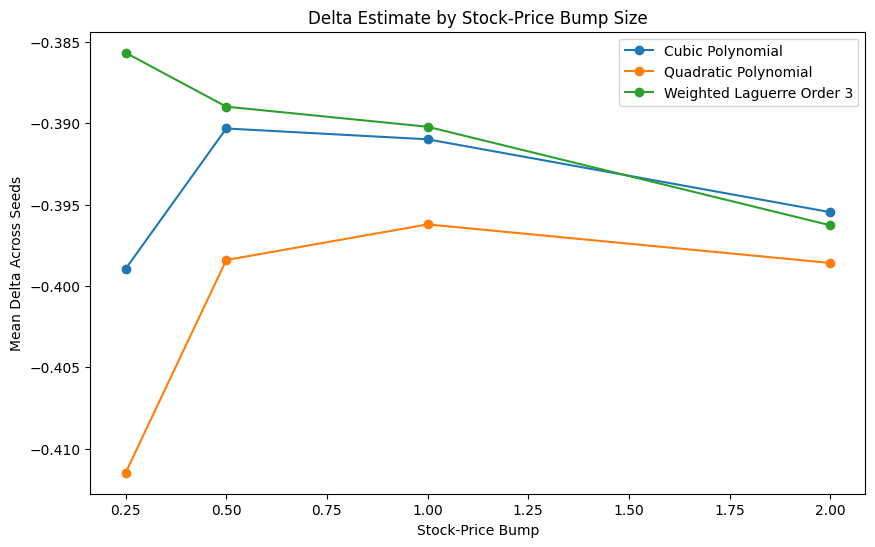

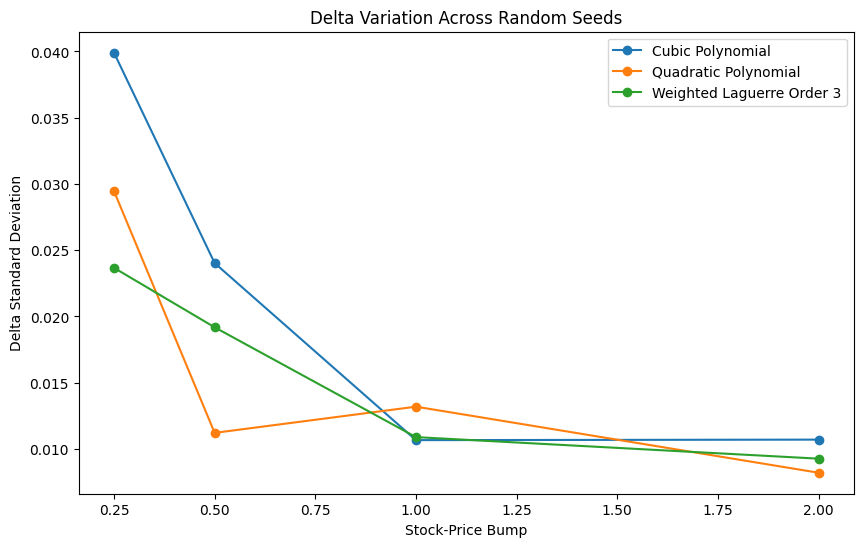

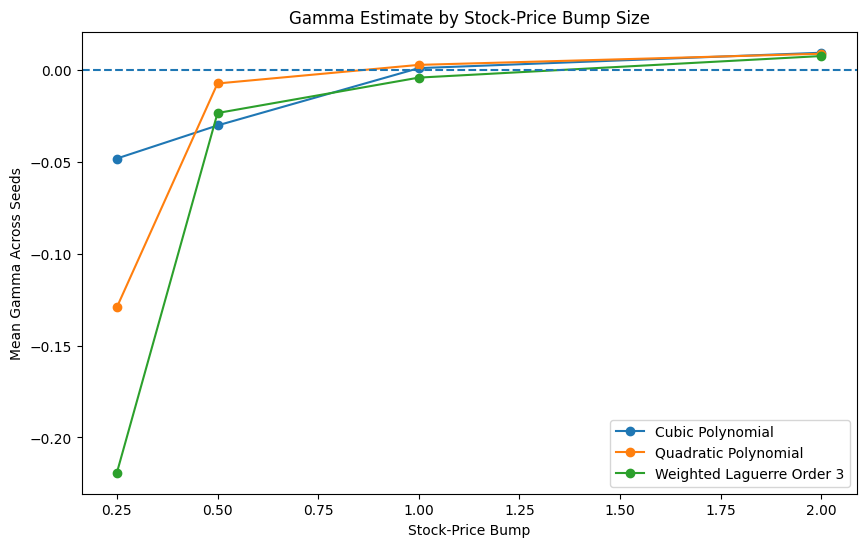

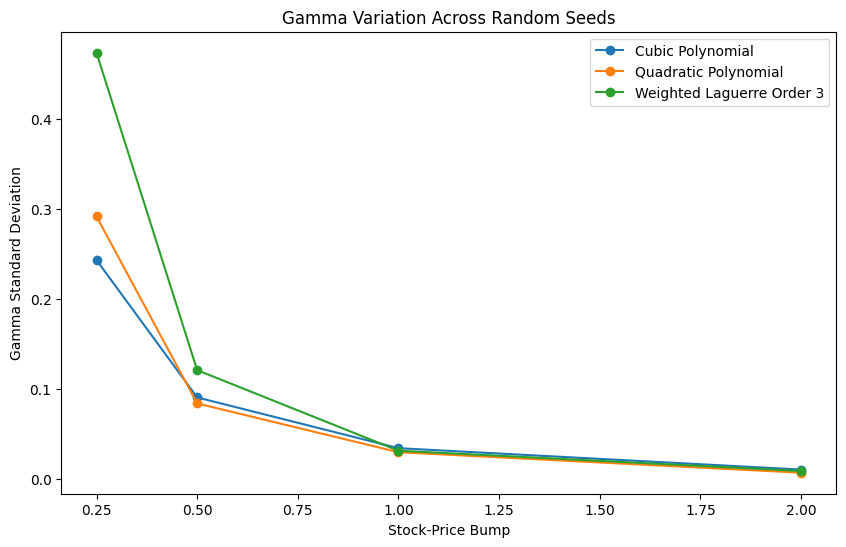

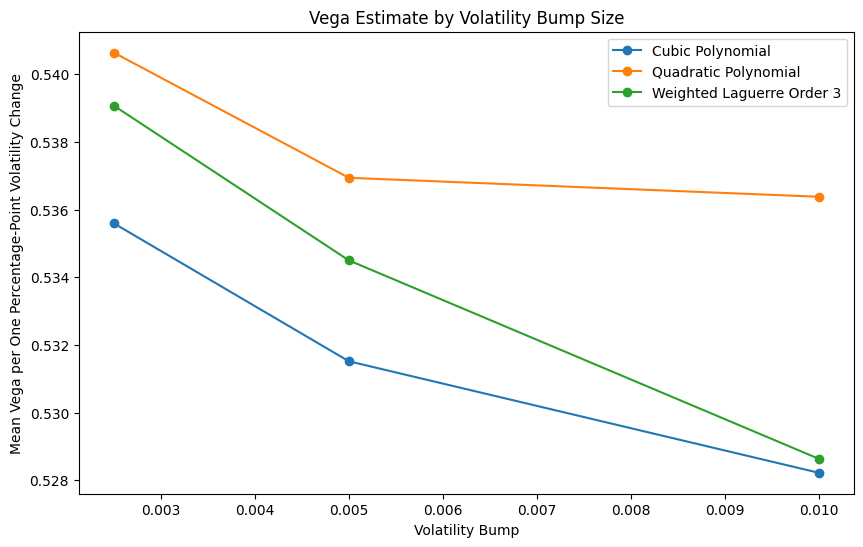

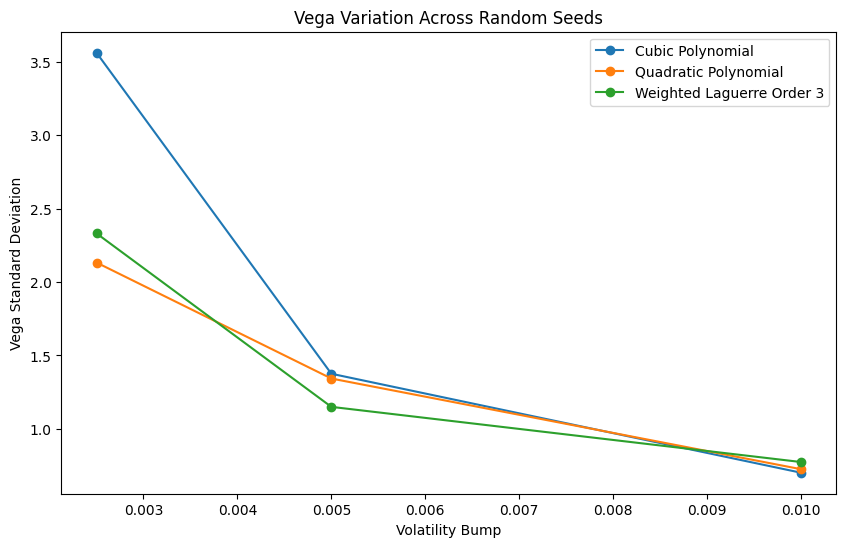

Part 3A Summary:

Experiment settings:
Number of paths: 10000
Number of time intervals: 50
Random seeds: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Regression models:
- Quadratic Polynomial
- Cubic Polynomial
- Weighted Laguerre Order 3
Stock-price bumps: [0.25, 0.5, 1.0, 2.0]
Volatility bumps: [0.0025, 0.005, 0.01]
Valuation approach: full bump-and-revalue
Common random numbers used: True

Internal consistency:
All Delta/Gamma discounting checks passed: True
All Vega discounting checks passed: True

Economic-sign checks:
All mean Delta estimates are negative: True
All mean Gamma estimates are positive: False
All mean Vega estimates are positive: True

Primary comparison settings:
Primary stock-price bump: 1.0
Primary volatility bump: 0.005

Stability results:
Model with lowest Delta variation: Cubic Polynomial
Model with lowest Gamma variation: Quadratic Polynomial
Model with lowest Vega variation: Weighted Laguerre Order 3

Interpretation:
All sensitivity valuations pass the discounting checks.

In [12]:
#### PART 3A - FULL BUMP-AND-REVALUE GREEKS USING COMMON RANDOM NUMBERS ####

# Goal:
# 1. Estimate Delta, Gamma, and Vega using central finite differences
# 2. Use common random numbers for all base and bumped valuations
# 3. Refit the Longstaff-Schwartz regression separately for every bump
# 4. Compare sensitivities across the top 3 regression models:
#    - Quadratic polynomial
#    - Cubic polynomial
#    - Weighted Laguerre order 3
# 5. Test several finite-difference bump sizes
# 6. Measure sensitivity stability across random seeds

# Important:
# - Number of paths remains fixed at 10,000
# - Number of time intervals remains fixed at 50
# - The same random shocks are used for the base, upper, and lower valuations
# - The regression is fully refitted for every bumped valuation
# - So, exercise decisions are allowed to change between valuations
# - This is the full bump-and-revalue common-random-number method
# - Only one model input is changed at a time
# - Common random numbers reduce unnecessary Monte Carlo noise

### SENSITIVITY EXPERIMENT SETTINGS

greeks_n_paths = 10000
greeks_n_steps = 50
greeks_seeds = list(range(1, 11))

# Regression models selected from Part 2
greeks_models = [
    {"Model_Name": "Quadratic Polynomial", "Basis_Type": "Polynomial", "Order": 2},
    {"Model_Name": "Cubic Polynomial", "Basis_Type": "Polynomial", "Order": 3},
    {"Model_Name": "Weighted Laguerre Order 3", "Basis_Type": "Laguerre", "Order": 3}
]

# Stock-price bumps used for Delta and Gamma
# Test several bump sizes because small bumps can increase Monte Carlo noise, while large bumps can reduce finite-difference accuracy
stock_price_bumps = [0.25, 0.50, 1.00, 2.00]

# Volatility bumps used for Vega (example: 0.0050 changes volatility from 25% to 25.5% or 24.5%)
volatility_bumps = [0.0025, 0.0050, 0.0100]

### CREATE REGRESSION DESIGN MATRIX

# Create the regression inputs used to estimate continuation value
# Polynomial basis: x = S / K and [1, x, x^2, ..., x^order]
# Weighted Laguerre basis: x = S / K and exp(-x / 2) * [L_0(x), ..., L_order(x)]
def create_greeks_regression_matrix(stock_prices, K, basis_type, order):
    if K <= 0:
        raise ValueError("K must be greater than zero")
    if order < 1:
        raise ValueError("Regression order must be at least 1")

    scaled_stock_prices = stock_prices / K

    if basis_type == "Polynomial":
        design_matrix = np.polynomial.polynomial.polyvander(scaled_stock_prices, order)
    elif basis_type == "Laguerre":
        laguerre_matrix = np.polynomial.laguerre.lagvander(scaled_stock_prices, order)
        laguerre_weight = np.exp(-scaled_stock_prices / 2)
        design_matrix = laguerre_matrix * laguerre_weight[:, None]
    else:
        raise ValueError("basis_type must be either 'Polynomial' or 'Laguerre'")

    return design_matrix

### GENERAL LONGSTAFF-SCHWARTZ PRICING FUNCTION

# Price an American put using Longstaff-Schwartz
# Simulate paths, estimate continuation values, and apply backward induction
# Use the same random shocks for base and bumped valuations
def price_american_put_for_greeks(S0_input, K, r, sigma_input, T, random_shocks, basis_type, regression_order):
    if S0_input <= 0:
        raise ValueError("S0_input must be greater than zero")
    if sigma_input <= 0:
        raise ValueError("sigma_input must be greater than zero")

    number_of_steps, number_of_paths = random_shocks.shape
    experiment_dt = T / number_of_steps
    one_step_discount_factor = np.exp(-r * experiment_dt)

    # Simulate risk-neutral GBM paths
    simulated_paths = np.zeros((number_of_paths, number_of_steps + 1))
    simulated_paths[:, 0] = S0_input

    for t in range(1, number_of_steps + 1):
        Z_t = random_shocks[t - 1, :]
        simulated_paths[:, t] = simulated_paths[:, t - 1] * np.exp((r - 0.5 * sigma_input**2) * experiment_dt + sigma_input * np.sqrt(experiment_dt) * Z_t)

    # Set cashflows at maturity
    cashflows = np.maximum(K - simulated_paths[:, -1], 0)
    exercise_time = np.full(number_of_paths, number_of_steps, dtype=int)
    exercise_stock_price = simulated_paths[:, -1].copy()
    exercise_boundary = np.full(number_of_steps + 1, np.nan)
    exercise_boundary[number_of_steps] = K
    condition_numbers = []

    # Longstaff-Schwartz backward induction
    for t in range(number_of_steps - 1, 0, -1):
        current_stock_prices = simulated_paths[:, t]
        immediate_exercise_values = np.maximum(K - current_stock_prices, 0)
        discounted_cashflows = cashflows * one_step_discount_factor
        in_the_money = immediate_exercise_values > 0
        number_in_the_money = int(np.sum(in_the_money))

        if number_in_the_money == 0:
            cashflows = discounted_cashflows
            continue

        stock_prices_itm = current_stock_prices[in_the_money]
        exercise_values_itm = immediate_exercise_values[in_the_money]
        continuation_targets_itm = discounted_cashflows[in_the_money]
        regression_matrix = create_greeks_regression_matrix(stock_prices=stock_prices_itm, K=K, basis_type=basis_type, order=regression_order)
        condition_numbers.append(np.linalg.cond(regression_matrix))
        regression_coefficients, *_ = np.linalg.lstsq(regression_matrix, continuation_targets_itm, rcond=None)
        estimated_continuation_values = regression_matrix @ regression_coefficients
        exercise_now_itm = exercise_values_itm > estimated_continuation_values
        itm_indices = np.where(in_the_money)[0]
        exercise_indices = itm_indices[exercise_now_itm]

        # First assume that all paths continue
        cashflows = discounted_cashflows.copy()

        # Replace future cashflows where exercise is optimal
        cashflows[exercise_indices] = immediate_exercise_values[exercise_indices]
        exercise_time[exercise_indices] = t
        exercise_stock_price[exercise_indices] = current_stock_prices[exercise_indices]

        # Approximate sample-based boundary
        if len(exercise_indices) > 0:
            exercise_boundary[t] = np.max(current_stock_prices[exercise_indices])

    # Estimate price at Time_0
    continuation_value_time_0 = np.mean(cashflows) * one_step_discount_factor
    immediate_exercise_value_time_0 = max(K - S0_input, 0)
    american_put_price = max(immediate_exercise_value_time_0, continuation_value_time_0)

    # Independent discounting check
    cashflow_at_exercise = np.maximum(K - exercise_stock_price, 0)
    present_values = cashflow_at_exercise * np.exp(-r * exercise_time * experiment_dt)
    independent_price = np.mean(present_values)
    discounting_difference = abs(continuation_value_time_0 - independent_price)

    return {
        "Price": american_put_price,
        "Independent_Price": independent_price,
        "Discounting_Difference": discounting_difference,
        "Exercise_Time": exercise_time,
        "Exercise_Boundary": exercise_boundary,
        "Early_Exercise_Percentage": np.mean(exercise_time < number_of_steps) * 100,
        "Present_Value_SD": np.std(present_values, ddof=1),
        "Mean_Condition_Number": np.mean(condition_numbers) if len(condition_numbers) > 0 else np.nan
    }

### RUN DELTA AND GAMMA EXPERIMENT

delta_gamma_rows = []

for seed in greeks_seeds:
    random_generator = np.random.default_rng(seed)
    # Generate one common shock matrix for this seed
    # Every model and every stock-price bump uses these exact same random numbers
    common_random_shocks = random_generator.standard_normal(size=(greeks_n_steps, greeks_n_paths))

    for model in greeks_models:
        model_name = model["Model_Name"]
        basis_type = model["Basis_Type"]
        regression_order = model["Order"]

        # Calculate the base price once for this model and seed
        base_result = price_american_put_for_greeks(S0_input=S0, K=K, r=r, sigma_input=sigma, T=T, random_shocks=common_random_shocks, basis_type=basis_type, regression_order=regression_order)
        base_price = base_result["Price"]

        for stock_bump in stock_price_bumps:
            # Price using S0 + h
            upper_result = price_american_put_for_greeks(S0_input=S0 + stock_bump, K=K, r=r, sigma_input=sigma, T=T, random_shocks=common_random_shocks, basis_type=basis_type, regression_order=regression_order)
            # Price using S0 - h
            lower_result = price_american_put_for_greeks(S0_input=S0 - stock_bump, K=K, r=r, sigma_input=sigma, T=T, random_shocks=common_random_shocks, basis_type=basis_type, regression_order=regression_order)

            upper_price = upper_result["Price"]
            lower_price = lower_result["Price"]

            # Central finite-difference Delta
            delta_estimate = (upper_price - lower_price) / (2 * stock_bump)

            # Central finite-difference Gamma
            gamma_estimate = (upper_price - 2 * base_price + lower_price) / stock_bump**2

            maximum_discounting_difference = max(base_result["Discounting_Difference"], upper_result["Discounting_Difference"], lower_result["Discounting_Difference"])

            delta_gamma_rows.append({
                "Seed": seed,
                "Regression_Model": model_name,
                "Basis_Type": basis_type,
                "Regression_Order": regression_order,
                "Stock_Price_Bump": stock_bump,
                "Base_Price": base_price,
                "Upper_Stock_Price": S0 + stock_bump,
                "Upper_Price": upper_price,
                "Lower_Stock_Price": S0 - stock_bump,
                "Lower_Price": lower_price,
                "Delta": delta_estimate,
                "Gamma": gamma_estimate,
                "Base_Early_Exercise_Percentage": base_result["Early_Exercise_Percentage"],
                "Maximum_Discounting_Difference": maximum_discounting_difference
            })

df_delta_gamma_all = pd.DataFrame(delta_gamma_rows)
display(df_delta_gamma_all.head(20))

### SUMMARISE DELTA AND GAMMA

df_delta_gamma_summary = (df_delta_gamma_all.groupby(["Regression_Model", "Stock_Price_Bump"]).agg(
        Mean_Base_Price=("Base_Price", "mean"),
        Mean_Delta=("Delta", "mean"),
        Delta_SD_Across_Seeds=("Delta", "std"),
        Minimum_Delta=("Delta", "min"),
        Maximum_Delta=("Delta", "max"),
        Mean_Gamma=("Gamma", "mean"),
        Gamma_SD_Across_Seeds=("Gamma", "std"),
        Minimum_Gamma=("Gamma", "min"),
        Maximum_Gamma=("Gamma", "max"),
        Maximum_Discounting_Difference=("Maximum_Discounting_Difference", "max")
    ).reset_index())

# Standard errors across random seeds
df_delta_gamma_summary["Delta_Standard_Error"] = df_delta_gamma_summary["Delta_SD_Across_Seeds"] / np.sqrt(len(greeks_seeds))
df_delta_gamma_summary["Gamma_Standard_Error"] = df_delta_gamma_summary["Gamma_SD_Across_Seeds"] / np.sqrt(len(greeks_seeds))

# Coefficient of variation for Gamma
# This measures Gamma variability relative to the absolute size of its mean
df_delta_gamma_summary["Gamma_Coefficient_Of_Variation"] = df_delta_gamma_summary["Gamma_SD_Across_Seeds"] / abs(df_delta_gamma_summary["Mean_Gamma"])

display(df_delta_gamma_summary.round(8))

### RUN VEGA EXPERIMENT

vega_rows = []

for seed in greeks_seeds:
    random_generator = np.random.default_rng(seed)
    # The same random shocks are used for sigma + bump, sigma and sigma - bump
    common_random_shocks = random_generator.standard_normal(size=(greeks_n_steps, greeks_n_paths))

    for model in greeks_models:
        model_name = model["Model_Name"]
        basis_type = model["Basis_Type"]
        regression_order = model["Order"]

        for volatility_bump in volatility_bumps:
            upper_volatility = sigma + volatility_bump
            lower_volatility = sigma - volatility_bump

            if lower_volatility <= 0:
                raise ValueError("The lower volatility bump must remain greater than zero")

            upper_result = price_american_put_for_greeks(S0_input=S0, K=K, r=r, sigma_input=upper_volatility, T=T, random_shocks=common_random_shocks, basis_type=basis_type, regression_order=regression_order)
            lower_result = price_american_put_for_greeks(S0_input=S0, K=K, r=r, sigma_input=lower_volatility, T=T, random_shocks=common_random_shocks, basis_type=basis_type, regression_order=regression_order)
            upper_price = upper_result["Price"]
            lower_price = lower_result["Price"]

            # Central finite-difference Vega
            # Calculate Vega and convert it to the price change for a 1 percentage-point change in volatility
            vega_estimate = (upper_price - lower_price) / (2 * volatility_bump)
            vega_per_one_percentage_point = vega_estimate * 0.01
            maximum_discounting_difference = max(upper_result["Discounting_Difference"], lower_result["Discounting_Difference"])
            vega_rows.append({
                "Seed": seed,
                "Regression_Model": model_name,
                "Basis_Type": basis_type,
                "Regression_Order": regression_order,
                "Volatility_Bump": volatility_bump,
                "Upper_Volatility": upper_volatility,
                "Upper_Price": upper_price,
                "Lower_Volatility": lower_volatility,
                "Lower_Price": lower_price,
                "Vega_Per_Unit_Volatility": vega_estimate,
                "Vega_Per_One_Percentage_Point": vega_per_one_percentage_point,
                "Maximum_Discounting_Difference": maximum_discounting_difference
            })

df_vega_all = pd.DataFrame(vega_rows)
display(df_vega_all.head(20))

### SUMMARISE VEGA

df_vega_summary = (df_vega_all.groupby(["Regression_Model", "Volatility_Bump"]).agg(
        Mean_Vega_Per_Unit_Volatility=("Vega_Per_Unit_Volatility", "mean"),
        Vega_SD_Across_Seeds=("Vega_Per_Unit_Volatility", "std"),
        Minimum_Vega=("Vega_Per_Unit_Volatility", "min"),
        Maximum_Vega=("Vega_Per_Unit_Volatility", "max"),
        Mean_Vega_Per_One_Percentage_Point=("Vega_Per_One_Percentage_Point", "mean"),
        Maximum_Discounting_Difference=("Maximum_Discounting_Difference", "max")
    ).reset_index())

df_vega_summary["Vega_Standard_Error"] = df_vega_summary["Vega_SD_Across_Seeds"] / np.sqrt(len(greeks_seeds))
df_vega_summary["Vega_Coefficient_Of_Variation"] = df_vega_summary["Vega_SD_Across_Seeds"] / abs(df_vega_summary["Mean_Vega_Per_Unit_Volatility"])

display(df_vega_summary.round(8))

### GREEK CONSISTENCY CHECKS

all_delta_gamma_discounting_checks_pass = np.allclose(df_delta_gamma_all["Maximum_Discounting_Difference"], 0, rtol=1e-9, atol=1e-9)
all_vega_discounting_checks_pass = np.allclose(df_vega_all["Maximum_Discounting_Difference"], 0, rtol=1e-9, atol=1e-9)

# A put Delta should be negative
all_mean_deltas_are_negative = np.all(df_delta_gamma_summary["Mean_Delta"] < 0)

# A standard option Gamma should be positive
# Individual noisy seed estimates may occasionally be negative, so this check is applied to the mean estimates
all_mean_gammas_are_positive = np.all(df_delta_gamma_summary["Mean_Gamma"] > 0)

# Vega should be positive because greater volatility generally increases the value of a put option
all_mean_vegas_are_positive = np.all(df_vega_summary["Mean_Vega_Per_Unit_Volatility"] > 0)

### IDENTIFY MOST STABLE MODELS

# Use h = 1 as the primary stock-price bump for the first model comparison
# This is large enough to reduce some Monte Carlo noise while remaining small relative to S0 = 100
primary_stock_bump = 1.00

df_primary_delta_gamma = df_delta_gamma_summary[df_delta_gamma_summary["Stock_Price_Bump"] == primary_stock_bump].copy()
most_stable_delta_model = df_primary_delta_gamma.loc[df_primary_delta_gamma["Delta_SD_Across_Seeds"].idxmin(), "Regression_Model"]
most_stable_gamma_model = df_primary_delta_gamma.loc[df_primary_delta_gamma["Gamma_SD_Across_Seeds"].idxmin(), "Regression_Model"]

# Use a volatility bump of 0.005 as the initial main Vega comparison
primary_volatility_bump = 0.005

df_primary_vega = df_vega_summary[df_vega_summary["Volatility_Bump"] == primary_volatility_bump].copy()
most_stable_vega_model = df_primary_vega.loc[df_primary_vega["Vega_SD_Across_Seeds"].idxmin(), "Regression_Model"]

### CREATE PRIMARY GREEKS COMPARISON TABLE

df_primary_greeks_comparison = (
    df_primary_delta_gamma[[
        "Regression_Model",
        "Mean_Base_Price",
        "Mean_Delta",
        "Delta_SD_Across_Seeds",
        "Mean_Gamma",
        "Gamma_SD_Across_Seeds",
        "Gamma_Coefficient_Of_Variation"
    ]]
    .merge(df_primary_vega[[
            "Regression_Model",
            "Mean_Vega_Per_Unit_Volatility",
            "Mean_Vega_Per_One_Percentage_Point",
            "Vega_SD_Across_Seeds",
            "Vega_Coefficient_Of_Variation"
        ]],
        on="Regression_Model",
        how="left"
    )
)
display(df_primary_greeks_comparison.round(8))

### DISPLAY VISUALS

# Plot Delta by stock-price bump
plt.figure(figsize=(10, 6))
for model_name in df_delta_gamma_summary["Regression_Model"].unique():
    model_results = df_delta_gamma_summary[df_delta_gamma_summary["Regression_Model"] == model_name]
    plt.plot(model_results["Stock_Price_Bump"], model_results["Mean_Delta"], marker="o", label=model_name)
plt.title("Delta Estimate by Stock-Price Bump Size")
plt.xlabel("Stock-Price Bump")
plt.ylabel("Mean Delta Across Seeds")
plt.legend()
plt.show()

# Plot Delta stability
plt.figure(figsize=(10, 6))
for model_name in df_delta_gamma_summary["Regression_Model"].unique():
    model_results = df_delta_gamma_summary[df_delta_gamma_summary["Regression_Model"] == model_name]
    plt.plot(model_results["Stock_Price_Bump"], model_results["Delta_SD_Across_Seeds"], marker="o", label=model_name)
plt.title("Delta Variation Across Random Seeds")
plt.xlabel("Stock-Price Bump")
plt.ylabel("Delta Standard Deviation")
plt.legend()
plt.show()

# Plot Gamma by stock-price bump
plt.figure(figsize=(10, 6))
for model_name in df_delta_gamma_summary["Regression_Model"].unique():
    model_results = df_delta_gamma_summary[df_delta_gamma_summary["Regression_Model"] == model_name]
    plt.plot(model_results["Stock_Price_Bump"], model_results["Mean_Gamma"], marker="o", label=model_name)
plt.axhline(0, linestyle="--")
plt.title("Gamma Estimate by Stock-Price Bump Size")
plt.xlabel("Stock-Price Bump")
plt.ylabel("Mean Gamma Across Seeds")
plt.legend()
plt.show()

# Plot Gamma stability
plt.figure(figsize=(10, 6))
for model_name in df_delta_gamma_summary["Regression_Model"].unique():
    model_results = df_delta_gamma_summary[df_delta_gamma_summary["Regression_Model"] == model_name]
    plt.plot(model_results["Stock_Price_Bump"], model_results["Gamma_SD_Across_Seeds"], marker="o", label=model_name)
plt.title("Gamma Variation Across Random Seeds")
plt.xlabel("Stock-Price Bump")
plt.ylabel("Gamma Standard Deviation")
plt.legend()
plt.show()

# Plot Vega by volatility bump
plt.figure(figsize=(10, 6))
for model_name in df_vega_summary["Regression_Model"].unique():
    model_results = df_vega_summary[df_vega_summary["Regression_Model"] == model_name]
    plt.plot(model_results["Volatility_Bump"], model_results["Mean_Vega_Per_One_Percentage_Point"], marker="o", label=model_name)
plt.title("Vega Estimate by Volatility Bump Size")
plt.xlabel("Volatility Bump")
plt.ylabel("Mean Vega per One Percentage-Point Volatility Change")
plt.legend()
plt.show()

# Plot Vega stability
plt.figure(figsize=(10, 6))
for model_name in df_vega_summary["Regression_Model"].unique():
    model_results = df_vega_summary[df_vega_summary["Regression_Model"] == model_name]
    plt.plot(model_results["Volatility_Bump"], model_results["Vega_SD_Across_Seeds"], marker="o", label=model_name)
plt.title("Vega Variation Across Random Seeds")
plt.xlabel("Volatility Bump")
plt.ylabel("Vega Standard Deviation")
plt.legend()
plt.show()

### PART 3A SUMMARY

print("Part 3A Summary:")

print("\nExperiment settings:")
print("Number of paths:", greeks_n_paths)
print("Number of time intervals:", greeks_n_steps)
print("Random seeds:", greeks_seeds)
print("Regression models:")
for model in greeks_models:
    print("-", model["Model_Name"])
print("Stock-price bumps:", stock_price_bumps)
print("Volatility bumps:", volatility_bumps)
print("Valuation approach: full bump-and-revalue")
print("Common random numbers used: True")

print("\nInternal consistency:")
print("All Delta/Gamma discounting checks passed:", all_delta_gamma_discounting_checks_pass)
print("All Vega discounting checks passed:", all_vega_discounting_checks_pass)

print("\nEconomic-sign checks:")
print("All mean Delta estimates are negative:", all_mean_deltas_are_negative)
print("All mean Gamma estimates are positive:", all_mean_gammas_are_positive)
print("All mean Vega estimates are positive:", all_mean_vegas_are_positive)

print("\nPrimary comparison settings:")
print("Primary stock-price bump:", primary_stock_bump)
print("Primary volatility bump:", primary_volatility_bump)

print("\nStability results:")
print("Model with lowest Delta variation:", most_stable_delta_model)
print("Model with lowest Gamma variation:", most_stable_gamma_model)
print("Model with lowest Vega variation:", most_stable_vega_model)

print("\nInterpretation:")
if all_delta_gamma_discounting_checks_pass and all_vega_discounting_checks_pass:
    print(
        "All sensitivity valuations pass the discounting checks. These results provide the benchmark for Part 3B, "
        "where the base regression functions are kept fixed for the bumped valuations. "
        "This tests whether regression refitting and changes in exercise decisions contribute to Gamma noise."
    )
else:
    print(
        "At least one sensitivity discounting check failed. Review the results before interpreting Delta, Gamma, or Vega."
    )

,Regression_Model,Basis_Type,Regression_Order,Seed,Stock_Price_Bump,Lower_Stock_Price,Base_Stock_Price,Upper_Stock_Price,Lower_Price,Base_Price,Upper_Price,Delta,Gamma,Lower_Early_Exercise_Percentage,Base_Early_Exercise_Percentage,Upper_Early_Exercise_Percentage,Base_Policy_Reproduction_Difference,Maximum_Discounting_Difference
0,Quadratic Polynomial,Polynomial,2,1,0.25,99.75,100,100.25,11.824186,11.730486,11.641280,-0.365812,0.071896,40.77,40.48,40.06,0.0,0.0
1,Quadratic Polynomial,Polynomial,2,1,0.50,99.50,100,100.50,11.918128,11.730486,11.531701,-0.386427,-0.044575,41.03,40.48,39.76,0.0,0.0
2,Quadratic Polynomial,Polynomial,2,1,1.00,99.00,100,101.00,12.135437,11.730486,11.322608,-0.406415,-0.002928,41.65,40.48,39.06,0.0,0.0
3,Quadratic Polynomial,Polynomial,2,1,2.00,98.00,100,102.00,12.529932,11.730486,10.925133,-0.401200,-0.001477,42.88,40.48,37.73,0.0,0.0
4,Quadratic Polynomial,Polynomial,2,2,0.25,99.75,100,100.25,11.556352,11.445955,11.335785,-0.441134,0.003607,41.20,40.78,40.41,0.0,0.0
5,Quadratic Polynomial,Polynomial,2,2,0.50,99.50,100,100.50,11.650582,11.445955,11.239785,-0.410797,-0.006178,41.47,40.78,40.02,0.0,0.0
6,Quadratic Polynomial,Polynomial,2,2,1.00,99.00,100,101.00,11.861755,11.445955,11.047756,-0.407000,0.017600,42.27,40.78,39.31,0.0,0.0
7,Quadratic Polynomial,Polynomial,2,2,2.00,98.00,100,102.00,12.255225,11.445955,10.699858,-0.388842,0.015793,43.62,40.78,38.17,0.0,0.0
8,Quadratic Polynomial,Polynomial,2,3,0.25,99.75,100,100.25,11.565973,11.470757,11.367727,-0.396493,-0.125037,41.01,40.63,40.28,0.0,0.0
9,Quadratic Polynomial,Polynomial,2,3,0.50,99.50,100,100.50,11.668545,11.470757,11.267039,-0.401506,-0.023726,41.29,40.63,39.89,0.0,0.0


,Regression_Model,Seed,Base_Price,Base_Independent_Price,Base_Discounting_Difference,Base_Early_Exercise_Percentage,Mean_Condition_Number
0,Quadratic Polynomial,1,11.730486,11.730486,0.0,40.48,361.109946
1,Quadratic Polynomial,2,11.445955,11.445955,0.0,40.78,369.388185
2,Quadratic Polynomial,3,11.470757,11.470757,0.0,40.63,377.125552
3,Quadratic Polynomial,4,11.512185,11.512185,0.0,39.63,366.951570
4,Quadratic Polynomial,5,11.413055,11.413055,0.0,36.73,376.788611
5,Quadratic Polynomial,6,11.621878,11.621878,0.0,40.55,375.407705
6,Quadratic Polynomial,7,11.399235,11.399235,0.0,39.86,369.839566
7,Quadratic Polynomial,8,11.466495,11.466495,0.0,40.70,366.943000
8,Quadratic Polynomial,9,11.350979,11.350979,0.0,39.27,378.752246
9,Quadratic Polynomial,10,11.703505,11.703505,0.0,40.33,360.227640


,Regression_Model,Basis_Type,Regression_Order,Seed,Volatility_Bump,Lower_Volatility,Base_Volatility,Upper_Volatility,Lower_Price,Base_Price,Upper_Price,Vega_Per_Unit_Volatility,Vega_Per_One_Percentage_Point,Lower_Early_Exercise_Percentage,Base_Early_Exercise_Percentage,Upper_Early_Exercise_Percentage,Base_Policy_Reproduction_Difference,Maximum_Discounting_Difference
0,Quadratic Polynomial,Polynomial,2,1,0.0025,0.2475,0.25,0.2525,11.601641,11.730486,11.863249,52.321746,0.523217,39.97,40.48,40.85,0.0,0.0
1,Quadratic Polynomial,Polynomial,2,1,0.0050,0.2450,0.25,0.2550,11.438162,11.730486,11.997261,55.909872,0.559099,39.50,40.48,41.18,0.0,0.0
2,Quadratic Polynomial,Polynomial,2,1,0.0100,0.2400,0.25,0.2600,11.147021,11.730486,12.272683,56.283122,0.562831,38.58,40.48,41.91,0.0,0.0
3,Quadratic Polynomial,Polynomial,2,2,0.0025,0.2475,0.25,0.2525,11.295846,11.445955,11.586126,58.056007,0.580560,40.27,40.78,41.30,0.0,0.0
4,Quadratic Polynomial,Polynomial,2,2,0.0050,0.2450,0.25,0.2550,11.167425,11.445955,11.711025,54.360014,0.543600,39.71,40.78,41.72,0.0,0.0
5,Quadratic Polynomial,Polynomial,2,2,0.0100,0.2400,0.25,0.2600,10.918476,11.445955,11.966838,52.418101,0.524181,38.87,40.78,42.66,0.0,0.0
6,Quadratic Polynomial,Polynomial,2,3,0.0025,0.2475,0.25,0.2525,11.321735,11.470757,11.610819,57.816808,0.578168,40.10,40.63,41.18,0.0,0.0
7,Quadratic Polynomial,Polynomial,2,3,0.0050,0.2450,0.25,0.2550,11.204793,11.470757,11.730164,52.537063,0.525371,39.68,40.63,41.55,0.0,0.0
8,Quadratic Polynomial,Polynomial,2,3,0.0100,0.2400,0.25,0.2600,10.914565,11.470757,11.960372,52.290353,0.522904,38.66,40.63,42.29,0.0,0.0
9,Quadratic Polynomial,Polynomial,2,4,0.0025,0.2475,0.25,0.2525,11.374282,11.512185,11.654545,56.052570,0.560526,39.09,39.63,40.11,0.0,0.0


,Regression_Model,Stock_Price_Bump,Mean_Base_Price,Base_Price_SD_Across_Seeds,Mean_Delta,Delta_SD_Across_Seeds,Minimum_Delta,Maximum_Delta,Mean_Gamma,Gamma_SD_Across_Seeds,Minimum_Gamma,Maximum_Gamma,Maximum_Base_Policy_Reproduction_Difference,Maximum_Discounting_Difference,Delta_Standard_Error,Gamma_Standard_Error,Gamma_Coefficient_Of_Variation
0,Cubic Polynomial,0.25,11.531225,0.132696,-0.394398,0.015696,-0.418166,-0.370230,0.023413,0.186551,-0.197326,0.280465,0.0,0.0,0.004963,0.058993,7.967731
1,Cubic Polynomial,0.50,11.531225,0.132696,-0.397902,0.016861,-0.429558,-0.382892,-0.017564,0.059647,-0.137984,0.071554,0.0,0.0,0.005332,0.018862,3.396005
2,Cubic Polynomial,1.00,11.531225,0.132696,-0.395475,0.014094,-0.416349,-0.380868,-0.006765,0.033016,-0.076961,0.032888,0.0,0.0,0.004457,0.010440,4.880068
3,Cubic Polynomial,2.00,11.531225,0.132696,-0.397478,0.012427,-0.420981,-0.381279,0.003021,0.008908,-0.015562,0.015090,0.0,0.0,0.003930,0.002817,2.948702
4,Quadratic Polynomial,0.25,11.511453,0.130404,-0.398797,0.025990,-0.441134,-0.363806,-0.057545,0.204106,-0.432101,0.164782,0.0,0.0,0.008219,0.064544,3.546905
5,Quadratic Polynomial,0.50,11.511453,0.130404,-0.402563,0.022832,-0.452186,-0.377563,-0.024736,0.066350,-0.178741,0.049019,0.0,0.0,0.007220,0.020982,2.682333
6,Quadratic Polynomial,1.00,11.511453,0.130404,-0.397290,0.012795,-0.409727,-0.373636,-0.006066,0.026514,-0.050577,0.017600,0.0,0.0,0.004046,0.008385,4.371305
7,Quadratic Polynomial,2.00,11.511453,0.130404,-0.398567,0.010806,-0.421665,-0.383724,0.003712,0.008178,-0.006081,0.015793,0.0,0.0,0.003417,0.002586,2.203227
8,Weighted Laguerre Order 3,0.25,11.536059,0.131950,-0.384046,0.020423,-0.408395,-0.334166,-0.124571,0.190204,-0.353506,0.255872,0.0,0.0,0.006458,0.060148,1.526872
9,Weighted Laguerre Order 3,0.50,11.536059,0.131950,-0.391517,0.020666,-0.413363,-0.357807,-0.040381,0.076468,-0.192558,0.074850,0.0,0.0,0.006535,0.024181,1.893676


,Regression_Model,Volatility_Bump,Mean_Vega_Per_Unit_Volatility,Vega_SD_Across_Seeds,Minimum_Vega,Maximum_Vega,Mean_Vega_Per_One_Percentage_Point,Maximum_Base_Policy_Reproduction_Difference,Maximum_Discounting_Difference,Vega_Standard_Error,Vega_Coefficient_Of_Variation
0,Cubic Polynomial,0.0025,52.890313,2.058931,48.566329,54.987103,0.528903,0.0,0.0,0.651091,0.038928
1,Cubic Polynomial,0.0050,53.502972,2.275593,49.991840,58.515370,0.535030,0.0,0.0,0.719606,0.042532
2,Cubic Polynomial,0.0100,53.248842,1.584824,50.747621,55.615102,0.532488,0.0,0.0,0.501165,0.029763
3,Quadratic Polynomial,0.0025,54.277449,2.786574,51.123927,58.056007,0.542774,0.0,0.0,0.881192,0.051339
4,Quadratic Polynomial,0.0050,53.825791,3.416029,49.456831,59.332523,0.538258,0.0,0.0,1.080243,0.063465
5,Quadratic Polynomial,0.0100,53.322935,1.818269,50.937067,56.283122,0.533229,0.0,0.0,0.574987,0.034099
6,Weighted Laguerre Order 3,0.0025,51.523460,3.283747,46.232586,55.984946,0.515235,0.0,0.0,1.038412,0.063733
7,Weighted Laguerre Order 3,0.0050,52.503598,2.491238,48.381856,55.378415,0.525036,0.0,0.0,0.787799,0.047449
8,Weighted Laguerre Order 3,0.0100,53.168950,2.323920,49.015063,55.795725,0.531690,0.0,0.0,0.734888,0.043708


,Regression_Model,Mean_Base_Price,Mean_Delta,Delta_SD_Across_Seeds,Mean_Gamma,Gamma_SD_Across_Seeds,Gamma_Coefficient_Of_Variation,Mean_Vega_Per_Unit_Volatility,Mean_Vega_Per_One_Percentage_Point,Vega_SD_Across_Seeds,Vega_Coefficient_Of_Variation
0,Cubic Polynomial,11.531225,-0.395475,0.014094,-0.006765,0.033016,4.880068,53.502972,0.535030,2.275593,0.042532
1,Quadratic Polynomial,11.511453,-0.397290,0.012795,-0.006066,0.026514,4.371305,53.825791,0.538258,3.416029,0.063465
2,Weighted Laguerre Order 3,11.536059,-0.396113,0.015106,-0.006152,0.025334,4.117751,52.503598,0.525036,2.491238,0.047449


,Regression_Model,Stock_Price_Bump,Part_3A_Mean_Delta,Part_3A_Delta_SD,Part_3A_Mean_Gamma,Part_3A_Gamma_SD,Part_3B_Mean_Delta,Part_3B_Delta_SD,Part_3B_Mean_Gamma,Part_3B_Gamma_SD,Delta_Mean_Difference_3B_Minus_3A,Gamma_Mean_Difference_3B_Minus_3A,Delta_SD_Reduction_Percentage,Gamma_SD_Reduction_Percentage
0,Cubic Polynomial,0.25,-0.398952,0.039903,-0.048080,0.243187,-0.394398,0.015696,0.023413,0.186551,0.004554,0.071494,60.664974,23.289219
1,Cubic Polynomial,0.50,-0.390331,0.024025,-0.030071,0.090687,-0.397902,0.016861,-0.017564,0.059647,-0.007571,0.012507,29.818437,34.227901
2,Cubic Polynomial,1.00,-0.390996,0.010666,0.001144,0.034324,-0.395475,0.014094,-0.006765,0.033016,-0.004479,-0.007909,-32.136343,3.810983
3,Cubic Polynomial,2.00,-0.395468,0.010704,0.009532,0.010539,-0.397478,0.012427,0.003021,0.008908,-0.002009,-0.006511,-16.092951,15.475013
4,Quadratic Polynomial,0.25,-0.411473,0.029456,-0.129072,0.291636,-0.398797,0.025990,-0.057545,0.204106,0.012675,0.071527,11.764620,30.013535
5,Quadratic Polynomial,0.50,-0.398410,0.011214,-0.007216,0.084023,-0.402563,0.022832,-0.024736,0.066350,-0.004153,-0.017520,-103.598253,21.033801
6,Quadratic Polynomial,1.00,-0.396222,0.013192,0.002913,0.029847,-0.397290,0.012795,-0.006066,0.026514,-0.001069,-0.008979,3.008685,11.166028
7,Quadratic Polynomial,2.00,-0.398590,0.008207,0.008989,0.007063,-0.398567,0.010806,0.003712,0.008178,0.000023,-0.005277,-31.676194,-15.791943
8,Weighted Laguerre Order 3,0.25,-0.385679,0.023669,-0.219198,0.473450,-0.384046,0.020423,-0.124571,0.190204,0.001633,0.094627,13.713269,59.825831
9,Weighted Laguerre Order 3,0.50,-0.388991,0.019181,-0.023305,0.120996,-0.391517,0.020666,-0.040381,0.076468,-0.002526,-0.017075,-7.742906,36.801387


,Regression_Model,Volatility_Bump,Part_3A_Mean_Vega,Part_3A_Vega_SD,Part_3B_Mean_Vega,Part_3B_Vega_SD,Vega_Mean_Difference_3B_Minus_3A,Vega_SD_Reduction_Percentage
0,Cubic Polynomial,0.0025,53.558840,3.563416,52.890313,2.058931,-0.668527,42.220318
1,Cubic Polynomial,0.0050,53.151451,1.375079,53.502972,2.275593,0.351521,-65.488181
2,Cubic Polynomial,0.0100,52.822024,0.700355,53.248842,1.584824,0.426818,-126.288496
3,Quadratic Polynomial,0.0025,54.063423,2.133064,54.277449,2.786574,0.214026,-30.637173
4,Quadratic Polynomial,0.0050,53.693763,1.342434,53.825791,3.416029,0.132028,-154.465215
5,Quadratic Polynomial,0.0100,53.637737,0.724406,53.322935,1.818269,-0.314802,-151.001483
6,Weighted Laguerre Order 3,0.0025,53.906708,2.331915,51.523460,3.283747,-2.383248,-40.817610
7,Weighted Laguerre Order 3,0.0050,53.449662,1.149321,52.503598,2.491238,-0.946064,-116.757442
8,Weighted Laguerre Order 3,0.0100,52.863439,0.773253,53.168950,2.323920,0.305511,-200.538092


,Regression_Model,Stock_Price_Bump,Part_3A_Mean_Delta,Part_3A_Delta_SD,Part_3A_Mean_Gamma,Part_3A_Gamma_SD,Part_3B_Mean_Delta,Part_3B_Delta_SD,Part_3B_Mean_Gamma,Part_3B_Gamma_SD,Delta_Mean_Difference_3B_Minus_3A,Gamma_Mean_Difference_3B_Minus_3A,Delta_SD_Reduction_Percentage,Gamma_SD_Reduction_Percentage
2,Cubic Polynomial,1.0,-0.390996,0.010666,0.001144,0.034324,-0.395475,0.014094,-0.006765,0.033016,-0.004479,-0.007909,-32.136343,3.810983
6,Quadratic Polynomial,1.0,-0.396222,0.013192,0.002913,0.029847,-0.397290,0.012795,-0.006066,0.026514,-0.001069,-0.008979,3.008685,11.166028
10,Weighted Laguerre Order 3,1.0,-0.390225,0.010894,-0.004018,0.031511,-0.396113,0.015106,-0.006152,0.025334,-0.005888,-0.002134,-38.660346,19.602510


,Regression_Model,Volatility_Bump,Part_3A_Mean_Vega,Part_3A_Vega_SD,Part_3B_Mean_Vega,Part_3B_Vega_SD,Vega_Mean_Difference_3B_Minus_3A,Vega_SD_Reduction_Percentage
1,Cubic Polynomial,0.005,53.151451,1.375079,53.502972,2.275593,0.351521,-65.488181
4,Quadratic Polynomial,0.005,53.693763,1.342434,53.825791,3.416029,0.132028,-154.465215
7,Weighted Laguerre Order 3,0.005,53.449662,1.149321,52.503598,2.491238,-0.946064,-116.757442


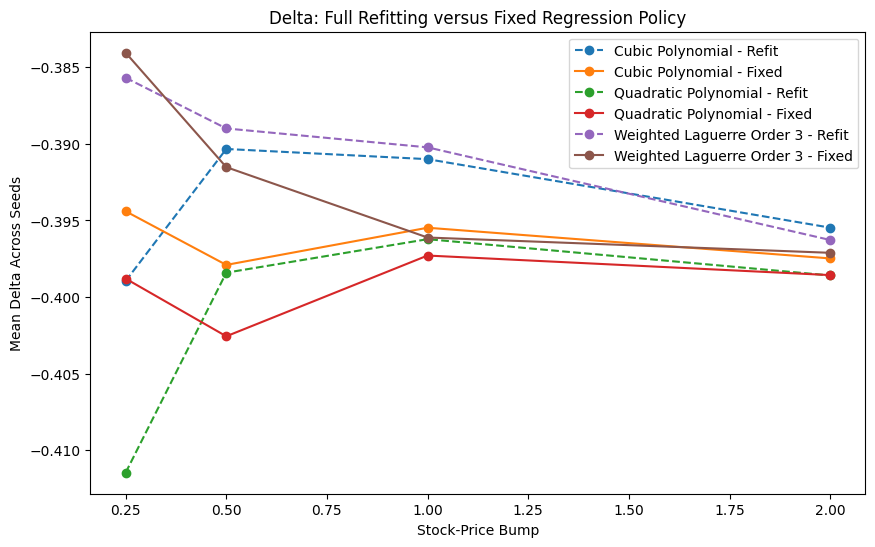

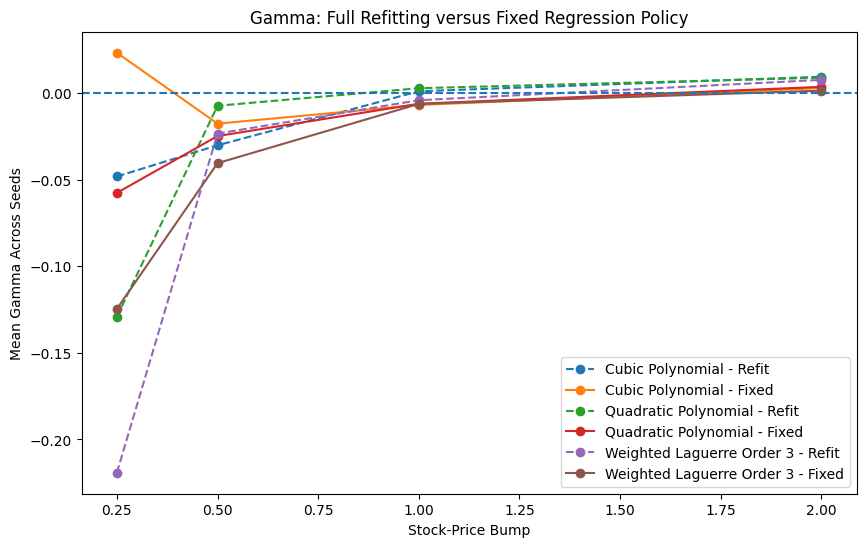

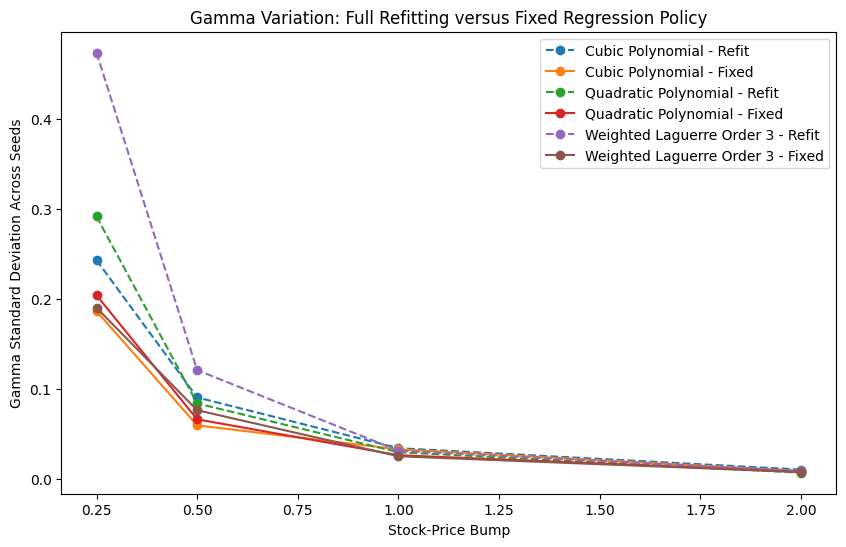

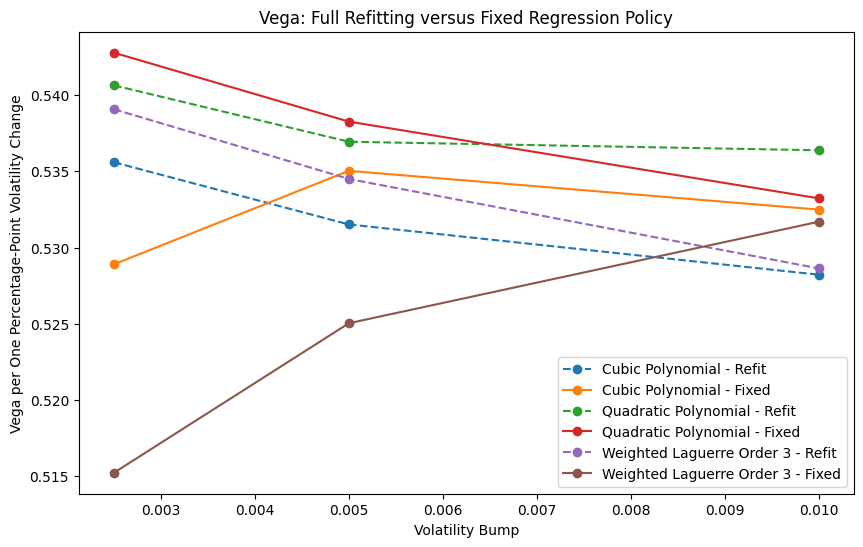

 Part 3B - Fixed-Regression-Policy Greeks: 

Experiment settings:
Number of paths: 10000
Number of time intervals: 50
Random seeds: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Stock-price bumps used for robustness checks: [0.25, 0.5, 1.0, 2.0]
Volatility bumps used for robustness checks: [0.0025, 0.005, 0.01]
Common random numbers used: True
Regression refitted for bumped valuations: False
Base regression coefficients held fixed: True
Bumped exercise decisions allowed to respond to bumped paths: True

Internal consistency checks:
All Delta/Gamma discounting checks passed: True
All Vega discounting checks passed: True
Fixed policy exactly reproduces the trained base valuation: True

Economic checks:
All mean Delta estimates are negative: True
All mean Vega estimates are positive: True
All primary-bump mean Gamma estimates are within ±0.010 of zero: True
Note: small negative Monte Carlo Gamma estimates are treated as finite-difference noise rather than an implementation failure.

Headline comparison

,Regression_Model,Stock_Price_Bump,Part_3A_Mean_Delta,Part_3A_Delta_SD,Part_3A_Mean_Gamma,Part_3A_Gamma_SD,Part_3B_Mean_Delta,Part_3B_Delta_SD,Part_3B_Mean_Gamma,Part_3B_Gamma_SD,Delta_Mean_Difference_3B_Minus_3A,Gamma_Mean_Difference_3B_Minus_3A,Delta_SD_Reduction_Percentage,Gamma_SD_Reduction_Percentage
2,Cubic Polynomial,1.0,-0.390996,0.010666,0.001144,0.034324,-0.395475,0.014094,-0.006765,0.033016,-0.004479,-0.007909,-32.136343,3.810983
6,Quadratic Polynomial,1.0,-0.396222,0.013192,0.002913,0.029847,-0.397290,0.012795,-0.006066,0.026514,-0.001069,-0.008979,3.008685,11.166028
10,Weighted Laguerre Order 3,1.0,-0.390225,0.010894,-0.004018,0.031511,-0.396113,0.015106,-0.006152,0.025334,-0.005888,-0.002134,-38.660346,19.602510


Primary Part 3A versus Part 3B Vega comparison:


,Regression_Model,Volatility_Bump,Part_3A_Mean_Vega,Part_3A_Vega_SD,Part_3B_Mean_Vega,Part_3B_Vega_SD,Vega_Mean_Difference_3B_Minus_3A,Vega_SD_Reduction_Percentage
1,Cubic Polynomial,0.005,53.151451,1.375079,53.502972,2.275593,0.351521,-65.488181
4,Quadratic Polynomial,0.005,53.693763,1.342434,53.825791,3.416029,0.132028,-154.465215
7,Weighted Laguerre Order 3,0.005,53.449662,1.149321,52.503598,2.491238,-0.946064,-116.757442



Most stable Part 3B models at the primary bump sizes:
Lowest fixed-policy Delta SD: Quadratic Polynomial
Lowest fixed-policy Gamma SD: Weighted Laguerre Order 3
Lowest fixed-policy Vega SD: Cubic Polynomial

Primary-bump stability comparison by model:
Cubic Polynomial: Delta SD change = -32.14%, Gamma SD change = 3.81%
Quadratic Polynomial: Delta SD change = 3.01%, Gamma SD change = 11.17%
Weighted Laguerre Order 3: Delta SD change = -38.66%, Gamma SD change = 19.60%
Cubic Polynomial: Vega SD change = -65.49%
Quadratic Polynomial: Vega SD change = -154.47%
Weighted Laguerre Order 3: Vega SD change = -116.76%

Interpretation:
The fixed regression correctly reproduces the original base valuation.
At the primary stock-price bump, fixing the regression reduces Gamma variation on average across the tested models. This suggests that regression refitting contributes to Gamma noise.
Delta remains stable under both methods. Vega remains positive, although fixing the regression does not consist

In [13]:
#### PART 3B - FIXED-REGRESSION-POLICY GREEKS USING COMMON RANDOM NUMBERS ####

# Goal:
# 1. Estimate Delta, Gamma, and Vega using central finite differences
# 2. Use the same random shocks for every base and bumped valuation
# 3. Fit the Longstaff-Schwartz regression only once at the base parameters
# 4. Reuse the exact base regression coefficients for all bumped paths
# 5. Compare the fixed-regression results with Part 3A, where the regression was refitted for each bumped valuation
# 6. Test whether regression refitting is a major source of Greek noise

# Important:
# - The fitted continuation functions are held fixed after training
# - Bumped paths make their own exercise decisions using the regression functions fitted to the base valuation
# - 3A - Full Refit | 3B - Fixed Regression Policy

### TRAIN THE BASE LONGSTAFF-SCHWARTZ POLICY

# Simulate the base paths and fit a continuation-value regression at each exercise date
# Store the fitted regression coefficients, base LSM price, and results
# Keep these coefficients fixed for all bumped valuations
def train_fixed_regression_policy(S0_input, K, r, sigma_input, T, random_shocks, basis_type, regression_order):
    if S0_input <= 0:
        raise ValueError("S0_input must be greater than zero.")
    if sigma_input <= 0:
        raise ValueError("sigma_input must be greater than zero.")

    # Read the simulation dimensions from the supplied common-random-number matrix
    number_of_steps, number_of_paths = random_shocks.shape

    # Calculate the length of each exercise interval and its one-step discount factor
    experiment_dt = T / number_of_steps
    one_step_discount_factor = np.exp(-r * experiment_dt)

    # Simulate the base risk-neutral paths
    simulated_paths = np.zeros((number_of_paths, number_of_steps + 1))
    simulated_paths[:, 0] = S0_input

    for t in range(1, number_of_steps + 1):
        Z_t = random_shocks[t - 1, :]
        simulated_paths[:, t] = (simulated_paths[:, t - 1] * np.exp((r - 0.5 * sigma_input**2) * experiment_dt + sigma_input * np.sqrt(experiment_dt) * Z_t))

    # Set the option cashflows at maturity
    cashflows = np.maximum(K - simulated_paths[:, -1], 0)

    exercise_time = np.full(number_of_paths, number_of_steps, dtype=int)
    exercise_stock_price = simulated_paths[:, -1].copy()

    exercise_boundary = np.full(number_of_steps + 1, np.nan)
    exercise_boundary[number_of_steps] = K

    # Store the fitted regression and results for each exercise date
    coefficients_by_time = {}
    condition_number_by_time = {}
    number_itm_by_time = {}

    # Full Longstaff-Schwartz backward induction at the base parameters
    for t in range(number_of_steps - 1, 0, -1):
        current_stock_prices = simulated_paths[:, t]
        immediate_exercise_values = np.maximum(K - current_stock_prices, 0)
        discounted_cashflows = cashflows * one_step_discount_factor
        in_the_money = immediate_exercise_values > 0
        number_in_the_money = int(np.sum(in_the_money))

        # Record how many paths are available for the regression at this date
        number_itm_by_time[t] = number_in_the_money

        # No regression can be fitted when no simulated paths are in the money
        if number_in_the_money == 0:
            coefficients_by_time[t] = None
            condition_number_by_time[t] = np.nan
            cashflows = discounted_cashflows
            continue

        stock_prices_itm = current_stock_prices[in_the_money]
        exercise_values_itm = immediate_exercise_values[in_the_money]
        continuation_targets_itm = discounted_cashflows[in_the_money]

        regression_matrix = create_greeks_regression_matrix(stock_prices=stock_prices_itm, K=K, basis_type=basis_type, order=regression_order)

        regression_coefficients, *_ = np.linalg.lstsq(regression_matrix, continuation_targets_itm, rcond=None)

        coefficients_by_time[t] = regression_coefficients.copy()
        condition_number_by_time[t] = np.linalg.cond(regression_matrix)

        estimated_continuation_values = (regression_matrix @ regression_coefficients)

        exercise_now_itm = (exercise_values_itm > estimated_continuation_values)

        itm_indices = np.where(in_the_money)[0]
        exercise_indices = itm_indices[exercise_now_itm]

        # Assume that every path continues
        cashflows = discounted_cashflows.copy()

        # Replace the discounted future cashflow with the immediate payoff where exercise is optimal
        cashflows[exercise_indices] = immediate_exercise_values[exercise_indices]

        exercise_time[exercise_indices] = t
        exercise_stock_price[exercise_indices] = current_stock_prices[exercise_indices]

        if len(exercise_indices) > 0:
            exercise_boundary[t] = np.max(current_stock_prices[exercise_indices])

    continuation_value_time_0 = (np.mean(cashflows) * one_step_discount_factor)

    immediate_exercise_value_time_0 = max(K - S0_input, 0)
    american_put_price = max(immediate_exercise_value_time_0, continuation_value_time_0)

    cashflow_at_exercise = np.maximum(K - exercise_stock_price, 0)
    present_values = (cashflow_at_exercise * np.exp(-r * exercise_time * experiment_dt))

    independent_price = np.mean(present_values)
    discounting_difference = abs(continuation_value_time_0 - independent_price)

    finite_condition_numbers = np.array([value for value in condition_number_by_time.values() if np.isfinite(value)])

    return {
        "Price": american_put_price,
        "Independent_Price": independent_price,
        "Discounting_Difference": discounting_difference,
        "Coefficients_By_Time": coefficients_by_time,
        "Condition_Number_By_Time": condition_number_by_time,
        "Number_ITM_By_Time": number_itm_by_time,
        "Exercise_Time": exercise_time,
        "Exercise_Boundary": exercise_boundary,
        "Early_Exercise_Percentage": (np.mean(exercise_time < number_of_steps) * 100),
        "Present_Value_SD": np.std(present_values, ddof=1),
        "Mean_Condition_Number": (
            np.mean(finite_condition_numbers) if len(finite_condition_numbers) > 0 else np.nan
        )
    }

### VALUE PATHS USING THE FIXED BASE REGRESSION POLICY

# Price an American put using the regression coefficients fitted at the base parameters
# Keep the regression coefficients fixed instead of refitting them
def price_with_fixed_regression_policy(S0_input, K, r, sigma_input, T, random_shocks, basis_type, regression_order, coefficients_by_time):
    if S0_input <= 0:
        raise ValueError("S0_input must be greater than zero.")

    if sigma_input <= 0:
        raise ValueError("sigma_input must be greater than zero.")

    # Read the simulation dimensions from the supplied common-random-number matrix
    number_of_steps, number_of_paths = random_shocks.shape

    # Calculate the length of each exercise interval and its one-step discount factor
    experiment_dt = T / number_of_steps
    one_step_discount_factor = np.exp(-r * experiment_dt)

    # Simulate paths using the supplied bumped input and the same shocks
    simulated_paths = np.zeros((number_of_paths, number_of_steps + 1))
    simulated_paths[:, 0] = S0_input

    for t in range(1, number_of_steps + 1):
        Z_t = random_shocks[t - 1, :]
        simulated_paths[:, t] = (simulated_paths[:, t - 1] * np.exp((r - 0.5 * sigma_input**2) * experiment_dt + sigma_input * np.sqrt(experiment_dt) * Z_t))

    cashflows = np.maximum(K - simulated_paths[:, -1], 0)

    exercise_time = np.full(number_of_paths, number_of_steps, dtype=int)
    exercise_stock_price = simulated_paths[:, -1].copy()

    exercise_boundary = np.full(number_of_steps + 1, np.nan)
    exercise_boundary[number_of_steps] = K

    # Apply the fixed base continuation functions backward through time
    for t in range(number_of_steps - 1, 0, -1):
        current_stock_prices = simulated_paths[:, t]
        immediate_exercise_values = np.maximum(K - current_stock_prices, 0)
        discounted_cashflows = cashflows * one_step_discount_factor
        in_the_money = immediate_exercise_values > 0

        # Retrieve the regression fitted at this date using the unbumped base paths
        regression_coefficients = coefficients_by_time.get(t)

        # Continue all paths if the base training sample supplied no
        # regression at this time or if no bumped path is in the money
        if regression_coefficients is None or not np.any(in_the_money):
            cashflows = discounted_cashflows
            continue

        stock_prices_itm = current_stock_prices[in_the_money]
        exercise_values_itm = immediate_exercise_values[in_the_money]

        regression_matrix = create_greeks_regression_matrix(stock_prices=stock_prices_itm, K=K, basis_type=basis_type, order=regression_order)

        estimated_continuation_values = (regression_matrix @ regression_coefficients)

        exercise_now_itm = (exercise_values_itm > estimated_continuation_values)

        itm_indices = np.where(in_the_money)[0]
        exercise_indices = itm_indices[exercise_now_itm]

        # Assume that every path continues
        cashflows = discounted_cashflows.copy()

        # Replace the discounted future cashflow with the immediate payoff where exercise is optimal
        cashflows[exercise_indices] = immediate_exercise_values[exercise_indices]

        exercise_time[exercise_indices] = t
        exercise_stock_price[exercise_indices] = current_stock_prices[exercise_indices]

        if len(exercise_indices) > 0:
            exercise_boundary[t] = np.max(current_stock_prices[exercise_indices])

    continuation_value_time_0 = (np.mean(cashflows) * one_step_discount_factor)

    immediate_exercise_value_time_0 = max(K - S0_input, 0)
    american_put_price = max(immediate_exercise_value_time_0, continuation_value_time_0)

    cashflow_at_exercise = np.maximum(K - exercise_stock_price, 0)
    present_values = (cashflow_at_exercise * np.exp(-r * exercise_time * experiment_dt))

    independent_price = np.mean(present_values)
    discounting_difference = abs(continuation_value_time_0 - independent_price)

    return {
        "Price": american_put_price,
        "Independent_Price": independent_price,
        "Discounting_Difference": discounting_difference,
        "Exercise_Time": exercise_time,
        "Exercise_Boundary": exercise_boundary,
        "Early_Exercise_Percentage": (np.mean(exercise_time < number_of_steps) * 100),
        "Present_Value_SD": np.std(present_values, ddof=1)
    }

### RUN FIXED-POLICY DELTA AND GAMMA EXPERIMENT

# Store one row for every model, seed and stock-price bump
fixed_policy_delta_gamma_results = []

# Store the base-policy training diagnostics once for every model and seed
fixed_policy_training_results = []

for model in greeks_models:
    model_name = model["Model_Name"]
    basis_type = model["Basis_Type"]
    regression_order = model["Order"]

    for seed in greeks_seeds:
        random_number_generator = np.random.default_rng(seed)
        random_shocks = random_number_generator.standard_normal((greeks_n_steps, greeks_n_paths))

        # Train the continuation regressions once at the base parameters
        base_training_result = train_fixed_regression_policy(
            S0_input=S0,
            K=K,
            r=r,
            sigma_input=sigma,
            T=T,
            random_shocks=random_shocks,
            basis_type=basis_type,
            regression_order=regression_order
        )
        fixed_policy_training_results.append({
            "Regression_Model": model_name,
            "Seed": seed,
            "Base_Price": base_training_result["Price"],
            "Base_Independent_Price": base_training_result["Independent_Price"],
            "Base_Discounting_Difference": base_training_result["Discounting_Difference"],
            "Base_Early_Exercise_Percentage": base_training_result["Early_Exercise_Percentage"],
            "Mean_Condition_Number": base_training_result["Mean_Condition_Number"],
        })

        # Extract the complete set of base regression coefficients by exercise date
        fixed_coefficients = base_training_result["Coefficients_By_Time"]

        # Confirm that applying the stored policy back to the base paths
        # reproduces the trained base valuation
        fixed_base_result = price_with_fixed_regression_policy(
            S0_input=S0,
            K=K,
            r=r,
            sigma_input=sigma,
            T=T,
            random_shocks=random_shocks,
            basis_type=basis_type,
            regression_order=regression_order,
            coefficients_by_time=fixed_coefficients
        )

        # This should be zero because the same paths and fitted coefficients are being reused
        base_policy_reproduction_difference = abs(base_training_result["Price"] - fixed_base_result["Price"])

        # Revalue the option above and below S0 for each finite-difference bump
        for stock_price_bump in stock_price_bumps:

            lower_stock_result = price_with_fixed_regression_policy(
                S0_input=S0 - stock_price_bump,
                K=K,
                r=r,
                sigma_input=sigma,
                T=T,
                random_shocks=random_shocks,
                basis_type=basis_type,
                regression_order=regression_order,
                coefficients_by_time=fixed_coefficients
            )

            upper_stock_result = price_with_fixed_regression_policy(
                S0_input=S0 + stock_price_bump,
                K=K,
                r=r,
                sigma_input=sigma,
                T=T,
                random_shocks=random_shocks,
                basis_type=basis_type,
                regression_order=regression_order,
                coefficients_by_time=fixed_coefficients
            )

            delta_estimate = (upper_stock_result["Price"] - lower_stock_result["Price"]) / (2 * stock_price_bump)
            gamma_estimate = (upper_stock_result["Price"] - 2 * fixed_base_result["Price"] + lower_stock_result["Price"]) / (stock_price_bump**2)
            maximum_discounting_difference = max(fixed_base_result["Discounting_Difference"], lower_stock_result["Discounting_Difference"], upper_stock_result["Discounting_Difference"])
            fixed_policy_delta_gamma_results.append({
                "Regression_Model": model_name,
                "Basis_Type": basis_type,
                "Regression_Order": regression_order,
                "Seed": seed,
                "Stock_Price_Bump": stock_price_bump,
                "Lower_Stock_Price": S0 - stock_price_bump,
                "Base_Stock_Price": S0,
                "Upper_Stock_Price": S0 + stock_price_bump,
                "Lower_Price": lower_stock_result["Price"],
                "Base_Price": fixed_base_result["Price"],
                "Upper_Price": upper_stock_result["Price"],
                "Delta": delta_estimate,
                "Gamma": gamma_estimate,
                "Lower_Early_Exercise_Percentage": lower_stock_result["Early_Exercise_Percentage"],
                "Base_Early_Exercise_Percentage": fixed_base_result["Early_Exercise_Percentage"],
                "Upper_Early_Exercise_Percentage": upper_stock_result["Early_Exercise_Percentage"],
                "Base_Policy_Reproduction_Difference": base_policy_reproduction_difference,
                "Maximum_Discounting_Difference": maximum_discounting_difference,
            })

df_fixed_policy_delta_gamma_all = pd.DataFrame(fixed_policy_delta_gamma_results)
df_fixed_policy_training = pd.DataFrame(fixed_policy_training_results)
display(df_fixed_policy_delta_gamma_all.head(12).round(8))
display(df_fixed_policy_training.round(8))

### RUN FIXED-POLICY VEGA EXPERIMENT

# Store one row for every model, seed and volatility bump
fixed_policy_vega_results = []

for model in greeks_models:
    model_name = model["Model_Name"]
    basis_type = model["Basis_Type"]
    regression_order = model["Order"]

    for seed in greeks_seeds:
        random_number_generator = np.random.default_rng(seed)
        random_shocks = random_number_generator.standard_normal((greeks_n_steps, greeks_n_paths))

        # The policy is again fitted only at the base volatility
        base_training_result = train_fixed_regression_policy(
            S0_input=S0,
            K=K,
            r=r,
            sigma_input=sigma,
            T=T,
            random_shocks=random_shocks,
            basis_type=basis_type,
            regression_order=regression_order
        )

        fixed_coefficients = base_training_result["Coefficients_By_Time"]

        fixed_base_result = price_with_fixed_regression_policy(
            S0_input=S0,
            K=K,
            r=r,
            sigma_input=sigma,
            T=T,
            random_shocks=random_shocks,
            basis_type=basis_type,
            regression_order=regression_order,
            coefficients_by_time=fixed_coefficients
        )

        base_policy_reproduction_difference = abs(base_training_result["Price"] - fixed_base_result["Price"])

        # Revalue above and below the original volatility for each Vega bump
        for volatility_bump in volatility_bumps:
            # The lower bumped volatility must remain economically and mathematically valid
            if sigma - volatility_bump <= 0:
                raise ValueError("Volatility bump is too large and creates a non-positive lower volatility.")

            lower_volatility_result = price_with_fixed_regression_policy(
                S0_input=S0,
                K=K,
                r=r,
                sigma_input=sigma - volatility_bump,
                T=T,
                random_shocks=random_shocks,
                basis_type=basis_type,
                regression_order=regression_order,
                coefficients_by_time=fixed_coefficients
            )

            upper_volatility_result = price_with_fixed_regression_policy(
                S0_input=S0,
                K=K,
                r=r,
                sigma_input=sigma + volatility_bump,
                T=T,
                random_shocks=random_shocks,
                basis_type=basis_type,
                regression_order=regression_order,
                coefficients_by_time=fixed_coefficients
            )

            vega_per_unit_volatility = (upper_volatility_result["Price"] - lower_volatility_result["Price"]) / (2 * volatility_bump)
            vega_per_one_percentage_point = (vega_per_unit_volatility * 0.01)

            maximum_discounting_difference = max(
                fixed_base_result["Discounting_Difference"],
                lower_volatility_result["Discounting_Difference"],
                upper_volatility_result["Discounting_Difference"]
            )

            fixed_policy_vega_results.append({
                "Regression_Model": model_name,
                "Basis_Type": basis_type,
                "Regression_Order": regression_order,
                "Seed": seed,
                "Volatility_Bump": volatility_bump,
                "Lower_Volatility": sigma - volatility_bump,
                "Base_Volatility": sigma,
                "Upper_Volatility": sigma + volatility_bump,
                "Lower_Price": lower_volatility_result["Price"],
                "Base_Price": fixed_base_result["Price"],
                "Upper_Price": upper_volatility_result["Price"],
                "Vega_Per_Unit_Volatility": vega_per_unit_volatility,
                "Vega_Per_One_Percentage_Point": vega_per_one_percentage_point,
                "Lower_Early_Exercise_Percentage": lower_volatility_result["Early_Exercise_Percentage"],
                "Base_Early_Exercise_Percentage": fixed_base_result["Early_Exercise_Percentage"],
                "Upper_Early_Exercise_Percentage": upper_volatility_result["Early_Exercise_Percentage"],
                "Base_Policy_Reproduction_Difference": base_policy_reproduction_difference,
                "Maximum_Discounting_Difference": maximum_discounting_difference,
            })

# Convert the collected seed-level Vega results into a dataframe
df_fixed_policy_vega_all = pd.DataFrame(fixed_policy_vega_results)
display(df_fixed_policy_vega_all.head(12).round(8))

### SUMMARISE FIXED-POLICY DELTA AND GAMMA

df_fixed_policy_delta_gamma_summary = (df_fixed_policy_delta_gamma_all.groupby(["Regression_Model", "Stock_Price_Bump"]).agg(
        Mean_Base_Price=("Base_Price", "mean"),
        Base_Price_SD_Across_Seeds=("Base_Price", "std"),
        Mean_Delta=("Delta", "mean"),
        Delta_SD_Across_Seeds=("Delta", "std"),
        Minimum_Delta=("Delta", "min"),
        Maximum_Delta=("Delta", "max"),
        Mean_Gamma=("Gamma", "mean"),
        Gamma_SD_Across_Seeds=("Gamma", "std"),
        Minimum_Gamma=("Gamma", "min"),
        Maximum_Gamma=("Gamma", "max"),
        Maximum_Base_Policy_Reproduction_Difference=("Base_Policy_Reproduction_Difference", "max"),
        Maximum_Discounting_Difference=("Maximum_Discounting_Difference", "max")
    ).reset_index())

df_fixed_policy_delta_gamma_summary["Delta_Standard_Error"] = (df_fixed_policy_delta_gamma_summary["Delta_SD_Across_Seeds"] / np.sqrt(len(greeks_seeds)))
df_fixed_policy_delta_gamma_summary["Gamma_Standard_Error"] = (df_fixed_policy_delta_gamma_summary["Gamma_SD_Across_Seeds"] / np.sqrt(len(greeks_seeds)))
df_fixed_policy_delta_gamma_summary["Gamma_Coefficient_Of_Variation"] = (
    df_fixed_policy_delta_gamma_summary["Gamma_SD_Across_Seeds"] / df_fixed_policy_delta_gamma_summary["Mean_Gamma"].abs()
)
display(df_fixed_policy_delta_gamma_summary.round(8))

### SUMMARISE FIXED-POLICY VEGA

df_fixed_policy_vega_summary = (df_fixed_policy_vega_all.groupby(["Regression_Model", "Volatility_Bump"]).agg(
        Mean_Vega_Per_Unit_Volatility=("Vega_Per_Unit_Volatility", "mean"),
        Vega_SD_Across_Seeds=("Vega_Per_Unit_Volatility", "std"),
        Minimum_Vega=("Vega_Per_Unit_Volatility", "min"),
        Maximum_Vega=("Vega_Per_Unit_Volatility", "max"),
        Mean_Vega_Per_One_Percentage_Point=("Vega_Per_One_Percentage_Point", "mean"),
        Maximum_Base_Policy_Reproduction_Difference=("Base_Policy_Reproduction_Difference", "max"),
        Maximum_Discounting_Difference=("Maximum_Discounting_Difference", "max")
    ).reset_index())

df_fixed_policy_vega_summary["Vega_Standard_Error"] = (df_fixed_policy_vega_summary["Vega_SD_Across_Seeds"] / np.sqrt(len(greeks_seeds)))
df_fixed_policy_vega_summary["Vega_Coefficient_Of_Variation"] = (df_fixed_policy_vega_summary["Vega_SD_Across_Seeds"] / df_fixed_policy_vega_summary["Mean_Vega_Per_Unit_Volatility"].abs())
display(df_fixed_policy_vega_summary.round(8))

### INTERNAL AND ECONOMIC CONSISTENCY CHECKS

fixed_policy_delta_gamma_discounting_checks_pass = np.allclose(df_fixed_policy_delta_gamma_all["Maximum_Discounting_Difference"], 0, rtol=1e-9, atol=1e-9)
fixed_policy_vega_discounting_checks_pass = np.allclose(df_fixed_policy_vega_all["Maximum_Discounting_Difference"], 0, rtol=1e-9, atol=1e-9)

# Check that the fixed regression gives the same base price
fixed_policy_base_reproduction_checks_pass = (
    np.allclose(df_fixed_policy_delta_gamma_all["Base_Policy_Reproduction_Difference"], 0, rtol=1e-9, atol=1e-9)
    and np.allclose(df_fixed_policy_vega_all["Base_Policy_Reproduction_Difference"], 0, rtol=1e-9, atol=1e-9)
)

fixed_policy_all_mean_deltas_are_negative = np.all(df_fixed_policy_delta_gamma_summary["Mean_Delta"] < 0)
fixed_policy_all_mean_gammas_are_positive = np.all(df_fixed_policy_delta_gamma_summary["Mean_Gamma"] > 0)
fixed_policy_all_mean_vegas_are_positive = np.all(df_fixed_policy_vega_summary["Mean_Vega_Per_Unit_Volatility"] > 0)

### PRIMARY FIXED-POLICY GREEKS TABLE

# These values were defined in Part 3A: primary_stock_bump = 1.00, primary_volatility_bump = 0.005
df_fixed_policy_primary_delta_gamma = (df_fixed_policy_delta_gamma_summary[df_fixed_policy_delta_gamma_summary["Stock_Price_Bump"] == primary_stock_bump].copy())
df_fixed_policy_primary_vega = (df_fixed_policy_vega_summary[df_fixed_policy_vega_summary["Volatility_Bump"] == primary_volatility_bump].copy())

# Combine the main Delta, Gamma and Vega results into one comparison table
df_fixed_policy_primary_greeks = (
    df_fixed_policy_primary_delta_gamma[
        ["Regression_Model", "Mean_Base_Price", "Mean_Delta", "Delta_SD_Across_Seeds", "Mean_Gamma", "Gamma_SD_Across_Seeds", "Gamma_Coefficient_Of_Variation"]
    ]
    .merge(
        df_fixed_policy_primary_vega[["Regression_Model", "Mean_Vega_Per_Unit_Volatility", "Mean_Vega_Per_One_Percentage_Point", "Vega_SD_Across_Seeds", "Vega_Coefficient_Of_Variation"]],
        on="Regression_Model",
        how="left"
    )
)
display(df_fixed_policy_primary_greeks.round(8))

### COMPARE FULL-REFIT VS FIXED-REGRESSION-POLICY FINITE-DIFFERENCE GREEKS (PART 3A WITH PART 3B)

# Part 3A (full-refit) summary tables already exist:
# - df_delta_gamma_summary
# - df_vega_summary

# Rename the Part 3A (full-refit) columns so both methods can be shown side by side
part_3a_delta_gamma_comparison = (
    df_delta_gamma_summary[["Regression_Model", "Stock_Price_Bump", "Mean_Delta", "Delta_SD_Across_Seeds", "Mean_Gamma", "Gamma_SD_Across_Seeds"]]
    .rename(columns={
        "Mean_Delta": "Part_3A_Mean_Delta",
        "Delta_SD_Across_Seeds": "Part_3A_Delta_SD",
        "Mean_Gamma": "Part_3A_Mean_Gamma",
        "Gamma_SD_Across_Seeds": "Part_3A_Gamma_SD"
    })
)

# Rename the Part 3B (fixed-regression-policy) columns using the same comparison structure
part_3b_delta_gamma_comparison = (
    df_fixed_policy_delta_gamma_summary[["Regression_Model", "Stock_Price_Bump", "Mean_Delta", "Delta_SD_Across_Seeds", "Mean_Gamma", "Gamma_SD_Across_Seeds"]]
    .rename(columns={
        "Mean_Delta": "Part_3B_Mean_Delta",
        "Delta_SD_Across_Seeds": "Part_3B_Delta_SD",
        "Mean_Gamma": "Part_3B_Mean_Gamma",
        "Gamma_SD_Across_Seeds": "Part_3B_Gamma_SD"
    })
)

df_part_3a_vs_3b_delta_gamma = (part_3a_delta_gamma_comparison .merge(part_3b_delta_gamma_comparison, on=["Regression_Model", "Stock_Price_Bump"], how="inner"))
df_part_3a_vs_3b_delta_gamma["Delta_Mean_Difference_3B_Minus_3A"] = (df_part_3a_vs_3b_delta_gamma["Part_3B_Mean_Delta"] - df_part_3a_vs_3b_delta_gamma["Part_3A_Mean_Delta"])
df_part_3a_vs_3b_delta_gamma["Gamma_Mean_Difference_3B_Minus_3A"] = (df_part_3a_vs_3b_delta_gamma["Part_3B_Mean_Gamma"] - df_part_3a_vs_3b_delta_gamma["Part_3A_Mean_Gamma"])

# Positive percentages mean Part 3B reduced variation across random seeds
df_part_3a_vs_3b_delta_gamma["Delta_SD_Reduction_Percentage"] = (
    (df_part_3a_vs_3b_delta_gamma["Part_3A_Delta_SD"] - df_part_3a_vs_3b_delta_gamma["Part_3B_Delta_SD"])
    / df_part_3a_vs_3b_delta_gamma["Part_3A_Delta_SD"] * 100
)
df_part_3a_vs_3b_delta_gamma["Gamma_SD_Reduction_Percentage"] = (
    (df_part_3a_vs_3b_delta_gamma["Part_3A_Gamma_SD"] - df_part_3a_vs_3b_delta_gamma["Part_3B_Gamma_SD"])
    / df_part_3a_vs_3b_delta_gamma["Part_3A_Gamma_SD"] * 100
)

# Prepare the Part 3A Vega results for the same side-by-side comparison
part_3a_vega_comparison = (
    df_vega_summary[["Regression_Model", "Volatility_Bump", "Mean_Vega_Per_Unit_Volatility", "Vega_SD_Across_Seeds"]]
    .rename(columns={"Mean_Vega_Per_Unit_Volatility": "Part_3A_Mean_Vega", "Vega_SD_Across_Seeds": "Part_3A_Vega_SD"})
)

# Prepare the Part 3B Vega results using matching column names
part_3b_vega_comparison = (
    df_fixed_policy_vega_summary[["Regression_Model", "Volatility_Bump", "Mean_Vega_Per_Unit_Volatility", "Vega_SD_Across_Seeds"]]
    .rename(columns={"Mean_Vega_Per_Unit_Volatility": "Part_3B_Mean_Vega","Vega_SD_Across_Seeds": "Part_3B_Vega_SD"})
)

df_part_3a_vs_3b_vega = (part_3a_vega_comparison .merge(part_3b_vega_comparison, on=["Regression_Model", "Volatility_Bump"], how="inner"))
df_part_3a_vs_3b_vega["Vega_Mean_Difference_3B_Minus_3A"] = (df_part_3a_vs_3b_vega["Part_3B_Mean_Vega"] - df_part_3a_vs_3b_vega["Part_3A_Mean_Vega"])
df_part_3a_vs_3b_vega["Vega_SD_Reduction_Percentage"] = (
    (df_part_3a_vs_3b_vega["Part_3A_Vega_SD"] - df_part_3a_vs_3b_vega["Part_3B_Vega_SD"])
    / df_part_3a_vs_3b_vega["Part_3A_Vega_SD"] * 100
)

display(df_part_3a_vs_3b_delta_gamma.round(8))
display(df_part_3a_vs_3b_vega.round(8))

### PRIMARY PART 3A VERSUS PART 3B COMPARISON

df_primary_part_3a_vs_3b_delta_gamma = (df_part_3a_vs_3b_delta_gamma[df_part_3a_vs_3b_delta_gamma["Stock_Price_Bump"] == primary_stock_bump].copy())
df_primary_part_3a_vs_3b_vega = (df_part_3a_vs_3b_vega[df_part_3a_vs_3b_vega["Volatility_Bump"] == primary_volatility_bump].copy())

display(df_primary_part_3a_vs_3b_delta_gamma.round(8))
display(df_primary_part_3a_vs_3b_vega.round(8))

### IDENTIFY THE MOST STABLE PART 3B MODELS

most_stable_fixed_policy_delta_model = (df_fixed_policy_primary_delta_gamma.loc[df_fixed_policy_primary_delta_gamma["Delta_SD_Across_Seeds"].idxmin(), "Regression_Model"])
most_stable_fixed_policy_gamma_model = (df_fixed_policy_primary_delta_gamma.loc[df_fixed_policy_primary_delta_gamma["Gamma_SD_Across_Seeds"].idxmin(), "Regression_Model"])
most_stable_fixed_policy_vega_model = (df_fixed_policy_primary_vega.loc[df_fixed_policy_primary_vega["Vega_SD_Across_Seeds"].idxmin(), "Regression_Model"])
mean_primary_delta_sd_reduction = (df_primary_part_3a_vs_3b_delta_gamma["Delta_SD_Reduction_Percentage"].mean())
mean_primary_gamma_sd_reduction = (df_primary_part_3a_vs_3b_delta_gamma["Gamma_SD_Reduction_Percentage"].mean())
mean_primary_vega_sd_reduction = (df_primary_part_3a_vs_3b_vega["Vega_SD_Reduction_Percentage"].mean())

### DISPLAY VISUAL

#Plot part 3a (full-refit) versus 3b (fixed-regression-policy) delta
plt.figure(figsize=(10, 6))
for model_name in df_part_3a_vs_3b_delta_gamma["Regression_Model"].unique():
    model_results = df_part_3a_vs_3b_delta_gamma[df_part_3a_vs_3b_delta_gamma["Regression_Model"] == model_name]
    plt.plot(
        model_results["Stock_Price_Bump"],
        model_results["Part_3A_Mean_Delta"],
        marker="o",
        linestyle="--",
        label=f"{model_name} - Refit"
    )
    plt.plot(
        model_results["Stock_Price_Bump"],
        model_results["Part_3B_Mean_Delta"],
        marker="o",
        label=f"{model_name} - Fixed"
    )
plt.title("Delta: Full Refitting versus Fixed Regression Policy")
plt.xlabel("Stock-Price Bump")
plt.ylabel("Mean Delta Across Seeds")
plt.legend()
plt.show()

#Plot part 3a (full-refit) versus 3b (fixed-regression-policy) gamma
plt.figure(figsize=(10, 6))
for model_name in df_part_3a_vs_3b_delta_gamma["Regression_Model"].unique():
    model_results = df_part_3a_vs_3b_delta_gamma[df_part_3a_vs_3b_delta_gamma["Regression_Model"] == model_name]
    plt.plot(
        model_results["Stock_Price_Bump"],
        model_results["Part_3A_Mean_Gamma"],
        marker="o",
        linestyle="--",
        label=f"{model_name} - Refit"
    )
    plt.plot(
        model_results["Stock_Price_Bump"],
        model_results["Part_3B_Mean_Gamma"],
        marker="o",
        label=f"{model_name} - Fixed"
    )
plt.axhline(0, linestyle="--")
plt.title("Gamma: Full Refitting versus Fixed Regression Policy")
plt.xlabel("Stock-Price Bump")
plt.ylabel("Mean Gamma Across Seeds")
plt.legend()
plt.show()

# Plot gamma standard deviation comparison
plt.figure(figsize=(10, 6))
for model_name in df_part_3a_vs_3b_delta_gamma["Regression_Model"].unique():
    model_results = df_part_3a_vs_3b_delta_gamma[df_part_3a_vs_3b_delta_gamma["Regression_Model"] == model_name]
    plt.plot(
        model_results["Stock_Price_Bump"],
        model_results["Part_3A_Gamma_SD"],
        marker="o",
        linestyle="--",
        label=f"{model_name} - Refit"
    )
    plt.plot(
        model_results["Stock_Price_Bump"],
        model_results["Part_3B_Gamma_SD"],
        marker="o",
        label=f"{model_name} - Fixed"
    )
plt.title("Gamma Variation: Full Refitting versus Fixed Regression Policy")
plt.xlabel("Stock-Price Bump")
plt.ylabel("Gamma Standard Deviation Across Seeds")
plt.legend()
plt.show()

#Plot part 3a (full-refit) versus 3b (fixed-regression-policy) vega
plt.figure(figsize=(10, 6))

for model_name in df_part_3a_vs_3b_vega["Regression_Model"].unique():
    model_results = df_part_3a_vs_3b_vega[df_part_3a_vs_3b_vega["Regression_Model"] == model_name]
    plt.plot(
        model_results["Volatility_Bump"],
        model_results["Part_3A_Mean_Vega"] * 0.01,
        marker="o",
        linestyle="--",
        label=f"{model_name} - Refit"
    )
    plt.plot(
        model_results["Volatility_Bump"],
        model_results["Part_3B_Mean_Vega"] * 0.01,
        marker="o",
        label=f"{model_name} - Fixed"
    )
plt.title("Vega: Full Refitting versus Fixed Regression Policy")
plt.xlabel("Volatility Bump")
plt.ylabel("Vega per One Percentage-Point Volatility Change")
plt.legend()
plt.show()

# Print summary
# Use the selected bump sizes for the main comparison
# Use the other bump sizes to check the effect of bump size on the results
# Allow a small tolerance because Monte Carlo Gamma can vary slightly around zero
gamma_near_zero_tolerance = 0.01
primary_gamma_is_near_zero = (df_fixed_policy_primary_delta_gamma["Mean_Gamma"].abs() <= gamma_near_zero_tolerance).all()

print(" Part 3B - Fixed-Regression-Policy Greeks: ")

print("\nExperiment settings:")
print("Number of paths:", greeks_n_paths)
print("Number of time intervals:", greeks_n_steps)
print("Random seeds:", greeks_seeds)
print("Stock-price bumps used for robustness checks:", stock_price_bumps)
print("Volatility bumps used for robustness checks:", volatility_bumps)
print("Common random numbers used: True")
print("Regression refitted for bumped valuations: False")
print("Base regression coefficients held fixed: True")
print("Bumped exercise decisions allowed to respond to bumped paths: True")

print("\nInternal consistency checks:")
print("All Delta/Gamma discounting checks passed:", fixed_policy_delta_gamma_discounting_checks_pass)
print("All Vega discounting checks passed:", fixed_policy_vega_discounting_checks_pass)
print("Fixed policy exactly reproduces the trained base valuation:", fixed_policy_base_reproduction_checks_pass)

print("\nEconomic checks:")
print("All mean Delta estimates are negative:", fixed_policy_all_mean_deltas_are_negative)
print("All mean Vega estimates are positive:", fixed_policy_all_mean_vegas_are_positive)
print(f"All primary-bump mean Gamma estimates are within ±{gamma_near_zero_tolerance:.3f} of zero:", primary_gamma_is_near_zero)
print("Note: small negative Monte Carlo Gamma estimates are treated as " "finite-difference noise rather than an implementation failure.")

print("\nHeadline comparison settings:")
print("Primary stock-price bump:", primary_stock_bump)
print("Primary volatility bump:", primary_volatility_bump)
print("Other bump sizes are retained as robustness checks rather than " "being averaged into the headline conclusion.")

print("\nPrimary Part 3A versus Part 3B Delta/Gamma comparison:")
display(df_primary_part_3a_vs_3b_delta_gamma.round(8))
print("Primary Part 3A versus Part 3B Vega comparison:")
display(df_primary_part_3a_vs_3b_vega.round(8))

print("\nMost stable Part 3B models at the primary bump sizes:")
print("Lowest fixed-policy Delta SD:", most_stable_fixed_policy_delta_model)
print("Lowest fixed-policy Gamma SD:", most_stable_fixed_policy_gamma_model)
print("Lowest fixed-policy Vega SD:", most_stable_fixed_policy_vega_model)

print("\nPrimary-bump stability comparison by model:")
for _, row in df_primary_part_3a_vs_3b_delta_gamma.iterrows():
    print(
        f"{row['Regression_Model']}: "
        f"Delta SD change = {row['Delta_SD_Reduction_Percentage']:.2f}%, "
        f"Gamma SD change = {row['Gamma_SD_Reduction_Percentage']:.2f}%"
    )
for _, row in df_primary_part_3a_vs_3b_vega.iterrows():
    print(f"{row['Regression_Model']}: Vega SD change = {row['Vega_SD_Reduction_Percentage']:.2f}%")

print("\nInterpretation:")
if fixed_policy_base_reproduction_checks_pass:
    print(
        "The fixed regression correctly reproduces the original base valuation."
    )
else:
    print(
        "The fixed regression does not reproduce the original base valuation. Review the training and valuation functions."
    )
if mean_primary_gamma_sd_reduction > 0:
    print(
        "At the primary stock-price bump, fixing the regression reduces Gamma variation on average across the tested models. "
        "This suggests that regression refitting contributes to Gamma noise."
    )
else:
    print(
        "At the primary stock-price bump, fixing the regression does not reduce Gamma variation on average. "
        "Monte Carlo noise and the finite-difference method remain important sources of Gamma variation."
    )
print(
    "Delta remains stable under both methods. Vega remains positive, although fixing the regression does not consistently reduce its variation across seeds. "
    "Part 3B therefore isolates the effect of regression refitting rather than being expected to improve every Greek."
)
print(
    "Part 3A uses fully refitted regressions, while Part 3B keeps the base regressions fixed. "
    "The bump-size comparisons show how the choice of bump size affects the Greek estimates."
)

### EXPORT TABLES

# Export fixed-regression-policy (3b tables)
df_fixed_policy_delta_gamma_all.to_csv("part_3b_fixed_policy_delta_gamma_all.csv", index=False)
df_fixed_policy_vega_all.to_csv("part_3b_fixed_policy_vega_all.csv", index=False)
df_fixed_policy_delta_gamma_summary.to_csv("part_3b_fixed_policy_delta_gamma_summary.csv", index=False)
df_fixed_policy_vega_summary.to_csv("part_3b_fixed_policy_vega_summary.csv", index=False)
df_part_3a_vs_3b_delta_gamma.to_csv("part_3a_vs_3b_delta_gamma_comparison.csv", index=False)
df_part_3a_vs_3b_vega.to_csv("part_3a_vs_3b_vega_comparison.csv", index=False)

# Export primary headline tables
df_primary_part_3a_vs_3b_delta_gamma.to_csv("part_3_primary_delta_gamma_comparison.csv", index=False)
df_primary_part_3a_vs_3b_vega.to_csv("part_3_primary_vega_comparison.csv", index=False)

## Part 4 - Early-Exercise Boundary Robustness Analysis

First rows of the complete Part 4A boundary dataset:


,Regression_Model,Basis_Type,Regression_Order,Seed,Time_Index,Time_Years,Time_To_Maturity_Years,Exercise_Boundary,Boundary_As_Percentage_Of_Strike,Boundary_Observed
0,Quadratic Polynomial,Polynomial,2,1,1,0.04,1.96,NaN,NaN,False
1,Quadratic Polynomial,Polynomial,2,1,2,0.08,1.92,NaN,NaN,False
2,Quadratic Polynomial,Polynomial,2,1,3,0.12,1.88,NaN,NaN,False
3,Quadratic Polynomial,Polynomial,2,1,4,0.16,1.84,NaN,NaN,False
4,Quadratic Polynomial,Polynomial,2,1,5,0.20,1.80,66.276047,66.276047,True
5,Quadratic Polynomial,Polynomial,2,1,6,0.24,1.76,NaN,NaN,False
6,Quadratic Polynomial,Polynomial,2,1,7,0.28,1.72,NaN,NaN,False
7,Quadratic Polynomial,Polynomial,2,1,8,0.32,1.68,NaN,NaN,False
8,Quadratic Polynomial,Polynomial,2,1,9,0.36,1.64,NaN,NaN,False
9,Quadratic Polynomial,Polynomial,2,1,10,0.40,1.60,NaN,NaN,False



Seed-level price and boundary metrics:


,Regression_Model,Basis_Type,Regression_Order,Seed,Estimated_American_Put_Price,CRR_Benchmark,Price_Error_Versus_CRR,Absolute_Price_Error_Versus_CRR,Early_Exercise_Percentage,Mean_Condition_Number,...,Maximum_Observed_Boundary,Mean_Boundary_As_Percentage_Of_Strike,Missing_Boundary_Dates,Missing_Boundary_Percentage,Mean_Absolute_Adjacent_Change,RMS_Adjacent_Change,Squared_Roughness,Mean_Absolute_Curvature,Maximum_Absolute_Jump,Upward_Move_Percentage
0,Quadratic Polynomial,Polynomial,2,1,11.730486,11.545709,0.184777,0.184777,40.48,361.109946,...,85.896034,73.031444,11,22.448980,0.851001,1.258511,76.024748,1.230962,5.088742,54.166667
1,Cubic Polynomial,Polynomial,3,1,11.791037,11.545709,0.245327,0.245327,43.99,8500.090510,...,89.029435,72.005588,10,20.408163,2.232244,3.483330,582.412155,3.517284,12.263405,64.583333
2,Weighted Laguerre Order 3,Laguerre,3,1,11.794193,11.545709,0.248484,0.248484,43.63,26413.509440,...,88.616008,71.813360,10,20.408163,2.419852,4.100829,807.206246,3.881506,16.054738,66.666667
3,Quadratic Polynomial,Polynomial,2,2,11.445955,11.545709,-0.099754,0.099754,40.78,369.388185,...,84.012131,75.561596,11,22.448980,0.999284,1.336924,85.793525,1.497528,4.545709,62.500000
4,Cubic Polynomial,Polynomial,3,2,11.505328,11.545709,-0.040381,0.040381,43.74,8779.609408,...,88.527606,74.527274,10,20.408163,1.535110,2.315425,257.337230,2.202330,7.460742,62.500000
5,Weighted Laguerre Order 3,Laguerre,3,2,11.503974,11.545709,-0.041736,0.041736,43.61,27335.703761,...,88.028136,73.899966,8,16.326531,2.562781,6.343865,1931.741675,4.412930,29.724883,56.250000
6,Quadratic Polynomial,Polynomial,2,3,11.470757,11.545709,-0.074952,0.074952,40.63,377.125552,...,82.692877,75.165780,4,8.163265,0.987875,1.354434,88.055562,1.679345,4.907226,62.500000
7,Cubic Polynomial,Polynomial,3,3,11.465696,11.545709,-0.080013,0.080013,44.26,9231.925461,...,88.574276,75.237620,5,10.204082,1.909840,3.161992,479.913367,3.044848,15.055908,54.166667
8,Weighted Laguerre Order 3,Laguerre,3,3,11.436902,11.545709,-0.108807,0.108807,44.02,28584.910794,...,88.131606,75.244840,4,8.163265,2.184832,4.546774,992.311565,3.726517,23.063540,54.166667
9,Quadratic Polynomial,Polynomial,2,4,11.512186,11.545709,-0.033524,0.033524,39.63,366.951570,...,82.985744,74.182431,3,6.122449,1.244731,1.756509,148.095502,1.695867,7.008350,56.250000



Boundary level and cross-seed variation by exercise date:


,Regression_Model,Time_Index,Time_Years,Time_To_Maturity_Years,Mean_Exercise_Boundary,Boundary_SD_Across_Seeds,Minimum_Exercise_Boundary,Maximum_Exercise_Boundary,Number_Of_Observed_Seeds,Boundary_Range_Across_Seeds,Boundary_Standard_Error,Mean_Boundary_As_Percentage_Of_Strike
0,Cubic Polynomial,1,0.04,1.96,84.325362,NaN,84.325362,84.325362,1,0.000000,NaN,84.325362
1,Cubic Polynomial,2,0.08,1.92,79.991489,0.732148,79.324683,80.712605,4,1.387922,0.366074,79.991489
2,Cubic Polynomial,3,0.12,1.88,76.081242,1.240250,74.096122,77.476442,6,3.380320,0.506330,76.081242
3,Cubic Polynomial,4,0.16,1.84,74.116506,1.491013,72.000723,76.313859,6,4.313136,0.608704,74.116506
4,Cubic Polynomial,5,0.20,1.80,73.701584,2.451362,70.252831,75.996260,4,5.743429,1.225681,73.701584
5,Cubic Polynomial,6,0.24,1.76,73.107559,2.280866,69.791203,75.945446,6,6.154243,0.931160,73.107559
6,Cubic Polynomial,7,0.28,1.72,70.296157,5.321507,62.487401,73.826330,4,11.338929,2.660753,70.296157
7,Cubic Polynomial,8,0.32,1.68,70.583079,3.991318,65.411497,75.088180,4,9.676683,1.995659,70.583079
8,Cubic Polynomial,9,0.36,1.64,71.016486,1.654827,69.228273,72.921683,6,3.693410,0.675580,71.016486
9,Cubic Polynomial,10,0.40,1.60,70.988848,2.465347,66.106858,74.561246,8,8.454388,0.871632,70.988848



Overall Part 4A model comparison:


,Regression_Model,Mean_American_Put_Price,Price_SD_Across_Seeds,Mean_Absolute_Price_Error_Versus_CRR,Mean_Boundary_SD_Across_Time,Mean_Absolute_Adjacent_Change,Mean_Absolute_Curvature,Mean_Missing_Boundary_Percentage,Mean_Condition_Number,Overall_Boundary_Stability_Rank
0,Quadratic Polynomial,11.511453,0.130404,0.118004,1.775384,1.035809,1.575943,12.040816,370.253402,1
1,Cubic Polynomial,11.531225,0.132696,0.109208,3.009699,1.910912,3.068828,11.836735,8749.241199,2
2,Weighted Laguerre Order 3,11.536059,0.131950,0.107283,3.074734,1.946976,3.050754,10.612245,27176.971455,3


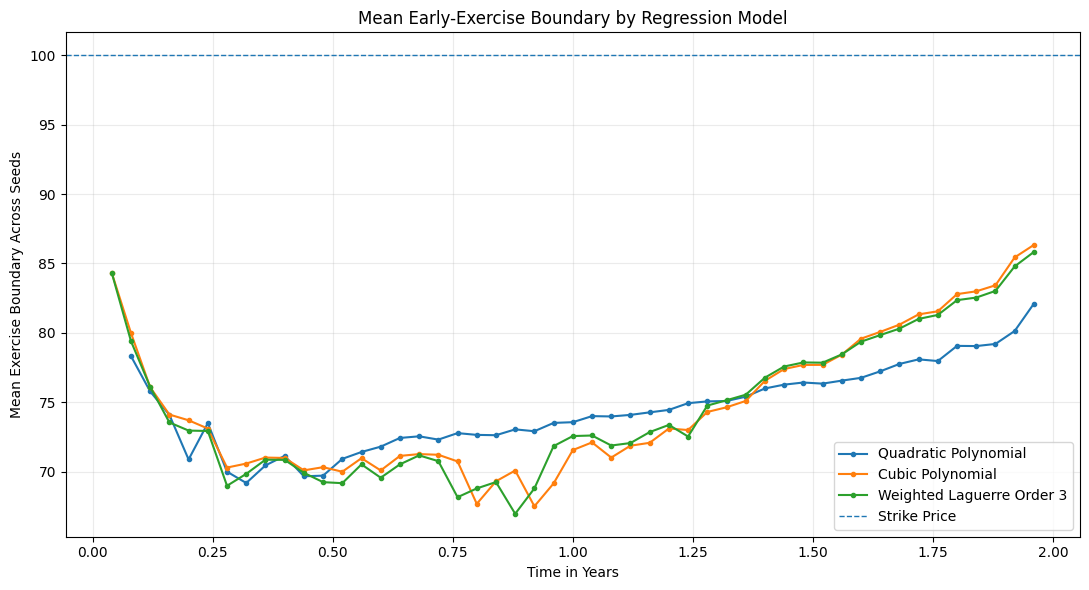

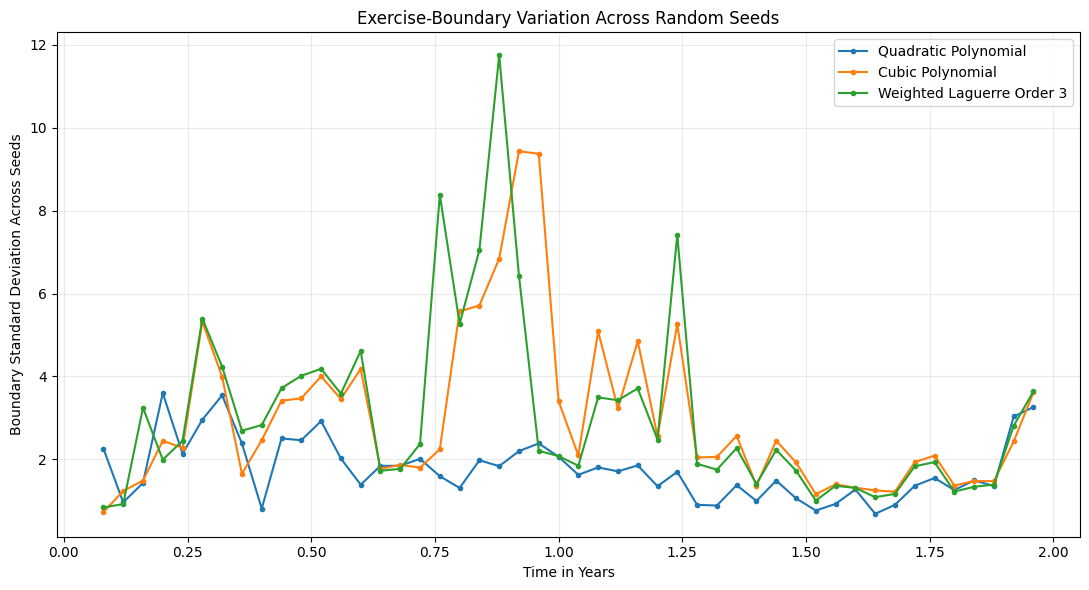

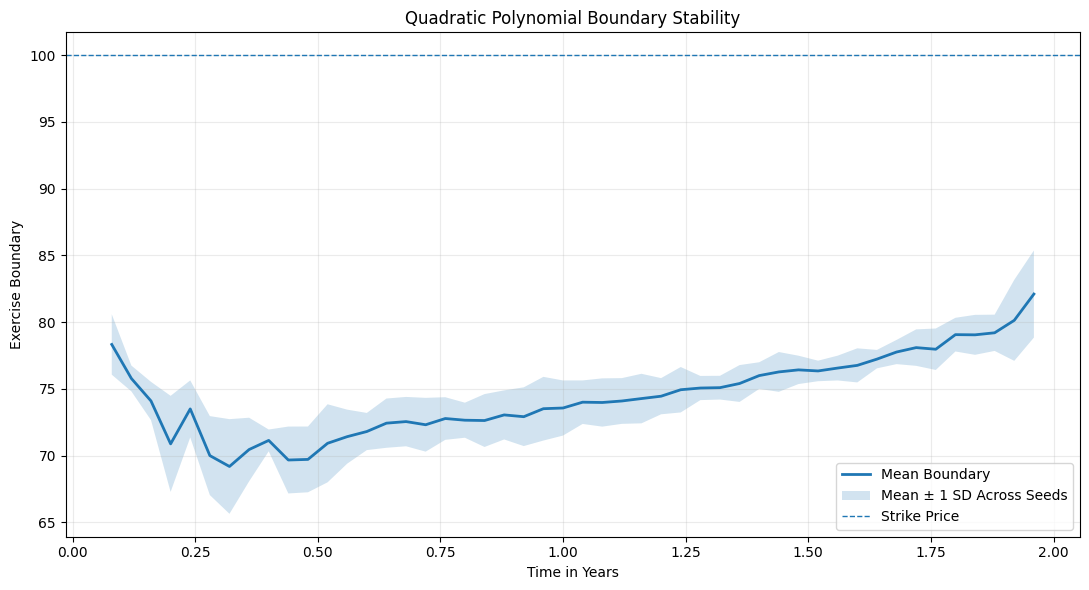

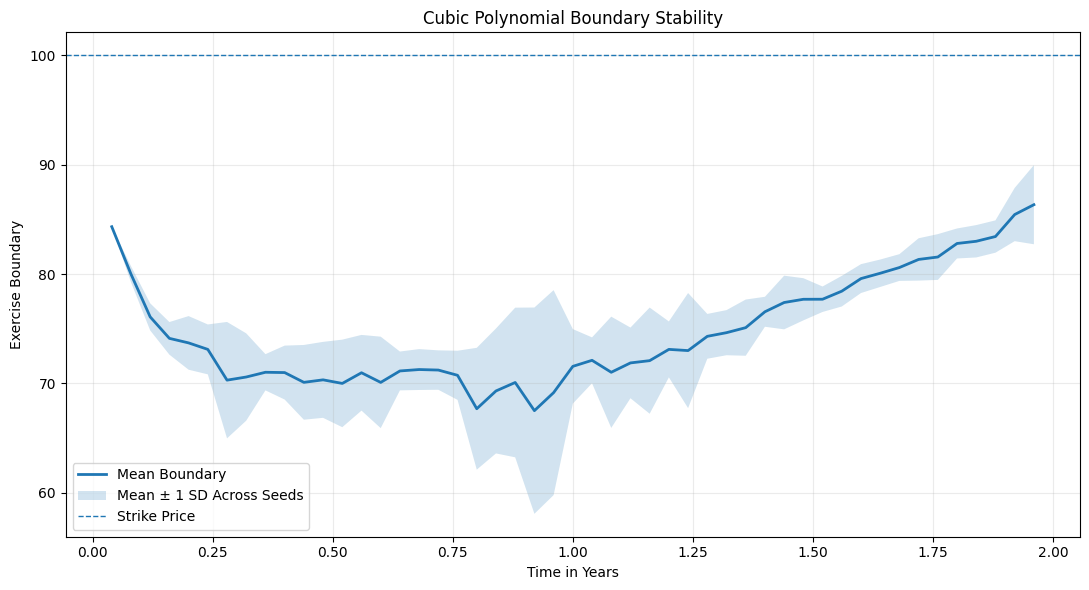

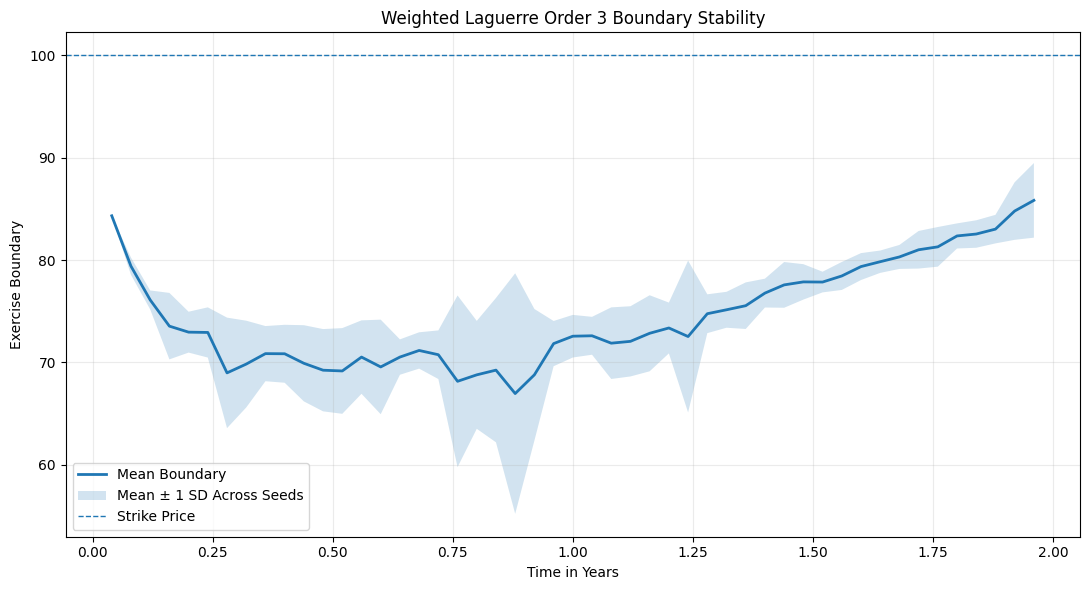

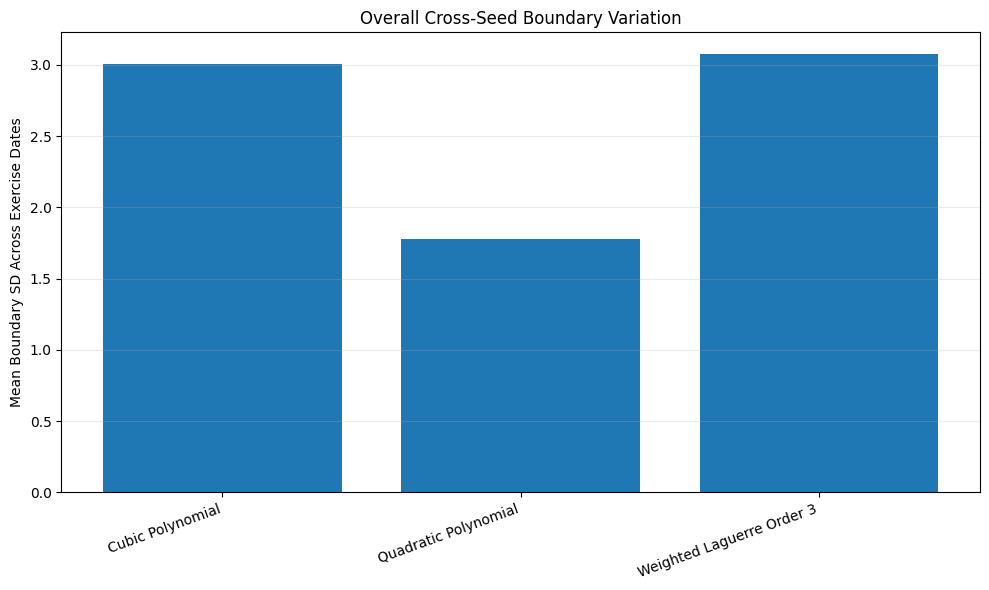

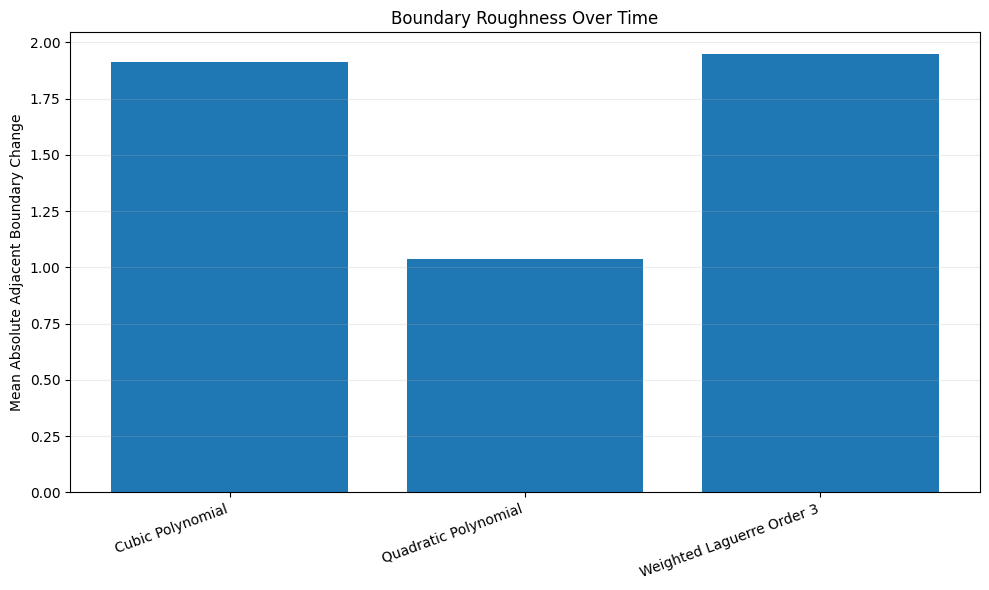


Prepared Part 4A boundary-versus-Part 3B Gamma table:


,Regression_Model,Mean_Boundary_SD_Across_Time,Mean_Absolute_Adjacent_Change,Mean_Absolute_Curvature,Overall_Boundary_Stability_Rank,Part_3B_Primary_Gamma_SD
0,Quadratic Polynomial,1.775384,1.035809,1.575943,1,0.026514
1,Cubic Polynomial,3.009699,1.910912,3.068828,2,0.033016
2,Weighted Laguerre Order 3,3.074734,1.946976,3.050754,3,0.025334


Part 4A Summary:

Experiment settings:
Number of paths: 10000
Number of time intervals: 50
Random seeds: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Regression models: ['Quadratic Polynomial', 'Cubic Polynomial', 'Weighted Laguerre Order 3']
Same random shocks used across models within each seed: True

Validation checks:
All discounting checks passed: True
All prices are at least immediate exercise value: True
All observed put boundaries are at or below the strike: True

Boundary-stability findings:
Best combined boundary-stability ranking: Quadratic Polynomial
Lowest mean cross-seed boundary SD: Quadratic Polynomial
Lowest mean adjacent-date boundary change: Quadratic Polynomial

Interpretation guide:
- Mean_Boundary_SD_Across_Time measures how much the boundary varies across random seeds.
- Mean_Absolute_Adjacent_Change and Mean_Absolute_Curvature measure boundary smoothness over time.
- Missing_Boundary_Percentage measures how often no exercise boundary was observed.
- A stable model should hav

In [14]:
#### PART 4A - EXERCISE-BOUNDARY STABILITY ACROSS REGRESSION MODELS ####

# Goal:
# 1. Compare the early-exercise boundaries of the three selected regression models:
#       - Quadratic polynomial
#       - Cubic polynomial
#       - Weighted Laguerre order 3
# 2. Use identical Monte Carlo settings and random seeds for every model
# 3. Measure boundary level, variation across seeds, roughness over time, missing boundary points, pricing accuracy, and conditioning
# 4. Create a clean boundary-stability ranking
# 5. Prepare the boundary results for the later Gamma-stability comparison

# Important:
# - Number of paths remains 10,000
# - Number of exercise intervals remains 50
# - The same random shocks are used for all models within each seed
# - The boundary at maturity is excluded from smoothness calculations, because it is set equal to the strike

### PART 4A SETTINGS

part4a_n_paths = greeks_n_paths
part4a_n_steps = greeks_n_steps
part4a_seeds = greeks_seeds.copy()
part4a_models = [model.copy() for model in greeks_models]

# Create the common exercise-time grid used by every model
part4a_dt = T / part4a_n_steps
part4a_time_grid = np.arange(part4a_n_steps + 1) * part4a_dt

# Use the CRR benchmark calculated earlier, allowing for previous variable names
if "crr_american_put_price" in globals():
    part4a_crr_benchmark = float(crr_american_put_price)
elif "american_put_crr" in globals():
    part4a_crr_benchmark = float(american_put_crr)
elif "crr_price" in globals():
    part4a_crr_benchmark = float(crr_price)
else:
    part4a_crr_benchmark = np.nan

### HELPER FUNCTIONS FOR BOUNDARY METRICS

# Fill missing boundary values before measuring smoothness
# Use the nearest boundary for missing values at the beginning or end
# Smoothness cannot be measured with fewer than two valid boundary values
def interpolate_boundary_for_metrics(boundary):
    # Convert the boundary to a numerical array and identify observed dates
    boundary = np.asarray(boundary, dtype=float)
    valid = np.isfinite(boundary)
    if np.sum(valid) < 2:
        return np.full_like(boundary, np.nan, dtype=float)
    index = np.arange(len(boundary))
    return np.interp( index, index[valid], boundary[valid] )

# Calculate boundary level, missingness and roughness measures for one model and seed
# Metrics use intermediate exercise dates only and exclude Time_0 and maturity
def calculate_boundary_metrics(boundary, strike):
    intermediate_boundary = np.asarray(boundary[1:-1], dtype=float)
    valid_boundary = intermediate_boundary[np.isfinite(intermediate_boundary)]
    number_of_dates = len(intermediate_boundary)
    number_missing = int(np.sum(~np.isfinite(intermediate_boundary)))
    missing_percentage = (100 * number_missing / number_of_dates if number_of_dates > 0 else np.nan)
    interpolated_boundary = interpolate_boundary_for_metrics(intermediate_boundary)

    if np.all(~np.isfinite(interpolated_boundary)):
        mean_absolute_adjacent_change = np.nan
        root_mean_squared_adjacent_change = np.nan
        squared_roughness = np.nan
        mean_absolute_curvature = np.nan
        maximum_absolute_jump = np.nan
        upward_move_percentage = np.nan
    else:
        first_differences = np.diff(interpolated_boundary)
        second_differences = np.diff(interpolated_boundary, n=2)
        mean_absolute_adjacent_change = np.mean(np.abs(first_differences))
        root_mean_squared_adjacent_change = np.sqrt(np.mean(first_differences**2))
        squared_roughness = np.sum(first_differences**2)
        mean_absolute_curvature = (np.mean(np.abs(second_differences)) if len(second_differences) > 0 else np.nan)
        maximum_absolute_jump = (np.max(np.abs(first_differences)) if len(first_differences) > 0 else np.nan)

        # For an American put, the theoretical boundary normally rises toward the strike as maturity approaches 
        # This metric is only a descriptive measure, not a strict pass/fail requirement
        upward_move_percentage = (100 * np.mean(first_differences >= 0) if len(first_differences) > 0 else np.nan)

    return {
        "Mean_Observed_Boundary": (np.mean(valid_boundary) if len(valid_boundary) > 0 else np.nan),
        "Minimum_Observed_Boundary": (np.min(valid_boundary) if len(valid_boundary) > 0 else np.nan),
        "Maximum_Observed_Boundary": (np.max(valid_boundary) if len(valid_boundary) > 0 else np.nan),
        "Mean_Boundary_As_Percentage_Of_Strike": (100 * np.mean(valid_boundary) / strike if len(valid_boundary) > 0 else np.nan),
        "Missing_Boundary_Dates": number_missing,
        "Missing_Boundary_Percentage": missing_percentage,
        "Mean_Absolute_Adjacent_Change": mean_absolute_adjacent_change,
        "RMS_Adjacent_Change": root_mean_squared_adjacent_change,
        "Squared_Roughness": squared_roughness,
        "Mean_Absolute_Curvature": mean_absolute_curvature,
        "Maximum_Absolute_Jump": maximum_absolute_jump,
        "Upward_Move_Percentage": upward_move_percentage
    }

### RUN THE BOUNDARY EXPERIMENT

# Store one row per model, seed and exercise date
part4a_boundary_records = []
# Store one summary row per model and seed
part4a_seed_summary_records = []

for seed in part4a_seeds:
    rng = np.random.default_rng(seed)
    # Same shocks for every model within this seed
    random_shocks = rng.standard_normal(size=(part4a_n_steps, part4a_n_paths))

    for model in part4a_models:
        model_result = price_american_put_for_greeks(
            S0_input=S0,
            K=K,
            r=r,
            sigma_input=sigma,
            T=T,
            random_shocks=random_shocks,
            basis_type=model["Basis_Type"],
            regression_order=model["Order"]
        )
        boundary = np.asarray(model_result["Exercise_Boundary"], dtype=float)
        boundary_metrics = calculate_boundary_metrics(boundary=boundary, strike=K)
        price_error = (model_result["Price"] - part4a_crr_benchmark if np.isfinite(part4a_crr_benchmark) else np.nan)

        part4a_seed_summary_records.append({
            "Regression_Model": model["Model_Name"],
            "Basis_Type": model["Basis_Type"],
            "Regression_Order": model["Order"],
            "Seed": seed,
            "Estimated_American_Put_Price": model_result["Price"],
            "CRR_Benchmark": part4a_crr_benchmark,
            "Price_Error_Versus_CRR": price_error,
            "Absolute_Price_Error_Versus_CRR": (abs(price_error) if np.isfinite(price_error) else np.nan),
            "Early_Exercise_Percentage": model_result["Early_Exercise_Percentage"],
            "Mean_Condition_Number": model_result["Mean_Condition_Number"],
            "Maximum_Discounting_Difference": model_result["Discounting_Difference"],
            **boundary_metrics
        })

        for time_index in range(1, part4a_n_steps):
            boundary_value = boundary[time_index]
            part4a_boundary_records.append({
                "Regression_Model": model["Model_Name"],
                "Basis_Type": model["Basis_Type"],
                "Regression_Order": model["Order"],
                "Seed": seed,
                "Time_Index": time_index,
                "Time_Years": part4a_time_grid[time_index],
                "Time_To_Maturity_Years": (T - part4a_time_grid[time_index]),
                "Exercise_Boundary": boundary_value,
                "Boundary_As_Percentage_Of_Strike": (100 * boundary_value / K if np.isfinite(boundary_value) else np.nan),
                "Boundary_Observed": bool( np.isfinite(boundary_value))
            })

df_part4a_boundaries_all = pd.DataFrame(part4a_boundary_records)
df_part4a_seed_metrics = pd.DataFrame(part4a_seed_summary_records)

### BOUNDARY LEVEL AND CROSS-SEED STABILITY BY TIME

# Average the observed boundary across seeds at every exercise date
boundary_grouped = (df_part4a_boundaries_all
        .groupby(["Regression_Model", "Time_Index", "Time_Years", "Time_To_Maturity_Years"], as_index=False).agg(
        Mean_Exercise_Boundary=("Exercise_Boundary", "mean"),
        Boundary_SD_Across_Seeds=("Exercise_Boundary", "std"),
        Minimum_Exercise_Boundary=("Exercise_Boundary", "min"),
        Maximum_Exercise_Boundary=("Exercise_Boundary", "max"),
        Number_Of_Observed_Seeds=("Exercise_Boundary", "count")
    ))

boundary_grouped["Boundary_Range_Across_Seeds"] = (boundary_grouped["Maximum_Exercise_Boundary"] - boundary_grouped["Minimum_Exercise_Boundary"])
boundary_grouped["Boundary_Standard_Error"] = (boundary_grouped["Boundary_SD_Across_Seeds"] / np.sqrt(boundary_grouped["Number_Of_Observed_Seeds"]))
boundary_grouped["Mean_Boundary_As_Percentage_Of_Strike"] = (100 * boundary_grouped["Mean_Exercise_Boundary"] / K)
df_part4a_boundary_by_time = boundary_grouped.copy()

### OVERALL MODEL SUMMARY

# Average cross-seed boundary variation across exercise dates
boundary_variation_by_model = (df_part4a_boundary_by_time.groupby("Regression_Model", as_index=False).agg(
        Mean_Boundary_SD_Across_Time=("Boundary_SD_Across_Seeds", "mean"),
        Median_Boundary_SD_Across_Time=("Boundary_SD_Across_Seeds", "median"),
        Maximum_Boundary_SD_Across_Time=("Boundary_SD_Across_Seeds", "max"),
        Mean_Boundary_Range_Across_Time=("Boundary_Range_Across_Seeds", "mean"),
        Mean_Observed_Seeds_Per_Date=("Number_Of_Observed_Seeds", "mean")
    ))

# Summarise price accuracy, conditioning, missingness and roughness across seeds
seed_metric_summary = (df_part4a_seed_metrics.groupby("Regression_Model", as_index=False).agg(
        Mean_American_Put_Price=("Estimated_American_Put_Price", "mean"),
        Price_SD_Across_Seeds=("Estimated_American_Put_Price", "std"),
        Mean_Absolute_Price_Error_Versus_CRR=("Absolute_Price_Error_Versus_CRR", "mean"),
        Mean_Early_Exercise_Percentage=("Early_Exercise_Percentage", "mean"),
        Mean_Condition_Number=("Mean_Condition_Number", "mean"),
        Maximum_Discounting_Difference=("Maximum_Discounting_Difference", "max"),
        Mean_Missing_Boundary_Percentage=("Missing_Boundary_Percentage", "mean"),
        Mean_Absolute_Adjacent_Change=("Mean_Absolute_Adjacent_Change", "mean"),
        Mean_RMS_Adjacent_Change=("RMS_Adjacent_Change", "mean"),
        Mean_Squared_Roughness=("Squared_Roughness", "mean"),
        Mean_Absolute_Curvature=("Mean_Absolute_Curvature", "mean"),
        Mean_Maximum_Absolute_Jump=("Maximum_Absolute_Jump", "mean"),
        Mean_Upward_Move_Percentage=("Upward_Move_Percentage", "mean")
    ))

df_part4a_model_summary = (seed_metric_summary.merge(boundary_variation_by_model, on="Regression_Model", how="left"))

### STABILITY RANKING

# Lower is better for each of these stability measures
ranking_columns = ["Mean_Boundary_SD_Across_Time", "Mean_Absolute_Adjacent_Change", "Mean_Absolute_Curvature", "Mean_Missing_Boundary_Percentage"]

# Rank every model from lowest to highest for each stability measure
for column in ranking_columns:
    df_part4a_model_summary[f"Rank_{column}"] = (df_part4a_model_summary[column].rank(method="min", ascending=True))
rank_columns_created = [f"Rank_{column}" for column in ranking_columns]
df_part4a_model_summary["Mean_Boundary_Stability_Rank"] = (df_part4a_model_summary[rank_columns_created].mean(axis=1))

# Create a unique overall ranking
# Mean_Boundary_Stability_Rank remains the main ranking measure
# Break ties using boundary variation, boundary smoothness, and numerical stability
df_part4a_model_summary = (df_part4a_model_summary.sort_values(
        by=["Mean_Boundary_Stability_Rank", "Mean_Boundary_SD_Across_Time", "Mean_Absolute_Adjacent_Change", "Mean_Absolute_Curvature", "Mean_Condition_Number"],
        ascending=[True, True, True, True, True]
    ).reset_index(drop=True))
df_part4a_model_summary["Overall_Boundary_Stability_Rank"] = ( np.arange( 1, len(df_part4a_model_summary) + 1 ) )

### DISPLAY VISUAL

#Print tables
print("First rows of the complete Part 4A boundary dataset:")
display(df_part4a_boundaries_all.head(12))
print("\nSeed-level price and boundary metrics:")
display(df_part4a_seed_metrics.head(12))
print("\nBoundary level and cross-seed variation by exercise date:")
display(df_part4a_boundary_by_time.head(12))
print("\nOverall Part 4A model comparison:")
display(df_part4a_model_summary[[
            "Regression_Model",
            "Mean_American_Put_Price",
            "Price_SD_Across_Seeds",
            "Mean_Absolute_Price_Error_Versus_CRR",
            "Mean_Boundary_SD_Across_Time",
            "Mean_Absolute_Adjacent_Change",
            "Mean_Absolute_Curvature",
            "Mean_Missing_Boundary_Percentage",
            "Mean_Condition_Number",
            "Overall_Boundary_Stability_Rank"
        ]])
        
# Plot mean exercise boundary across seeds
plt.figure(figsize=(11, 6))
for model_name in [model["Model_Name"] for model in part4a_models]:
    model_data = df_part4a_boundary_by_time[df_part4a_boundary_by_time["Regression_Model"] == model_name].sort_values("Time_Years")
    plt.plot(model_data["Time_Years"], model_data["Mean_Exercise_Boundary"], marker="o", markersize=3, linewidth=1.5, label=model_name)
plt.axhline(K, linestyle="--", linewidth=1, label="Strike Price")
plt.xlabel("Time in Years")
plt.ylabel("Mean Exercise Boundary Across Seeds")
plt.title("Mean Early-Exercise Boundary by Regression Model")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# Plot cross-seed boundary standard deviation
plt.figure(figsize=(11, 6))
for model_name in [model["Model_Name"] for model in part4a_models]:
    model_data = df_part4a_boundary_by_time[df_part4a_boundary_by_time["Regression_Model"] == model_name].sort_values("Time_Years")
    plt.plot(model_data["Time_Years"], model_data["Boundary_SD_Across_Seeds"], marker="o", markersize=3, linewidth=1.5, label=model_name)
plt.xlabel("Time in Years")
plt.ylabel("Boundary Standard Deviation Across Seeds")
plt.title("Exercise-Boundary Variation Across Random Seeds")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

#Plot mean boundary with a cross-seed band
for model_name in [model["Model_Name"] for model in part4a_models]:
    model_data = df_part4a_boundary_by_time[df_part4a_boundary_by_time["Regression_Model"] == model_name].sort_values("Time_Years")
    x_values = model_data["Time_Years"].to_numpy()
    mean_values = model_data["Mean_Exercise_Boundary"].to_numpy()
    sd_values = model_data["Boundary_SD_Across_Seeds"].fillna(0).to_numpy()
    plt.figure(figsize=(11, 6))
    plt.plot(x_values, mean_values, linewidth=2, label="Mean Boundary")
    plt.fill_between(x_values, mean_values - sd_values, mean_values + sd_values, alpha=0.20, label="Mean ± 1 SD Across Seeds")
    plt.axhline(K, linestyle="--", linewidth=1, label="Strike Price")
    plt.xlabel("Time in Years")
    plt.ylabel("Exercise Boundary")
    plt.title(f"{model_name} Boundary Stability")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

# Plot overall boundary-stability metrics
plot_summary = (df_part4a_model_summary.sort_values("Regression_Model"))
plt.figure(figsize=(10, 6))
plt.bar(plot_summary["Regression_Model"], plot_summary["Mean_Boundary_SD_Across_Time"])
plt.ylabel("Mean Boundary SD Across Exercise Dates")
plt.title("Overall Cross-Seed Boundary Variation")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()
plt.figure(figsize=(10, 6))
plt.bar(plot_summary["Regression_Model"], plot_summary["Mean_Absolute_Adjacent_Change"])
plt.ylabel("Mean Absolute Adjacent Boundary Change")
plt.title("Boundary Roughness Over Time")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

### LINK PART 4A BOUNDARY STABILITY TO PART 3B GAMMA STABILITY

# This prepares a compact table linking Part 4A boundary stability with Part 3B Gamma stability
# It does not claim causation or calculate a meaningful correlation from only three model-level observations
gamma_primary = (df_fixed_policy_primary_delta_gamma[["Regression_Model", "Gamma_SD_Across_Seeds"]].copy()
    .rename(columns={"Gamma_SD_Across_Seeds": "Part_3B_Primary_Gamma_SD"})
)

df_part4a_boundary_gamma_link = (df_part4a_model_summary[[
            "Regression_Model",
            "Mean_Boundary_SD_Across_Time",
            "Mean_Absolute_Adjacent_Change",
            "Mean_Absolute_Curvature",
            "Overall_Boundary_Stability_Rank"
        ]].merge(gamma_primary, on="Regression_Model", how="left"))

print("\nPrepared Part 4A boundary-versus-Part 3B Gamma table:")
display(df_part4a_boundary_gamma_link)
    
### VALIDATION CHECKS
all_discounting_checks_passed = bool((df_part4a_seed_metrics["Maximum_Discounting_Difference"] < 1e-10).all())
all_prices_above_immediate_exercise = bool((df_part4a_seed_metrics["Estimated_American_Put_Price"] >= max(K - S0, 0) - 1e-12).all())
all_boundaries_below_or_near_strike = bool((df_part4a_boundaries_all["Exercise_Boundary"].dropna() <= K + 1e-10).all())
best_boundary_model = (df_part4a_model_summary.sort_values("Overall_Boundary_Stability_Rank").iloc[0]["Regression_Model"]) 
lowest_cross_seed_sd_model = (df_part4a_model_summary.sort_values("Mean_Boundary_SD_Across_Time").iloc[0]["Regression_Model"])
smoothest_adjacent_boundary_model = (df_part4a_model_summary.sort_values("Mean_Absolute_Adjacent_Change").iloc[0]["Regression_Model"])

### PART 4A SUMMARY

print("Part 4A Summary:")

print("\nExperiment settings:")
print("Number of paths:", part4a_n_paths)
print("Number of time intervals:", part4a_n_steps)
print("Random seeds:", part4a_seeds)
print("Regression models:", [model["Model_Name"] for model in part4a_models])
print("Same random shocks used across models within each seed:", True)

print("\nValidation checks:")
print("All discounting checks passed:", all_discounting_checks_passed)
print("All prices are at least immediate exercise value:", all_prices_above_immediate_exercise)
print("All observed put boundaries are at or below the strike:", all_boundaries_below_or_near_strike)

print("\nBoundary-stability findings:")
print("Best combined boundary-stability ranking:", best_boundary_model)
print("Lowest mean cross-seed boundary SD:", lowest_cross_seed_sd_model)
print("Lowest mean adjacent-date boundary change:", smoothest_adjacent_boundary_model)

print("\nInterpretation guide:")
print("- Mean_Boundary_SD_Across_Time measures how much the boundary varies across random seeds.")
print("- Mean_Absolute_Adjacent_Change and Mean_Absolute_Curvature measure boundary smoothness over time.")
print("- Missing_Boundary_Percentage measures how often no exercise boundary was observed.")
print("- A stable model should have low boundary variation, low roughness, few missing values, good price accuracy, and reasonable numerical stability.")
print("- The boundary is the highest stock price among paths exercised at each date, so some Monte Carlo noise is expected.")

### EXPORT RESULTS

df_part4a_boundaries_all.to_csv("part4a_boundary_observations.csv", index=False)
df_part4a_seed_metrics.to_csv("part4a_seed_level_boundary_metrics.csv", index=False)
df_part4a_boundary_by_time.to_csv("part4a_boundary_stability_by_time.csv", index=False)
df_part4a_model_summary.to_csv("part4a_model_boundary_summary.csv", index=False)
if not df_part4a_boundary_gamma_link.empty:
    df_part4a_boundary_gamma_link.to_csv("part4a_boundary_gamma_link.csv", index=False)

Part 4B - Path Count Study


,Number_Of_Paths,Number_Of_Time_Intervals,Mean_American_Put_Price,Price_SD_Across_Seeds,Mean_Absolute_Price_Error_Versus_CRR,Mean_Boundary_SD_Across_Time,Mean_Absolute_Adjacent_Change,Mean_Absolute_Curvature,Mean_Missing_Boundary_Percentage,Mean_Early_Exercise_Percentage,Mean_Condition_Number
0,500,50,12.106021,0.497253,0.610199,5.403563,2.601181,3.577599,36.122449,44.580,382.383829
1,1000,50,11.806367,0.378161,0.313194,3.979272,2.052888,2.912959,28.367347,42.800,376.887571
2,2500,50,11.512291,0.293183,0.232700,3.213286,1.750931,2.477616,18.367347,41.028,370.947333
3,5000,50,11.529201,0.161166,0.116981,2.204930,1.263156,1.905388,17.346939,40.456,369.598735
4,10000,50,11.511453,0.130404,0.118004,1.775384,1.035809,1.575943,12.040816,39.896,370.253402



Path Count - Incremental Changes


,Number_Of_Paths,Change_In_Mean_Price_From_Previous,Change_In_Mean_Absolute_Price_Error_From_Previous,Change_In_Boundary_SD_From_Previous,Percentage_Change_In_Boundary_SD_From_Previous
0,500,NaN,NaN,NaN,NaN
1,1000,-0.299654,-0.297005,-1.424291,-26.358373
2,2500,-0.294076,-0.080494,-0.765986,-19.249399
3,5000,0.016911,-0.115719,-1.008356,-31.380838
4,10000,-0.017748,0.001023,-0.429545,-19.481139



Exercise Interval Study


,Number_Of_Paths,Number_Of_Time_Intervals,Mean_American_Put_Price,Price_SD_Across_Seeds,Mean_Absolute_Price_Error_Versus_CRR,Mean_Boundary_SD_Across_Time,Mean_Absolute_Adjacent_Change,Mean_Absolute_Curvature,Mean_Missing_Boundary_Percentage,Mean_Early_Exercise_Percentage,Mean_Condition_Number
0,10000,10,11.464702,0.114375,0.113767,1.357565,1.546435,1.732360,8.888889,35.820,269.835752
1,10000,25,11.493884,0.107520,0.103272,1.558778,1.314035,1.664383,10.416667,39.509,326.216419
2,10000,50,11.507689,0.116038,0.106674,1.638349,1.012737,1.401223,13.877551,41.301,370.660707
3,10000,100,11.517916,0.109943,0.097015,1.602204,0.751984,1.110033,13.232323,42.562,416.872328



Exercise Intervals - Incremental Changes


,Number_Of_Time_Intervals,Change_In_Mean_Price_From_Previous,Change_In_Mean_Absolute_Price_Error_From_Previous,Change_In_Boundary_SD_From_Previous,Percentage_Change_In_Boundary_SD_From_Previous
0,10,NaN,NaN,NaN,NaN
1,25,0.029182,-0.010496,0.201213,14.821629
2,50,0.013804,0.003402,0.079571,5.104686
3,100,0.010227,-0.009658,-0.036145,-2.206189


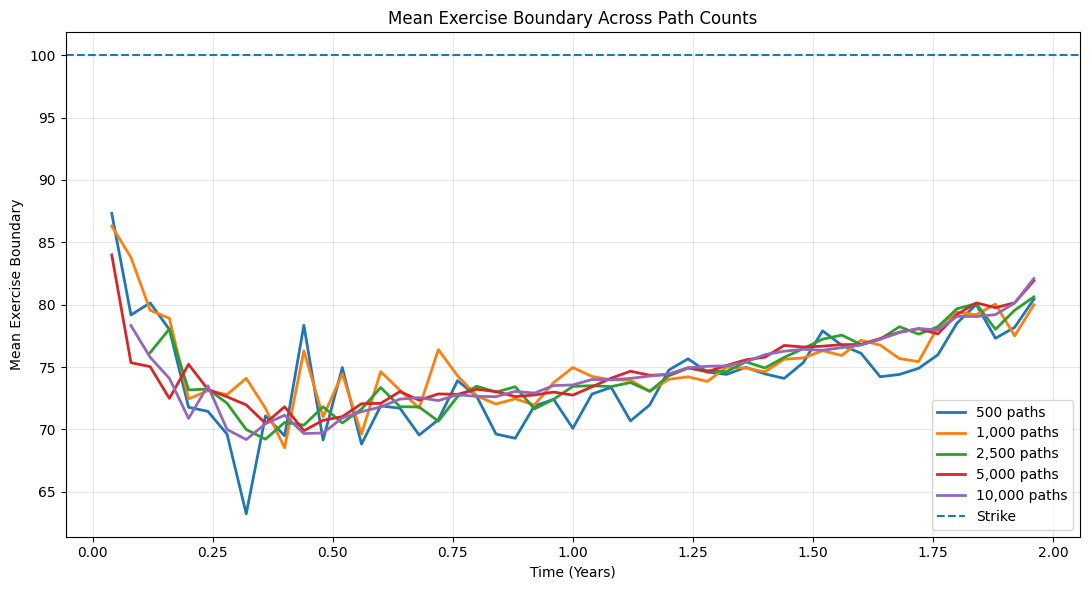

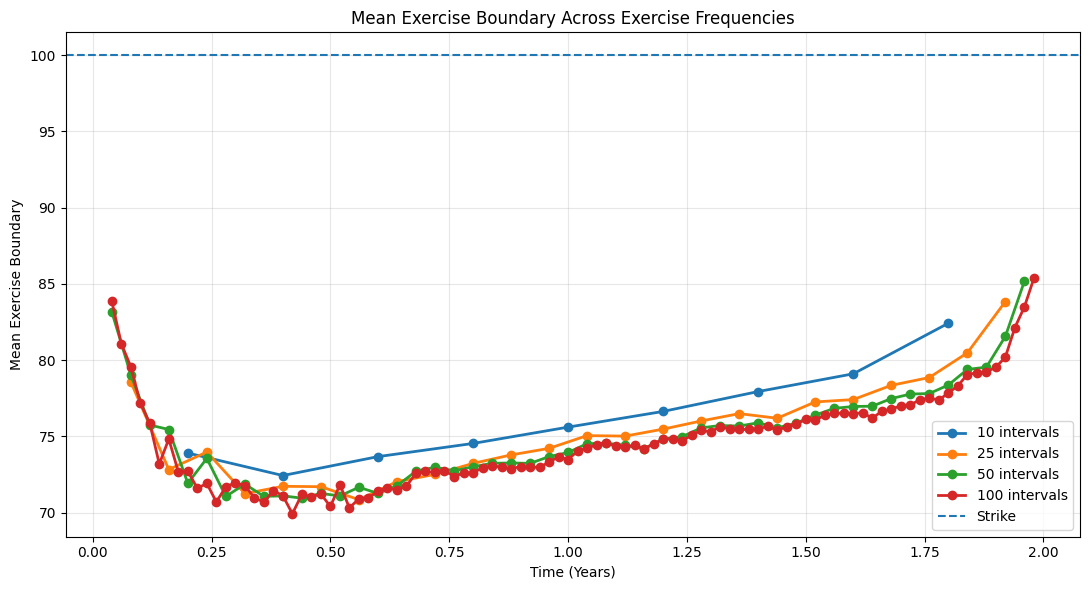


Reference Setting - 10,000 Paths With 50 Intervals


,Number_Of_Paths,Number_Of_Time_Intervals,Mean_American_Put_Price,Price_SD_Across_Seeds,Mean_Absolute_Price_Error_Versus_CRR,Mean_Boundary_SD_Across_Time,Mean_Missing_Boundary_Percentage
4,10000,50,11.511453,0.130404,0.118004,1.775384,12.040816


Part 4B Summary:

Model selection:
Regression model: Quadratic Polynomial
Basis type: Polynomial
Regression order: 2
Reason: ranked first for boundary stability in Part 4A

Experiment settings:
Random seeds: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Path counts tested: [500, 1000, 2500, 5000, 10000]
Path-study time intervals: 50
Exercise intervals tested: [10, 25, 50, 100]
Exercise-interval-study paths: 10000
Nested paths used in path-count study: True
Common Brownian paths aggregated across time grids: True

Validation checks:
All discounting checks passed: True
All prices are at least immediate exercise value: True
All observed put boundaries are at or below the strike: True
All requested path counts completed: True
All requested exercise interval counts completed: True

Key convergence comparisons:
Mean price change from 5,000 to 10,000 paths: -0.017748
Mean boundary-SD change from 5,000 to 10,000 paths: -0.429545
Mean price change from 50 to 100 intervals: 0.010227
Mean boundary-SD change fr

In [15]:
#### PART 4B - ROBUSTNESS TO PATH COUNT AND EXERCISE-DATE FREQUENCY ####

# Goal:
# 1. Use the Quadratic Polynomial selected in Part 4A
# 2. Test how Monte Carlo path count affects:
#       - price accuracy and variability
#       - exercise-boundary stability
#       - missing boundary observations
#       - early exercise percentage
# 3. Test how the number of exercise intervals affects the same outputs
# 4. Use controlled random-number designs:
#       - nested paths when changing the number of paths
#       - combined Brownian increments when changing the number of exercise dates
# 5. Check whether the main 10,000-path, 50-interval results remain stable when paths and exercise intervals are changed

# Important:
# - Reuses:
#       price_american_put_for_greeks(...)
#       calculate_boundary_metrics(...)
#       S0, K, r, sigma, T
#       part4a_crr_benchmark
# - Only the Quadratic Polynomial is used because Part 4A ranked it first
# Test path count and exercise intervals separately to isolate the effect of each

### PART 4B SETTINGS

part4b_model_name = "Quadratic Polynomial"
part4b_basis_type = "Polynomial"
part4b_regression_order = 2
part4b_seeds = list(range(1, 11))

# Experiment A: vary path count while holding 50 intervals fixed
part4b_path_counts = [500, 1000, 2500, 5000, 10000]
part4b_path_study_steps = 50

# Experiment B: vary exercise intervals while holding 10,000 paths fixed
# Use the same underlying Brownian paths for each number of exercise intervals
part4b_step_counts = [10, 25, 50, 100]
part4b_step_study_paths = 10000
part4b_finest_step_count = max(part4b_step_counts)

# Benchmark numerical choice retained from Parts 3 and 4A
part4b_reference_paths = 10000
part4b_reference_steps = 50

# CRR benchmark inherited from Part 4A, with safe fallbacks
if "part4a_crr_benchmark" in globals():
    part4b_crr_benchmark = float(part4a_crr_benchmark)
elif "crr_american_put_price" in globals():
    part4b_crr_benchmark = float(crr_american_put_price)
elif "american_put_crr" in globals():
    part4b_crr_benchmark = float(american_put_crr)
elif "crr_price" in globals():
    part4b_crr_benchmark = float(crr_price)
else:
    part4b_crr_benchmark = np.nan

### HELPER FUNCTIONS

# Aggregate standard-normal shocks from a fine grid to a coarser grid while preserving the same Brownian path
# The combined increments are divided by the square root of the aggregation size to remain standard normal
def aggregate_standard_normal_increments(fine_shocks, target_number_of_steps):
    # Read the fine-grid dimensions and verify that the target grid divides it exactly
    fine_shocks = np.asarray(fine_shocks, dtype=float)
    fine_number_of_steps, number_of_paths = fine_shocks.shape
    if fine_number_of_steps % target_number_of_steps != 0:
        raise ValueError("target_number_of_steps must divide the fine grid exactly.")
    aggregation_size = (fine_number_of_steps // target_number_of_steps)
    coarse_shocks = (fine_shocks .reshape(target_number_of_steps, aggregation_size, number_of_paths).sum(axis=1) / np.sqrt(aggregation_size))
    return coarse_shocks

def create_part4b_seed_record(experiment_name, numerical_setting_name, numerical_setting_value, seed, model_result, number_of_paths, number_of_steps):
    # Extract the exercise boundary and calculate the same metrics used in Part 4A
    boundary = np.asarray(model_result["Exercise_Boundary"], dtype=float)
    boundary_metrics = calculate_boundary_metrics(boundary=boundary, strike=K)
    price_error = (model_result["Price"] - part4b_crr_benchmark
        if np.isfinite(part4b_crr_benchmark)
        else np.nan)
    return {
        "Experiment": experiment_name,
        "Numerical_Setting": numerical_setting_name,
        "Setting_Value": numerical_setting_value,
        "Regression_Model": part4b_model_name,
        "Basis_Type": part4b_basis_type,
        "Regression_Order": part4b_regression_order,
        "Seed": seed,
        "Number_Of_Paths": number_of_paths,
        "Number_Of_Time_Intervals": number_of_steps,
        "Time_Step_Years": T / number_of_steps,
        "Estimated_American_Put_Price": model_result["Price"],
        "CRR_Benchmark": part4b_crr_benchmark,
        "Price_Error_Versus_CRR": price_error,
        "Absolute_Price_Error_Versus_CRR": (abs(price_error) if np.isfinite(price_error) else np.nan),
        "Early_Exercise_Percentage": model_result["Early_Exercise_Percentage"],
        "Mean_Condition_Number": model_result["Mean_Condition_Number"],
        "Maximum_Discounting_Difference": model_result["Discounting_Difference"],
        **boundary_metrics
    }

# Create one boundary observation for every intermediate exercise date
def create_part4b_boundary_records(experiment_name, numerical_setting_name, numerical_setting_value, seed, boundary, number_of_paths, number_of_steps):
# Build the time grid for the selected number of exercise intervals
    boundary = np.asarray(boundary, dtype=float)
    dt = T / number_of_steps
    records = []

    for time_index in range(1, number_of_steps):
        boundary_value = boundary[time_index]
        time_years = time_index * dt
        records.append({
            "Experiment": experiment_name,
            "Numerical_Setting": numerical_setting_name,
            "Setting_Value": numerical_setting_value,
            "Regression_Model": part4b_model_name,
            "Seed": seed,
            "Number_Of_Paths": number_of_paths,
            "Number_Of_Time_Intervals": number_of_steps,
            "Time_Index": time_index,
            "Time_Years": time_years,
            "Time_As_Percentage_Of_Maturity": 100 * time_years / T,
            "Time_To_Maturity_Years": T - time_years,
            "Exercise_Boundary": boundary_value,
            "Boundary_As_Percentage_Of_Strike": (100 * boundary_value / K if np.isfinite(boundary_value) else np.nan),
            "Boundary_Observed": bool(np.isfinite(boundary_value))
        })

    return records

# Aggregate seed-level results by numerical setting
def summarise_part4b_experiment(seed_dataframe):
    summary = (seed_dataframe
        .groupby(["Experiment", "Numerical_Setting", "Setting_Value", "Number_Of_Paths", "Number_Of_Time_Intervals"], as_index=False)
        .agg(Mean_American_Put_Price=("Estimated_American_Put_Price", "mean"),
            Price_SD_Across_Seeds=("Estimated_American_Put_Price", "std"),
            Mean_Absolute_Price_Error_Versus_CRR=("Absolute_Price_Error_Versus_CRR", "mean"),
            Mean_Early_Exercise_Percentage=("Early_Exercise_Percentage", "mean"),
            Mean_Boundary_SD_Within_Seed=("RMS_Adjacent_Change", "mean"),
            Mean_Absolute_Adjacent_Change=("Mean_Absolute_Adjacent_Change", "mean"),
            Mean_Absolute_Curvature=("Mean_Absolute_Curvature", "mean"),
            Mean_Missing_Boundary_Percentage=("Missing_Boundary_Percentage", "mean"),
            Mean_Maximum_Absolute_Jump=("Maximum_Absolute_Jump", "mean"),
            Mean_Upward_Move_Percentage=("Upward_Move_Percentage", "mean"),
            Mean_Condition_Number=("Mean_Condition_Number", "mean"),
            Maximum_Discounting_Difference=("Maximum_Discounting_Difference", "max")))
    summary["Price_Standard_Error"] = (summary["Price_SD_Across_Seeds"] / np.sqrt(len(part4b_seeds)))
    return summary

# Calculate boundary variation across seeds at each date, then average it across time for each setting
def add_cross_seed_boundary_stability(summary_dataframe, boundary_dataframe):
    boundary_by_time = (boundary_dataframe
        .groupby(["Experiment", "Numerical_Setting", "Setting_Value", "Number_Of_Paths", "Number_Of_Time_Intervals", "Time_Index", "Time_Years", "Time_As_Percentage_Of_Maturity"], as_index=False)
        .agg(Mean_Exercise_Boundary=("Exercise_Boundary", "mean"),
            Boundary_SD_Across_Seeds=("Exercise_Boundary", "std"),
            Minimum_Exercise_Boundary=("Exercise_Boundary", "min"),
            Maximum_Exercise_Boundary=("Exercise_Boundary", "max"),
            Number_Of_Observed_Seeds=("Exercise_Boundary", "count")))
    boundary_by_time["Boundary_Range_Across_Seeds"] = (boundary_by_time["Maximum_Exercise_Boundary"] - boundary_by_time["Minimum_Exercise_Boundary"])
    cross_seed_summary = (boundary_by_time
        .groupby(["Experiment", "Numerical_Setting", "Setting_Value", "Number_Of_Paths", "Number_Of_Time_Intervals"], as_index=False)
        .agg(Mean_Boundary_SD_Across_Time=("Boundary_SD_Across_Seeds", "mean"),
            Median_Boundary_SD_Across_Time=("Boundary_SD_Across_Seeds", "median"),
            Maximum_Boundary_SD_Across_Time=("Boundary_SD_Across_Seeds", "max"),
            Mean_Boundary_Range_Across_Time=("Boundary_Range_Across_Seeds", "mean"),
            Mean_Observed_Seeds_Per_Date=("Number_Of_Observed_Seeds", "mean")))
    merged_summary = summary_dataframe.merge(cross_seed_summary,
        on=["Experiment", "Numerical_Setting", "Setting_Value", "Number_Of_Paths", "Number_Of_Time_Intervals"],
        how="left")
    return merged_summary, boundary_by_time

### EXPERIMENT A - EFFECT OF MONTE CARLO PATH COUNT

# Store seed-level and exercise-date-level results for the path-count experiment
part4b_path_seed_records = []
part4b_path_boundary_records = []

for seed in part4b_seeds:
    rng = np.random.default_rng(seed)
    # Generate the largest simulation once 
    # Smaller experiments use the first N paths, so every path-count comparison is nested
    maximum_path_shocks = rng.standard_normal(size=(part4b_path_study_steps, max(part4b_path_counts)))

    for number_of_paths in part4b_path_counts:
        random_shocks = maximum_path_shocks[:, :number_of_paths]
        model_result = price_american_put_for_greeks(S0_input=S0,
            K=K,
            r=r,
            sigma_input=sigma,
            T=T,
            random_shocks=random_shocks,
            basis_type=part4b_basis_type,
            regression_order=part4b_regression_order)

        part4b_path_seed_records.append(create_part4b_seed_record(experiment_name="Path Count Study",
                numerical_setting_name="Number Of Paths",
                numerical_setting_value=number_of_paths,
                seed=seed,
                model_result=model_result,
                number_of_paths=number_of_paths,
                number_of_steps=part4b_path_study_steps))

        part4b_path_boundary_records.extend(create_part4b_boundary_records(experiment_name="Path Count Study",
                numerical_setting_name="Number Of Paths",
                numerical_setting_value=number_of_paths,
                seed=seed,
                boundary=model_result["Exercise_Boundary"],
                number_of_paths=number_of_paths,
                number_of_steps=part4b_path_study_steps))
        
df_part4b_path_seed_results = pd.DataFrame(part4b_path_seed_records)
df_part4b_path_boundaries = pd.DataFrame(part4b_path_boundary_records)
path_summary_initial = summarise_part4b_experiment(df_part4b_path_seed_results)
(df_part4b_path_summary, df_part4b_path_boundary_by_time) = add_cross_seed_boundary_stability(summary_dataframe=path_summary_initial, boundary_dataframe=df_part4b_path_boundaries)
df_part4b_path_summary = (df_part4b_path_summary.sort_values("Number_Of_Paths").reset_index(drop=True))

### EXPERIMENT B - EFFECT OF EXERCISE-DATE FREQUENCY

# Store seed-level and exercise-date-level results for the exercise-frequency experiment
part4b_step_seed_records = []
part4b_step_boundary_records = []

for seed in part4b_seeds:
    rng = np.random.default_rng(seed)
    # Simulate shocks on the finest 100-step grid once
    fine_random_shocks = rng.standard_normal(size=(part4b_finest_step_count, part4b_step_study_paths))

    for number_of_steps in part4b_step_counts:
        # Aggregate the same fine Brownian increments to the requested grid
        random_shocks = aggregate_standard_normal_increments(fine_shocks=fine_random_shocks, target_number_of_steps=number_of_steps)
        model_result = price_american_put_for_greeks(S0_input=S0,
            K=K,
            r=r,
            sigma_input=sigma,
            T=T,
            random_shocks=random_shocks,
            basis_type=part4b_basis_type,
            regression_order=part4b_regression_order)

        part4b_step_seed_records.append(create_part4b_seed_record(experiment_name="Exercise Interval Study",
                numerical_setting_name="Number Of Time Intervals",
                numerical_setting_value=number_of_steps,
                seed=seed,
                model_result=model_result,
                number_of_paths=part4b_step_study_paths,
                number_of_steps=number_of_steps))

        part4b_step_boundary_records.extend(create_part4b_boundary_records(experiment_name="Exercise Interval Study",
                numerical_setting_name="Number Of Time Intervals",
                numerical_setting_value=number_of_steps,
                seed=seed,
                boundary=model_result["Exercise_Boundary"],
                number_of_paths=part4b_step_study_paths,
                number_of_steps=number_of_steps))
        
df_part4b_step_seed_results = pd.DataFrame(part4b_step_seed_records)
df_part4b_step_boundaries = pd.DataFrame(part4b_step_boundary_records)
step_summary_initial = summarise_part4b_experiment(df_part4b_step_seed_results)
(df_part4b_step_summary, df_part4b_step_boundary_by_time) = add_cross_seed_boundary_stability(summary_dataframe=step_summary_initial, boundary_dataframe=df_part4b_step_boundaries)
df_part4b_step_summary = (df_part4b_step_summary.sort_values("Number_Of_Time_Intervals").reset_index(drop=True))

### COMBINED DATAFRAMES

# Combine both robustness experiments into shared result tables
df_part4b_all_seed_results = pd.concat([df_part4b_path_seed_results, df_part4b_step_seed_results], ignore_index=True)
df_part4b_all_boundaries = pd.concat([df_part4b_path_boundaries, df_part4b_step_boundaries], ignore_index=True)
df_part4b_overall_summary = pd.concat([df_part4b_path_summary, df_part4b_step_summary], ignore_index=True)

### INCREMENTAL IMPROVEMENT TABLES

# Add changes relative to the previous numerical setting
def add_incremental_changes(summary_dataframe, sort_column):
    result = (summary_dataframe.sort_values(sort_column).reset_index(drop=True).copy())
    result["Change_In_Mean_Price_From_Previous"] = (result["Mean_American_Put_Price"].diff())
    result["Change_In_Mean_Absolute_Price_Error_From_Previous"] = (result["Mean_Absolute_Price_Error_Versus_CRR"].diff())
    result["Change_In_Boundary_SD_From_Previous"] = (result["Mean_Boundary_SD_Across_Time"].diff())
    result["Percentage_Change_In_Boundary_SD_From_Previous"] = (100 * result["Mean_Boundary_SD_Across_Time"].pct_change())
    return result

df_part4b_path_incremental = add_incremental_changes(df_part4b_path_summary, "Number_Of_Paths")
df_part4b_step_incremental = add_incremental_changes(df_part4b_step_summary, "Number_Of_Time_Intervals")

### DISPLAY VISUAL

# Print tables
print("Part 4B - Path Count Study")
display(df_part4b_path_summary[[
            "Number_Of_Paths",
            "Number_Of_Time_Intervals",
            "Mean_American_Put_Price",
            "Price_SD_Across_Seeds",
            "Mean_Absolute_Price_Error_Versus_CRR",
            "Mean_Boundary_SD_Across_Time",
            "Mean_Absolute_Adjacent_Change",
            "Mean_Absolute_Curvature",
            "Mean_Missing_Boundary_Percentage",
            "Mean_Early_Exercise_Percentage",
            "Mean_Condition_Number"
        ]])

print("\nPath Count - Incremental Changes")
display(df_part4b_path_incremental[[
            "Number_Of_Paths",
            "Change_In_Mean_Price_From_Previous",
            "Change_In_Mean_Absolute_Price_Error_From_Previous",
            "Change_In_Boundary_SD_From_Previous",
            "Percentage_Change_In_Boundary_SD_From_Previous"
        ]])

print("\nExercise Interval Study")
display(df_part4b_step_summary[[
            "Number_Of_Paths",
            "Number_Of_Time_Intervals",
            "Mean_American_Put_Price",
            "Price_SD_Across_Seeds",
            "Mean_Absolute_Price_Error_Versus_CRR",
            "Mean_Boundary_SD_Across_Time",
            "Mean_Absolute_Adjacent_Change",
            "Mean_Absolute_Curvature",
            "Mean_Missing_Boundary_Percentage",
            "Mean_Early_Exercise_Percentage",
            "Mean_Condition_Number"
        ]])

print("\nExercise Intervals - Incremental Changes")
display(df_part4b_step_incremental[[
            "Number_Of_Time_Intervals",
            "Change_In_Mean_Price_From_Previous",
            "Change_In_Mean_Absolute_Price_Error_From_Previous",
            "Change_In_Boundary_SD_From_Previous",
            "Percentage_Change_In_Boundary_SD_From_Previous"
        ]])

# Plot mean boundary curves for selected path counts
plt.figure(figsize=(11, 6))
for number_of_paths in part4b_path_counts:
    plot_data = df_part4b_path_boundary_by_time[df_part4b_path_boundary_by_time["Number_Of_Paths"] == number_of_paths].sort_values("Time_Years")
    plt.plot(plot_data["Time_Years"], plot_data["Mean_Exercise_Boundary"], linewidth=2, label=f"{number_of_paths:,} paths")
plt.axhline(K, linestyle="--", label="Strike")
plt.xlabel("Time (Years)")
plt.ylabel("Mean Exercise Boundary")
plt.title("Mean Exercise Boundary Across Path Counts")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Plot mean boundary curves across exercise frequencies
plt.figure(figsize=(11, 6))
for number_of_steps in part4b_step_counts:
    plot_data = df_part4b_step_boundary_by_time[df_part4b_step_boundary_by_time["Number_Of_Time_Intervals"] == number_of_steps].sort_values("Time_Years")
    plt.plot(plot_data["Time_Years"], plot_data["Mean_Exercise_Boundary"], marker="o", linewidth=2, label=f"{number_of_steps} intervals")
plt.axhline(K, linestyle="--", label="Strike")
plt.xlabel("Time (Years)")
plt.ylabel("Mean Exercise Boundary")
plt.title("Mean Exercise Boundary Across Exercise Frequencies")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Display the retained 10,000-path and 50-interval reference setting
part4b_reference_path_row = df_part4b_path_summary[df_part4b_path_summary["Number_Of_Paths"] == part4b_reference_paths].copy()
part4b_reference_step_row = df_part4b_step_summary[df_part4b_step_summary["Number_Of_Time_Intervals"] == part4b_reference_steps].copy()

print("\nReference Setting - 10,000 Paths With 50 Intervals")
if len(part4b_reference_path_row) == 1:
    display(part4b_reference_path_row[[
                "Number_Of_Paths",
                "Number_Of_Time_Intervals",
                "Mean_American_Put_Price",
                "Price_SD_Across_Seeds",
                "Mean_Absolute_Price_Error_Versus_CRR",
                "Mean_Boundary_SD_Across_Time",
                "Mean_Missing_Boundary_Percentage"
            ]])
    
# Validation Checks
part4b_all_discounting_checks_passed = bool(np.allclose(df_part4b_all_seed_results["Maximum_Discounting_Difference"], 0.0, atol=1e-10))
part4b_all_prices_above_immediate_exercise = bool((df_part4b_all_seed_results["Estimated_American_Put_Price"] >= max(K - S0, 0) - 1e-10).all())
part4b_all_boundaries_below_strike = bool((df_part4b_all_boundaries.loc[df_part4b_all_boundaries["Boundary_Observed"], "Exercise_Boundary"] <= K + 1e-10).all())
part4b_all_path_counts_completed = bool(set(df_part4b_path_summary["Number_Of_Paths"]) == set(part4b_path_counts))
part4b_all_step_counts_completed = bool(set(df_part4b_step_summary["Number_Of_Time_Intervals"]) == set(part4b_step_counts))

# Part 4B Summary
path_row_5000 = df_part4b_path_summary[df_part4b_path_summary["Number_Of_Paths"] == 5000].iloc[0]
path_row_10000 = df_part4b_path_summary[df_part4b_path_summary["Number_Of_Paths"] == 10000].iloc[0]
step_row_50 = df_part4b_step_summary[df_part4b_step_summary["Number_Of_Time_Intervals"] == 50].iloc[0]
step_row_100 = df_part4b_step_summary[df_part4b_step_summary["Number_Of_Time_Intervals"] == 100].iloc[0]
price_change_5000_to_10000 = (path_row_10000["Mean_American_Put_Price"] - path_row_5000["Mean_American_Put_Price"])
boundary_sd_change_5000_to_10000 = (path_row_10000["Mean_Boundary_SD_Across_Time"] - path_row_5000["Mean_Boundary_SD_Across_Time"])
price_change_50_to_100 = (step_row_100["Mean_American_Put_Price"] - step_row_50["Mean_American_Put_Price"])
boundary_sd_change_50_to_100 = (step_row_100["Mean_Boundary_SD_Across_Time"] - step_row_50["Mean_Boundary_SD_Across_Time"])

print("Part 4B Summary:")

print("\nModel selection:")
print("Regression model:", part4b_model_name)
print("Basis type:", part4b_basis_type)
print("Regression order:", part4b_regression_order)
print("Reason: ranked first for boundary stability in Part 4A")

print("\nExperiment settings:")
print("Random seeds:", part4b_seeds)
print("Path counts tested:", part4b_path_counts)
print("Path-study time intervals:", part4b_path_study_steps)
print("Exercise intervals tested:", part4b_step_counts)
print("Exercise-interval-study paths:", part4b_step_study_paths)
print("Nested paths used in path-count study:", True)
print("Common Brownian paths aggregated across time grids:", True)

print("\nValidation checks:")
print("All discounting checks passed:", part4b_all_discounting_checks_passed)
print("All prices are at least immediate exercise value:", part4b_all_prices_above_immediate_exercise)
print("All observed put boundaries are at or below the strike:", part4b_all_boundaries_below_strike)
print("All requested path counts completed:", part4b_all_path_counts_completed)
print("All requested exercise interval counts completed:", part4b_all_step_counts_completed)

print("\nKey convergence comparisons:")
print("Mean price change from 5,000 to 10,000 paths:", round(price_change_5000_to_10000, 6))
print("Mean boundary-SD change from 5,000 to 10,000 paths:", round(boundary_sd_change_5000_to_10000, 6))
print("Mean price change from 50 to 100 intervals:", round(price_change_50_to_100, 6))
print("Mean boundary-SD change from 50 to 100 intervals:", round(boundary_sd_change_50_to_100, 6))

print("\nInterpretation guide:")
print("- The path-count study uses nested simulations, so smaller samples are taken from the same 10,000 paths.")
print("- The exercise-interval study uses the same underlying Brownian paths for each time grid.")
print("- Price SD across seeds measures variation in the estimated option price.")
print("- Mean boundary SD across time measures how much the estimated boundary varies across random seeds.")
print("- Missing boundary percentage measures how often no exercise boundary was observed.")
print("- The main setting remains 10,000 paths and 50 intervals. The other settings are robustness checks.")
print("- A robust model should run correctly at every tested size, with results becoming more stable as paths increase and the exercise grid becomes finer.")
### EXPORT RESULTS

df_part4b_path_seed_results.to_csv("part4b_path_count_seed_results.csv", index=False)
df_part4b_path_summary.to_csv("part4b_path_count_summary.csv", index=False)
df_part4b_path_boundary_by_time.to_csv("part4b_path_count_boundaries_by_time.csv", index=False)
df_part4b_step_seed_results.to_csv("part4b_exercise_interval_seed_results.csv", index=False)
df_part4b_step_summary.to_csv("part4b_exercise_interval_summary.csv", index=False)
df_part4b_step_boundary_by_time.to_csv("part4b_exercise_interval_boundaries_by_time.csv", index=False)
df_part4b_overall_summary.to_csv("part4b_overall_summary.csv", index=False)

## Part 5 - Gamma Stability Analysis

,Method_Code,Gamma_Method,Regression_Model,Basis_Type,Regression_Order,Seed,Stock_Price_Bump,Lower_Stock_Price,Lower_Price,Base_Price,...,Upper_Price,Delta,Gamma,Base_Early_Exercise_Percentage,Maximum_Discounting_Difference,Gamma_Finite_Difference_Numerator,Recalculated_Gamma,Gamma_Recalculation_Difference,Gamma_Is_Negative,Gamma_Is_Nonfinite
0,Part 3B,Fixed Regression Policy,Cubic Polynomial,Polynomial,3,1,0.25,99.75,11.887204,11.791037,...,11.697514,-0.379379,0.042310,43.99,0.0,0.002644,0.042310,0.0,False,False
1,Part 3A,Full Refitting,Cubic Polynomial,Polynomial,3,1,0.25,99.75,11.881941,11.791037,...,11.701121,-0.361640,0.015808,43.99,0.0,0.000988,0.015808,0.0,False,False
2,Part 3B,Fixed Regression Policy,Cubic Polynomial,Polynomial,3,2,0.25,99.75,11.601632,11.505328,...,11.396691,-0.409883,-0.197326,43.74,0.0,-0.012333,-0.197326,0.0,True,False
3,Part 3A,Full Refitting,Cubic Polynomial,Polynomial,3,2,0.25,99.75,11.592041,11.505328,...,11.400019,-0.384045,-0.297540,43.74,0.0,-0.018596,-0.297540,0.0,True,False
4,Part 3B,Fixed Regression Policy,Cubic Polynomial,Polynomial,3,3,0.25,99.75,11.573498,11.465696,...,11.373830,-0.399337,0.254966,44.26,0.0,0.015935,0.254966,0.0,False,False
5,Part 3A,Full Refitting,Cubic Polynomial,Polynomial,3,3,0.25,99.75,11.565581,11.465696,...,11.373451,-0.384258,0.122239,44.26,0.0,0.007640,0.122239,0.0,False,False
6,Part 3B,Fixed Regression Policy,Cubic Polynomial,Polynomial,3,4,0.25,99.75,11.593612,11.485781,...,11.395479,-0.396265,0.280465,43.33,0.0,0.017529,0.280465,0.0,False,False
7,Part 3A,Full Refitting,Cubic Polynomial,Polynomial,3,4,0.25,99.75,11.589338,11.485781,...,11.395132,-0.388413,0.206526,43.33,0.0,0.012908,0.206526,0.0,False,False
8,Part 3B,Fixed Regression Policy,Cubic Polynomial,Polynomial,3,5,0.25,99.75,11.511404,11.416866,...,11.311222,-0.400364,-0.177700,39.22,0.0,-0.011106,-0.177700,0.0,True,False
9,Part 3A,Full Refitting,Cubic Polynomial,Polynomial,3,5,0.25,99.75,11.512108,11.416866,...,11.285529,-0.453158,-0.577544,39.22,0.0,-0.036097,-0.577544,0.0,True,False


,Method_Code,Gamma_Method,Regression_Model,Stock_Price_Bump,Number_Of_Seeds,Mean_Gamma,Median_Gamma,Gamma_SD_Across_Seeds,Gamma_Standard_Error,Gamma_Confidence_Interval_Lower,...,Minimum_Gamma,Maximum_Gamma,Gamma_Range,Negative_Gamma_Count,Negative_Gamma_Percentage,IQR_Outlier_Count,IQR_Outlier_Percentage,Mean_Gamma_Finite_Difference_Numerator,SD_Gamma_Finite_Difference_Numerator,Maximum_Gamma_Recalculation_Difference
0,Part 3B,Fixed Regression Policy,Cubic Polynomial,0.25,10.0,0.023413,0.029255,0.186551,0.058993,-0.092212,...,-0.197326,0.280465,0.477791,4.0,40.0,0.0,0.0,0.001463,0.011659,0.0
1,Part 3A,Full Refitting,Cubic Polynomial,0.25,10.0,-0.048080,0.050032,0.243187,0.076903,-0.198809,...,-0.577544,0.206526,0.784071,3.0,30.0,1.0,10.0,-0.003005,0.015199,0.0
2,Part 3B,Fixed Regression Policy,Cubic Polynomial,0.50,10.0,-0.017564,-0.017891,0.059647,0.018862,-0.054533,...,-0.137984,0.071554,0.209539,6.0,60.0,1.0,10.0,-0.004391,0.014912,0.0
3,Part 3A,Full Refitting,Cubic Polynomial,0.50,10.0,-0.030071,-0.029983,0.090687,0.028678,-0.086279,...,-0.237045,0.121986,0.359031,6.0,60.0,2.0,20.0,-0.007518,0.022672,0.0
4,Part 3B,Fixed Regression Policy,Cubic Polynomial,1.00,10.0,-0.006765,-0.007433,0.033016,0.010440,-0.027229,...,-0.076961,0.032888,0.109849,5.0,50.0,1.0,10.0,-0.006765,0.033016,0.0
5,Part 3A,Full Refitting,Cubic Polynomial,1.00,10.0,0.001144,-0.011147,0.034324,0.010854,-0.020130,...,-0.043755,0.067625,0.111380,7.0,70.0,0.0,0.0,0.001144,0.034324,0.0
6,Part 3B,Fixed Regression Policy,Cubic Polynomial,2.00,10.0,0.003021,0.002684,0.008908,0.002817,-0.002500,...,-0.015562,0.015090,0.030652,4.0,40.0,1.0,10.0,0.012084,0.035632,0.0
7,Part 3A,Full Refitting,Cubic Polynomial,2.00,10.0,0.009532,0.011067,0.010539,0.003333,0.003000,...,-0.007996,0.029808,0.037804,2.0,20.0,0.0,0.0,0.038129,0.042155,0.0
8,Part 3B,Fixed Regression Policy,Quadratic Polynomial,0.25,10.0,-0.057545,0.037751,0.204106,0.064544,-0.184051,...,-0.432101,0.164782,0.596883,4.0,40.0,0.0,0.0,-0.003597,0.012757,0.0
9,Part 3A,Full Refitting,Quadratic Polynomial,0.25,10.0,-0.129072,-0.200355,0.291636,0.092223,-0.309829,...,-0.577055,0.347985,0.925040,7.0,70.0,0.0,0.0,-0.008067,0.018227,0.0


,Regression_Model,Stock_Price_Bump,Mean_Full_Refit_Gamma,Mean_Fixed_Policy_Gamma,Mean_Fixed_Minus_Full_Gamma,Mean_Absolute_Method_Difference,SD_Of_Paired_Method_Difference,Maximum_Absolute_Method_Difference
0,Cubic Polynomial,0.25,-0.048080,0.023413,0.071494,0.169988,0.199149,0.399844
1,Cubic Polynomial,0.50,-0.030071,-0.017564,0.012507,0.022806,0.036724,0.099061
2,Cubic Polynomial,1.00,0.001144,-0.006765,-0.007909,0.017460,0.021617,0.048795
3,Cubic Polynomial,2.00,0.009532,0.003021,-0.006511,0.006559,0.006019,0.020349
4,Quadratic Polynomial,0.25,-0.129072,-0.057545,0.071527,0.158414,0.218904,0.547717
5,Quadratic Polynomial,0.50,-0.007216,-0.024736,-0.017520,0.061721,0.084460,0.169535
6,Quadratic Polynomial,1.00,0.002913,-0.006066,-0.008979,0.015660,0.019949,0.053054
7,Quadratic Polynomial,2.00,0.008989,0.003712,-0.005277,0.005628,0.005331,0.017368
8,Weighted Laguerre Order 3,0.25,-0.219198,-0.124571,0.094627,0.269873,0.362884,0.730950
9,Weighted Laguerre Order 3,0.50,-0.023305,-0.040381,-0.017075,0.083421,0.109363,0.206528


,Regression_Model,Stock_Price_Bump,Full_Refit_Mean_Gamma,Full_Refit_Gamma_SD,Full_Refit_Gamma_IQR,Full_Refit_Gamma_MAD,Full_Refit_Gamma_CV,Full_Refit_Negative_Gamma_Percentage,Full_Refit_IQR_Outlier_Percentage,Fixed_Policy_Mean_Gamma,...,Fixed_Policy_Gamma_MAD,Fixed_Policy_Gamma_CV,Fixed_Policy_Negative_Gamma_Percentage,Fixed_Policy_IQR_Outlier_Percentage,Gamma_Mean_Change_Fixed_Minus_Full,Gamma_SD_Reduction,Gamma_SD_Reduction_Percentage,Gamma_IQR_Reduction_Percentage,Gamma_MAD_Reduction_Percentage,Fixed_Policy_Has_Lower_Gamma_SD
0,Cubic Polynomial,0.25,-0.048080,0.243187,0.267845,0.064140,5.057927,30.0,10.0,0.023413,...,0.209652,7.967731,40.0,0.0,0.071494,0.056636,23.289219,-29.759038,-226.867440,True
1,Cubic Polynomial,0.50,-0.030071,0.090687,0.058799,0.037055,3.015817,60.0,20.0,-0.017564,...,0.035817,3.396005,60.0,10.0,0.012507,0.031040,34.227901,-0.175539,3.339015,True
2,Cubic Polynomial,1.00,0.001144,0.034324,0.037291,0.008896,30.006564,70.0,0.0,-0.006765,...,0.018771,4.880068,50.0,10.0,-0.007909,0.001308,3.810983,0.431544,-110.998651,True
3,Cubic Polynomial,2.00,0.009532,0.010539,0.012395,0.006023,1.105608,20.0,0.0,0.003021,...,0.004255,2.948702,40.0,10.0,-0.006511,0.001631,15.475013,22.657178,29.358920,True
4,Quadratic Polynomial,0.25,-0.129072,0.291636,0.357170,0.234088,2.259486,70.0,0.0,-0.057545,...,0.102825,3.546905,40.0,0.0,0.071527,0.087530,30.013535,11.035910,56.074276,True
5,Quadratic Polynomial,0.50,-0.007216,0.084023,0.077142,0.043993,11.644084,50.0,10.0,-0.024736,...,0.040445,2.682333,60.0,10.0,-0.017520,0.017673,21.033801,-1.277240,8.065053,True
6,Quadratic Polynomial,1.00,0.002913,0.029847,0.030436,0.016421,10.244794,40.0,10.0,-0.006066,...,0.011663,4.371305,50.0,0.0,-0.008979,0.003333,11.166028,-29.493111,28.977568,True
7,Quadratic Polynomial,2.00,0.008989,0.007063,0.012839,0.006666,0.785772,10.0,0.0,0.003712,...,0.004684,2.203227,50.0,0.0,-0.005277,-0.001115,-15.791943,-7.448972,29.741231,False
8,Weighted Laguerre Order 3,0.25,-0.219198,0.473450,0.540659,0.261212,2.159916,60.0,0.0,-0.124571,...,0.113065,1.526872,80.0,10.0,0.094627,0.283245,59.825831,63.987666,56.715224,True
9,Weighted Laguerre Order 3,0.50,-0.023305,0.120996,0.176003,0.098404,5.191799,60.0,0.0,-0.040381,...,0.037379,1.893676,70.0,10.0,-0.017075,0.044528,36.801387,59.073925,62.014753,True


,Gamma_Method,Regression_Model,Stock_Price_Bump,Previous_Stock_Price_Bump,Mean_Gamma,Gamma_SD_Across_Seeds,Change_In_Mean_Gamma_From_Previous_Bump,Percentage_Change_In_Mean_Gamma_From_Previous_Bump
0,Fixed Regression Policy,Cubic Polynomial,0.25,NaN,0.023413,0.186551,NaN,NaN
2,Fixed Regression Policy,Cubic Polynomial,0.50,0.25,-0.017564,0.059647,-0.040977,-175.016619
4,Fixed Regression Policy,Cubic Polynomial,1.00,0.50,-0.006765,0.033016,0.010798,61.481124
6,Fixed Regression Policy,Cubic Polynomial,2.00,1.00,0.003021,0.008908,0.009786,144.653087
8,Fixed Regression Policy,Quadratic Polynomial,0.25,NaN,-0.057545,0.204106,NaN,NaN
10,Fixed Regression Policy,Quadratic Polynomial,0.50,0.25,-0.024736,0.066350,0.032809,57.014658
12,Fixed Regression Policy,Quadratic Polynomial,1.00,0.50,-0.006066,0.026514,0.018670,75.478783
14,Fixed Regression Policy,Quadratic Polynomial,2.00,1.00,0.003712,0.008178,0.009777,161.198012
16,Fixed Regression Policy,Weighted Laguerre Order 3,0.25,NaN,-0.124571,0.190204,NaN,NaN
18,Fixed Regression Policy,Weighted Laguerre Order 3,0.50,0.25,-0.040381,0.076468,0.084191,67.584214


...

,Gamma_Method,Regression_Model,Stock_Price_Bump,Mean_Gamma,Median_Gamma,Gamma_SD_Across_Seeds,Gamma_Standard_Error,Gamma_Confidence_Interval_Lower,Gamma_Confidence_Interval_Upper,Gamma_Coefficient_Of_Variation,Gamma_Interquartile_Range,Gamma_Median_Absolute_Deviation,Negative_Gamma_Percentage,IQR_Outlier_Percentage
4,Fixed Regression Policy,Cubic Polynomial,1.0,-0.006765,-0.007433,0.033016,0.010440,-0.027229,0.013698,4.880068,0.037130,0.018771,50.0,10.0
5,Full Refitting,Cubic Polynomial,1.0,0.001144,-0.011147,0.034324,0.010854,-0.020130,0.022418,30.006564,0.037291,0.008896,70.0,0.0
12,Fixed Regression Policy,Quadratic Polynomial,1.0,-0.006066,0.005353,0.026514,0.008385,-0.022499,0.010368,4.371305,0.039412,0.011663,50.0,0.0
13,Full Refitting,Quadratic Polynomial,1.0,0.002913,0.008315,0.029847,0.009438,-0.015586,0.021413,10.244794,0.030436,0.016421,40.0,10.0
20,Fixed Regression Policy,Weighted Laguerre Order 3,1.0,-0.006152,-0.009519,0.025334,0.008011,-0.021855,0.009550,4.117751,0.032401,0.022617,60.0,0.0
21,Full Refitting,Weighted Laguerre Order 3,1.0,-0.004018,-0.008216,0.031511,0.009965,-0.023549,0.015513,7.841694,0.011374,0.006426,80.0,30.0



Quadratic Reference Model


,Gamma_Method,Stock_Price_Bump,Mean_Gamma,Gamma_SD_Across_Seeds,Gamma_Coefficient_Of_Variation,Gamma_Interquartile_Range,Negative_Gamma_Percentage
8,Fixed Regression Policy,0.25,-0.057545,0.204106,3.546905,0.317753,40.0
9,Full Refitting,0.25,-0.129072,0.291636,2.259486,0.357170,70.0
10,Fixed Regression Policy,0.50,-0.024736,0.066350,2.682333,0.078128,60.0
11,Full Refitting,0.50,-0.007216,0.084023,11.644084,0.077142,50.0
12,Fixed Regression Policy,1.00,-0.006066,0.026514,4.371305,0.039412,50.0
13,Full Refitting,1.00,0.002913,0.029847,10.244794,0.030436,40.0
14,Fixed Regression Policy,2.00,0.003712,0.008178,2.203227,0.013796,50.0
15,Full Refitting,2.00,0.008989,0.007063,0.785772,0.012839,10.0



 Existing Gamma Stability Ranking


,Overall_Existing_Gamma_Stability_Rank,Gamma_Method,Regression_Model,Stock_Price_Bump,Mean_Gamma,Gamma_SD_Across_Seeds,Gamma_Interquartile_Range,Gamma_Median_Absolute_Deviation,Gamma_Coefficient_Of_Variation,Negative_Gamma_Percentage,Mean_Gamma_Stability_Rank
0,1,Fixed Regression Policy,Weighted Laguerre Order 3,2.00,0.001502,0.007747,0.007234,0.004451,5.159457,50.0,1.666667
1,2,Fixed Regression Policy,Cubic Polynomial,2.00,0.003021,0.008908,0.009587,0.004255,2.948702,40.0,2.333333
2,3,Full Refitting,Quadratic Polynomial,2.00,0.008989,0.007063,0.012839,0.006666,0.785772,10.0,4.000000
3,4,Fixed Regression Policy,Quadratic Polynomial,2.00,0.003712,0.008178,0.013796,0.004684,2.203227,50.0,4.333333
4,5,Full Refitting,Cubic Polynomial,2.00,0.009532,0.010539,0.012395,0.006023,1.105608,20.0,4.666667
5,6,Full Refitting,Weighted Laguerre Order 3,2.00,0.007733,0.008962,0.013538,0.007203,1.158943,20.0,6.000000
6,7,Full Refitting,Weighted Laguerre Order 3,1.00,-0.004018,0.031511,0.011374,0.006426,7.841694,80.0,6.000000
7,8,Full Refitting,Quadratic Polynomial,1.00,0.002913,0.029847,0.030436,0.016421,10.244794,40.0,9.000000
8,9,Fixed Regression Policy,Weighted Laguerre Order 3,1.00,-0.006152,0.025334,0.032401,0.022617,4.117751,60.0,9.333333
9,10,Fixed Regression Policy,Quadratic Polynomial,1.00,-0.006066,0.026514,0.039412,0.011663,4.371305,50.0,9.666667


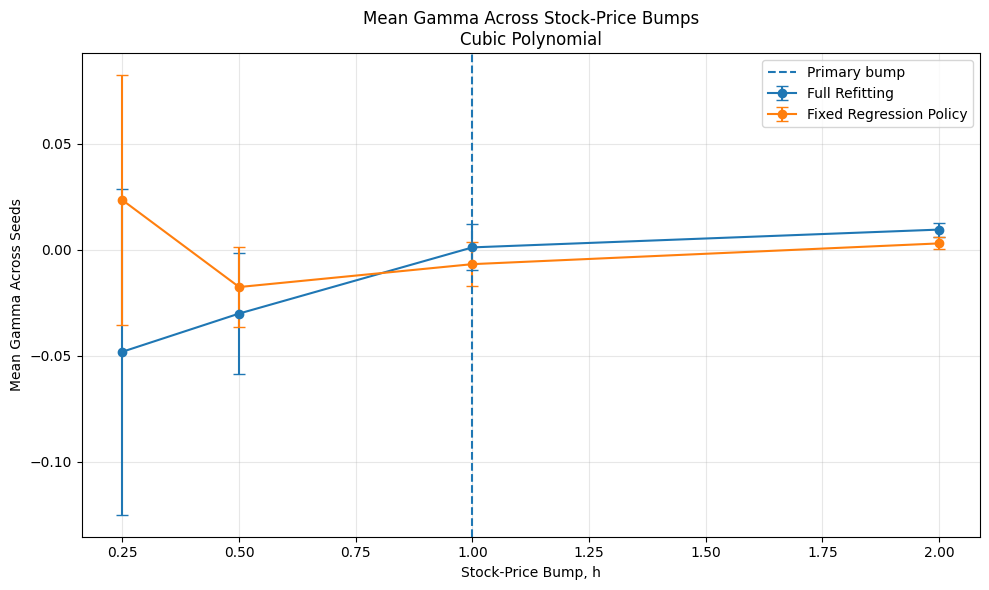

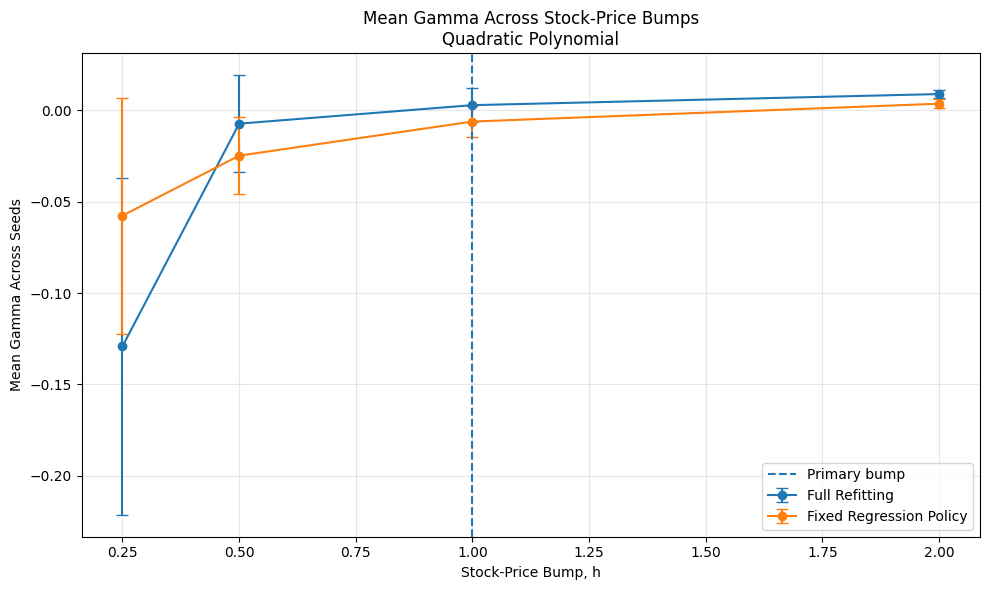

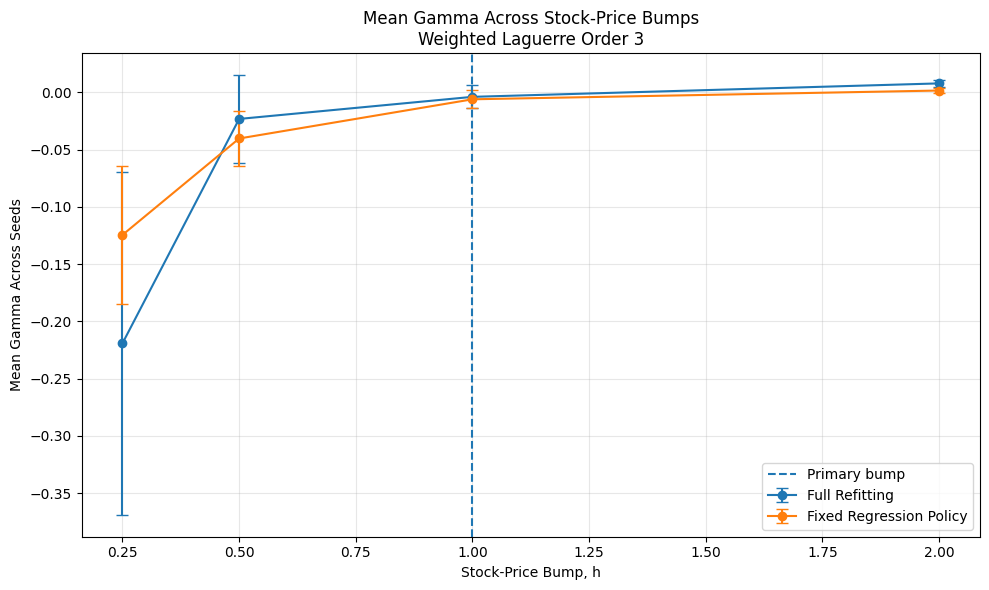

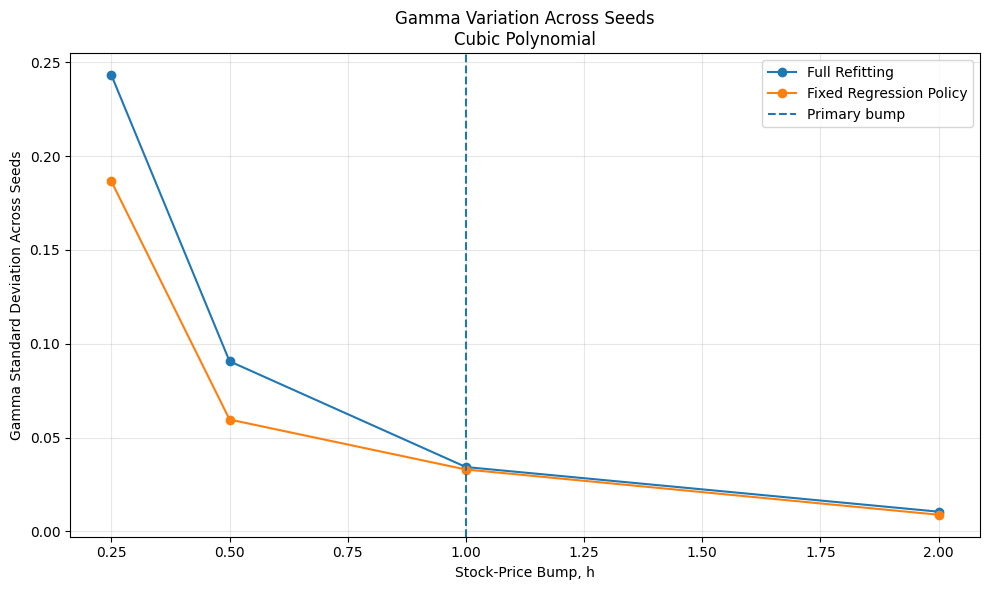

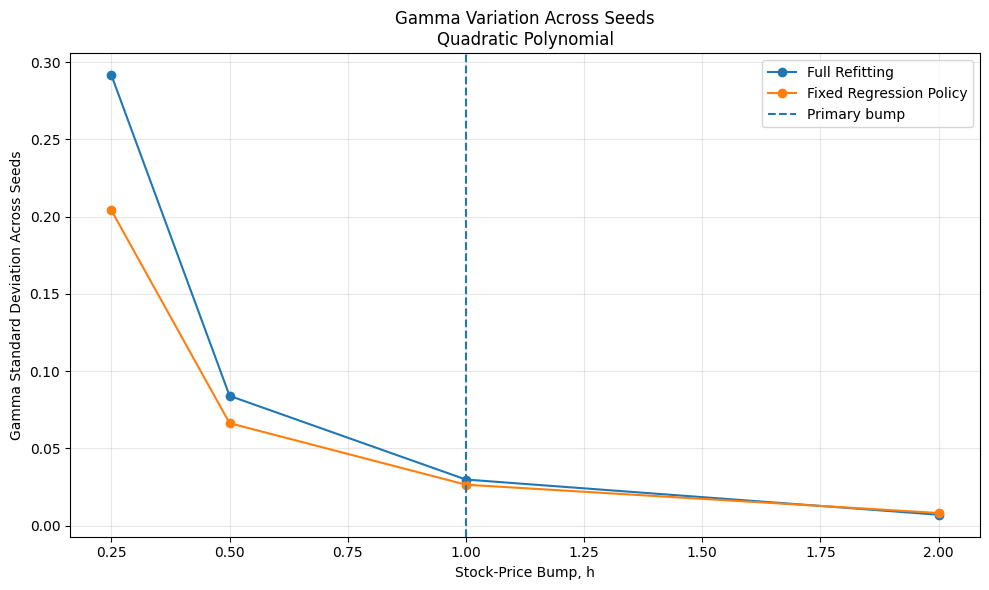

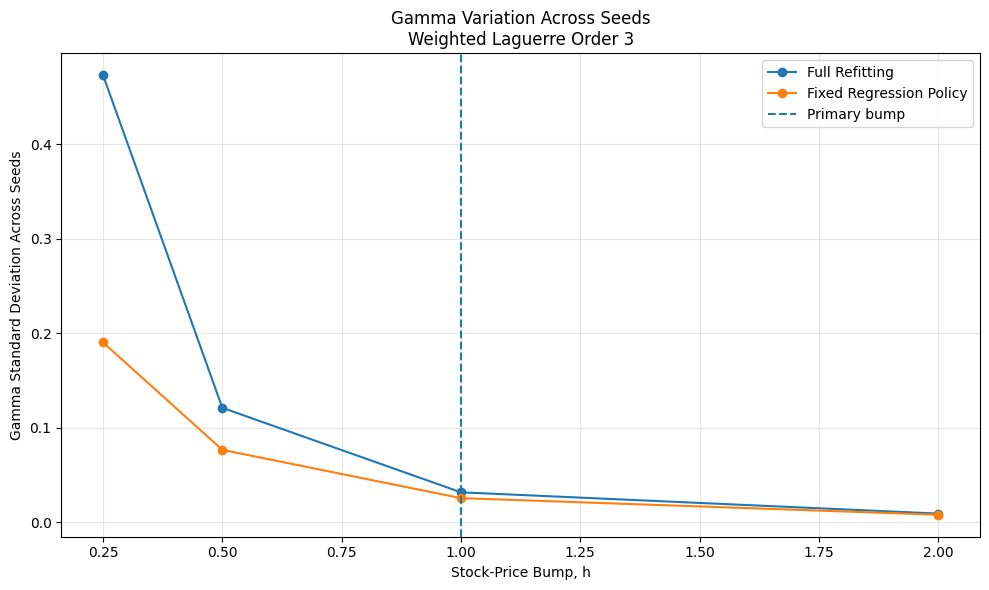

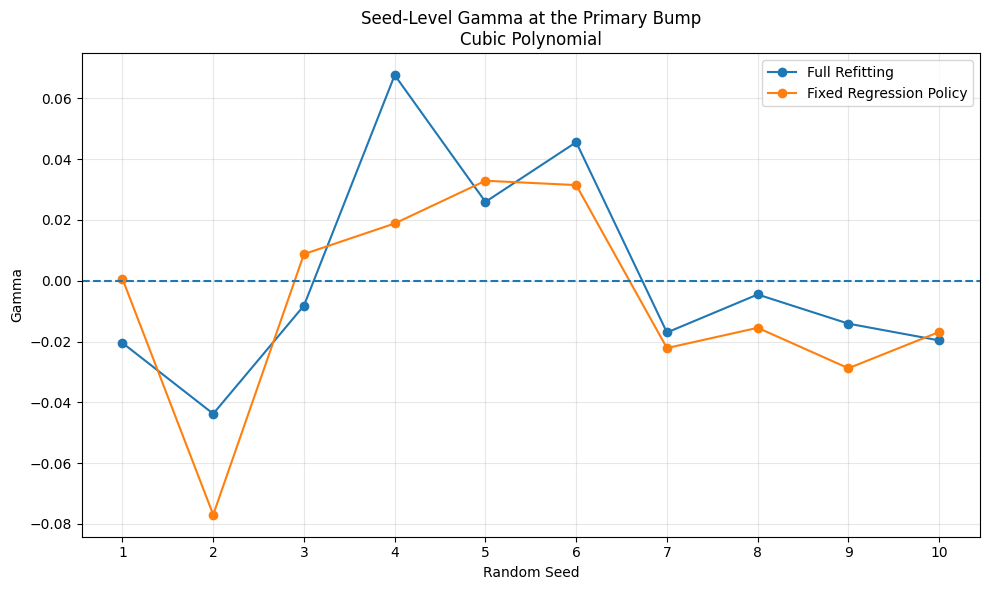

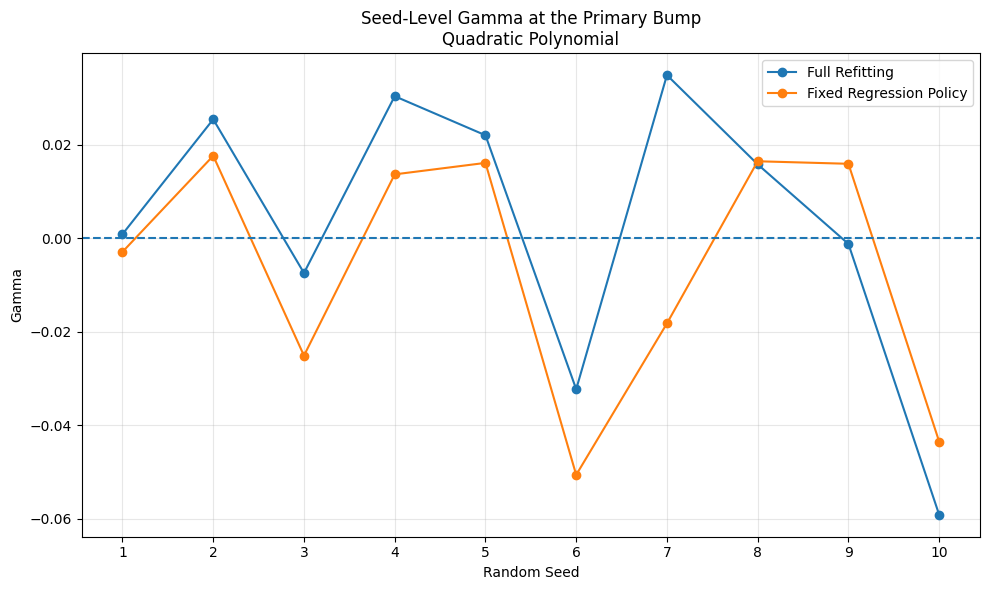

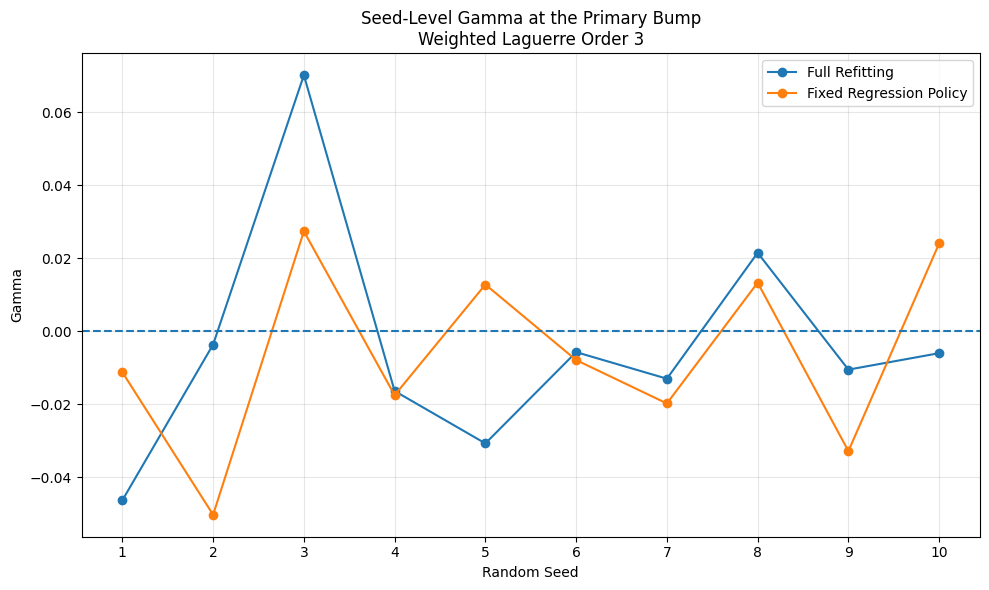

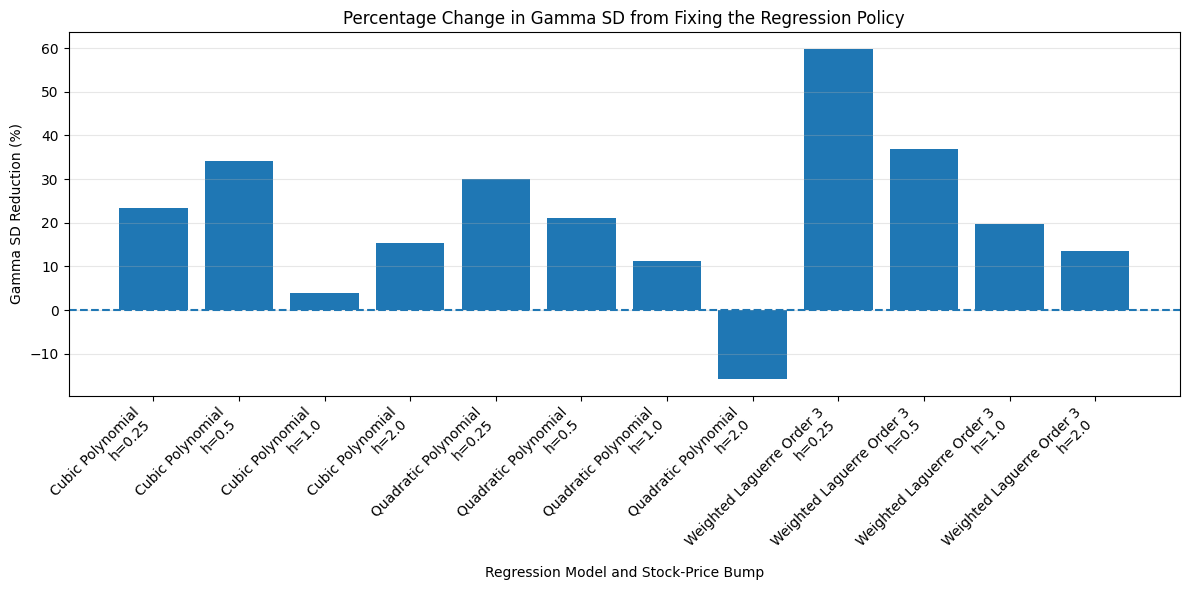


 Final Gamma Diagnostic Comparison


,Overall_Existing_Gamma_Stability_Rank,Gamma_Method,Regression_Model,Stock_Price_Bump,Mean_Gamma,Gamma_SD_Across_Seeds,Gamma_Standard_Error,Gamma_Interquartile_Range,Gamma_Median_Absolute_Deviation,Negative_Gamma_Percentage,IQR_Outlier_Percentage
0,1,Fixed Regression Policy,Weighted Laguerre Order 3,2.00,0.001502,0.007747,0.002450,0.007234,0.004451,50.0,10.0
1,2,Fixed Regression Policy,Cubic Polynomial,2.00,0.003021,0.008908,0.002817,0.009587,0.004255,40.0,10.0
2,3,Full Refitting,Quadratic Polynomial,2.00,0.008989,0.007063,0.002233,0.012839,0.006666,10.0,0.0
3,4,Fixed Regression Policy,Quadratic Polynomial,2.00,0.003712,0.008178,0.002586,0.013796,0.004684,50.0,0.0
4,5,Full Refitting,Cubic Polynomial,2.00,0.009532,0.010539,0.003333,0.012395,0.006023,20.0,0.0
5,6,Full Refitting,Weighted Laguerre Order 3,2.00,0.007733,0.008962,0.002834,0.013538,0.007203,20.0,0.0
6,7,Full Refitting,Weighted Laguerre Order 3,1.00,-0.004018,0.031511,0.009965,0.011374,0.006426,80.0,30.0
7,8,Full Refitting,Quadratic Polynomial,1.00,0.002913,0.029847,0.009438,0.030436,0.016421,40.0,10.0
8,9,Fixed Regression Policy,Weighted Laguerre Order 3,1.00,-0.006152,0.025334,0.008011,0.032401,0.022617,60.0,0.0
9,10,Fixed Regression Policy,Quadratic Polynomial,1.00,-0.006066,0.026514,0.008385,0.039412,0.011663,50.0,0.0



Part 5B Reference - Quadratic Model at Primary Bump


,Gamma_Method,Regression_Model,Stock_Price_Bump,Mean_Gamma,Median_Gamma,Gamma_SD_Across_Seeds,Gamma_Standard_Error,Gamma_Coefficient_Of_Variation,Gamma_Interquartile_Range,Gamma_Median_Absolute_Deviation,Negative_Gamma_Percentage
0,Fixed Regression Policy,Quadratic Polynomial,1.0,-0.006066,0.005353,0.026514,0.008385,4.371305,0.039412,0.011663,50.0
1,Full Refitting,Quadratic Polynomial,1.0,0.002913,0.008315,0.029847,0.009438,10.244794,0.030436,0.016421,40.0


Part 5A Summary:

Central research question:
How can Gamma estimation be made more stable when small changes in stock price can affect the Longstaff-Schwartz regression and exercise decisions?

Data reused:
Part 3A full-refit rows: 120
Part 3B fixed-policy rows: 120
Combined Gamma observations: 240

Main specification retained:
Paths: 10000
Exercise intervals: 50
Reference model: Quadratic Polynomial
Primary stock-price bump: 1.0

Validation checks:
All Gamma values finite: True
Gamma recalculation passed: True
Both methods present: True
Models aligned: True
Bumps aligned: True
Primary bump present: True
Reference model present: True

Policy-stability comparison:
Comparisons where fixed policy has lower Gamma SD: 11 out of 12
Percentage with lower fixed-policy Gamma SD: 91.6667

Most stable existing three-point configuration under the composite ranking:
Method: Fixed Regression Policy
Regression model: Weighted Laguerre Order 3
Stock-price bump: 2.0
Mean Gamma: 0.00150153
Gamma SD acro

In [16]:
#### PART 5A - GAMMA STABILITY AND BUMP-SIZE ANALYSIS ####

# Goal:
# 1. Make Gamma stability the central focus
# 2. Compare the two Greek-estimation approaches already implemented:
#       - Part 3A: full Longstaff-Schwartz refitting for every bump
#       - Part 3B: fixed base regression policy for bumped valuations
# 3. Examine how Gamma changes across:
#       - stock-price bump sizes
#       - random seeds
#       - continuation-value regression models
#       - policy-treatment methods
# 4. Measure Gamma stability using standard and outlier-resistant measures
# 5. Identify the most stable three-point Gamma setup
# 6. Provide the benchmark for the smoothed Gamma method

# Important:
# - It does not regenerate or alter the synthetic data
# - It reuses df_delta_gamma_all and df_fixed_policy_delta_gamma_all from Parts 3A and 3B (refit vs fixed)
# - The main specification remains 10,000 paths and 50 intervals
# - Alternative bump sizes are sensitivity checks, not new datasets

### REQUIRED-OBJECT CHECK

part5a_required_objects = ["df_delta_gamma_all", "df_fixed_policy_delta_gamma_all"]

# Check that both previously calculated Gamma result tables are available
part5a_missing_objects = [object_name for object_name in part5a_required_objects if object_name not in globals()]
if part5a_missing_objects:
    raise NameError("Part 5A requires the following objects from Parts 3A and 3B: " + ", ".join(part5a_missing_objects) + ". Run Parts 3A and 3B before Part 5A.")

### PART 5A SETTINGS

part5a_primary_stock_bump = (float(primary_stock_bump) if "primary_stock_bump" in globals() else 1.00)
part5a_reference_model = "Quadratic Polynomial"
part5a_confidence_multiplier = 1.96
part5a_outlier_iqr_multiplier = 1.5
part5a_epsilon = 1e-12

### VALIDATE INPUT TABLES

part5a_required_columns = {
    "df_delta_gamma_all": ["Seed", "Regression_Model", "Stock_Price_Bump", "Base_Price", "Lower_Price", "Upper_Price", "Delta", "Gamma"],
    "df_fixed_policy_delta_gamma_all": ["Seed", "Regression_Model", "Stock_Price_Bump", "Base_Price", "Lower_Price", "Upper_Price", "Delta", "Gamma"]
}

# Confirm that both input dataframes contain the columns needed for the diagnostics
for dataframe_name, required_columns in part5a_required_columns.items():
    dataframe = globals()[dataframe_name]
    missing_columns = [column
        for column in required_columns
        if column not in dataframe.columns]
    if missing_columns:
        raise KeyError(f"{dataframe_name} is missing required columns: " + ", ".join(missing_columns))

### COMBINE PART 3A AND 3B (REFIT AND FIXED) RESULTS

# Label the full-refit and fixed-regression-policy observations before combining them
df_part5a_full_refit = df_delta_gamma_all.copy()
df_part5a_full_refit["Gamma_Method"] = "Full Refitting"
df_part5a_full_refit["Method_Code"] = "Part 3A"

df_part5a_fixed_policy = df_fixed_policy_delta_gamma_all.copy()
df_part5a_fixed_policy["Gamma_Method"] = "Fixed Regression Policy"
df_part5a_fixed_policy["Method_Code"] = "Part 3B"

# Keep only columns available under both methods so the combined dataframe remains consistent
part5a_common_columns = sorted(set(df_part5a_full_refit.columns).intersection(df_part5a_fixed_policy.columns))

part5a_priority_columns = [
    "Method_Code",
    "Gamma_Method",
    "Regression_Model",
    "Basis_Type",
    "Regression_Order",
    "Seed",
    "Stock_Price_Bump",
    "Lower_Stock_Price",
    "Lower_Price",
    "Base_Price",
    "Upper_Stock_Price",
    "Upper_Price",
    "Delta",
    "Gamma"
]

part5a_ordered_columns = [column
    for column in part5a_priority_columns
    if column in part5a_common_columns] + [column
    for column in part5a_common_columns
    if column not in part5a_priority_columns]

df_part5a_gamma_all = pd.concat([df_part5a_full_refit[part5a_ordered_columns], df_part5a_fixed_policy[part5a_ordered_columns]], ignore_index=True)
df_part5a_gamma_all = (df_part5a_gamma_all.sort_values(["Regression_Model", "Stock_Price_Bump", "Seed", "Gamma_Method"]).reset_index(drop=True))

# Reconstruct the finite-difference numerator and Gamma to validate the stored calculations
df_part5a_gamma_all["Gamma_Finite_Difference_Numerator"] = (df_part5a_gamma_all["Upper_Price"] - 2 * df_part5a_gamma_all["Base_Price"] + df_part5a_gamma_all["Lower_Price"])
df_part5a_gamma_all["Recalculated_Gamma"] = (df_part5a_gamma_all["Gamma_Finite_Difference_Numerator"] / (df_part5a_gamma_all["Stock_Price_Bump"] ** 2))
df_part5a_gamma_all["Gamma_Recalculation_Difference"] = (df_part5a_gamma_all["Gamma"] - df_part5a_gamma_all["Recalculated_Gamma"]).abs()
df_part5a_gamma_all["Gamma_Is_Negative"] = (df_part5a_gamma_all["Gamma"] < 0)
df_part5a_gamma_all["Gamma_Is_Nonfinite"] = (~np.isfinite(df_part5a_gamma_all["Gamma"]))
display(df_part5a_gamma_all.head(20).round(8))

### GAMMA STABILITY SUMMARY HELPER

# Calculate Gamma stability measures
def calculate_part5a_gamma_group_statistics(group):
    # Convert Gamma values to a clean numerical array and remove missing or infinite observations
    gamma_values = (pd.to_numeric(group["Gamma"], errors="coerce").replace([np.inf, -np.inf], np.nan).dropna().to_numpy(dtype=float))
    n = len(gamma_values)
    if n == 0:
        return pd.Series({
            "Number_Of_Seeds": 0,
            "Mean_Gamma": np.nan,
            "Median_Gamma": np.nan,
            "Gamma_SD_Across_Seeds": np.nan,
            "Gamma_Standard_Error": np.nan,
            "Gamma_Confidence_Interval_Lower": np.nan,
            "Gamma_Confidence_Interval_Upper": np.nan,
            "Gamma_Coefficient_Of_Variation": np.nan,
            "Gamma_Interquartile_Range": np.nan,
            "Gamma_Median_Absolute_Deviation": np.nan,
            "Minimum_Gamma": np.nan,
            "Maximum_Gamma": np.nan,
            "Gamma_Range": np.nan,
            "Negative_Gamma_Count": 0,
            "Negative_Gamma_Percentage": np.nan,
            "IQR_Outlier_Count": 0,
            "IQR_Outlier_Percentage": np.nan
        })

    mean_gamma = float(np.mean(gamma_values))
    median_gamma = float(np.median(gamma_values))
    gamma_sd = float(np.std(gamma_values, ddof=1)) if n > 1 else 0.0
    gamma_se = gamma_sd / np.sqrt(n)

    # Measure Gamma variation and identify IQR outliers
    q1 = float(np.percentile(gamma_values, 25))
    q3 = float(np.percentile(gamma_values, 75))
    gamma_iqr = q3 - q1
    gamma_mad = float(np.median(np.abs(gamma_values - median_gamma)))
    lower_limit = q1 - part5a_outlier_iqr_multiplier * gamma_iqr
    upper_limit = q3 + part5a_outlier_iqr_multiplier * gamma_iqr
    iqr_outlier_count = int(np.sum((gamma_values < lower_limit) | (gamma_values > upper_limit)))
    negative_count = int(np.sum(gamma_values < 0))

    return pd.Series({
        "Number_Of_Seeds": n,
        "Mean_Gamma": mean_gamma,
        "Median_Gamma": median_gamma,
        "Gamma_SD_Across_Seeds": gamma_sd,
        "Gamma_Standard_Error": gamma_se,
        "Gamma_Confidence_Interval_Lower": (mean_gamma - part5a_confidence_multiplier * gamma_se),
        "Gamma_Confidence_Interval_Upper": (mean_gamma + part5a_confidence_multiplier * gamma_se),
        "Gamma_Coefficient_Of_Variation": (gamma_sd / max(abs(mean_gamma), part5a_epsilon)),
        "Gamma_Interquartile_Range": gamma_iqr,
        "Gamma_Median_Absolute_Deviation": gamma_mad,
        "Minimum_Gamma": float(np.min(gamma_values)),
        "Maximum_Gamma": float(np.max(gamma_values)),
        "Gamma_Range": float(np.max(gamma_values) - np.min(gamma_values)),
        "Negative_Gamma_Count": negative_count,
        "Negative_Gamma_Percentage": 100 * negative_count / n,
        "IQR_Outlier_Count": iqr_outlier_count,
        "IQR_Outlier_Percentage": 100 * iqr_outlier_count / n
    })

### SUMMARY BY METHOD, MODEL, AND BUMP

# Summarise Gamma stability for every method, model and stock-price bump
df_part5a_gamma_summary = (df_part5a_gamma_all
    .groupby(["Method_Code", "Gamma_Method", "Regression_Model", "Stock_Price_Bump"], sort=False)
    .apply(calculate_part5a_gamma_group_statistics, include_groups=False)
    .reset_index())
# Summarise the finite-difference numerator and Gamma recalculation accuracy
df_part5a_numerator_summary = (df_part5a_gamma_all
    .groupby(["Method_Code", "Gamma_Method", "Regression_Model", "Stock_Price_Bump"], as_index=False)
    .agg(Mean_Gamma_Finite_Difference_Numerator=("Gamma_Finite_Difference_Numerator", "mean"),
        SD_Gamma_Finite_Difference_Numerator=("Gamma_Finite_Difference_Numerator", "std"),
        Maximum_Gamma_Recalculation_Difference=("Gamma_Recalculation_Difference", "max")))
# Merge the Gamma stability and finite-difference results
df_part5a_gamma_summary = (df_part5a_gamma_summary
    .merge(df_part5a_numerator_summary,
        on=["Method_Code", "Gamma_Method", "Regression_Model", "Stock_Price_Bump"],
        how="left")
    .sort_values(["Regression_Model", "Stock_Price_Bump", "Gamma_Method"])
    .reset_index(drop=True))

display(df_part5a_gamma_summary.round(8))

### PAIRED SEED-BY-SEED METHOD COMPARISON

# Pair the two methods seed by seed so their Gamma estimates can be compared directly
df_part5a_method_pairing = (df_part5a_gamma_all
    .pivot_table(index=["Regression_Model", "Stock_Price_Bump", "Seed"], columns="Gamma_Method", values="Gamma", aggfunc="first")
    .reset_index())
df_part5a_method_pairing.columns.name = None
required_method_columns = ["Full Refitting", "Fixed Regression Policy"]

missing_method_columns = [column
    for column in required_method_columns
    if column not in df_part5a_method_pairing.columns]
if missing_method_columns:
    raise KeyError("The paired Gamma comparison could not find: " + ", ".join(missing_method_columns))

df_part5a_method_pairing["Fixed_Minus_Full_Gamma"] = (df_part5a_method_pairing["Fixed Regression Policy"] - df_part5a_method_pairing["Full Refitting"])
df_part5a_method_pairing["Absolute_Method_Difference"] = (df_part5a_method_pairing["Fixed_Minus_Full_Gamma"].abs())
df_part5a_method_pair_summary = (df_part5a_method_pairing
    .groupby(["Regression_Model", "Stock_Price_Bump"], as_index=False)
    .agg(Mean_Full_Refit_Gamma=("Full Refitting", "mean"),
        Mean_Fixed_Policy_Gamma=("Fixed Regression Policy", "mean"),
        Mean_Fixed_Minus_Full_Gamma=("Fixed_Minus_Full_Gamma", "mean"),
        Mean_Absolute_Method_Difference=("Absolute_Method_Difference", "mean"),
        SD_Of_Paired_Method_Difference=("Fixed_Minus_Full_Gamma", "std"),
        Maximum_Absolute_Method_Difference=("Absolute_Method_Difference", "max")))

display(df_part5a_method_pair_summary.round(8))

### STABILITY IMPROVEMENT FROM FIXING THE POLICY

part5a_full_summary = (df_part5a_gamma_summary[df_part5a_gamma_summary["Gamma_Method"] == "Full Refitting"][["Regression_Model",
            "Stock_Price_Bump",
            "Mean_Gamma",
            "Gamma_SD_Across_Seeds",
            "Gamma_Interquartile_Range",
            "Gamma_Median_Absolute_Deviation",
            "Gamma_Coefficient_Of_Variation",
            "Negative_Gamma_Percentage",
            "IQR_Outlier_Percentage"]]
    .rename(columns={
            "Mean_Gamma": "Full_Refit_Mean_Gamma",
            "Gamma_SD_Across_Seeds": "Full_Refit_Gamma_SD",
            "Gamma_Interquartile_Range": "Full_Refit_Gamma_IQR",
            "Gamma_Median_Absolute_Deviation": "Full_Refit_Gamma_MAD",
            "Gamma_Coefficient_Of_Variation": "Full_Refit_Gamma_CV",
            "Negative_Gamma_Percentage": "Full_Refit_Negative_Gamma_Percentage",
            "IQR_Outlier_Percentage": "Full_Refit_IQR_Outlier_Percentage"
        }))

part5a_fixed_summary = (df_part5a_gamma_summary[df_part5a_gamma_summary["Gamma_Method"]
        == "Fixed Regression Policy"][["Regression_Model",
            "Stock_Price_Bump",
            "Mean_Gamma",
            "Gamma_SD_Across_Seeds",
            "Gamma_Interquartile_Range",
            "Gamma_Median_Absolute_Deviation",
            "Gamma_Coefficient_Of_Variation",
            "Negative_Gamma_Percentage",
            "IQR_Outlier_Percentage"]]
    .rename(columns={
            "Mean_Gamma": "Fixed_Policy_Mean_Gamma",
            "Gamma_SD_Across_Seeds": "Fixed_Policy_Gamma_SD",
            "Gamma_Interquartile_Range": "Fixed_Policy_Gamma_IQR",
            "Gamma_Median_Absolute_Deviation": "Fixed_Policy_Gamma_MAD",
            "Gamma_Coefficient_Of_Variation": "Fixed_Policy_Gamma_CV",
            "Negative_Gamma_Percentage": "Fixed_Policy_Negative_Gamma_Percentage",
            "IQR_Outlier_Percentage": "Fixed_Policy_IQR_Outlier_Percentage"
        }))

# Merge both method summaries to measure whether fixing the regression policy improves stability
df_part5a_policy_improvement = (part5a_full_summary.merge(part5a_fixed_summary, on=["Regression_Model", "Stock_Price_Bump"], how="inner"))
df_part5a_policy_improvement["Gamma_Mean_Change_Fixed_Minus_Full"] = (df_part5a_policy_improvement["Fixed_Policy_Mean_Gamma"] - df_part5a_policy_improvement["Full_Refit_Mean_Gamma"])
df_part5a_policy_improvement["Gamma_SD_Reduction"] = (df_part5a_policy_improvement["Full_Refit_Gamma_SD"] - df_part5a_policy_improvement["Fixed_Policy_Gamma_SD"])
df_part5a_policy_improvement["Gamma_SD_Reduction_Percentage"] = (100
    * df_part5a_policy_improvement["Gamma_SD_Reduction"]
    / np.maximum(df_part5a_policy_improvement["Full_Refit_Gamma_SD"], part5a_epsilon))
df_part5a_policy_improvement["Gamma_IQR_Reduction_Percentage"] = (100
    * (df_part5a_policy_improvement["Full_Refit_Gamma_IQR"] - df_part5a_policy_improvement["Fixed_Policy_Gamma_IQR"])
    / np.maximum(df_part5a_policy_improvement["Full_Refit_Gamma_IQR"], part5a_epsilon))
df_part5a_policy_improvement["Gamma_MAD_Reduction_Percentage"] = (100
    * (df_part5a_policy_improvement["Full_Refit_Gamma_MAD"] - df_part5a_policy_improvement["Fixed_Policy_Gamma_MAD"])
    / np.maximum(df_part5a_policy_improvement["Full_Refit_Gamma_MAD"], part5a_epsilon))
df_part5a_policy_improvement["Fixed_Policy_Has_Lower_Gamma_SD"] = (df_part5a_policy_improvement["Fixed_Policy_Gamma_SD"] < df_part5a_policy_improvement["Full_Refit_Gamma_SD"])

display(df_part5a_policy_improvement.round(8))

### BUMP-SIZE SENSITIVITY

# Measure how much the mean Gamma estimate changes when the stock-price bump changes
df_part5a_bump_sensitivity = (df_part5a_gamma_summary.sort_values(["Gamma_Method", "Regression_Model", "Stock_Price_Bump"]).copy())
df_part5a_bump_sensitivity["Previous_Stock_Price_Bump"] = (df_part5a_bump_sensitivity.groupby(["Gamma_Method", "Regression_Model"])["Stock_Price_Bump"].shift(1))
df_part5a_bump_sensitivity["Change_In_Mean_Gamma_From_Previous_Bump"] = (df_part5a_bump_sensitivity.groupby(["Gamma_Method", "Regression_Model"])["Mean_Gamma"].diff())
df_part5a_bump_sensitivity["Percentage_Change_In_Mean_Gamma_From_Previous_Bump"] = (100
    * df_part5a_bump_sensitivity["Change_In_Mean_Gamma_From_Previous_Bump"]
    / np.maximum(df_part5a_bump_sensitivity.groupby(["Gamma_Method", "Regression_Model"])["Mean_Gamma"].shift(1).abs(), part5a_epsilon)
    )

display(df_part5a_bump_sensitivity[["Gamma_Method",
            "Regression_Model",
            "Stock_Price_Bump",
            "Previous_Stock_Price_Bump",
            "Mean_Gamma",
            "Gamma_SD_Across_Seeds",
            "Change_In_Mean_Gamma_From_Previous_Bump",
            "Percentage_Change_In_Mean_Gamma_From_Previous_Bump"]].round(8))

df_part5a_method_model_bump_stability = (df_part5a_gamma_summary
    .groupby(["Method_Code", "Gamma_Method", "Regression_Model"], as_index=False)
    .agg(Mean_Gamma_Across_Bumps=("Mean_Gamma", "mean"),
        SD_Of_Mean_Gamma_Across_Bumps=("Mean_Gamma", "std"),
        Minimum_Mean_Gamma_Across_Bumps=("Mean_Gamma", "min"),
        Maximum_Mean_Gamma_Across_Bumps=("Mean_Gamma", "max"),
        Mean_Gamma_SD_Across_Seeds=("Gamma_SD_Across_Seeds", "mean"),
        Maximum_Gamma_SD_Across_Seeds=("Gamma_SD_Across_Seeds", "max"),
        Mean_Gamma_IQR=("Gamma_Interquartile_Range", "mean"),
        Mean_Negative_Gamma_Percentage=("Negative_Gamma_Percentage", "mean"),
        Mean_IQR_Outlier_Percentage=("IQR_Outlier_Percentage", "mean")))

df_part5a_method_model_bump_stability["Range_Of_Mean_Gamma_Across_Bumps"] = (df_part5a_method_model_bump_stability["Maximum_Mean_Gamma_Across_Bumps"]
    - df_part5a_method_model_bump_stability["Minimum_Mean_Gamma_Across_Bumps"])
df_part5a_method_model_bump_stability["Relative_Bump_Sensitivity"] = (df_part5a_method_model_bump_stability["SD_Of_Mean_Gamma_Across_Bumps"]
    / np.maximum(df_part5a_method_model_bump_stability["Mean_Gamma_Across_Bumps"].abs(), part5a_epsilon))

display(df_part5a_method_model_bump_stability.round(8))

### DISPLAY VISUAL

# Print primary-bump and reference-model tables
df_part5a_primary_bump = (df_part5a_gamma_summary[np.isclose(df_part5a_gamma_summary["Stock_Price_Bump"], part5a_primary_stock_bump)].copy())
print("\nPrimary Stock-Price Bump Comparison")
display(df_part5a_primary_bump[["Gamma_Method",
            "Regression_Model",
            "Stock_Price_Bump",
            "Mean_Gamma",
            "Median_Gamma",
            "Gamma_SD_Across_Seeds",
            "Gamma_Standard_Error",
            "Gamma_Confidence_Interval_Lower",
            "Gamma_Confidence_Interval_Upper",
            "Gamma_Coefficient_Of_Variation",
            "Gamma_Interquartile_Range",
            "Gamma_Median_Absolute_Deviation",
            "Negative_Gamma_Percentage",
            "IQR_Outlier_Percentage"]].round(8))

df_part5a_reference_model = (df_part5a_gamma_summary[df_part5a_gamma_summary["Regression_Model"] == part5a_reference_model].copy())
df_part5a_reference_primary = (df_part5a_reference_model[np.isclose(df_part5a_reference_model["Stock_Price_Bump"], part5a_primary_stock_bump)].copy())
print("\nQuadratic Reference Model")
display(df_part5a_reference_model[["Gamma_Method", "Stock_Price_Bump", "Mean_Gamma", "Gamma_SD_Across_Seeds", "Gamma_Coefficient_Of_Variation", "Gamma_Interquartile_Range", "Negative_Gamma_Percentage"]].round(8))

### COMPOSITE EMPIRICAL STABILITY RANKING

# Lower values indicate more stable Gamma estimates, but not necessarily greater accuracy
# Rank each three-point Gamma setup using multiple stability measures
df_part5a_stability_ranking = (df_part5a_gamma_summary
    .merge(df_part5a_method_model_bump_stability[["Gamma_Method", "Regression_Model", "Relative_Bump_Sensitivity"]],
           on=["Gamma_Method", "Regression_Model"],
           how="left"
          ).copy())

ranking_columns = ["Gamma_SD_Across_Seeds", "Gamma_Interquartile_Range", "Gamma_Median_Absolute_Deviation"]
for ranking_column in ranking_columns:
    df_part5a_stability_ranking[ranking_column + "_Rank"] = (df_part5a_stability_ranking[ranking_column].rank(method="average", ascending=True))
df_part5a_stability_ranking["Mean_Gamma_Stability_Rank"] = (df_part5a_stability_ranking[[column + "_Rank" for column in ranking_columns]].mean(axis=1))

# Rank each three-point Gamma setup using multiple stability measures
df_part5a_stability_ranking = (df_part5a_stability_ranking
    .sort_values(["Mean_Gamma_Stability_Rank", "Gamma_SD_Across_Seeds", "Gamma_Interquartile_Range", "Stock_Price_Bump"])
    .reset_index(drop=True))

df_part5a_stability_ranking["Overall_Existing_Gamma_Stability_Rank"] = np.arange(1, len(df_part5a_stability_ranking) + 1)
print("\n Existing Gamma Stability Ranking")
display(df_part5a_stability_ranking[["Overall_Existing_Gamma_Stability_Rank",
            "Gamma_Method",
            "Regression_Model",
            "Stock_Price_Bump",
            "Mean_Gamma",
            "Gamma_SD_Across_Seeds",
            "Gamma_Interquartile_Range",
            "Gamma_Median_Absolute_Deviation",
            "Gamma_Coefficient_Of_Variation",
            "Negative_Gamma_Percentage",
            "Mean_Gamma_Stability_Rank"]].round(8))

# Plot mean Gamma by bump size
part5a_models = list(df_part5a_gamma_summary["Regression_Model"].drop_duplicates())
part5a_methods = ["Full Refitting", "Fixed Regression Policy"]

for model_name in part5a_models:
    plt.figure(figsize=(10, 6))
    model_plot_data = df_part5a_gamma_summary[df_part5a_gamma_summary["Regression_Model"] == model_name]
    for method_name in part5a_methods:
        method_plot_data = (model_plot_data[model_plot_data["Gamma_Method"] == method_name].sort_values("Stock_Price_Bump"))
        plt.errorbar(method_plot_data["Stock_Price_Bump"], method_plot_data["Mean_Gamma"], yerr=method_plot_data["Gamma_Standard_Error"], marker="o", capsize=4, label=method_name)
    plt.axvline(part5a_primary_stock_bump, linestyle="--", label="Primary bump")
    plt.title("Mean Gamma Across Stock-Price Bumps\n" + model_name)
    plt.xlabel("Stock-Price Bump, h")
    plt.ylabel("Mean Gamma Across Seeds")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Plot Gamma standard deviation by bump size
for model_name in part5a_models:
    plt.figure(figsize=(10, 6))
    model_plot_data = df_part5a_gamma_summary[df_part5a_gamma_summary["Regression_Model"] == model_name]
    for method_name in part5a_methods:
        method_plot_data = (model_plot_data[model_plot_data["Gamma_Method"] == method_name].sort_values("Stock_Price_Bump"))
        plt.plot(method_plot_data["Stock_Price_Bump"], method_plot_data["Gamma_SD_Across_Seeds"], marker="o", label=method_name)
    plt.axvline(part5a_primary_stock_bump, linestyle="--", label="Primary bump")
    plt.title("Gamma Variation Across Seeds\n" + model_name)
    plt.xlabel("Stock-Price Bump, h")
    plt.ylabel("Gamma Standard Deviation Across Seeds")
    plt.grid(alpha=0.3)
    plt.legend()   # Plot seed-level Gamma at the primary bump
    plt.tight_layout()
    plt.show()
    
for model_name in part5a_models:
    plt.figure(figsize=(10, 6))
    primary_seed_plot_data = df_part5a_gamma_all[(df_part5a_gamma_all["Regression_Model"] == model_name)
        & (np.isclose(df_part5a_gamma_all["Stock_Price_Bump"], part5a_primary_stock_bump))]
    for method_name in part5a_methods:
        method_seed_data = (primary_seed_plot_data[primary_seed_plot_data["Gamma_Method"] == method_name].sort_values("Seed"))
        plt.plot(method_seed_data["Seed"], method_seed_data["Gamma"], marker="o", label=method_name)
    plt.axhline(0, linestyle="--")
    plt.title("Seed-Level Gamma at the Primary Bump\n" + model_name)
    plt.xlabel("Random Seed")
    plt.ylabel("Gamma")
    plt.xticks(sorted(primary_seed_plot_data["Seed"].unique()))
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Plot the percentage reduction in Gamma SD from fixing the regression policy
df_part5a_policy_reduction_plot = df_part5a_policy_improvement.copy()
df_part5a_policy_reduction_plot["Comparison_Label"] = (df_part5a_policy_reduction_plot["Regression_Model"] + "\nh=" + df_part5a_policy_reduction_plot["Stock_Price_Bump"].astype(str))

plt.figure(figsize=(12, 6))
plt.bar(df_part5a_policy_reduction_plot["Comparison_Label"], df_part5a_policy_reduction_plot["Gamma_SD_Reduction_Percentage"])
plt.axhline(0, linestyle="--")
plt.title("Percentage Change in Gamma SD from Fixing the Regression Policy")
plt.xlabel("Regression Model and Stock-Price Bump")
plt.ylabel("Gamma SD Reduction (%)")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### VALIDATION CHECKS

# Validate the combined data, method alignment, bump alignment and Gamma recalculation
part5a_all_gamma_values_are_finite = bool(np.isfinite(df_part5a_gamma_all["Gamma"]).all())
part5a_gamma_recalculation_check_passed = bool(np.allclose(df_part5a_gamma_all["Gamma"], df_part5a_gamma_all["Recalculated_Gamma"], rtol=1e-10, atol=1e-10))
part5a_all_expected_methods_present = set(part5a_methods).issubset(set(df_part5a_gamma_all["Gamma_Method"].unique()))
part5a_all_expected_models_present = (set(df_part5a_full_refit["Regression_Model"].unique()) == set(df_part5a_fixed_policy["Regression_Model"].unique()))
part5a_all_expected_bumps_present = (set(np.round(df_part5a_full_refit["Stock_Price_Bump"].unique(), 10)) == set(np.round(df_part5a_fixed_policy["Stock_Price_Bump"].unique(), 10)))
part5a_primary_bump_present = bool(np.isclose(df_part5a_gamma_all["Stock_Price_Bump"], part5a_primary_stock_bump).any())
part5a_reference_model_present = (part5a_reference_model in set(df_part5a_gamma_all["Regression_Model"].unique()))
part5a_fixed_policy_lower_sd_count = int(df_part5a_policy_improvement["Fixed_Policy_Has_Lower_Gamma_SD"].sum())
part5a_total_policy_comparisons = int(len(df_part5a_policy_improvement))
part5a_fixed_policy_lower_sd_percentage = (100 * part5a_fixed_policy_lower_sd_count / part5a_total_policy_comparisons
    if part5a_total_policy_comparisons > 0
    else np.nan)

# Prepare and print the final Gamma benchmark tables
df_part5a_final_comparison = (df_part5a_stability_ranking[["Overall_Existing_Gamma_Stability_Rank",
            "Gamma_Method",
            "Regression_Model",
            "Stock_Price_Bump",
            "Mean_Gamma",
            "Gamma_SD_Across_Seeds",
            "Gamma_Standard_Error",
            "Gamma_Interquartile_Range",
            "Gamma_Median_Absolute_Deviation",
            "Negative_Gamma_Percentage",
            "IQR_Outlier_Percentage"]]
    .copy())

print("\n Final Gamma Diagnostic Comparison")
display(df_part5a_final_comparison.round(8))

df_part5a_part5b_reference = (df_part5a_reference_primary[["Gamma_Method",
            "Regression_Model",
            "Stock_Price_Bump",
            "Mean_Gamma",
            "Median_Gamma",
            "Gamma_SD_Across_Seeds",
            "Gamma_Standard_Error",
            "Gamma_Coefficient_Of_Variation",
            "Gamma_Interquartile_Range",
            "Gamma_Median_Absolute_Deviation",
            "Negative_Gamma_Percentage"]]
    .sort_values("Gamma_SD_Across_Seeds")
    .reset_index(drop=True))

print("\nPart 5B Reference - Quadratic Model at Primary Bump")
display(df_part5a_part5b_reference.round(8))

# Part 5A Summary
# Extract the strongest existing three-point configuration under the composite ranking
part5a_best_existing_row = df_part5a_stability_ranking.iloc[0]

print("Part 5A Summary:")

print("\nCentral research question:")
print(
    "How can Gamma estimation be made more stable when small changes in stock price can affect "
    "the Longstaff-Schwartz regression and exercise decisions?"
)

print("\nData reused:")
print("Part 3A full-refit rows:", len(df_part5a_full_refit))
print("Part 3B fixed-policy rows:", len(df_part5a_fixed_policy))
print("Combined Gamma observations:", len(df_part5a_gamma_all))

print("\nMain specification retained:")
print("Paths:", greeks_n_paths if "greeks_n_paths" in globals() else 10000)
print("Exercise intervals:", greeks_n_steps if "greeks_n_steps" in globals() else 50)
print("Reference model:", part5a_reference_model)
print("Primary stock-price bump:", part5a_primary_stock_bump)

print("\nValidation checks:")
print("All Gamma values finite:", part5a_all_gamma_values_are_finite)
print("Gamma recalculation passed:", part5a_gamma_recalculation_check_passed)
print("Both methods present:", part5a_all_expected_methods_present)
print("Models aligned:", part5a_all_expected_models_present)
print("Bumps aligned:", part5a_all_expected_bumps_present)
print("Primary bump present:", part5a_primary_bump_present)
print("Reference model present:", part5a_reference_model_present)

print("\nPolicy-stability comparison:")
print("Comparisons where fixed policy has lower Gamma SD:", f"{part5a_fixed_policy_lower_sd_count} out of {part5a_total_policy_comparisons}")
print("Percentage with lower fixed-policy Gamma SD:", round(part5a_fixed_policy_lower_sd_percentage, 4))

print("\nMost stable existing three-point configuration under the composite ranking:")
print("Method:", part5a_best_existing_row["Gamma_Method"])
print("Regression model:", part5a_best_existing_row["Regression_Model"])
print("Stock-price bump:", part5a_best_existing_row["Stock_Price_Bump"])
print("Mean Gamma:", round(part5a_best_existing_row["Mean_Gamma"], 8))
print("Gamma SD across seeds:", round(part5a_best_existing_row["Gamma_SD_Across_Seeds"], 8))

print("\nInterpretation guide:")
print("- Gamma uses a second-order finite difference, so small pricing errors can have a large effect on the estimate.")
print("- Small bumps can increase Monte Carlo, regression, and exercise-decision noise.")
print("- Large bumps reduce noise but measure Gamma over a wider range of stock prices.")
print("- Full refitting fits a new regression and makes new exercise decisions for each bumped valuation.")
print("- Fixed-policy valuation keeps the base regression fixed, although bumped paths can still make different exercise decisions.")
print("- Lower Gamma standard deviation, interquartile range, and median absolute deviation indicate greater stability, but not necessarily greater accuracy.")
print("- Negative Gamma estimates can occur because of estimation noise and are not automatically treated as code errors.")
print("- Part 5B compares these three-point estimates with Gamma estimated from a smooth option-price curve.")

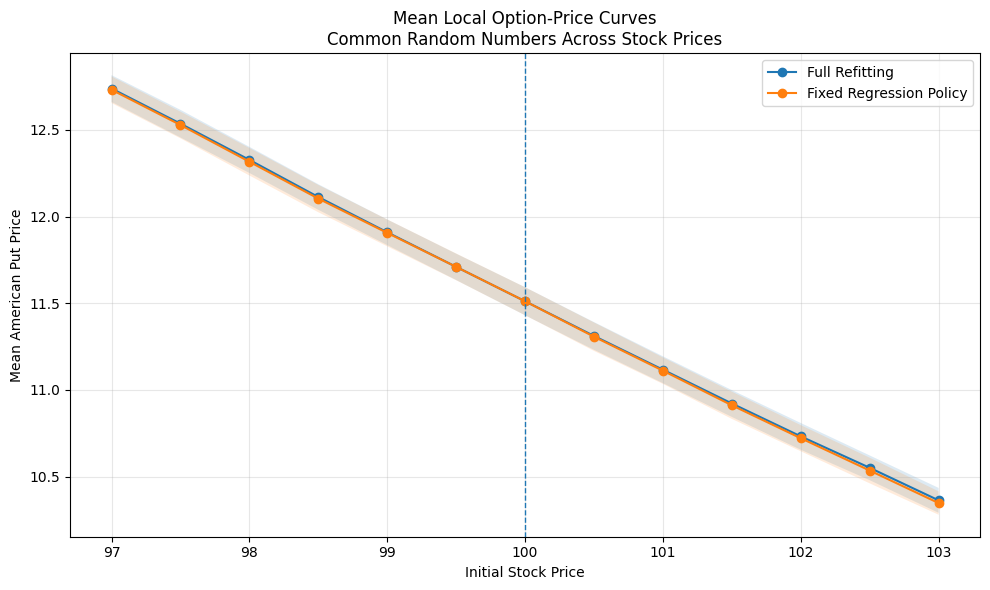

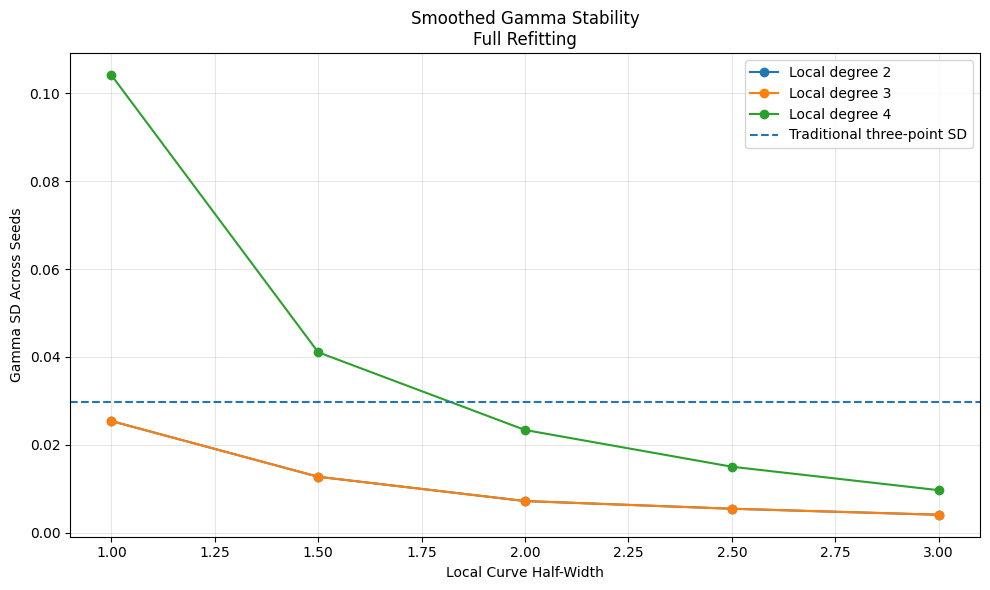

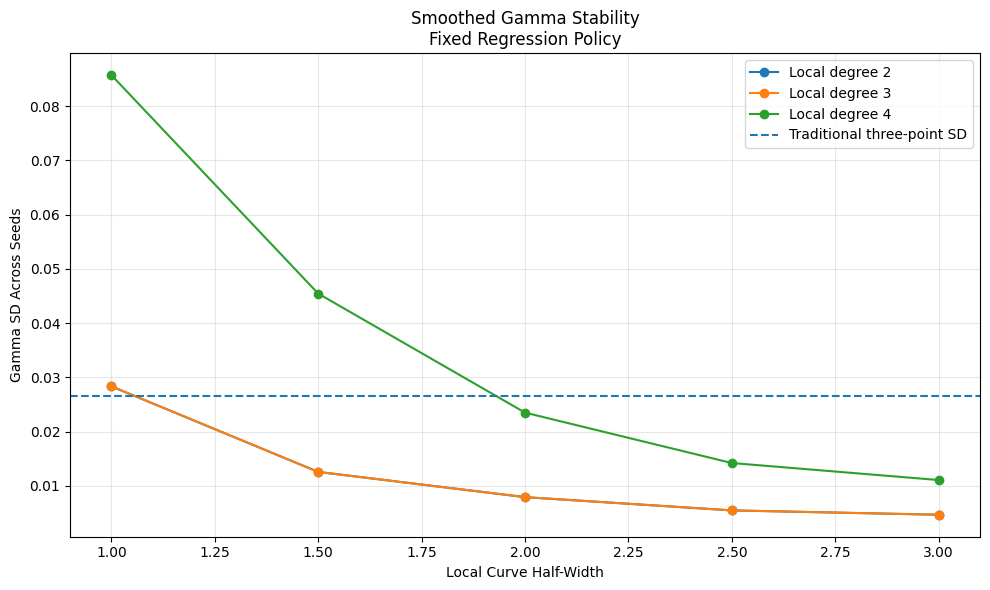

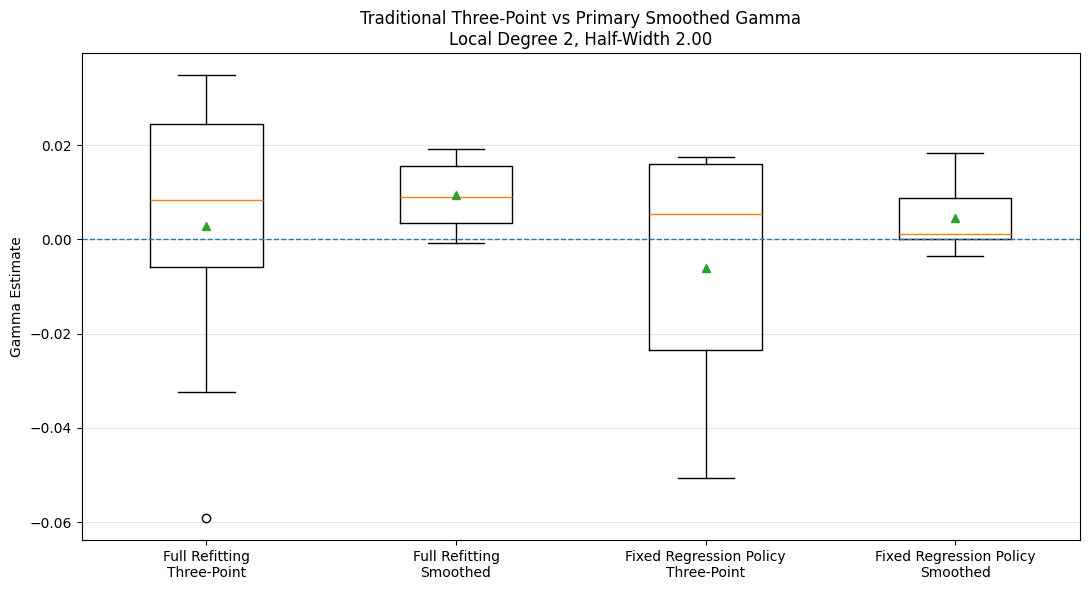

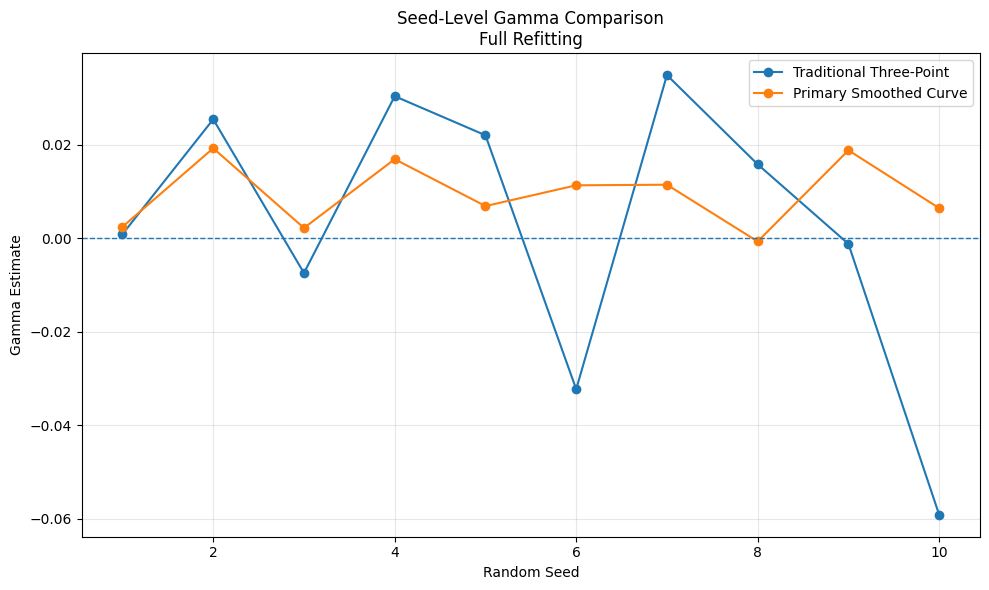

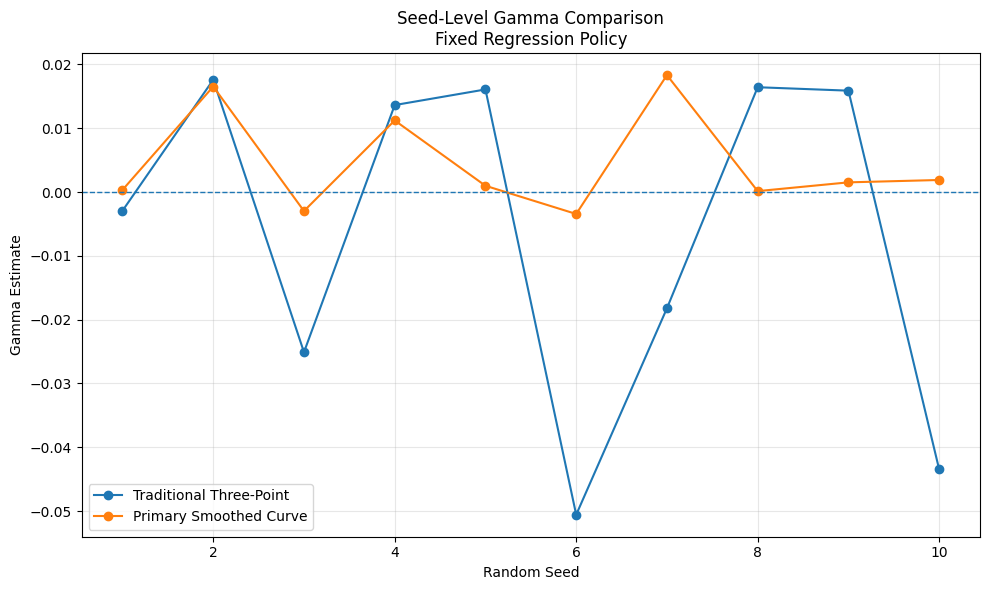

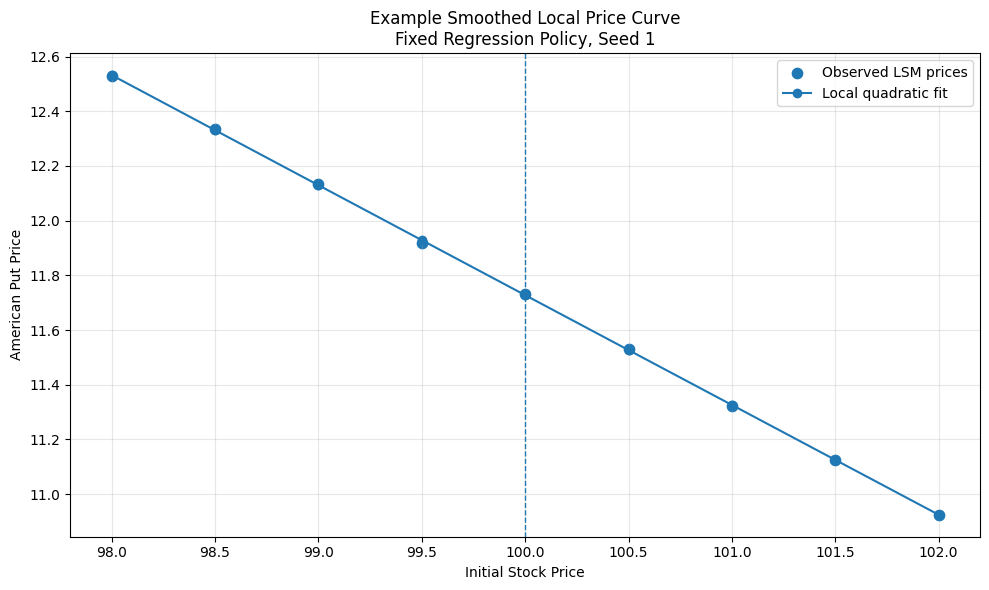


Primary Three-Point VS Smoothed Gamma Comparison


,Estimator_Family,Estimator_Name,Gamma_Method,Number_Of_Seeds,Mean_Gamma,Median_Gamma,Gamma_SD_Across_Seeds,Gamma_Standard_Error,Gamma_Confidence_Interval_Lower,Gamma_Confidence_Interval_Upper,Gamma_Interquartile_Range,Gamma_Median_Absolute_Deviation,Negative_Gamma_Percentage,Mean_Fit_RMSE,Mean_R_Squared,Mean_Absolute_Base_Fit_Error
0,Smoothed Local Price Curve,"Smoothed Local Polynomial (Degree 2, Half-Widt...",Fixed Regression Policy,10,0.004456,0.001252,0.007920,0.002505,-0.000453,0.009365,0.008698,0.002665,20.0,0.009135,0.999662,0.005018
1,Traditional Three-Point,Traditional Three-Point (h = 1.00),Fixed Regression Policy,10,-0.006066,0.005353,0.026514,0.008385,-0.022499,0.010368,0.039412,0.011663,50.0,0.000000,1.000000,0.000000
2,Smoothed Local Price Curve,"Smoothed Local Polynomial (Degree 2, Half-Widt...",Full Refitting,10,0.009476,0.009076,0.007195,0.002275,0.005016,0.013936,0.012087,0.006775,10.0,0.008036,0.999740,0.006558
3,Traditional Three-Point,Traditional Three-Point (h = 1.00),Full Refitting,10,0.002913,0.008315,0.029847,0.009438,-0.015586,0.021413,0.030436,0.016421,40.0,0.000000,1.000000,0.000000



Paired Stability Improvement


,Gamma_Method,Number_Of_Paired_Seeds,Mean_Three_Point_Gamma,Mean_Smoothed_Gamma,Mean_Smoothed_Minus_Three_Point_Gamma,Mean_Absolute_Estimator_Difference,Three_Point_Gamma_SD,Smoothed_Gamma_SD,Gamma_SD_Reduction,Gamma_SD_Reduction_Percentage,Smoothed_Has_Lower_Gamma_SD
0,Fixed Regression Policy,10,-0.006066,0.004456,0.010521,0.020366,0.026514,0.007920,0.018594,70.129400,True
1,Full Refitting,10,0.002913,0.009476,0.006562,0.021494,0.029847,0.007195,0.022652,75.892507,True



Smoothed Gamma Empirical Stability Ranking


,Overall_Smoothed_Stability_Rank,Gamma_Method,Local_Polynomial_Degree,Local_Half_Width,Number_Of_Local_Points,Mean_Gamma,Gamma_SD_Across_Seeds,Gamma_Interquartile_Range,Gamma_Median_Absolute_Deviation,Negative_Gamma_Percentage,Mean_Fit_RMSE,Mean_R_Squared,Mean_Condition_Number,Mean_Gamma_Stability_Rank
0,1,Full Refitting,3.0,3.0,13,0.009745,0.004080,0.003684,0.002778,0.0,0.008478,0.999864,19.582915,2.333333
1,2,Full Refitting,2.0,3.0,13,0.009745,0.004080,0.003684,0.002778,0.0,0.010241,0.999795,7.235064,3.333333
2,3,Fixed Regression Policy,3.0,2.5,11,0.007402,0.005476,0.005212,0.002579,0.0,0.008593,0.999802,12.899530,4.000000
3,4,Fixed Regression Policy,2.0,2.5,11,0.007402,0.005476,0.005212,0.002579,0.0,0.010195,0.999718,5.302970,4.333333
4,5,Fixed Regression Policy,3.0,3.0,13,0.007540,0.004675,0.005554,0.002947,0.0,0.009755,0.999814,19.582915,5.000000
5,6,Fixed Regression Policy,2.0,3.0,13,0.007540,0.004675,0.005554,0.002947,0.0,0.011027,0.999761,7.235064,6.000000
6,7,Full Refitting,2.0,2.5,11,0.010795,0.005446,0.005866,0.003443,10.0,0.009484,0.999756,5.302970,7.000000
7,8,Fixed Regression Policy,2.0,2.0,9,0.004456,0.007920,0.008698,0.002665,20.0,0.009135,0.999662,3.781129,7.666667
8,9,Full Refitting,3.0,2.5,11,0.010795,0.005446,0.005866,0.003443,10.0,0.007397,0.999853,12.899530,8.000000
9,10,Fixed Regression Policy,3.0,2.0,9,0.004456,0.007920,0.008698,0.002665,20.0,0.007635,0.999761,9.070324,8.666667



Local Price Curve Summary


,Gamma_Method,Stock_Offset,Stock_Price,Mean_Option_Price,Option_Price_SD,Mean_Early_Exercise_Percentage,Option_Price_Standard_Error,Confidence_Interval_Lower,Confidence_Interval_Upper
0,Fixed Regression Policy,-3.0,97.0,12.731117,0.123884,44.070,0.039176,12.654332,12.807901
1,Fixed Regression Policy,-2.5,97.5,12.527866,0.124131,43.409,0.039254,12.450929,12.604803
2,Fixed Regression Policy,-2.0,98.0,12.316011,0.127989,42.681,0.040474,12.236683,12.395339
3,Fixed Regression Policy,-1.5,98.5,12.103479,0.127117,41.948,0.040198,12.024691,12.182267
4,Fixed Regression Policy,-1.0,99.0,11.905711,0.125037,41.280,0.039540,11.828212,11.983210
5,Fixed Regression Policy,-0.5,99.5,11.709643,0.124594,40.583,0.039400,11.632419,11.786867
6,Fixed Regression Policy,0.0,100.0,11.511453,0.130404,39.896,0.041238,11.430628,11.592279
7,Fixed Regression Policy,0.5,100.5,11.307080,0.132300,39.136,0.041837,11.225079,11.389080
8,Fixed Regression Policy,1.0,101.0,11.111130,0.123130,38.435,0.038937,11.034813,11.187447
9,Fixed Regression Policy,1.5,101.5,10.911609,0.126730,37.736,0.040075,10.833061,10.990157



Smooothed Local Option-Price Curve Gamma Estimation

Central research question:
Can Gamma stability be improved by differentiating a smooth local option-price curve rather than relying only on three separately valued points?

Main specification:
Paths: 10000
Exercise intervals: 50
Reference continuation model: Quadratic Polynomial
Seeds: 10
Local stock-price grid: 97.00 to 103.00 with spacing 0.50
Primary smoothed estimator: degree 2 with half-width 2.00
Traditional comparison bump: 1.00

Validation checks:
All curve prices finite: True
All Gamma estimates finite: True
Both policy methods present: True
Curve row count passed: True
Smoothed estimator row count passed: True
Primary smoothed specification present: True
Fixed-policy base reproduction passed: True
Three-point benchmark recalculation passed: True
Maximum discounting difference: 0.0

Best smoothed configuration under the composite empirical stability ranking:
Method: Full Refitting
Local polynomial degree: 3
Local half-width

In [17]:
#### PART 5B - IMPROVED GAMMA ESTIMATION USING SMOOTHED LOCAL OPTION-PRICE CURVES ####

# Goal:
# 1. Improve Gamma estimation by fitting a smooth local option-price curve rather than relying only on the traditional three-point formula
# 2. Compare:
#       - Part 3A: Full Longstaff-Schwartz refitting
#       - Part 3B: Fixed base regression policy
# 3. Use common random numbers at every nearby stock price
# 4. Estimate Gamma as the second derivative of a centred local polynomial
# 5. Compare smoothed Gamma with the Part 5A three-point benchmark
# 6. Assess stability across random seeds using:
#       - standard deviation
#       - interquartile range
#       - median absolute deviation
#       - confidence intervals
#       - negative-Gamma frequency

# Important:
# - It uses the Quadratic Polynomial continuation model selected in Part 4A
# - It preserves 10,000 paths and 50 exercise intervals
# - The local price curve is fitted around S0 using x = S - S0
# - Gamma is calculated as twice the fitted x² coefficient
# - The same random shocks are used for all stock prices within each seed
# - Lower variation indicates greater stability, but not necessarily greater accuracy

### IMPORTS AND REQUIRED-OBJECT CHECKS

part5b_required_objects = ["S0",
    "K",
    "r",
    "sigma",
    "T",
    "price_american_put_for_greeks",
    "train_fixed_regression_policy",
    "price_with_fixed_regression_policy"]

# Check that the pricing and fixed-policy functions from earlier parts are available
part5b_missing_objects = [object_name for object_name in part5b_required_objects if object_name not in globals()]
if part5b_missing_objects:
    raise NameError("Part 5B requires the following objects from earlier parts: " + ", ".join(part5b_missing_objects) + ". Run Parts 3A, 3B, and 5A before Part 5B.")

### SETTINGS

part5b_reference_model = "Quadratic Polynomial"
part5b_basis_type = "Polynomial"
part5b_regression_order = 2
part5b_number_of_paths = (int(greeks_n_paths) if "greeks_n_paths" in globals() else 10000)
part5b_number_of_steps = (int(greeks_n_steps) if "greeks_n_steps" in globals() else 50)
part5b_seeds = (list(greeks_seeds) if "greeks_seeds" in globals() else list(range(1, 11)))
part5b_primary_three_point_bump = (float(part5a_primary_stock_bump)
    if "part5a_primary_stock_bump" in globals() else (float(primary_stock_bump)
        if "primary_stock_bump" in globals() else 1.00)
    )

# A dense local grid is generated once for each seed and method
# Grid spacing of 0.50 gives 13 prices from S0 - 3 to S0 + 3
part5b_grid_spacing = 0.50
part5b_maximum_half_width = 3.00

# Create the common centred stock-price grid used by both methods
part5b_stock_offsets = np.arange(-part5b_maximum_half_width, part5b_maximum_half_width + part5b_grid_spacing / 2, part5b_grid_spacing)
part5b_stock_prices = S0 + part5b_stock_offsets
if np.any(part5b_stock_prices <= 0):
    raise ValueError("The Part 5B stock-price grid contains a non-positive value. " "Reduce part5b_maximum_half_width.")

# Candidate local polynomial estimators
# Degree 2 is the primary smoothed estimator
# Degrees 3 and 4 are included as stability checks
part5b_local_half_widths = [1.00, 1.50, 2.00, 2.50, 3.00]
part5b_local_polynomial_degrees = [2, 3, 4]

part5b_primary_local_degree = 2
part5b_primary_local_half_width = 2.00

part5b_confidence_multiplier = 1.96
part5b_epsilon = 1e-12
part5b_base_price_tolerance = 1e-10
part5b_gamma_match_tolerance = 1e-10

### HELPER FUNCTIONS

# Fit a local polynomial around the base stock price
# Delta is the fitted x coefficient, while Gamma is twice the fitted x² coefficient
# Centring around S0 improves numerical stability when fitting polynomial terms
def fit_part5b_local_polynomial(stock_offsets, option_prices, polynomial_degree):
    # Convert the local stock offsets and option prices into numerical arrays
    x = np.asarray(stock_offsets, dtype=float)
    y = np.asarray(option_prices, dtype=float)

    if x.ndim != 1 or y.ndim != 1:
        raise ValueError("stock_offsets and option_prices must be one-dimensional.")
    if len(x) != len(y):
        raise ValueError("stock_offsets and option_prices must have the same length.")
    if len(x) < polynomial_degree + 1:
        raise ValueError("There are not enough local price points for the requested " "polynomial degree.")

    # Build the centred polynomial design matrix and fit the local price curve
    design_matrix = np.polynomial.polynomial.polyvander(x, polynomial_degree)
    coefficients, _, _, _ = np.linalg.lstsq(design_matrix, y, rcond=None)

    # Calculate fitted prices and fitting errors
    fitted_prices = design_matrix @ coefficients
    residuals = y - fitted_prices

    residual_sum_of_squares = float(np.sum(residuals**2))
    total_sum_of_squares = float(np.sum((y - np.mean(y))**2))

    if total_sum_of_squares > part5b_epsilon:
        r_squared = (1.0 - residual_sum_of_squares / total_sum_of_squares)
    else:
        r_squared = np.nan

    root_mean_squared_error = float(np.sqrt(np.mean(residuals**2)))
    maximum_absolute_residual = float(np.max(np.abs(residuals)))
    condition_number = float(np.linalg.cond(design_matrix))
    delta_estimate = float(coefficients[1])
    gamma_estimate = float(2.0 * coefficients[2])
    fitted_base_price = float(coefficients[0])

    return {
        "Coefficients": coefficients,
        "Fitted_Prices": fitted_prices,
        "Residuals": residuals,
        "Fitted_Base_Price": fitted_base_price,
        "Delta": delta_estimate,
        "Gamma": gamma_estimate,
        "Fit_RMSE": root_mean_squared_error,
        "Maximum_Absolute_Residual": maximum_absolute_residual,
        "R_Squared": r_squared,
        "Condition_Number": condition_number
    }

# Calculate Gamma stability statistics across seeds
def calculate_part5b_distribution_statistics(values):
    # Remove missing or infinite Gamma estimates before calculating the summary
    clean_values = np.asarray(values, dtype=float)
    clean_values = clean_values[np.isfinite(clean_values)]

    number_of_observations = len(clean_values)
    if number_of_observations == 0:
        return {
            "Number_Of_Seeds": 0,
            "Mean_Gamma": np.nan,
            "Median_Gamma": np.nan,
            "Gamma_SD_Across_Seeds": np.nan,
            "Gamma_Standard_Error": np.nan,
            "Gamma_Confidence_Interval_Lower": np.nan,
            "Gamma_Confidence_Interval_Upper": np.nan,
            "Gamma_Interquartile_Range": np.nan,
            "Gamma_Median_Absolute_Deviation": np.nan,
            "Minimum_Gamma": np.nan,
            "Maximum_Gamma": np.nan,
            "Gamma_Range": np.nan,
            "Negative_Gamma_Count": 0,
            "Negative_Gamma_Percentage": np.nan
        }

    mean_value = float(np.mean(clean_values))
    median_value = float(np.median(clean_values))

    if number_of_observations > 1:
        standard_deviation = float(np.std(clean_values, ddof=1))
        standard_error = float(standard_deviation / np.sqrt(number_of_observations))
    else:
        standard_deviation = 0.0
        standard_error = 0.0

    confidence_interval_lower = float(mean_value - part5b_confidence_multiplier * standard_error)
    confidence_interval_upper = float(mean_value + part5b_confidence_multiplier * standard_error)
    first_quartile = float(np.quantile(clean_values, 0.25))
    third_quartile = float(np.quantile(clean_values, 0.75))
    interquartile_range = float(third_quartile - first_quartile)
    median_absolute_deviation = float(np.median(np.abs(clean_values - median_value)))
    minimum_value = float(np.min(clean_values))
    maximum_value = float(np.max(clean_values))
    gamma_range = float(maximum_value - minimum_value)
    negative_count = int(np.sum(clean_values < 0))
    negative_percentage = float(100.0 * negative_count / number_of_observations)

    return {
        "Number_Of_Seeds": number_of_observations,
        "Mean_Gamma": mean_value,
        "Median_Gamma": median_value,
        "Gamma_SD_Across_Seeds": standard_deviation,
        "Gamma_Standard_Error": standard_error,
        "Gamma_Confidence_Interval_Lower": confidence_interval_lower,
        "Gamma_Confidence_Interval_Upper": confidence_interval_upper,
        "Gamma_Interquartile_Range": interquartile_range,
        "Gamma_Median_Absolute_Deviation": median_absolute_deviation,
        "Minimum_Gamma": minimum_value,
        "Maximum_Gamma": maximum_value,
        "Gamma_Range": gamma_range,
        "Negative_Gamma_Count": negative_count,
        "Negative_Gamma_Percentage": negative_percentage
    }

# Summarise Gamma and local-curve fitting results for each model
def create_part5b_summary(dataframe, grouping_columns):
    summary_rows = []
    grouped = dataframe.groupby(grouping_columns, dropna=False, sort=True)

    for group_values, group_dataframe in grouped:
        if not isinstance(group_values, tuple):
            group_values = (group_values,)
        row = dict(zip(grouping_columns, group_values))
        row.update(calculate_part5b_distribution_statistics(group_dataframe["Gamma"].to_numpy()))
        row["Mean_Delta"] = float(group_dataframe["Delta"].mean())
        row["Mean_Fit_RMSE"] = float(group_dataframe["Fit_RMSE"].mean())
        row["Maximum_Fit_RMSE"] = float(group_dataframe["Fit_RMSE"].max())
        row["Mean_Maximum_Absolute_Residual"] = float(group_dataframe["Maximum_Absolute_Residual"].mean())
        row["Mean_R_Squared"] = float(group_dataframe["R_Squared"].mean())
        row["Minimum_R_Squared"] = float(group_dataframe["R_Squared"].min())
        row["Mean_Condition_Number"] = float(group_dataframe["Condition_Number"].mean())
        row["Mean_Absolute_Base_Fit_Error"] = float(group_dataframe["Absolute_Base_Fit_Error"].mean())
        summary_rows.append(row)

    return pd.DataFrame(summary_rows)

### GENERATE LOCAL PRICE CURVES

# Store local option-price observations and fixed-policy training results
part5b_curve_price_records = []
part5b_training_records = []

for seed in part5b_seeds:
    rng = np.random.default_rng(seed)
    random_shocks = rng.standard_normal(size=(part5b_number_of_steps, part5b_number_of_paths))
    # Train one fixed regression policy at the base stock price
    fixed_training_result = train_fixed_regression_policy(S0_input=S0,
        K=K,
        r=r,
        sigma_input=sigma,
        T=T,
        random_shocks=random_shocks,
        basis_type=part5b_basis_type,
        regression_order=part5b_regression_order)
    fixed_coefficients = (fixed_training_result["Coefficients_By_Time"])
    fixed_base_reproduction_result = (price_with_fixed_regression_policy(S0_input=S0,
            K=K,
            r=r,
            sigma_input=sigma,
            T=T,
            random_shocks=random_shocks,
            basis_type=part5b_basis_type,
            regression_order=part5b_regression_order,
            coefficients_by_time=fixed_coefficients))
    fixed_base_reproduction_difference = abs(fixed_training_result["Price"] - fixed_base_reproduction_result["Price"])

    part5b_training_records.append({
        "Seed": seed,
        "Regression_Model": part5b_reference_model,
        "Training_Price": fixed_training_result["Price"],
        "Reproduced_Base_Price": fixed_base_reproduction_result["Price"],
        "Base_Policy_Reproduction_Difference": fixed_base_reproduction_difference,
        "Training_Discounting_Difference": fixed_training_result["Discounting_Difference"],
        "Reproduction_Discounting_Difference": fixed_base_reproduction_result["Discounting_Difference"],
        "Mean_Condition_Number": fixed_training_result.get("Mean_Condition_Number", np.nan)
    })

    # Price every local stock point with both methods
    for stock_offset, stock_price in zip(part5b_stock_offsets, part5b_stock_prices):
        full_refit_result = price_american_put_for_greeks(S0_input=float(stock_price),
            K=K,
            r=r,
            sigma_input=sigma,
            T=T,
            random_shocks=random_shocks,
            basis_type=part5b_basis_type,
            regression_order=part5b_regression_order)

        fixed_policy_result = (price_with_fixed_regression_policy(S0_input=float(stock_price),
                K=K,
                r=r,
                sigma_input=sigma,
                T=T,
                random_shocks=random_shocks,
                basis_type=part5b_basis_type,
                regression_order=part5b_regression_order,
                coefficients_by_time=fixed_coefficients))

        part5b_curve_price_records.append({
            "Gamma_Method": "Full Refitting",
            "Method_Code": "Part 3A",
            "Regression_Model": part5b_reference_model,
            "Basis_Type": part5b_basis_type,
            "Regression_Order": part5b_regression_order,
            "Seed": seed,
            "Stock_Offset": float(stock_offset),
            "Stock_Price": float(stock_price),
            "Option_Price": full_refit_result["Price"],
            "Early_Exercise_Percentage": full_refit_result["Early_Exercise_Percentage"],
            "Discounting_Difference": full_refit_result["Discounting_Difference"]
        })

        part5b_curve_price_records.append({
            "Gamma_Method": "Fixed Regression Policy",
            "Method_Code": "Part 3B",
            "Regression_Model": part5b_reference_model,
            "Basis_Type": part5b_basis_type,
            "Regression_Order": part5b_regression_order,
            "Seed": seed,
            "Stock_Offset": float(stock_offset),
            "Stock_Price": float(stock_price),
            "Option_Price": fixed_policy_result["Price"],
            "Early_Exercise_Percentage": fixed_policy_result["Early_Exercise_Percentage"],
            "Discounting_Difference": fixed_policy_result["Discounting_Difference"]
        })

df_part5b_curve_prices = pd.DataFrame(part5b_curve_price_records)
df_part5b_fixed_policy_training = pd.DataFrame(part5b_training_records)
df_part5b_curve_prices = (df_part5b_curve_prices .sort_values(["Gamma_Method", "Seed", "Stock_Price"]).reset_index(drop=True))

### FIT SMOOTH LOCAL POLYNOMIAL CURVES

# Store one smoothed Gamma estimate per specification and all fitted local-curve points
part5b_smoothed_gamma_records = []
part5b_fitted_curve_records = []

for gamma_method in ["Full Refitting", "Fixed Regression Policy"]:
    for seed in part5b_seeds:
        method_seed_curve = (df_part5b_curve_prices[(df_part5b_curve_prices["Gamma_Method"] == gamma_method) & (df_part5b_curve_prices["Seed"] == seed)]
            .sort_values("Stock_Offset")
            .copy())

        for local_half_width in (part5b_local_half_widths):
            local_curve = method_seed_curve[np.abs(method_seed_curve["Stock_Offset"]) <= (local_half_width + part5b_epsilon)].copy()
            local_offsets = (local_curve["Stock_Offset"].to_numpy(dtype=float))
            local_prices = (local_curve["Option_Price"].to_numpy(dtype=float))
            observed_base_rows = local_curve[np.isclose(local_curve["Stock_Offset"], 0.0, atol=part5b_epsilon)]

            if len(observed_base_rows) != 1:
                raise ValueError("Each local curve must contain exactly one " "base stock-price observation.")
            observed_base_price = float(observed_base_rows["Option_Price"].iloc[0])

            for polynomial_degree in (part5b_local_polynomial_degrees):
                if (len(local_curve) < polynomial_degree + 1):
                    continue

                fit_result = (fit_part5b_local_polynomial(stock_offsets=local_offsets, option_prices=local_prices, polynomial_degree= polynomial_degree))
                absolute_base_fit_error = abs(fit_result["Fitted_Base_Price"] - observed_base_price)
                estimator_name = ("Smoothed Local Polynomial " f"(Degree {polynomial_degree}, " f"Half-Width {local_half_width:.2f})")

                part5b_smoothed_gamma_records.append({
                    "Estimator_Family": "Smoothed Local Price Curve",
                    "Estimator_Name": estimator_name,
                    "Gamma_Method": gamma_method,
                    "Regression_Model": part5b_reference_model,
                    "Basis_Type": part5b_basis_type,
                    "Regression_Order": part5b_regression_order,
                    "Seed": seed,
                    "Local_Polynomial_Degree": polynomial_degree,
                    "Local_Half_Width": local_half_width,
                    "Grid_Spacing": part5b_grid_spacing,
                    "Number_Of_Local_Points": len(local_curve),
                    "Observed_Base_Price": observed_base_price,
                    "Fitted_Base_Price": fit_result["Fitted_Base_Price"],
                    "Absolute_Base_Fit_Error": absolute_base_fit_error,
                    "Delta": fit_result["Delta"],
                    "Gamma": fit_result["Gamma"],
                    "Fit_RMSE": fit_result["Fit_RMSE"],
                    "Maximum_Absolute_Residual": fit_result["Maximum_Absolute_Residual"],
                    "R_Squared": fit_result["R_Squared"],
                    "Condition_Number": fit_result["Condition_Number"],
                    "Gamma_Is_Negative": fit_result["Gamma"] < 0,
                    "Gamma_Is_Nonfinite": not np.isfinite(fit_result["Gamma"])
                })

                for (stock_offset, stock_price, observed_price, fitted_price, residual) in zip(
                    local_offsets, S0 + local_offsets, local_prices, fit_result["Fitted_Prices"], fit_result["Residuals"]):

                    part5b_fitted_curve_records.append({
                        "Estimator_Name": estimator_name,
                        "Gamma_Method": gamma_method,
                        "Regression_Model": part5b_reference_model,
                        "Seed": seed,
                        "Local_Polynomial_Degree": polynomial_degree,
                        "Local_Half_Width": local_half_width,
                        "Stock_Offset": float(stock_offset),
                        "Stock_Price": float(stock_price),
                        "Observed_Option_Price": float(observed_price),
                        "Fitted_Option_Price": float(fitted_price),
                        "Residual": float(residual)
                    })

df_part5b_smoothed_gamma_all = pd.DataFrame(part5b_smoothed_gamma_records)
df_part5b_fitted_curves = pd.DataFrame(part5b_fitted_curve_records)
df_part5b_smoothed_gamma_all = (df_part5b_smoothed_gamma_all.sort_values(["Gamma_Method", "Local_Polynomial_Degree", "Local_Half_Width", "Seed"]).reset_index(drop=True))

### PREPARE THE THREE-POINT PART 5A BENCHMARK

# Use the Part 5A three-point results for comparison with the smoothed Gamma estimates
df_part5b_three_point = df_part5a_gamma_all[
    (df_part5a_gamma_all["Regression_Model"] == part5b_reference_model)
    & np.isclose(df_part5a_gamma_all["Stock_Price_Bump"], part5b_primary_three_point_bump)
].copy()

df_part5b_three_point["Estimator_Family"] = "Traditional Three-Point"
df_part5b_three_point["Estimator_Name"] = f"Traditional Three-Point (h = {part5b_primary_three_point_bump:.2f})"
df_part5b_three_point["Local_Polynomial_Degree"] = np.nan
df_part5b_three_point["Local_Half_Width"] = part5b_primary_three_point_bump
df_part5b_three_point["Grid_Spacing"] = part5b_primary_three_point_bump
df_part5b_three_point["Number_Of_Local_Points"] = 3
df_part5b_three_point["Observed_Base_Price"] = df_part5b_three_point["Base_Price"]
df_part5b_three_point["Fitted_Base_Price"] = df_part5b_three_point["Base_Price"]
df_part5b_three_point["Absolute_Base_Fit_Error"] = 0.0
df_part5b_three_point["Fit_RMSE"] = 0.0
df_part5b_three_point["Maximum_Absolute_Residual"] = 0.0
df_part5b_three_point["R_Squared"] = 1.0
df_part5b_three_point["Condition_Number"] = np.nan
df_part5b_three_point["Gamma_Is_Negative"] = df_part5b_three_point["Gamma"] < 0
df_part5b_three_point["Gamma_Is_Nonfinite"] = ~np.isfinite(df_part5b_three_point["Gamma"])

### COMBINE ALL PART 5B GAMMA ESTIMATORS

# Combine traditional three-point and smoothed local-curve Gamma estimators
df_part5b_gamma_all = pd.concat([df_part5b_three_point, df_part5b_smoothed_gamma_all], ignore_index=True, sort=False)
df_part5b_gamma_all = (df_part5b_gamma_all
    .sort_values(["Gamma_Method", "Estimator_Family", "Local_Polynomial_Degree", "Local_Half_Width", "Seed"], na_position="first")
    .reset_index(drop=True))

### SUMMARY TABLES

part5b_summary_group_columns = ["Estimator_Family",
    "Estimator_Name",
    "Gamma_Method",
    "Regression_Model",
    "Local_Polynomial_Degree",
    "Local_Half_Width",
    "Grid_Spacing",
    "Number_Of_Local_Points"]

# Summarise every estimator configuration across random seeds
df_part5b_estimator_summary = create_part5b_summary(dataframe=df_part5b_gamma_all, grouping_columns=part5b_summary_group_columns)
df_part5b_estimator_summary = (df_part5b_estimator_summary
    .sort_values(["Estimator_Family", "Gamma_Method", "Local_Polynomial_Degree", "Local_Half_Width"], na_position="first")
    .reset_index(drop=True))

# Primary smoothed estimator: local quadratic over S0 +/- 2, fitted to 9 equally spaced prices
df_part5b_primary_smoothed = (df_part5b_smoothed_gamma_all[(df_part5b_smoothed_gamma_all["Local_Polynomial_Degree"] == part5b_primary_local_degree)
        & np.isclose(df_part5b_smoothed_gamma_all["Local_Half_Width"], part5b_primary_local_half_width)].copy())
df_part5b_primary_comparison = pd.concat([df_part5b_three_point, df_part5b_primary_smoothed], ignore_index=True, sort=False)
df_part5b_primary_summary = create_part5b_summary(dataframe=df_part5b_primary_comparison, grouping_columns=part5b_summary_group_columns)
df_part5b_primary_summary = (df_part5b_primary_summary.sort_values(["Gamma_Method", "Estimator_Family"]).reset_index(drop=True))

### PAIRED SEED-LEVEL COMPARISON

three_point_for_pairing = (df_part5b_three_point[["Gamma_Method", "Seed", "Gamma"]].rename(columns={ "Gamma": "Three_Point_Gamma" }))
primary_smoothed_for_pairing = (df_part5b_primary_smoothed[["Gamma_Method", "Seed", "Gamma", "Fit_RMSE", "R_Squared"]]
    .rename(columns={ "Gamma": "Smoothed_Gamma", "Fit_RMSE": "Smoothed_Fit_RMSE", "R_Squared": "Smoothed_R_Squared" }))

# Pair the traditional and primary smoothed estimates seed by seed
df_part5b_paired_seed_comparison = (three_point_for_pairing .merge(primary_smoothed_for_pairing, on=["Gamma_Method", "Seed"], how="inner", validate="one_to_one"))
df_part5b_paired_seed_comparison["Smoothed_Minus_Three_Point_Gamma"] = (df_part5b_paired_seed_comparison["Smoothed_Gamma"] - df_part5b_paired_seed_comparison["Three_Point_Gamma"])
df_part5b_paired_seed_comparison["Absolute_Estimator_Difference"] = np.abs(df_part5b_paired_seed_comparison["Smoothed_Minus_Three_Point_Gamma"])

part5b_paired_summary_rows = []
for gamma_method, group in (df_part5b_paired_seed_comparison .groupby("Gamma_Method")):
    three_point_sd = float(group["Three_Point_Gamma"].std(ddof=1))
    smoothed_sd = float(group["Smoothed_Gamma"].std(ddof=1))
    sd_reduction = (three_point_sd - smoothed_sd)
    if three_point_sd > part5b_epsilon:
        sd_reduction_percentage = (100.0 * sd_reduction / three_point_sd)
    else:
        sd_reduction_percentage = np.nan

    part5b_paired_summary_rows.append({
        "Gamma_Method": gamma_method,
        "Number_Of_Paired_Seeds": len(group),
        "Mean_Three_Point_Gamma": float(group["Three_Point_Gamma"].mean()),
        "Mean_Smoothed_Gamma": float(group["Smoothed_Gamma"].mean()),
        "Mean_Smoothed_Minus_Three_Point_Gamma": float(group["Smoothed_Minus_Three_Point_Gamma"].mean()),
        "Mean_Absolute_Estimator_Difference": float(group["Absolute_Estimator_Difference"].mean()),
        "Three_Point_Gamma_SD": three_point_sd,
        "Smoothed_Gamma_SD": smoothed_sd,
        "Gamma_SD_Reduction": sd_reduction,
        "Gamma_SD_Reduction_Percentage": sd_reduction_percentage,
        "Smoothed_Has_Lower_Gamma_SD": smoothed_sd < three_point_sd
    })
df_part5b_paired_summary = pd.DataFrame(part5b_paired_summary_rows)

### EMPIRICAL STABILITY RANKING

# Ranking uses only direct spread measures
# Fit quality and negative-Gamma frequency remain diagnostics but do not determine the stability rank
part5b_ranking_columns = ["Gamma_SD_Across_Seeds", "Gamma_Interquartile_Range", "Gamma_Median_Absolute_Deviation"]

# Rank all estimators using direct Gamma spread measures
df_part5b_stability_ranking = (df_part5b_estimator_summary.copy())
for metric in part5b_ranking_columns:
    rank_column = (metric + "_Rank")
    df_part5b_stability_ranking[rank_column] = (df_part5b_stability_ranking[metric].rank(method="average", ascending=True))
part5b_metric_rank_columns = [metric + "_Rank" for metric in part5b_ranking_columns]
df_part5b_stability_ranking["Mean_Gamma_Stability_Rank"] = (df_part5b_stability_ranking[part5b_metric_rank_columns].mean(axis=1))

# Rank all estimators using direct Gamma spread measures
df_part5b_stability_ranking = (df_part5b_stability_ranking
    .sort_values(["Mean_Gamma_Stability_Rank", "Gamma_SD_Across_Seeds", "Gamma_Interquartile_Range", "Gamma_Median_Absolute_Deviation", "Mean_Fit_RMSE"])
    .reset_index(drop=True))
df_part5b_stability_ranking["Overall_Part5B_Stability_Rank"] = np.arange(1, len(df_part5b_stability_ranking) + 1)

# Smoothed-only ranking avoids allowing the traditional benchmark to determine the selected smoothed specification
df_part5b_smoothed_stability_ranking = (df_part5b_stability_ranking[df_part5b_stability_ranking["Estimator_Family"] == "Smoothed Local Price Curve"].copy().reset_index(drop=True))
df_part5b_smoothed_stability_ranking["Overall_Smoothed_Stability_Rank"] = np.arange(1, len(df_part5b_smoothed_stability_ranking) + 1)
part5b_best_smoothed_row = (df_part5b_smoothed_stability_ranking .iloc[0])

### VALIDATION CHECKS

# Validate curve generation, estimator counts, method coverage and the three-point benchmark
part5b_all_gamma_finite = bool(np.isfinite(df_part5b_gamma_all["Gamma"]).all())
part5b_all_prices_finite = bool(np.isfinite(df_part5b_curve_prices["Option_Price"]).all())
part5b_fixed_policy_reproduction_passed = bool((df_part5b_fixed_policy_training["Base_Policy_Reproduction_Difference"] <= part5b_base_price_tolerance).all())
part5b_expected_curve_rows = (len(part5b_seeds) * len(part5b_stock_offsets) * 2)
part5b_curve_row_count_passed = bool(len(df_part5b_curve_prices) == part5b_expected_curve_rows)
part5b_expected_smoothed_rows = (len(part5b_seeds) * 2 * sum(1
        for local_half_width in (part5b_local_half_widths)
        for polynomial_degree in (part5b_local_polynomial_degrees)
        if (np.sum(np.abs(part5b_stock_offsets) <= (local_half_width + part5b_epsilon)) >= polynomial_degree + 1)))

part5b_smoothed_row_count_passed = bool(len(df_part5b_smoothed_gamma_all) == part5b_expected_smoothed_rows)
part5b_methods_present = set(df_part5b_curve_prices["Gamma_Method"].unique()) == { "Full Refitting", "Fixed Regression Policy" }
part5b_primary_specification_present = bool(len(df_part5b_primary_smoothed) == (len(part5b_seeds) * 2))

# Check that the three-point benchmark matches Gamma recalculated from the new local price curves
part5b_three_point_recalculation_records = []

for gamma_method in ["Full Refitting", "Fixed Regression Policy"]:
    for seed in part5b_seeds:
        curve = df_part5b_curve_prices[(df_part5b_curve_prices["Gamma_Method"] == gamma_method) & (df_part5b_curve_prices["Seed"] == seed)]
        lower_price = float(curve.loc[np.isclose(curve["Stock_Offset"], -part5b_primary_three_point_bump), "Option_Price"].iloc[0])
        base_price = float(curve.loc[np.isclose(curve["Stock_Offset"], 0.0), "Option_Price"].iloc[0])
        upper_price = float(curve.loc[np.isclose(curve["Stock_Offset"], part5b_primary_three_point_bump), "Option_Price"].iloc[0])
        recalculated_gamma = (upper_price - 2.0 * base_price + lower_price) / (part5b_primary_three_point_bump**2)
        stored_gamma_row = (df_part5b_three_point[(df_part5b_three_point["Gamma_Method"] == gamma_method) & (df_part5b_three_point["Seed"] == seed)])

        if len(stored_gamma_row) != 1:
            raise ValueError("The three-point benchmark must contain one row " "for each method and seed.")
        stored_gamma = float(stored_gamma_row["Gamma"].iloc[0])

        part5b_three_point_recalculation_records.append({
            "Gamma_Method": gamma_method,
            "Seed": seed,
            "Stored_Three_Point_Gamma": stored_gamma,
            "Recalculated_Three_Point_Gamma": recalculated_gamma,
            "Absolute_Gamma_Difference": abs(stored_gamma - recalculated_gamma)
        })
df_part5b_three_point_validation = pd.DataFrame(part5b_three_point_recalculation_records)
part5b_three_point_benchmark_passed = bool((df_part5b_three_point_validation["Absolute_Gamma_Difference"] <= part5b_gamma_match_tolerance).all())
part5b_maximum_discounting_difference = float(df_part5b_curve_prices["Discounting_Difference"].max())

### MEAN PRICE-CURVE TABLE

# Average the local option-price curves across seeds for plotting and reporting
df_part5b_mean_price_curve = (df_part5b_curve_prices
    .groupby(["Gamma_Method", "Stock_Offset", "Stock_Price"], as_index=False)
    .agg(Mean_Option_Price=("Option_Price", "mean"),
        Option_Price_SD=("Option_Price", "std"),
        Mean_Early_Exercise_Percentage=("Early_Exercise_Percentage", "mean")))
df_part5b_mean_price_curve["Option_Price_Standard_Error"] = (df_part5b_mean_price_curve["Option_Price_SD"] / np.sqrt(len(part5b_seeds)))
df_part5b_mean_price_curve["Confidence_Interval_Lower"] = (df_part5b_mean_price_curve["Mean_Option_Price"]
    - part5b_confidence_multiplier * df_part5b_mean_price_curve["Option_Price_Standard_Error"])
df_part5b_mean_price_curve["Confidence_Interval_Upper"] = (df_part5b_mean_price_curve["Mean_Option_Price"]
    + part5b_confidence_multiplier * df_part5b_mean_price_curve["Option_Price_Standard_Error"])

### DISPLAY VISUAL

# Plot mean local option-price curves
plt.figure(figsize=(10, 6))
for gamma_method in ["Full Refitting", "Fixed Regression Policy"]:
    method_curve = (df_part5b_mean_price_curve[df_part5b_mean_price_curve["Gamma_Method"] == gamma_method].sort_values("Stock_Price"))
    plt.plot(method_curve["Stock_Price"], method_curve["Mean_Option_Price"], marker="o", label=gamma_method)
    plt.fill_between(method_curve["Stock_Price"], method_curve["Confidence_Interval_Lower"], method_curve["Confidence_Interval_Upper"], alpha=0.15)
plt.axvline(S0, linestyle="--", linewidth=1)
plt.xlabel("Initial Stock Price")
plt.ylabel("Mean American Put Price")
plt.title("Mean Local Option-Price Curves\n"
    "Common Random Numbers Across Stock Prices")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Plot Gamma standard deviation by local half-width and degree
smoothed_summary_for_plot = (df_part5b_estimator_summary[df_part5b_estimator_summary["Estimator_Family"] == "Smoothed Local Price Curve"].copy())
for gamma_method in ["Full Refitting", "Fixed Regression Policy"]:
    plt.figure(figsize=(10, 6))
    method_summary = (smoothed_summary_for_plot[smoothed_summary_for_plot["Gamma_Method"] == gamma_method])
    for polynomial_degree in (part5b_local_polynomial_degrees):
        degree_summary = (method_summary[method_summary["Local_Polynomial_Degree"] == polynomial_degree].sort_values("Local_Half_Width"))
        plt.plot(degree_summary["Local_Half_Width"],
            degree_summary["Gamma_SD_Across_Seeds"],
            marker="o",
            label=(f"Local degree " f"{polynomial_degree}"))

    three_point_method_summary = (df_part5b_estimator_summary[(df_part5b_estimator_summary["Estimator_Family"] == "Traditional Three-Point") & (df_part5b_estimator_summary["Gamma_Method"] == gamma_method)])
    if len(three_point_method_summary) == 1:
        benchmark_sd = float(three_point_method_summary["Gamma_SD_Across_Seeds"].iloc[0])
        plt.axhline(benchmark_sd, linestyle="--", linewidth=1.5, label=("Traditional three-point SD"))
    plt.xlabel("Local Curve Half-Width")
    plt.ylabel("Gamma SD Across Seeds")
    plt.title("Smoothed Gamma Stability\n"
        + gamma_method)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# Plot primary three-point and smoothed Gamma distributions
part5b_primary_plot_labels = []
part5b_primary_plot_values = []
for gamma_method in ["Full Refitting", "Fixed Regression Policy"]:
    method_three_point = (df_part5b_three_point[df_part5b_three_point["Gamma_Method"] == gamma_method]["Gamma"].to_numpy())
    method_smoothed = (df_part5b_primary_smoothed[df_part5b_primary_smoothed["Gamma_Method"] == gamma_method]["Gamma"].to_numpy())
    part5b_primary_plot_labels.extend([gamma_method + "\nThree-Point", gamma_method + "\nSmoothed"])
    part5b_primary_plot_values.extend([method_three_point, method_smoothed])

plt.figure(figsize=(11, 6))
plt.boxplot(part5b_primary_plot_values, tick_labels=part5b_primary_plot_labels, showmeans=True)
plt.axhline(0.0, linestyle="--", linewidth=1)
plt.ylabel("Gamma Estimate")
plt.title("Traditional Three-Point vs Primary Smoothed Gamma\n"
    f"Local Degree {part5b_primary_local_degree}, Half-Width {part5b_primary_local_half_width:.2f}")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Plot paired seed-level Gamma estimates
for gamma_method in ["Full Refitting", "Fixed Regression Policy"]:
    method_paired = (df_part5b_paired_seed_comparison[df_part5b_paired_seed_comparison["Gamma_Method"] == gamma_method].sort_values("Seed"))

    plt.figure(figsize=(10, 6))
    plt.plot(method_paired["Seed"], method_paired["Three_Point_Gamma"], marker="o", label="Traditional Three-Point")
    plt.plot(method_paired["Seed"], method_paired["Smoothed_Gamma"], marker="o", label="Primary Smoothed Curve")
    plt.axhline(0.0, linestyle="--", linewidth=1)
    plt.xlabel("Random Seed")
    plt.ylabel("Gamma Estimate")
    plt.title("Seed-Level Gamma Comparison\n"
        + gamma_method)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# Plot one observed and fitted local option-price curve
part5b_example_seed = part5b_seeds[0]
part5b_example_method = "Fixed Regression Policy"
example_observed_curve = (df_part5b_curve_prices[(df_part5b_curve_prices["Gamma_Method"] == part5b_example_method)
        & (df_part5b_curve_prices["Seed"] == part5b_example_seed)
        & (np.abs(df_part5b_curve_prices["Stock_Offset"]) <= (part5b_primary_local_half_width + part5b_epsilon))]
        .sort_values("Stock_Price"))
example_fitted_curve = (df_part5b_fitted_curves[(df_part5b_fitted_curves["Gamma_Method"] == part5b_example_method)
        & (df_part5b_fitted_curves["Seed"] == part5b_example_seed)
        & (df_part5b_fitted_curves["Local_Polynomial_Degree"] == part5b_primary_local_degree)
        & np.isclose(df_part5b_fitted_curves["Local_Half_Width"], part5b_primary_local_half_width)]
        .sort_values("Stock_Price"))

plt.figure(figsize=(10, 6))
plt.scatter(example_observed_curve["Stock_Price"], example_observed_curve["Option_Price"], s=55, label="Observed LSM prices")
plt.plot(example_fitted_curve["Stock_Price"], example_fitted_curve["Fitted_Option_Price"], marker="o", label="Local quadratic fit")
plt.axvline(S0, linestyle="--", linewidth=1)
plt.xlabel("Initial Stock Price")
plt.ylabel("American Put Price")
plt.title("Example Smoothed Local Price Curve\n"
    f"{part5b_example_method}, Seed {part5b_example_seed}")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Print final comparison tables
part5b_primary_display_columns = ["Estimator_Family",
    "Estimator_Name",
    "Gamma_Method",
    "Number_Of_Seeds",
    "Mean_Gamma",
    "Median_Gamma",
    "Gamma_SD_Across_Seeds",
    "Gamma_Standard_Error",
    "Gamma_Confidence_Interval_Lower",
    "Gamma_Confidence_Interval_Upper",
    "Gamma_Interquartile_Range",
    "Gamma_Median_Absolute_Deviation",
    "Negative_Gamma_Percentage",
    "Mean_Fit_RMSE",
    "Mean_R_Squared",
    "Mean_Absolute_Base_Fit_Error"]
print("\nPrimary Three-Point VS Smoothed Gamma Comparison")
display(df_part5b_primary_summary[part5b_primary_display_columns].round(8))

part5b_paired_display_columns = ["Gamma_Method",
    "Number_Of_Paired_Seeds",
    "Mean_Three_Point_Gamma",
    "Mean_Smoothed_Gamma",
    "Mean_Smoothed_Minus_Three_Point_Gamma",
    "Mean_Absolute_Estimator_Difference",
    "Three_Point_Gamma_SD",
    "Smoothed_Gamma_SD",
    "Gamma_SD_Reduction",
    "Gamma_SD_Reduction_Percentage",
    "Smoothed_Has_Lower_Gamma_SD"]
print("\nPaired Stability Improvement")
display(df_part5b_paired_summary[part5b_paired_display_columns].round(8))

part5b_smoothed_ranking_display_columns = ["Overall_Smoothed_Stability_Rank",
    "Gamma_Method",
    "Local_Polynomial_Degree",
    "Local_Half_Width",
    "Number_Of_Local_Points",
    "Mean_Gamma",
    "Gamma_SD_Across_Seeds",
    "Gamma_Interquartile_Range",
    "Gamma_Median_Absolute_Deviation",
    "Negative_Gamma_Percentage",
    "Mean_Fit_RMSE",
    "Mean_R_Squared",
    "Mean_Condition_Number",
    "Mean_Gamma_Stability_Rank"]
print("\nSmoothed Gamma Empirical Stability Ranking")
display(df_part5b_smoothed_stability_ranking[part5b_smoothed_ranking_display_columns].round(8))

print("\nLocal Price Curve Summary")
display(df_part5b_mean_price_curve.round(8))

# Part 5B Summary

print("\nSmooothed Local Option-Price Curve Gamma Estimation")

print("\nCentral research question:")
print("Can Gamma stability be improved by differentiating " "a smooth local option-price curve rather than relying " "only on three separately valued points?")

print("\nMain specification:")
print("Paths:", part5b_number_of_paths)
print("Exercise intervals:", part5b_number_of_steps)
print("Reference continuation model:", part5b_reference_model)
print("Seeds:", len(part5b_seeds))
print("Local stock-price grid:", f"{S0 - part5b_maximum_half_width:.2f}", "to", f"{S0 + part5b_maximum_half_width:.2f}", "with spacing", f"{part5b_grid_spacing:.2f}")
print("Primary smoothed estimator:", f"degree {part5b_primary_local_degree}", "with half-width", f"{part5b_primary_local_half_width:.2f}")
print("Traditional comparison bump:", f"{part5b_primary_three_point_bump:.2f}")

print("\nValidation checks:")
print("All curve prices finite:", part5b_all_prices_finite)
print("All Gamma estimates finite:", part5b_all_gamma_finite)
print("Both policy methods present:", part5b_methods_present)
print("Curve row count passed:", part5b_curve_row_count_passed)
print("Smoothed estimator row count passed:", part5b_smoothed_row_count_passed)
print("Primary smoothed specification present:", part5b_primary_specification_present)
print("Fixed-policy base reproduction passed:", part5b_fixed_policy_reproduction_passed)
print("Three-point benchmark recalculation passed:", part5b_three_point_benchmark_passed)
print("Maximum discounting difference:", round(part5b_maximum_discounting_difference, 12))

print("\nBest smoothed configuration under the " "composite empirical stability ranking:")
print("Method:", part5b_best_smoothed_row["Gamma_Method"])
print("Local polynomial degree:", int(part5b_best_smoothed_row["Local_Polynomial_Degree"]))
print("Local half-width:", round(part5b_best_smoothed_row["Local_Half_Width"], 4))
print("Number of local price points:", int(part5b_best_smoothed_row["Number_Of_Local_Points"]))
print("Mean Gamma:", round(part5b_best_smoothed_row["Mean_Gamma"], 8))
print("Gamma SD across seeds:", round(part5b_best_smoothed_row["Gamma_SD_Across_Seeds"], 8))
print("Mean fit RMSE:", round(part5b_best_smoothed_row["Mean_Fit_RMSE"], 10))

print("\nPrimary estimator comparison:")
for _, comparison_row in (df_part5b_paired_summary.iterrows()):
    print("-", comparison_row["Gamma_Method"],
        ": smoothed Gamma SD =", round(comparison_row["Smoothed_Gamma_SD"], 8),
        "; three-point Gamma SD =", round(comparison_row["Three_Point_Gamma_SD"], 8),
        "; SD reduction (%) =", round(comparison_row["Gamma_SD_Reduction_Percentage"], 4),
        "; lower smoothed SD =", bool(comparison_row["Smoothed_Has_Lower_Gamma_SD"]))

print("\nInterpretation guide:")
print("- The traditional three-point method estimates Gamma using only three option prices, making it sensitive to pricing noise.")
print("- The smoothed method uses several nearby option prices and estimates Gamma from the fitted price curve.")
print("- Centring the curve around S0 improves numerical stability.")
print("- Common random numbers use the same random shocks across stock prices, reducing unnecessary simulation variation.")
print("- Fixed-policy valuation also removes variation caused by refitting the regression.")
print("- Lower Gamma SD, IQR, and MAD indicate greater stability, but not necessarily greater accuracy.")
print("- Wider fitting ranges can reduce noise but use prices further from S0.")
print("- Higher polynomial degrees provide more flexible curves but may be more sensitive to pricing noise.")
print("- The preferred method should balance Gamma stability and curve-fitting quality.")

### EXPORT RESULTS

df_part5b_curve_prices.to_csv("part5b_local_option_price_curves.csv", index=False)
df_part5b_fixed_policy_training.to_csv("part5b_fixed_policy_training_validation.csv", index=False)
df_part5b_smoothed_gamma_all.to_csv("part5b_smoothed_gamma_seed_results.csv", index=False)
df_part5b_fitted_curves.to_csv("part5b_fitted_local_price_curves.csv", index=False)
df_part5b_three_point.to_csv("part5b_three_point_reference_results.csv", index=False)
df_part5b_gamma_all.to_csv("part5b_all_gamma_estimators.csv", index=False)
df_part5b_estimator_summary.to_csv("part5b_gamma_estimator_summary.csv", index=False)
df_part5b_primary_summary.to_csv("part5b_primary_gamma_comparison.csv", index=False)
df_part5b_paired_seed_comparison.to_csv("part5b_paired_seed_comparison.csv", index=False)
df_part5b_paired_summary.to_csv("part5b_paired_stability_summary.csv", index=False)
df_part5b_stability_ranking.to_csv("part5b_all_estimator_stability_ranking.csv", index=False)
df_part5b_smoothed_stability_ranking.to_csv("part5b_smoothed_estimator_stability_ranking.csv", index=False)
df_part5b_three_point_validation.to_csv("part5b_three_point_validation.csv", index=False)
df_part5b_mean_price_curve.to_csv("part5b_mean_local_price_curve.csv", index=False)

## Part 6 - Final Integrated Model Evaluation

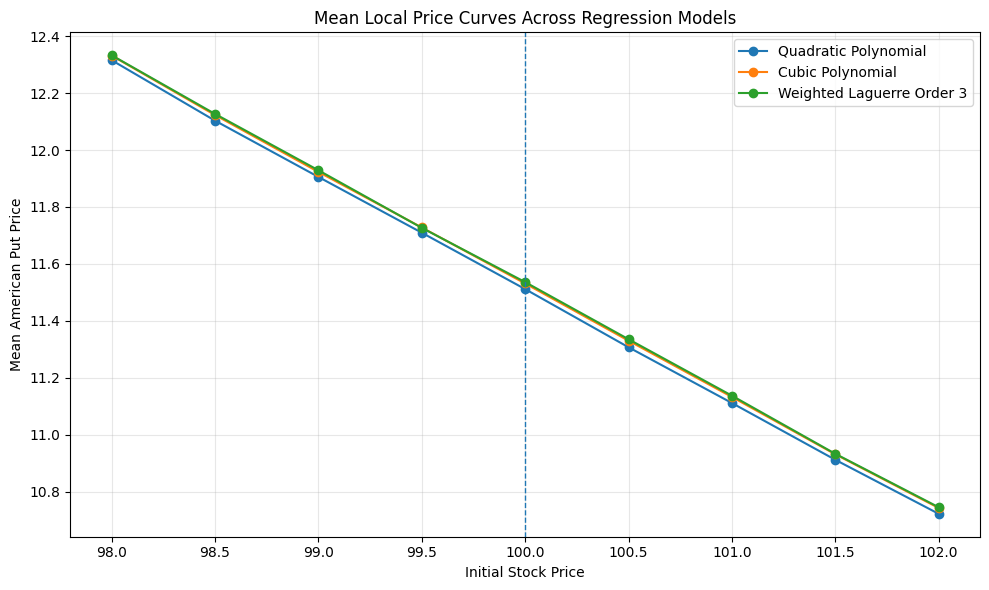

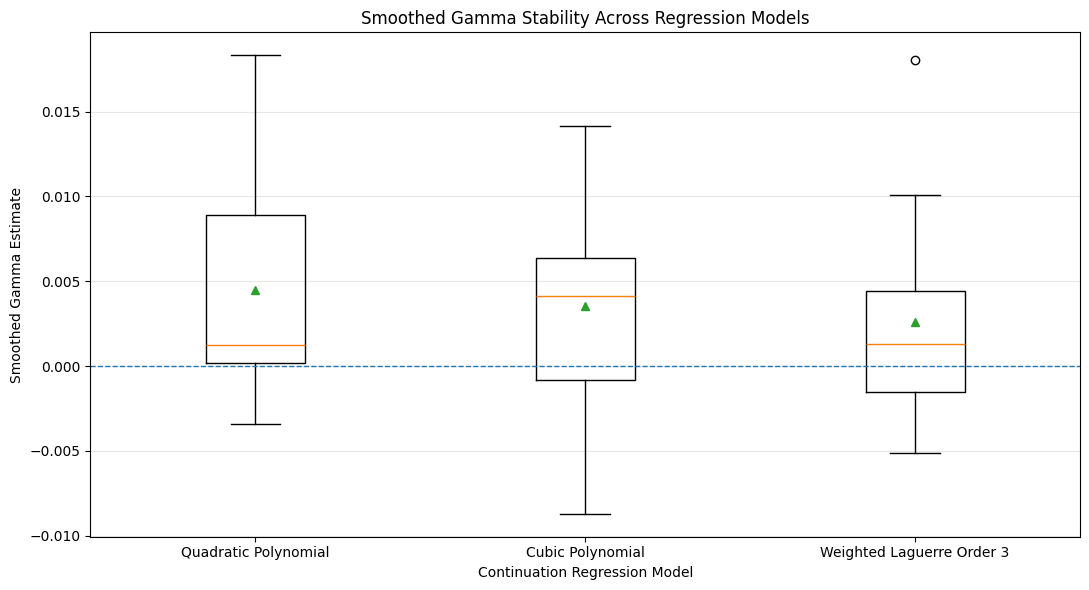

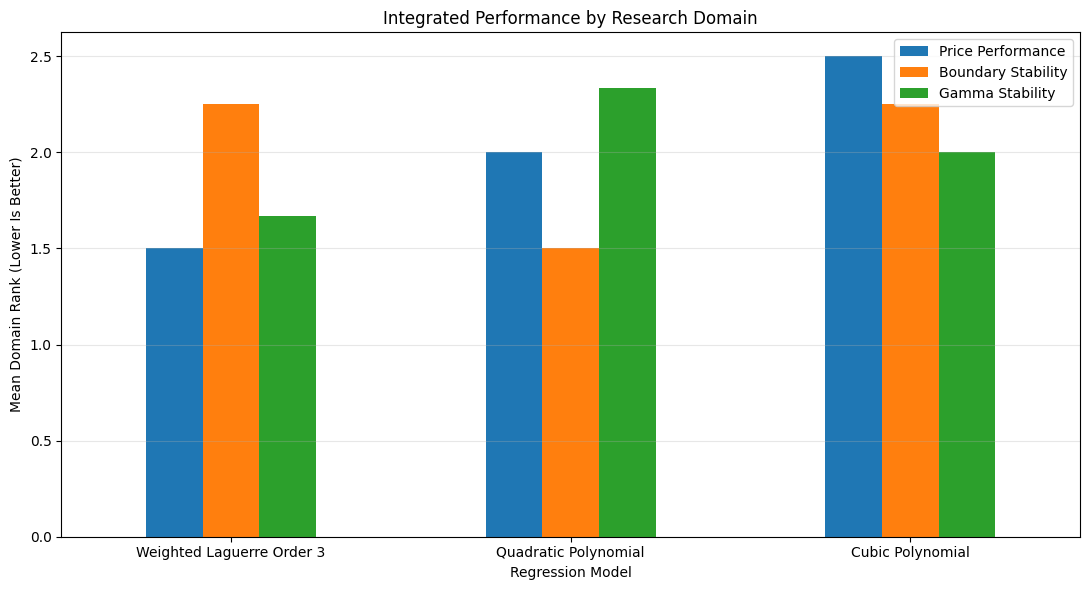

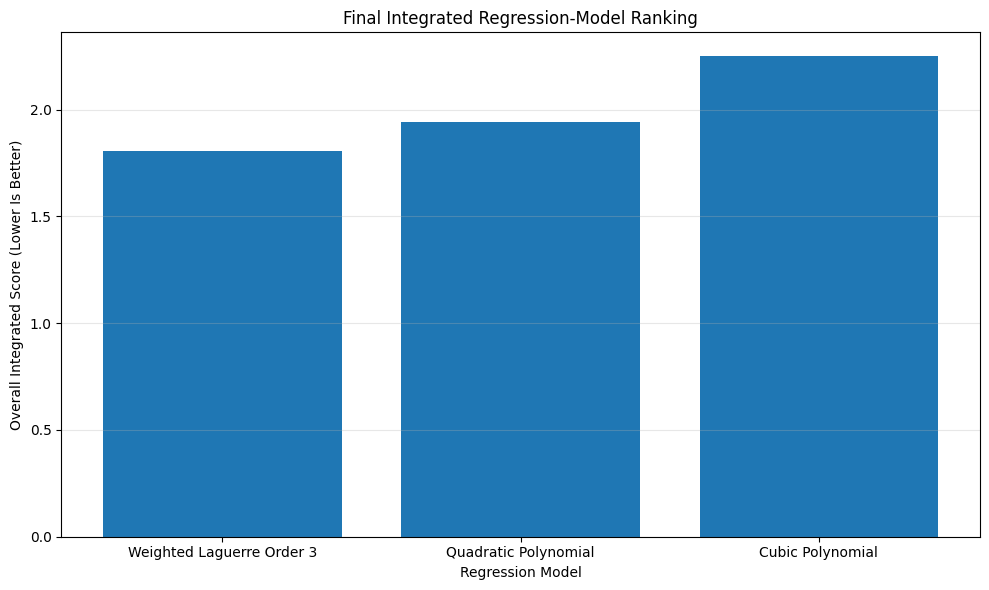

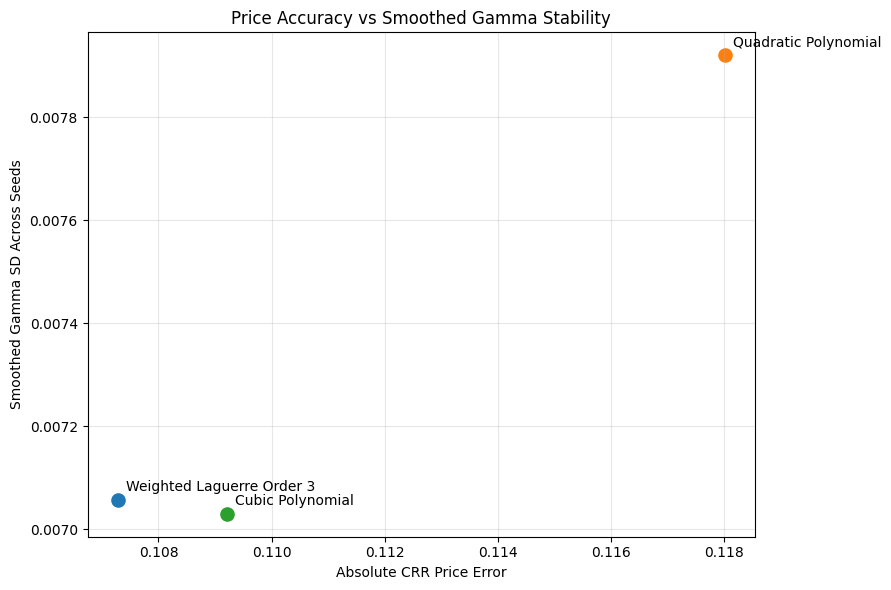

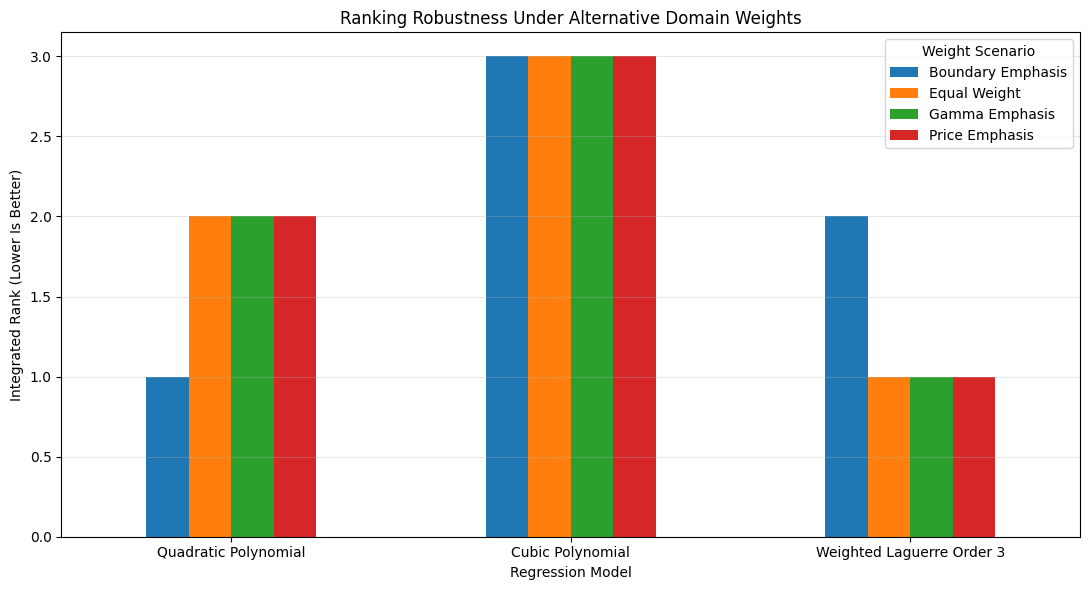

Final Integrated Regression-Model Comparison


,Overall_Integrated_Rank,Regression_Model,Mean_LSM_Price,CRR_Benchmark_Price,Mean_Absolute_Seed_Price_Error_Versus_CRR,Price_SD_Across_Seeds,Mean_Boundary_SD_Across_Time,Mean_Absolute_Adjacent_Change,Mean_Absolute_Curvature,Mean_Missing_Boundaries,...,Gamma_Median_Absolute_Deviation,Negative_Gamma_Percentage,Mean_Fit_RMSE,Mean_R_Squared,Mean_Price_Performance_Rank,Mean_Boundary_Stability_Rank,Mean_Gamma_Stability_Rank,Overall_Integrated_Score,Pareto_Dominated,Number_Of_Models_Dominating
0,1,Weighted Laguerre Order 3,11.536059,11.545709,0.107283,0.131950,3.074734,1.946976,3.050754,10.612245,...,0.003541,40.0,0.008328,0.999708,1.5,2.25,1.666667,1.805556,False,0
1,2,Quadratic Polynomial,11.511453,11.545709,0.118004,0.130404,1.775384,1.035809,1.575943,12.040816,...,0.002665,20.0,0.009135,0.999662,2.0,1.50,2.333333,1.944444,False,0
2,3,Cubic Polynomial,11.531225,11.545709,0.109208,0.132696,3.009699,1.910912,3.068828,11.836735,...,0.004270,30.0,0.007749,0.999726,2.5,2.25,2.000000,2.250000,False,0


Smoothed Gamma Summary


,Regression_Model,Number_Of_Seeds,Mean_Gamma,Median_Gamma,Gamma_SD_Across_Seeds,Gamma_Standard_Error,Gamma_Confidence_Interval_Lower,Gamma_Confidence_Interval_Upper,Gamma_Interquartile_Range,Gamma_Median_Absolute_Deviation,Negative_Gamma_Percentage,Mean_Delta,Mean_Fit_RMSE,Maximum_Fit_RMSE,Mean_R_Squared,Minimum_R_Squared,Mean_Absolute_Base_Fit_Error,Mean_Local_Fit_Condition_Number
0,Cubic Polynomial,10,0.003545,0.004108,0.007030,0.002223,-0.000812,0.007902,0.007201,0.004270,30.0,-0.397216,0.007749,0.013377,0.999726,0.999298,0.006122,3.781129
1,Quadratic Polynomial,10,0.004456,0.001252,0.007920,0.002505,-0.000453,0.009365,0.008698,0.002665,20.0,-0.398147,0.009135,0.014775,0.999662,0.999246,0.005018,3.781129
2,Weighted Laguerre Order 3,10,0.002621,0.001302,0.007057,0.002232,-0.001753,0.006995,0.005922,0.003541,40.0,-0.397104,0.008328,0.012674,0.999708,0.999409,0.006988,3.781129


Weight-Sensitivity Analysis


,Weight_Scenario,Regression_Model,Price_Weight,Boundary_Weight,Gamma_Weight,Weighted_Integrated_Score,Weighted_Integrated_Rank
7,Boundary Emphasis,Quadratic Polynomial,0.250000,0.500000,0.250000,1.833333,1
6,Boundary Emphasis,Weighted Laguerre Order 3,0.250000,0.500000,0.250000,1.916667,2
8,Boundary Emphasis,Cubic Polynomial,0.250000,0.500000,0.250000,2.250000,3
0,Equal Weight,Weighted Laguerre Order 3,0.333333,0.333333,0.333333,1.805556,1
1,Equal Weight,Quadratic Polynomial,0.333333,0.333333,0.333333,1.944444,2
2,Equal Weight,Cubic Polynomial,0.333333,0.333333,0.333333,2.250000,3
9,Gamma Emphasis,Weighted Laguerre Order 3,0.250000,0.250000,0.500000,1.770833,1
10,Gamma Emphasis,Quadratic Polynomial,0.250000,0.250000,0.500000,2.041667,2
11,Gamma Emphasis,Cubic Polynomial,0.250000,0.250000,0.500000,2.187500,3
3,Price Emphasis,Weighted Laguerre Order 3,0.500000,0.250000,0.250000,1.729167,1


Winner Under Each Weight Scenario


,Weight_Scenario,Regression_Model,Price_Weight,Boundary_Weight,Gamma_Weight,Weighted_Integrated_Score,Weighted_Integrated_Rank
0,Boundary Emphasis,Quadratic Polynomial,0.250000,0.500000,0.250000,1.833333,1
1,Equal Weight,Weighted Laguerre Order 3,0.333333,0.333333,0.333333,1.805556,1
2,Gamma Emphasis,Weighted Laguerre Order 3,0.250000,0.250000,0.500000,1.770833,1
3,Price Emphasis,Weighted Laguerre Order 3,0.500000,0.250000,0.250000,1.729167,1



Part 6: Final Integrated Regression-model Comparison

Central research question:
Which continuation-regression model provides the strongest overall balance of price accuracy, exercise-boundary stability, and smoothed-Gamma stability?

Main specification:
Paths: 10000
Exercise intervals: 50
Seeds: 10
Smoothed Gamma estimator: local degree 2, half-width 2.00, grid spacing 0.50
Gamma valuation method: Fixed Regression Policy
CRR benchmark price: 11.545709

Earlier dataframes detected:
Price source: df_part4a_model_summary
Boundary source: df_part4a_model_summary

Validation checks:
All local prices finite: True
All smoothed Gamma estimates finite: True
All three regression models present: True
Fixed-policy base reproduction passed: True
Local-price row count passed: True
Smoothed-Gamma row count passed: True
Integrated scores finite: True

Best overall model under equal domain weights:
Regression model: Weighted Laguerre Order 3
Overall integrated rank: 1
Overall integrated score: 1.8055

In [18]:
#### PART 6 - FINAL INTEGRATED REGRESSION-MODEL COMPARISON ####

# Purpose:
# 1. Extend the Part 5B smoothed-Gamma method to all three continuation regression models:
#       - Quadratic Polynomial
#       - Cubic Polynomial
#       - Weighted Laguerre Order 3
# 2. Compare each model using:
#       - price accuracy relative to the CRR benchmark
#       - exercise-boundary stability from Part 4A
#       - smoothed-Gamma stability
#       - numerical conditioning as secondary diagnostics
# 3. Produce an integrated ranking and weight-sensitivity analysis

# Important:
# - Reuse the Part 3A and Part 3B pricing functions
# - Rerun the local price-curve analysis for all regression models
# - The primary smoothed specification is local degree 2, half-width 2.0
# - Equal weight is assigned to price, boundary, and Gamma performance

### REQUIRED OBJECTS

part6_required_objects = ["S0",
    "K",
    "r",
    "sigma",
    "T",
    "train_fixed_regression_policy",
    "price_with_fixed_regression_policy"]
part6_missing_objects = [name for name in part6_required_objects if name not in globals()]
if part6_missing_objects:
    raise NameError("Part 6 requires the following objects from earlier sections: " + ", ".join(part6_missing_objects))

### SETTINGS

part6_model_specifications = [{ "Regression_Model": "Quadratic Polynomial", "Basis_Type": "Polynomial", "Regression_Order": 2 },
    { "Regression_Model": "Cubic Polynomial", "Basis_Type": "Polynomial", "Regression_Order": 3 },
    { "Regression_Model": "Weighted Laguerre Order 3", "Basis_Type": "Laguerre", "Regression_Order": 3 }]
part6_number_of_paths = (int(greeks_n_paths) if "greeks_n_paths" in globals() else 10000)
part6_number_of_steps = (int(greeks_n_steps) if "greeks_n_steps" in globals() else 50)
part6_seeds = (list(greeks_seeds) if "greeks_seeds" in globals() else list(range(1, 11)))
part6_grid_spacing = 0.50
part6_local_half_width = 2.00
part6_local_degree = 2
part6_stock_offsets = np.arange(-part6_local_half_width, part6_local_half_width + part6_grid_spacing / 2, part6_grid_spacing)
part6_stock_prices = S0 + part6_stock_offsets
part6_crr_benchmark = (float(crr_benchmark_price)
                       
    if "crr_benchmark_price" in globals()
    else (float(CRR_benchmark) if "CRR_benchmark" in globals() else 11.545709))

part6_confidence_multiplier = 1.96
part6_epsilon = 1e-12

if np.any(part6_stock_prices <= 0):
    raise ValueError("The Part 6 local stock-price grid contains a non-positive value.")

### HELPER FUNCTIONS

# Fit a local quadratic around the base stock price
# Delta is the fitted x coefficient and Gamma is twice the fitted x² coefficient
def part6_fit_local_quadratic(stock_offsets, option_prices):

    x = np.asarray(stock_offsets, dtype=float)
    y = np.asarray(option_prices, dtype=float)
    design_matrix = np.polynomial.polynomial.polyvander(x, part6_local_degree)
    coefficients, _, _, _ = np.linalg.lstsq(design_matrix, y, rcond=None)
    fitted_prices = design_matrix @ coefficients
    residuals = y - fitted_prices
    residual_sum_of_squares = float(np.sum(residuals**2))
    total_sum_of_squares = float(np.sum((y - np.mean(y))**2))
    r_squared = (1.0 - residual_sum_of_squares / total_sum_of_squares
        
        if total_sum_of_squares > part6_epsilon
        else np.nan)
    
    return {
        "Fitted_Base_Price": float(coefficients[0]),
        "Delta": float(coefficients[1]),
        "Gamma": float(2.0 * coefficients[2]),
        "Fit_RMSE": float(np.sqrt(np.mean(residuals**2))),
        "Maximum_Absolute_Residual": float(np.max(np.abs(residuals))),
        "R_Squared": float(r_squared),
        "Condition_Number": float(np.linalg.cond(design_matrix))
    }

# Calculate Gamma stability statistics across seeds
def part6_distribution_statistics(values):
    values = pd.to_numeric(pd.Series(values), errors="coerce")
    values = values[np.isfinite(values)]
    number_of_values = len(values)
    if number_of_values == 0:
        return {
            "Number_Of_Seeds": 0,
            "Mean_Gamma": np.nan,
            "Median_Gamma": np.nan,
            "Gamma_SD_Across_Seeds": np.nan,
            "Gamma_Standard_Error": np.nan,
            "Gamma_Confidence_Interval_Lower": np.nan,
            "Gamma_Confidence_Interval_Upper": np.nan,
            "Gamma_Interquartile_Range": np.nan,
            "Gamma_Median_Absolute_Deviation": np.nan,
            "Negative_Gamma_Percentage": np.nan
        }
    mean_gamma = float(values.mean())
    median_gamma = float(values.median())
    gamma_sd = (float(values.std(ddof=1)) if number_of_values > 1 else 0.0)
    gamma_se = (gamma_sd / np.sqrt(number_of_values))
    gamma_iqr = float(values.quantile(0.75) - values.quantile(0.25))
    gamma_mad = float(np.median(np.abs(values - median_gamma)))
    return {
        "Number_Of_Seeds": number_of_values,
        "Mean_Gamma": mean_gamma,
        "Median_Gamma": median_gamma,
        "Gamma_SD_Across_Seeds": gamma_sd,
        "Gamma_Standard_Error": gamma_se,
        "Gamma_Confidence_Interval_Lower": mean_gamma - part6_confidence_multiplier * gamma_se,
        "Gamma_Confidence_Interval_Upper": mean_gamma + part6_confidence_multiplier * gamma_se,
        "Gamma_Interquartile_Range": gamma_iqr,
        "Gamma_Median_Absolute_Deviation": gamma_mad,
        "Negative_Gamma_Percentage": float(100.0 * np.mean(values < 0))
    }

# Use consistent regression-model names
def part6_standardise_model_names(series):
    output = []
    for value in series:
        label = (str(value).strip().lower().replace("_", " ").replace("-", " "))
        if "laguerre" in label:
            output.append("Weighted Laguerre Order 3")
        elif "quadratic" in label or label in { "degree 2", "polynomial 2", "2" }:
            output.append("Quadratic Polynomial")
        elif "cubic" in label or label in { "degree 3", "polynomial 3", "3" }:
            output.append("Cubic Polynomial")
        else:
            output.append(str(value))
    return pd.Series(output, index=series.index)

### RUN THE PRIMARY SMOOTHED-GAMMA ESTIMATOR FOR ALL MODELS

part6_local_price_records = []
part6_smoothed_gamma_records = []
part6_policy_training_records = []

for model_specification in part6_model_specifications:
    regression_model = model_specification["Regression_Model"]
    basis_type = model_specification["Basis_Type"]
    regression_order = model_specification["Regression_Order"]
    for seed in part6_seeds:
        rng = np.random.default_rng(seed)
        random_shocks = rng.standard_normal(size=(part6_number_of_steps, part6_number_of_paths))

        # Train Fixed Policy Once At S0
        training_result = (train_fixed_regression_policy(S0_input=S0, K=K, r=r, sigma_input=sigma, T=T, random_shocks=random_shocks, basis_type=basis_type, regression_order=regression_order))
        coefficients_by_time = (training_result["Coefficients_By_Time"])
        reproduced_base_result = (price_with_fixed_regression_policy(S0_input=S0,
                K=K,
                r=r,
                sigma_input=sigma,
                T=T,
                random_shocks=random_shocks,
                basis_type=basis_type,
                regression_order=regression_order,
                coefficients_by_time=coefficients_by_time))
        
        part6_policy_training_records.append({
            "Regression_Model": regression_model,
            "Basis_Type": basis_type,
            "Regression_Order": regression_order,
            "Seed": seed,
            "Training_Price": training_result["Price"],
            "Reproduced_Base_Price": reproduced_base_result["Price"],
            "Base_Reproduction_Difference": abs(training_result["Price"] - reproduced_base_result["Price"]),
            "Mean_Condition_Number": training_result.get("Mean_Condition_Number", np.nan)
        })
        
# Value The Local Grid Under The Fixed Policy
        local_prices = []
    
        for stock_offset, stock_price in zip(part6_stock_offsets, part6_stock_prices):
            valuation_result = (price_with_fixed_regression_policy(S0_input=float(stock_price),
                    K=K,
                    r=r,
                    sigma_input=sigma,
                    T=T,
                    random_shocks=random_shocks,
                    basis_type=basis_type,
                    regression_order=regression_order,
                    coefficients_by_time=coefficients_by_time))
            
            local_price = float(valuation_result["Price"])
            local_prices.append(local_price)
            
            part6_local_price_records.append({
                "Regression_Model": regression_model,
                "Basis_Type": basis_type,
                "Regression_Order": regression_order,
                "Gamma_Method": "Fixed Regression Policy",
                "Seed": seed,
                "Stock_Offset": float(stock_offset),
                "Stock_Price": float(stock_price),
                "Option_Price": local_price,
                "Early_Exercise_Percentage": valuation_result["Early_Exercise_Percentage"],
                "Discounting_Difference": valuation_result["Discounting_Difference"]
            })
            
        fit_result = part6_fit_local_quadratic(stock_offsets=part6_stock_offsets, option_prices=local_prices)
        observed_base_price = float(local_prices[np.where(np.isclose(part6_stock_offsets, 0.0))[0][0]])
       
        part6_smoothed_gamma_records.append({
                "Estimator_Family": "Smoothed Local Price Curve",
                "Estimator_Name": f"Local Quadratic (Half-Width {part6_local_half_width:.2f})",
                "Regression_Model": regression_model,
                "Basis_Type": basis_type,
                "Regression_Order": regression_order,
                "Gamma_Method": "Fixed Regression Policy",
                "Seed": seed,
                "Local_Polynomial_Degree": part6_local_degree,
                "Local_Half_Width": part6_local_half_width,
                "Grid_Spacing": part6_grid_spacing,
                "Number_Of_Local_Points": len(part6_stock_offsets),
                "Observed_Base_Price": observed_base_price,
                "Fitted_Base_Price": fit_result["Fitted_Base_Price"],
                "Absolute_Base_Fit_Error": abs(fit_result["Fitted_Base_Price"] - observed_base_price),
                "Delta": fit_result["Delta"],
                "Gamma": fit_result["Gamma"],
                "Fit_RMSE": fit_result["Fit_RMSE"],
                "Maximum_Absolute_Residual": fit_result["Maximum_Absolute_Residual"],
                "R_Squared": fit_result["R_Squared"],
                "Local_Fit_Condition_Number": fit_result["Condition_Number"],
                "Gamma_Is_Negative": fit_result["Gamma"] < 0,
                "Gamma_Is_Nonfinite": not np.isfinite(fit_result["Gamma"])
            })
    
df_part6_local_price_curves = pd.DataFrame(part6_local_price_records)
df_part6_smoothed_gamma_seed_results = (pd.DataFrame(part6_smoothed_gamma_records))
df_part6_fixed_policy_training_validation = (pd.DataFrame(part6_policy_training_records))

### SUMMARISE SMOOTHED GAMMA BY REGRESSION MODEL

part6_gamma_summary_rows = []

for regression_model, model_group in (df_part6_smoothed_gamma_seed_results .groupby("Regression_Model")):
    row = { "Regression_Model": regression_model }
    row.update(part6_distribution_statistics(model_group["Gamma"]))
    row["Mean_Delta"] = float(model_group["Delta"].mean())
    row["Mean_Fit_RMSE"] = float(model_group["Fit_RMSE"].mean())
    row["Maximum_Fit_RMSE"] = float(model_group["Fit_RMSE"].max())
    row["Mean_R_Squared"] = float(model_group["R_Squared"].mean())
    row["Minimum_R_Squared"] = float(model_group["R_Squared"].min())
    row["Mean_Absolute_Base_Fit_Error"] = float(model_group["Absolute_Base_Fit_Error"].mean())
    row["Mean_Local_Fit_Condition_Number"] = float(model_group["Local_Fit_Condition_Number"].mean())
    part6_gamma_summary_rows.append(row)
df_part6_gamma_summary = pd.DataFrame(part6_gamma_summary_rows)

### EXTRACT PRICE AND BOUNDARY METRICS DIRECTLY FROM PART 4A

if "df_part4a_model_summary" not in globals():
    raise NameError("Part 6 requires df_part4a_model_summary from Part 4A.")
    
part6_part4a_required_columns = ["Regression_Model",
    "Mean_American_Put_Price",
    "Price_SD_Across_Seeds",
    "Mean_Absolute_Price_Error_Versus_CRR",
    "Mean_Boundary_SD_Across_Time",
    "Mean_Absolute_Adjacent_Change",
    "Mean_Absolute_Curvature",
    "Mean_Missing_Boundary_Percentage",
    "Mean_Condition_Number"]

part6_missing_part4a_columns = [column for column in part6_part4a_required_columns if column not in df_part4a_model_summary.columns]
if part6_missing_part4a_columns:
    raise KeyError("df_part4a_model_summary is missing required Part 6 columns: " + ", ".join(part6_missing_part4a_columns))

part6_reference_models = [specification["Regression_Model"] for specification in part6_model_specifications]
df_part6_part4a_source = df_part4a_model_summary[part6_part4a_required_columns].copy()
df_part6_part4a_source["Regression_Model"] = part6_standardise_model_names(df_part6_part4a_source["Regression_Model"])
df_part6_part4a_source = (df_part6_part4a_source[df_part6_part4a_source["Regression_Model"].isin(part6_reference_models)].drop_duplicates(subset="Regression_Model", keep="first").reset_index(drop=True))

part6_part4a_models_found = set(df_part6_part4a_source["Regression_Model"])
part6_missing_part4a_models = [model_name for model_name in part6_reference_models if model_name not in part6_part4a_models_found]
if part6_missing_part4a_models:
    raise ValueError("df_part4a_model_summary does not contain all required regression models: " + ", ".join(part6_missing_part4a_models))

df_part6_price_summary = (df_part6_part4a_source[["Regression_Model", "Mean_American_Put_Price", "Price_SD_Across_Seeds", "Mean_Absolute_Price_Error_Versus_CRR", "Mean_Condition_Number"]]
    .rename(columns={ "Mean_American_Put_Price": "Mean_LSM_Price", "Mean_Absolute_Price_Error_Versus_CRR": "Mean_Absolute_Seed_Price_Error_Versus_CRR", "Mean_Condition_Number": "Price_Mean_Condition_Number" }))
df_part6_price_summary["CRR_Benchmark_Price"] = part6_crr_benchmark
df_part6_price_summary = df_part6_price_summary[["Regression_Model", "Mean_LSM_Price", "CRR_Benchmark_Price", "Mean_Absolute_Seed_Price_Error_Versus_CRR", "Price_SD_Across_Seeds", "Price_Mean_Condition_Number"]]

df_part6_boundary_summary = (df_part6_part4a_source[["Regression_Model", "Mean_Boundary_SD_Across_Time", "Mean_Absolute_Adjacent_Change", "Mean_Absolute_Curvature", "Mean_Missing_Boundary_Percentage", "Mean_Condition_Number"]]
    .rename(columns={ "Mean_Missing_Boundary_Percentage": "Mean_Missing_Boundaries", "Mean_Condition_Number": "Boundary_Mean_Condition_Number" }))
part6_price_source_name = "df_part4a_model_summary"
part6_boundary_source_name = "df_part4a_model_summary"

### BUILD THE INTEGRATED COMPARISON TABLE

df_part6_integrated_comparison = (pd.DataFrame({ "Regression_Model": part6_reference_models })
    .merge(df_part6_price_summary, on="Regression_Model", how="left", validate="one_to_one")
    .merge(df_part6_boundary_summary, on="Regression_Model", how="left", validate="one_to_one")
    .merge(df_part6_gamma_summary, on="Regression_Model", how="left", validate="one_to_one"))

part6_required_integrated_metrics = ["Mean_Absolute_Seed_Price_Error_Versus_CRR",
    "Price_SD_Across_Seeds",
    "Mean_Boundary_SD_Across_Time",
    "Mean_Absolute_Adjacent_Change",
    "Mean_Absolute_Curvature",
    "Mean_Missing_Boundaries",
    "Gamma_SD_Across_Seeds",
    "Gamma_Interquartile_Range",
    "Gamma_Median_Absolute_Deviation"]

part6_nonfinite_integrated_rows = (df_part6_integrated_comparison[["Regression_Model"] + part6_required_integrated_metrics]
    .loc[~np.isfinite(df_part6_integrated_comparison[part6_required_integrated_metrics].apply(pd.to_numeric, errors="coerce")).all(axis=1)])

if not part6_nonfinite_integrated_rows.empty:
    display(part6_nonfinite_integrated_rows)
    raise ValueError("Part 6 contains missing or nonfinite price, boundary, or Gamma metrics. " "Review the displayed model rows before calculating ranks.")

### DOMAIN-SPECIFIC RANKS

part6_price_metrics = ["Mean_Absolute_Seed_Price_Error_Versus_CRR"]

if ("Price_SD_Across_Seeds" in df_part6_integrated_comparison.columns and df_part6_integrated_comparison["Price_SD_Across_Seeds"].notna().any()):
    part6_price_metrics.append("Price_SD_Across_Seeds")

part6_boundary_metrics = [column
    for column in ["Mean_Boundary_SD_Across_Time", "Mean_Absolute_Adjacent_Change", "Mean_Absolute_Curvature", "Mean_Missing_Boundaries"]
    if (column in df_part6_integrated_comparison.columns and df_part6_integrated_comparison[column].notna().any())]
part6_gamma_metrics = ["Gamma_SD_Across_Seeds", "Gamma_Interquartile_Range", "Gamma_Median_Absolute_Deviation"]

# Rank each complete lower-is-better metric and average the ranks
def part6_add_metric_ranks(dataframe, metric_columns, output_column):
    unavailable_metrics = [metric_column
        for metric_column in metric_columns
        if (metric_column not in dataframe.columns or not np.isfinite(pd.to_numeric(dataframe[metric_column], errors="coerce")).all())]
   
    if unavailable_metrics:
        raise ValueError(f"Cannot calculate {output_column}; missing or nonfinite metrics: " + ", ".join(unavailable_metrics))
    
    rank_columns = []
    for metric_column in metric_columns:
        rank_column = metric_column + "_Rank"
        dataframe[rank_column] = dataframe[metric_column].rank(method="average", ascending=True)
        rank_columns.append(rank_column)
    dataframe[output_column] = dataframe[rank_columns].mean(axis=1)
    
    if not np.isfinite(dataframe[output_column]).all():
        raise ValueError(f"{output_column} contains a nonfinite value after ranking.")
    return rank_columns

part6_price_rank_columns = (part6_add_metric_ranks(dataframe= df_part6_integrated_comparison, metric_columns= part6_price_metrics, output_column= "Mean_Price_Performance_Rank"))
part6_boundary_rank_columns = (part6_add_metric_ranks(dataframe= df_part6_integrated_comparison, metric_columns= part6_boundary_metrics, output_column= "Mean_Boundary_Stability_Rank"))
part6_gamma_rank_columns = (part6_add_metric_ranks(dataframe= df_part6_integrated_comparison, metric_columns= part6_gamma_metrics, output_column= "Mean_Gamma_Stability_Rank"))

### OVERALL INTEGRATED RANK

part6_domain_rank_columns = ["Mean_Price_Performance_Rank", "Mean_Boundary_Stability_Rank", "Mean_Gamma_Stability_Rank"]
if not np.isfinite(df_part6_integrated_comparison[part6_domain_rank_columns]).all().all():
    raise ValueError("At least one Part 6 domain rank is missing or nonfinite.")

df_part6_integrated_comparison["Overall_Integrated_Score"] = (df_part6_integrated_comparison[part6_domain_rank_columns].mean(axis=1))
df_part6_integrated_comparison = (df_part6_integrated_comparison
    .sort_values(["Overall_Integrated_Score", "Mean_Price_Performance_Rank", "Mean_Boundary_Stability_Rank", "Mean_Gamma_Stability_Rank"])
    .reset_index(drop=True))
df_part6_integrated_comparison["Overall_Integrated_Rank"] = np.arange(1, len(df_part6_integrated_comparison) + 1)

### WEIGHT-SENSITIVITY ANALYSIS

part6_weight_scenarios = {
    "Equal Weight": { "Price": 1 / 3, "Boundary": 1 / 3, "Gamma": 1 / 3 },
    "Price Emphasis": { "Price": 0.50, "Boundary": 0.25, "Gamma": 0.25 },
    "Boundary Emphasis": { "Price": 0.25, "Boundary": 0.50, "Gamma": 0.25 },
    "Gamma Emphasis": { "Price": 0.25, "Boundary": 0.25, "Gamma": 0.50 }
}

part6_weight_records = []

for scenario_name, weights in (part6_weight_scenarios.items()):
    scenario_scores = (weights["Price"] * df_part6_integrated_comparison["Mean_Price_Performance_Rank"]
        + weights["Boundary"] * df_part6_integrated_comparison["Mean_Boundary_Stability_Rank"]
        + weights["Gamma"] * df_part6_integrated_comparison["Mean_Gamma_Stability_Rank"])
    scenario_ranks = scenario_scores.rank(method="min", ascending=True)
    
    for row_index, model_name in enumerate(df_part6_integrated_comparison["Regression_Model"]):
        weighted_score = scenario_scores.iloc[row_index]
        weighted_rank = scenario_ranks.iloc[row_index]
        if not np.isfinite(weighted_score) or not np.isfinite(weighted_rank):
            raise ValueError(f"Nonfinite weighted score or rank for {model_name} under {scenario_name}.")
            
        part6_weight_records.append({
            "Weight_Scenario": scenario_name,
            "Regression_Model": model_name,
            "Price_Weight": weights["Price"],
            "Boundary_Weight": weights["Boundary"],
            "Gamma_Weight": weights["Gamma"],
            "Weighted_Integrated_Score": float(weighted_score),
            "Weighted_Integrated_Rank": int(weighted_rank)
        })
df_part6_weight_sensitivity = pd.DataFrame(part6_weight_records)
df_part6_weight_winners = (df_part6_weight_sensitivity[df_part6_weight_sensitivity["Weighted_Integrated_Rank"] == 1].sort_values(["Weight_Scenario", "Weighted_Integrated_Score"]).reset_index(drop=True))

### PARETO-DOMINANCE CHECK

part6_pareto_metrics = ["Mean_Absolute_Seed_Price_Error_Versus_CRR", "Mean_Boundary_SD_Across_Time", "Gamma_SD_Across_Seeds"]
part6_pareto_metrics = [metric
    for metric in part6_pareto_metrics
    if (metric in df_part6_integrated_comparison.columns and df_part6_integrated_comparison[metric].notna().all())]

df_part6_integrated_comparison["Number_Of_Models_Dominating"] = 0
df_part6_integrated_comparison["Pareto_Dominated"] = False

if len(part6_pareto_metrics) >= 2:
    for current_index, current_row in (df_part6_integrated_comparison .iterrows()):
        number_dominating = 0
        for comparison_index, comparison_row in (df_part6_integrated_comparison .iterrows()):
            if current_index == comparison_index:
                continue
                
            no_worse_on_all = all(comparison_row[metric] <= current_row[metric] + part6_epsilon
                for metric in part6_pareto_metrics)
            better_on_at_least_one = any(comparison_row[metric] < current_row[metric]- part6_epsilon
                for metric in part6_pareto_metrics)
            if (no_worse_on_all and better_on_at_least_one):
                number_dominating += 1
                
        df_part6_integrated_comparison.loc[current_index, "Number_Of_Models_Dominating"] = number_dominating
        df_part6_integrated_comparison.loc[current_index, "Pareto_Dominated"] = number_dominating > 0
        
### VALIDATION CHECKS

part6_all_prices_finite = bool(np.isfinite(df_part6_local_price_curves["Option_Price"]).all())
part6_all_gamma_finite = bool(np.isfinite(df_part6_smoothed_gamma_seed_results["Gamma"]).all())
part6_all_models_present = (set(part6_reference_models) == set(df_part6_integrated_comparison["Regression_Model"]))
part6_base_reproduction_passed = bool((df_part6_fixed_policy_training_validation["Base_Reproduction_Difference"] <= 1e-10).all())
part6_expected_local_price_rows = (len(part6_model_specifications) * len(part6_seeds) * len(part6_stock_offsets))
part6_local_price_row_count_passed = (len(df_part6_local_price_curves) == part6_expected_local_price_rows)
part6_expected_gamma_rows = (len(part6_model_specifications) * len(part6_seeds))
part6_gamma_row_count_passed = (len(df_part6_smoothed_gamma_seed_results) == part6_expected_gamma_rows)
part6_integrated_scores_finite = bool(np.isfinite(df_part6_integrated_comparison["Overall_Integrated_Score"]).all())

### DISPLAY VISUAL

# Plot Mean Local Price Curves By Regression Model
df_part6_mean_local_price_curve = (df_part6_local_price_curves
    .groupby(["Regression_Model", "Stock_Offset", "Stock_Price"], as_index=False)
    .agg(Mean_Option_Price=("Option_Price", "mean"), Option_Price_SD=("Option_Price", "std")))

plt.figure(figsize=(10, 6))
for model_name in part6_reference_models:
    model_curve = (df_part6_mean_local_price_curve[df_part6_mean_local_price_curve["Regression_Model"] == model_name].sort_values("Stock_Price"))
    plt.plot(model_curve["Stock_Price"], model_curve["Mean_Option_Price"], marker="o", label=model_name)
plt.axvline(S0, linestyle="--", linewidth=1)
plt.xlabel("Initial Stock Price")
plt.ylabel("Mean American Put Price")
plt.title("Mean Local Price Curves Across Regression Models")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Plot Smoothed Gamma Distributions
part6_gamma_boxplot_values = [df_part6_smoothed_gamma_seed_results.loc[df_part6_smoothed_gamma_seed_results["Regression_Model"] == model_name, "Gamma"].to_numpy()
    for model_name in part6_reference_models]

plt.figure(figsize=(11, 6))
plt.boxplot(part6_gamma_boxplot_values, tick_labels=part6_reference_models, showmeans=True)
plt.axhline(0.0, linestyle="--", linewidth=1)
plt.ylabel("Smoothed Gamma Estimate")
plt.xlabel("Continuation Regression Model")
plt.title("Smoothed Gamma Stability Across Regression Models")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Plot Domain-Specific Ranks
part6_domain_rank_plot = (df_part6_integrated_comparison[[
    "Regression_Model",
    "Mean_Price_Performance_Rank",
    "Mean_Boundary_Stability_Rank",
    "Mean_Gamma_Stability_Rank"
]].set_index("Regression_Model").rename(columns={
    "Mean_Price_Performance_Rank": "Price Performance",
    "Mean_Boundary_Stability_Rank": "Boundary Stability",
    "Mean_Gamma_Stability_Rank": "Gamma Stability"
}))

part6_domain_rank_plot.plot(kind="bar", figsize=(11, 6))
plt.ylabel("Mean Domain Rank (Lower Is Better)")
plt.xlabel("Regression Model")
plt.title("Integrated Performance by Research Domain")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Plot Overall Integrated Score
part6_overall_plot = (df_part6_integrated_comparison .sort_values("Overall_Integrated_Score"))

plt.figure(figsize=(10, 6))
plt.bar(part6_overall_plot["Regression_Model"], part6_overall_plot["Overall_Integrated_Score"])
plt.ylabel("Overall Integrated Score (Lower Is Better)")
plt.xlabel("Regression Model")
plt.title("Final Integrated Regression-Model Ranking")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Plot Price Error Vs Gamma Sd
plt.figure(figsize=(9, 6))
for _, row in (df_part6_integrated_comparison.iterrows()):
    plt.scatter(row["Mean_Absolute_Seed_Price_Error_Versus_CRR"], row["Gamma_SD_Across_Seeds"], s=90)
    plt.annotate(row["Regression_Model"], (row["Mean_Absolute_Seed_Price_Error_Versus_CRR"], row["Gamma_SD_Across_Seeds"]),
        xytext=(6, 6),
        textcoords="offset points")
plt.xlabel("Absolute CRR Price Error")
plt.ylabel("Smoothed Gamma SD Across Seeds")
plt.title("Price Accuracy vs Smoothed Gamma Stability")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Plot Weight-Sensitivity Ranks
part6_weight_pivot = (df_part6_weight_sensitivity
    .pivot(index="Regression_Model", columns="Weight_Scenario", values="Weighted_Integrated_Rank").reindex(part6_reference_models))
part6_weight_pivot.columns = part6_weight_pivot.columns.str.replace("_", " ")

ax = part6_weight_pivot.plot(kind="bar", figsize=(11, 6))
ax.set_ylabel("Integrated Rank (Lower Is Better)")
ax.set_xlabel("Regression Model")
ax.set_title("Ranking Robustness Under Alternative Domain Weights")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title="Weight Scenario")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

part6_final_columns = ["Overall_Integrated_Rank",
    "Regression_Model",
    "Mean_LSM_Price",
    "CRR_Benchmark_Price",
    "Mean_Absolute_Seed_Price_Error_Versus_CRR",
    "Price_SD_Across_Seeds",
    "Mean_Boundary_SD_Across_Time",
    "Mean_Absolute_Adjacent_Change",
    "Mean_Absolute_Curvature",
    "Mean_Missing_Boundaries",
    "Mean_Gamma",
    "Gamma_SD_Across_Seeds",
    "Gamma_Interquartile_Range",
    "Gamma_Median_Absolute_Deviation",
    "Negative_Gamma_Percentage",
    "Mean_Fit_RMSE",
    "Mean_R_Squared",
    "Mean_Price_Performance_Rank",
    "Mean_Boundary_Stability_Rank",
    "Mean_Gamma_Stability_Rank",
    "Overall_Integrated_Score",
    "Pareto_Dominated",
    "Number_Of_Models_Dominating"]
part6_final_columns = [column for column in part6_final_columns if column in df_part6_integrated_comparison.columns]

print("Final Integrated Regression-Model Comparison")
display(df_part6_integrated_comparison[part6_final_columns].round(8))
print("Smoothed Gamma Summary")
display(df_part6_gamma_summary.round(8))
print("Weight-Sensitivity Analysis")
display(df_part6_weight_sensitivity
    .sort_values(["Weight_Scenario", "Weighted_Integrated_Rank", "Weighted_Integrated_Score"])
    .round(8))
print("Winner Under Each Weight Scenario")
display(df_part6_weight_winners.round(8))

### EXPORT RESULTS

df_part6_local_price_curves.to_csv("part6_local_price_curves_all_models.csv", index=False)
df_part6_smoothed_gamma_seed_results.to_csv("part6_smoothed_gamma_seed_results_all_models.csv", index=False)
df_part6_fixed_policy_training_validation.to_csv("part6_fixed_policy_training_validation.csv", index=False)
df_part6_gamma_summary.to_csv("part6_smoothed_gamma_summary_all_models.csv", index=False)
df_part6_price_summary.to_csv("part6_price_accuracy_summary.csv", index=False)
df_part6_boundary_summary.to_csv("part6_boundary_stability_summary.csv", index=False)
df_part6_integrated_comparison.to_csv("part6_integrated_regression_model_comparison.csv", index=False)
df_part6_weight_sensitivity.to_csv("part6_weight_sensitivity_analysis.csv", index=False)
df_part6_weight_winners.to_csv("part6_weight_scenario_winners.csv", index=False)
df_part6_mean_local_price_curve.to_csv("part6_mean_local_price_curves.csv", index=False)

# Part 6 Summary

part6_best_row = (df_part6_integrated_comparison.sort_values("Overall_Integrated_Rank").iloc[0])

print("\nPart 6: Final Integrated Regression-model Comparison")

print("\nCentral research question:")
print("Which continuation-regression model provides the strongest overall balance of price accuracy, exercise-boundary stability, and smoothed-Gamma stability?")

print("\nMain specification:")
print("Paths:", part6_number_of_paths)
print("Exercise intervals:", part6_number_of_steps)
print("Seeds:", len(part6_seeds))
print("Smoothed Gamma estimator:", f"local degree {part6_local_degree}, half-width {part6_local_half_width:.2f}, grid spacing {part6_grid_spacing:.2f}")
print("Gamma valuation method:", "Fixed Regression Policy")
print("CRR benchmark price:", round(part6_crr_benchmark, 8))
print("\nEarlier dataframes detected:")
print("Price source:", part6_price_source_name)
print("Boundary source:", part6_boundary_source_name)

print("\nValidation checks:")
print("All local prices finite:", part6_all_prices_finite)
print("All smoothed Gamma estimates finite:", part6_all_gamma_finite)
print("All three regression models present:", part6_all_models_present)
print("Fixed-policy base reproduction passed:", part6_base_reproduction_passed)
print("Local-price row count passed:", part6_local_price_row_count_passed)
print("Smoothed-Gamma row count passed:", part6_gamma_row_count_passed)
print("Integrated scores finite:", part6_integrated_scores_finite)

print("\nBest overall model under equal domain weights:")
print("Regression model:", part6_best_row["Regression_Model"])
print("Overall integrated rank:", int(part6_best_row["Overall_Integrated_Rank"]))
print("Overall integrated score:", round(part6_best_row["Overall_Integrated_Score"], 8))
print("Price-performance rank:", round(part6_best_row["Mean_Price_Performance_Rank"], 4))
print("Boundary-stability rank:", round(part6_best_row["Mean_Boundary_Stability_Rank"], 4))
print("Gamma-stability rank:",round(part6_best_row["Mean_Gamma_Stability_Rank"], 4))
print("Pareto dominated:", bool(part6_best_row["Pareto_Dominated"]))

print("\nWeight-scenario winners:")
for scenario_name, group in (df_part6_weight_winners.groupby("Weight_Scenario")):
    winners = ", ".join(group["Regression_Model"].astype(str))
    print("-", scenario_name, ":", winners)
    
print("\nInterpretation guide:")
print("- Price performance is measured mainly by absolute error relative to the CRR benchmark.")
print("- Boundary stability is measured using variation, roughness, curvature, and missing boundary values.")
print("- Gamma stability is measured using the same smoothed local quadratic method for every regression model.")
print("- The fixed regression policy is used to remove variation caused by repeated regression refitting.")
print("- Gamma stability is ranked using standard deviation, interquartile range, and median absolute deviation.")
print("- The main overall score gives equal weight to price, boundary, and Gamma performance.")
print("- Alternative weights test whether the model ranking changes when different areas are given more importance.")
print("- The highest-ranked model provides the best overall balance across price, boundary, and Gamma performance in this analysis.")

## Part 7 - Multi-Asset Longstaff–Schwartz with Correlated Assets

Correlation Results


,Correlation,Mean_American_Put_Price,Mean_Raw_LSM_Price,Price_SD_Across_Seeds,Price_Standard_Error,Confidence_Interval_Lower,Confidence_Interval_Upper,Mean_Hold_To_Maturity_Price,Mean_LSM_Policy_Improvement_Over_Hold,Hold_Policy_Selected_Percentage,Mean_Early_Exercise_Percentage,Mean_Realised_Shock_Correlation,Maximum_Absolute_Correlation_Error,Maximum_Discounting_Difference,Mean_Condition_Number,Maximum_Condition_Number
0,-0.75,21.658539,21.658539,0.080091,0.025327,21.608899,21.708180,20.946446,0.712094,0.0,61.454,-0.749933,0.001040,0.0,1302.627614,13267.909732
1,-0.50,20.779639,20.779639,0.102649,0.032460,20.716017,20.843262,20.122131,0.657509,0.0,56.411,-0.499848,0.001580,0.0,798.116208,7821.872293
2,0.00,18.904052,18.904052,0.145039,0.045865,18.814156,18.993948,18.311106,0.592946,0.0,49.854,0.000236,0.002273,0.0,564.246914,5447.649893
3,0.50,16.560217,16.560217,0.147070,0.046508,16.469063,16.651372,16.043740,0.516477,0.0,46.206,0.500154,0.002035,0.0,564.667084,5571.051301
4,0.75,15.009297,15.009297,0.169168,0.053496,14.904445,15.114148,14.507915,0.501382,0.0,44.647,0.750069,0.001290,0.0,910.728448,10023.552988


Path-Count Convergence


,Number_Of_Paths,Mean_American_Put_Price,Mean_Raw_LSM_Price,Price_SD_Across_Seeds,Mean_Hold_To_Maturity_Price,Hold_Policy_Selected_Percentage,Mean_Early_Exercise_Percentage,Maximum_Discounting_Difference,Price_Standard_Error,Confidence_Interval_Lower,Confidence_Interval_Upper
0,2500,16.595563,16.595563,0.293833,15.942095,0.0,48.576,0.0,0.092918,16.413443,16.777682
1,5000,16.593511,16.593511,0.214224,15.979204,0.0,48.882,0.0,0.067743,16.460734,16.726288
2,10000,16.638745,16.638745,0.192449,16.084153,0.0,47.056,0.0,0.060858,16.519464,16.758026
3,20000,16.640452,16.640452,0.109061,16.107291,0.0,47.067,0.0,0.034488,16.572856,16.708049


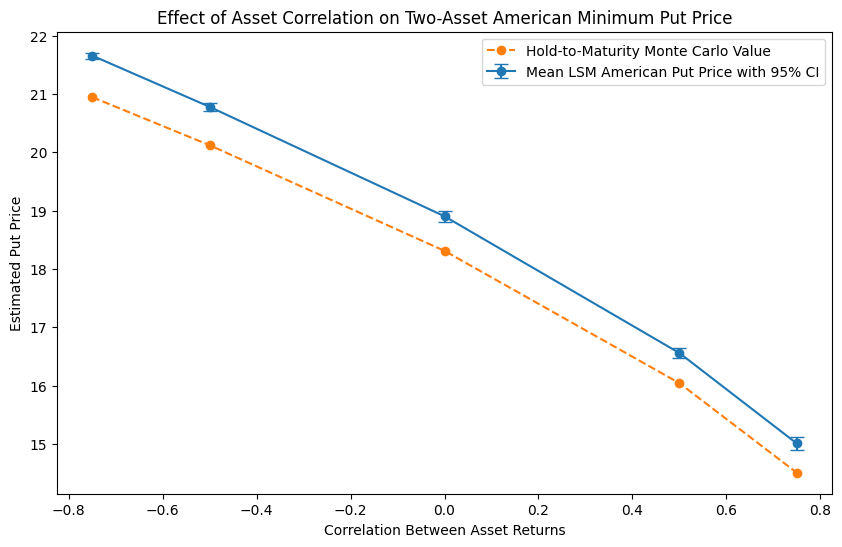

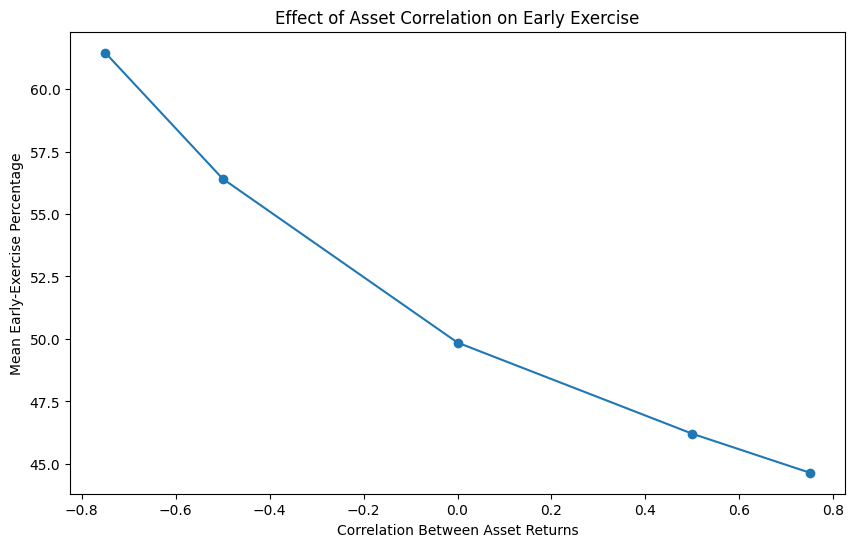

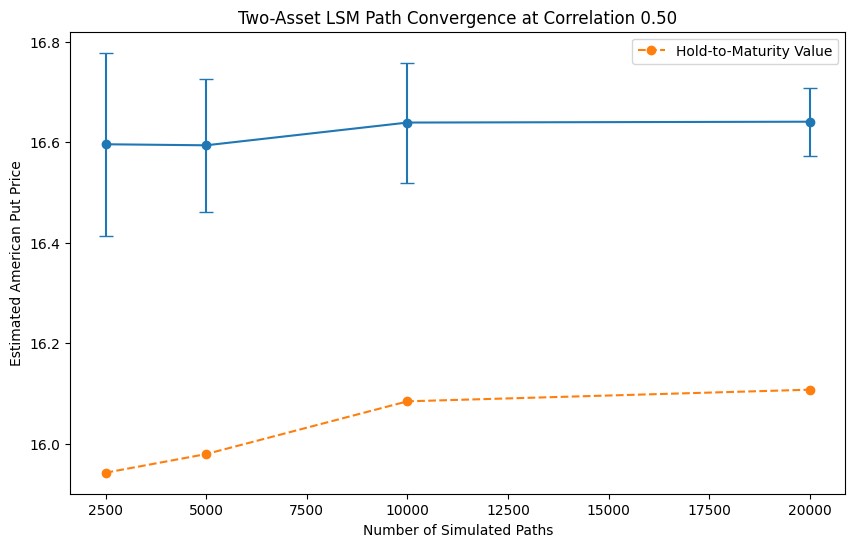

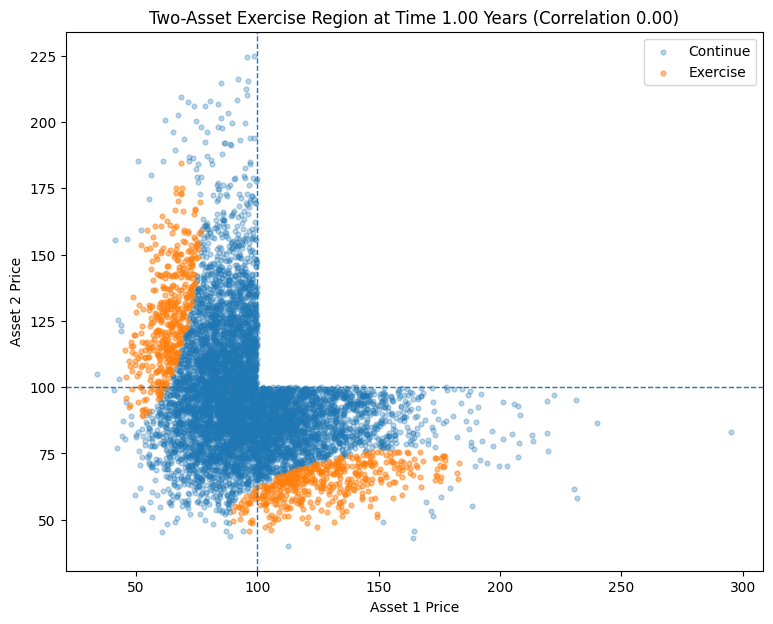


Part 7: Multi-Asset Longstaff-Schwartz With Correlated Underlying Assets

Research question:
How does correlation between two assets affect the value and exercise behaviour of an American put written on the minimum of the two assets?

Main specification:
Initial Asset 1 price: 100.0
Initial Asset 2 price: 100.0
Asset 1 volatility: 0.25
Asset 2 volatility: 0.25
Strike price: 100
Risk-free rate: 0.03
Maturity in years: 2
Number of paths: 10000
Number of exercise intervals: 50
Random seeds: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Correlations tested: [-0.75, -0.5, 0.0, 0.5, 0.75]
Regression basis: Symmetric Bivariate Quadratic Polynomial
Regression state variables: min(S1, S2) and max(S1, S2)
Payoff: max(K - min(S1, S2), 0)

Why Monte Carlo is used:
- The option value depends jointly on two correlated state variables.
- A one-dimensional CRR benchmark is therefore no longer directly applicable.
- Monte Carlo simulates both correlated asset paths directly and Longstaff-Schwartz estimates the mult

In [19]:
#### PART 7A - MULTI-ASSET EXTENSION: LONGSTAFF-SCHWARTZ WITH CORRELATED UNDERLYING ASSETS ####

# Goal:
# 1. Extend Longstaff-Schwartz from one asset to two correlated assets
# 2. Price an American put written on the minimum of the two asset prices
# 3. Investigate how asset correlation affects option value and early-exercise behaviour
# 4. Use Monte Carlo convergence and internal validation because a simple CRR benchmark is no longer available
# 5. Use a symmetric continuation-value regression that reflects the structure of the minimum-of-two-assets payoff
# 6. Visualise how the one-dimensional exercise boundary becomes a two-dimensional exercise region

# Important:
# - Both assets use the same initial price and volatility as the single-asset experiment
# - Number of paths remains 10,000 and number of exercise intervals remains 50 for the main correlation experiment
# - Random seeds remain 1 to 10
# - The same independent normal shocks are reused across correlation values within each seed
# - Payoff = max(K - min(S1, S2), 0)
# - Continuation regression uses min(S1, S2) and max(S1, S2), preserving symmetry between the two identical assets
# - The hold-to-maturity policy is retained as an admissible fallback if it outperforms the fitted stopping policy
# - No CRR benchmark is imposed because the state space is now two-dimensional

### REQUIRED OBJECTS

part7_required_objects = ["S0", "K", "r", "sigma", "T"]
part7_missing_objects = [name for name in part7_required_objects if name not in globals()]
if part7_missing_objects:
    raise NameError("Part 7 requires the following objects from earlier sections: " + ", ".join(part7_missing_objects))

### SETTINGS

part7_number_of_paths = 10000
part7_number_of_steps = 50
part7_seeds = list(range(1, 11))
part7_correlations = [-0.75, -0.50, 0.00, 0.50, 0.75]

part7_S1_0 = float(S0)
part7_S2_0 = float(S0)
part7_sigma_1 = float(sigma)
part7_sigma_2 = float(sigma)

# Path-count convergence using a correlation of 0.50
part7_path_counts = [2500, 5000, 10000, 20000]
part7_path_convergence_correlation = 0.50
part7_maximum_path_count = max(part7_path_counts)

# Exercise-region plot using zero correlation and seed 1
part7_exercise_region_correlation = 0.00
part7_exercise_region_seed = 1
part7_exercise_region_time_index = part7_number_of_steps // 2

### SIMULATE TWO CORRELATED ASSETS

# Simulate two risk-neutral GBM asset-price paths using correlated random shocks
# Create the second correlated shock using Z2_corr = rho*Z1 + sqrt(1-rho²)*Z2
def simulate_two_correlated_gbm_paths(S1_0, S2_0, r, sigma_1, sigma_2, T, rho, shocks_1, shocks_2):
    if not -1 <= rho <= 1:
        raise ValueError("rho must lie between -1 and 1.")
    if shocks_1.shape != shocks_2.shape:
        raise ValueError("shocks_1 and shocks_2 must have the same shape.")

    number_of_steps, number_of_paths = shocks_1.shape
    dt = T / number_of_steps
    correlated_shocks_2 = rho * shocks_1 + np.sqrt(1 - rho**2) * shocks_2

    paths_1 = np.zeros((number_of_paths, number_of_steps + 1))
    paths_2 = np.zeros((number_of_paths, number_of_steps + 1))
    paths_1[:, 0] = S1_0
    paths_2[:, 0] = S2_0

    for t in range(1, number_of_steps + 1):
        paths_1[:, t] = paths_1[:, t - 1] * np.exp(
            (r - 0.5 * sigma_1**2) * dt + sigma_1 * np.sqrt(dt) * shocks_1[t - 1]
        )
        paths_2[:, t] = paths_2[:, t - 1] * np.exp(
            (r - 0.5 * sigma_2**2) * dt + sigma_2 * np.sqrt(dt) * correlated_shocks_2[t - 1]
        )

    return paths_1, paths_2, correlated_shocks_2

### SYMMETRIC BIVARIATE QUADRATIC REGRESSION

# The option value is unchanged if the two assets are swapped
# Use the minimum and maximum scaled asset prices to create a symmetric quadratic basis
# Basis = [1, m, M, m², mM, M²]
def create_part7_symmetric_quadratic_matrix(stock_prices_1, stock_prices_2, K):
    minimum_scaled = np.minimum(stock_prices_1, stock_prices_2) / K
    maximum_scaled = np.maximum(stock_prices_1, stock_prices_2) / K

    return np.column_stack([
        np.ones(len(minimum_scaled)),
        minimum_scaled,
        maximum_scaled,
        minimum_scaled**2,
        minimum_scaled * maximum_scaled,
        maximum_scaled**2
    ])

### MULTI-ASSET LONGSTAFF-SCHWARTZ FUNCTION

# Price an American put on the minimum of two correlated assets
def price_two_asset_minimum_put_lsm(paths_1, paths_2, K, r, T, exercise_region_time_index=None):
    if paths_1.shape != paths_2.shape:
        raise ValueError("paths_1 and paths_2 must have the same shape.")

    number_of_paths = paths_1.shape[0]
    number_of_steps = paths_1.shape[1] - 1
    dt = T / number_of_steps
    one_step_discount_factor = np.exp(-r * dt)

    minimum_prices_at_expiry = np.minimum(paths_1[:, -1], paths_2[:, -1])
    terminal_payoffs = np.maximum(K - minimum_prices_at_expiry, 0)

    # LSM stopping-policy cash flows
    cashflows = terminal_payoffs.copy()
    exercise_time = np.full(number_of_paths, number_of_steps, dtype=int)
    exercise_asset_1 = paths_1[:, -1].copy()
    exercise_asset_2 = paths_2[:, -1].copy()

    condition_numbers = []
    exercise_region_data = None

    for t in range(number_of_steps - 1, 0, -1):
        current_asset_1 = paths_1[:, t]
        current_asset_2 = paths_2[:, t]
        current_minimum = np.minimum(current_asset_1, current_asset_2)

        immediate_exercise_values = np.maximum(K - current_minimum, 0)
        discounted_cashflows = cashflows * one_step_discount_factor
        in_the_money = immediate_exercise_values > 0

        if np.sum(in_the_money) == 0:
            cashflows = discounted_cashflows
            continue

        asset_1_itm = current_asset_1[in_the_money]
        asset_2_itm = current_asset_2[in_the_money]
        exercise_values_itm = immediate_exercise_values[in_the_money]
        continuation_targets_itm = discounted_cashflows[in_the_money]

        # Symmetric quadratic continuation-value regression
        regression_matrix = create_part7_symmetric_quadratic_matrix(
            stock_prices_1=asset_1_itm,
            stock_prices_2=asset_2_itm,
            K=K
        )
        regression_coefficients, *_ = np.linalg.lstsq(
            regression_matrix, continuation_targets_itm, rcond=None
        )
        estimated_continuation_values = regression_matrix @ regression_coefficients
        condition_numbers.append(np.linalg.cond(regression_matrix))

        exercise_now_itm = exercise_values_itm > estimated_continuation_values
        itm_indices = np.where(in_the_money)[0]
        exercise_indices = itm_indices[exercise_now_itm]

        cashflows = discounted_cashflows.copy()
        cashflows[exercise_indices] = immediate_exercise_values[exercise_indices]
        exercise_time[exercise_indices] = t
        exercise_asset_1[exercise_indices] = current_asset_1[exercise_indices]
        exercise_asset_2[exercise_indices] = current_asset_2[exercise_indices]

        # Store the exercise-region data for the selected exercise date
        if exercise_region_time_index is not None and t == exercise_region_time_index:
            exercise_region_data = pd.DataFrame({
                "Asset_1_Price": asset_1_itm,
                "Asset_2_Price": asset_2_itm,
                "Minimum_Asset_Price": np.minimum(asset_1_itm, asset_2_itm),
                "Maximum_Asset_Price": np.maximum(asset_1_itm, asset_2_itm),
                "Immediate_Exercise_Value": exercise_values_itm,
                "Estimated_Continuation_Value": estimated_continuation_values,
                "Decision": np.where(exercise_now_itm, "Exercise", "Continue")
            })

    ### PRICE THE FITTED LSM STOPPING POLICY

    lsm_continuation_value_time_0 = np.mean(cashflows) * one_step_discount_factor
    immediate_exercise_value_time_0 = max(K - min(paths_1[0, 0], paths_2[0, 0]), 0)
    raw_lsm_price = max(immediate_exercise_value_time_0, lsm_continuation_value_time_0)

    # Independent reconstruction of the same LSM stopping-policy value
    minimum_at_exercise = np.minimum(exercise_asset_1, exercise_asset_2)
    cashflow_at_exercise = np.maximum(K - minimum_at_exercise, 0)
    present_values = cashflow_at_exercise * np.exp(-r * exercise_time * dt)
    independent_lsm_price = np.mean(present_values)
    discounting_difference = abs(lsm_continuation_value_time_0 - independent_lsm_price)

    ### HOLD-TO-MATURITY POLICY

    # Never exercising early is itself an admissible stopping policy for an American option
    european_present_values = terminal_payoffs * np.exp(-r * T)
    hold_to_maturity_price = np.mean(european_present_values)

    # Select the better of the two admissible policies
    american_lower_bound_price = max(raw_lsm_price, hold_to_maturity_price)
    selected_policy = (
        "LSM Early-Exercise Policy"
        if raw_lsm_price >= hold_to_maturity_price
        else "Hold to Maturity"
    )
    lsm_policy_improvement_over_hold = raw_lsm_price - hold_to_maturity_price

    number_early_exercised = int(np.sum(exercise_time < number_of_steps))
    early_exercise_percentage = number_early_exercised / number_of_paths * 100

    return {
        "American_Price": american_lower_bound_price,
        "Raw_LSM_Price": raw_lsm_price,
        "Independent_LSM_Price": independent_lsm_price,
        "Hold_To_Maturity_Price": hold_to_maturity_price,
        "Selected_Policy": selected_policy,
        "LSM_Policy_Improvement_Over_Hold": lsm_policy_improvement_over_hold,
        "Discounting_Difference": discounting_difference,
        "Exercise_Times": exercise_time,
        "Number_Early_Exercised": number_early_exercised,
        "Early_Exercise_Percentage": early_exercise_percentage,
        "Present_Value_SD": np.std(present_values, ddof=1),
        "Mean_Condition_Number": np.mean(condition_numbers) if condition_numbers else np.nan,
        "Maximum_Condition_Number": np.max(condition_numbers) if condition_numbers else np.nan,
        "Exercise_Region_Data": exercise_region_data
    }

### MAIN CORRELATION EXPERIMENT

part7_correlation_rows = []
part7_exercise_region_data = None

for seed in part7_seeds:
    random_generator = np.random.default_rng(seed)

    # Generate independent shocks once so every correlation uses common random numbers within each seed
    shocks_1 = random_generator.standard_normal(size=(part7_number_of_steps, part7_number_of_paths))
    shocks_2 = random_generator.standard_normal(size=(part7_number_of_steps, part7_number_of_paths))

    for rho in part7_correlations:
        paths_1, paths_2, correlated_shocks_2 = simulate_two_correlated_gbm_paths(
            S1_0=part7_S1_0,
            S2_0=part7_S2_0,
            r=r,
            sigma_1=part7_sigma_1,
            sigma_2=part7_sigma_2,
            T=T,
            rho=rho,
            shocks_1=shocks_1,
            shocks_2=shocks_2
        )

        record_exercise_region = (
            seed == part7_exercise_region_seed and np.isclose(rho, part7_exercise_region_correlation)
        )

        result = price_two_asset_minimum_put_lsm(
            paths_1=paths_1,
            paths_2=paths_2,
            K=K,
            r=r,
            T=T,
            exercise_region_time_index=(part7_exercise_region_time_index if record_exercise_region else None)
        )
        realised_correlation = np.corrcoef(shocks_1.ravel(), correlated_shocks_2.ravel())[0, 1]

        part7_correlation_rows.append({
            "Seed": seed,
            "Correlation": rho,
            "Number_Of_Paths": part7_number_of_paths,
            "Number_Of_Time_Intervals": part7_number_of_steps,
            "American_Put_Price": result["American_Price"],
            "Raw_LSM_Price": result["Raw_LSM_Price"],
            "Independent_LSM_Price": result["Independent_LSM_Price"],
            "Hold_To_Maturity_Price": result["Hold_To_Maturity_Price"],
            "Selected_Policy": result["Selected_Policy"],
            "LSM_Policy_Improvement_Over_Hold": result["LSM_Policy_Improvement_Over_Hold"],
            "Discounting_Difference": result["Discounting_Difference"],
            "Number_Early_Exercised": result["Number_Early_Exercised"],
            "Early_Exercise_Percentage": result["Early_Exercise_Percentage"],
            "Path_Present_Value_SD": result["Present_Value_SD"],
            "Mean_Condition_Number": result["Mean_Condition_Number"],
            "Maximum_Condition_Number": result["Maximum_Condition_Number"],
            "Realised_Shock_Correlation": realised_correlation,
            "Correlation_Error": realised_correlation - rho
        })

        if record_exercise_region:
            part7_exercise_region_data = result["Exercise_Region_Data"].copy()

df_part7_correlation_all = pd.DataFrame(part7_correlation_rows)

### SUMMARISE CORRELATION RESULTS

df_part7_correlation_summary = (df_part7_correlation_all.groupby("Correlation").agg(
    Mean_American_Put_Price=("American_Put_Price", "mean"),
    Mean_Raw_LSM_Price=("Raw_LSM_Price", "mean"),
    Price_SD_Across_Seeds=("American_Put_Price", "std"),
    Mean_Hold_To_Maturity_Price=("Hold_To_Maturity_Price", "mean"),
    Mean_LSM_Policy_Improvement_Over_Hold=("LSM_Policy_Improvement_Over_Hold", "mean"),
    Hold_Policy_Selected_Percentage=("Selected_Policy", lambda x: 100 * np.mean(x == "Hold to Maturity")),
    Mean_Early_Exercise_Percentage=("Early_Exercise_Percentage", "mean"),
    Mean_Realised_Shock_Correlation=("Realised_Shock_Correlation", "mean"),
    Maximum_Absolute_Correlation_Error=("Correlation_Error", lambda x: np.max(np.abs(x))),
    Maximum_Discounting_Difference=("Discounting_Difference", "max"),
    Mean_Condition_Number=("Mean_Condition_Number", "mean"),
    Maximum_Condition_Number=("Maximum_Condition_Number", "max")
).reset_index())

df_part7_correlation_summary["Price_Standard_Error"] = (
    df_part7_correlation_summary["Price_SD_Across_Seeds"] / np.sqrt(len(part7_seeds))
)
df_part7_correlation_summary["Confidence_Interval_Lower"] = (
    df_part7_correlation_summary["Mean_American_Put_Price"]
    - 1.96 * df_part7_correlation_summary["Price_Standard_Error"]
)
df_part7_correlation_summary["Confidence_Interval_Upper"] = (
    df_part7_correlation_summary["Mean_American_Put_Price"]
    + 1.96 * df_part7_correlation_summary["Price_Standard_Error"]
)

df_part7_correlation_summary = df_part7_correlation_summary[[
    "Correlation",
    "Mean_American_Put_Price",
    "Mean_Raw_LSM_Price",
    "Price_SD_Across_Seeds",
    "Price_Standard_Error",
    "Confidence_Interval_Lower",
    "Confidence_Interval_Upper",
    "Mean_Hold_To_Maturity_Price",
    "Mean_LSM_Policy_Improvement_Over_Hold",
    "Hold_Policy_Selected_Percentage",
    "Mean_Early_Exercise_Percentage",
    "Mean_Realised_Shock_Correlation",
    "Maximum_Absolute_Correlation_Error",
    "Maximum_Discounting_Difference",
    "Mean_Condition_Number",
    "Maximum_Condition_Number"
]]

### PATH-COUNT CONVERGENCE

part7_path_convergence_rows = []

for seed in part7_seeds:
    random_generator = np.random.default_rng(seed)

    # Generate the largest shock matrices once and use nested path subsets
    shocks_1_full = random_generator.standard_normal(size=(part7_number_of_steps, part7_maximum_path_count))
    shocks_2_full = random_generator.standard_normal(size=(part7_number_of_steps, part7_maximum_path_count))

    for experiment_n_paths in part7_path_counts:
        shocks_1 = shocks_1_full[:, :experiment_n_paths]
        shocks_2 = shocks_2_full[:, :experiment_n_paths]

        paths_1, paths_2, _ = simulate_two_correlated_gbm_paths(
            S1_0=part7_S1_0,
            S2_0=part7_S2_0,
            r=r,
            sigma_1=part7_sigma_1,
            sigma_2=part7_sigma_2,
            T=T,
            rho=part7_path_convergence_correlation,
            shocks_1=shocks_1,
            shocks_2=shocks_2
        )

        result = price_two_asset_minimum_put_lsm(
            paths_1=paths_1,
            paths_2=paths_2,
            K=K,
            r=r,
            T=T
        )

        part7_path_convergence_rows.append({
            "Seed": seed,
            "Number_Of_Paths": experiment_n_paths,
            "Correlation": part7_path_convergence_correlation,
            "Number_Of_Time_Intervals": part7_number_of_steps,
            "American_Put_Price": result["American_Price"],
            "Raw_LSM_Price": result["Raw_LSM_Price"],
            "Hold_To_Maturity_Price": result["Hold_To_Maturity_Price"],
            "Selected_Policy": result["Selected_Policy"],
            "Discounting_Difference": result["Discounting_Difference"],
            "Early_Exercise_Percentage": result["Early_Exercise_Percentage"]
        })
df_part7_path_convergence_all = pd.DataFrame(part7_path_convergence_rows)

df_part7_path_convergence_summary = (df_part7_path_convergence_all.groupby("Number_Of_Paths").agg(
    Mean_American_Put_Price=("American_Put_Price", "mean"),
    Mean_Raw_LSM_Price=("Raw_LSM_Price", "mean"),
    Price_SD_Across_Seeds=("American_Put_Price", "std"),
    Mean_Hold_To_Maturity_Price=("Hold_To_Maturity_Price", "mean"),
    Hold_Policy_Selected_Percentage=("Selected_Policy", lambda x: 100 * np.mean(x == "Hold to Maturity")),
    Mean_Early_Exercise_Percentage=("Early_Exercise_Percentage", "mean"),
    Maximum_Discounting_Difference=("Discounting_Difference", "max")
).reset_index())

df_part7_path_convergence_summary["Price_Standard_Error"] = (
    df_part7_path_convergence_summary["Price_SD_Across_Seeds"] / np.sqrt(len(part7_seeds))
)
df_part7_path_convergence_summary["Confidence_Interval_Lower"] = (
    df_part7_path_convergence_summary["Mean_American_Put_Price"]
    - 1.96 * df_part7_path_convergence_summary["Price_Standard_Error"]
)
df_part7_path_convergence_summary["Confidence_Interval_Upper"] = (
    df_part7_path_convergence_summary["Mean_American_Put_Price"]
    + 1.96 * df_part7_path_convergence_summary["Price_Standard_Error"]
)

### VALIDATION CHECKS

part7_all_prices_finite = bool(np.isfinite(df_part7_correlation_all["American_Put_Price"]).all())

part7_all_discounting_checks_pass = bool(np.allclose(
    df_part7_correlation_all["Discounting_Difference"], 0, rtol=1e-9, atol=1e-9
))

# Check that the American put price is at least as high as the hold-to-maturity value
part7_american_above_hold_policy = bool(
    (df_part7_correlation_all["American_Put_Price"]
     >= df_part7_correlation_all["Hold_To_Maturity_Price"] - 1e-12).all()
)

part7_correlations_simulated_correctly = bool(
    (np.abs(df_part7_correlation_all["Correlation_Error"]) <= 0.01).all()
)

part7_exercise_region_available = (
    part7_exercise_region_data is not None and not part7_exercise_region_data.empty
)

part7_path_convergence_discounting_pass = bool(np.allclose(
    df_part7_path_convergence_all["Discounting_Difference"], 0, rtol=1e-9, atol=1e-9
))

part7_smallest_path_sd = float(df_part7_path_convergence_summary.loc[
    df_part7_path_convergence_summary["Number_Of_Paths"] == min(part7_path_counts),
    "Price_SD_Across_Seeds"
].iloc[0])

part7_largest_path_sd = float(df_part7_path_convergence_summary.loc[
    df_part7_path_convergence_summary["Number_Of_Paths"] == max(part7_path_counts),
    "Price_SD_Across_Seeds"
].iloc[0])

part7_variability_lower_at_largest_path_count = (part7_largest_path_sd < part7_smallest_path_sd)
part7_number_of_hold_policy_selections = int(
    np.sum(df_part7_correlation_all["Selected_Policy"] == "Hold to Maturity")
)
part7_number_of_lsm_policy_selections = int(
    np.sum(df_part7_correlation_all["Selected_Policy"] == "LSM Early-Exercise Policy")
)

### DISPLAY VISUAL

print("Correlation Results")
display(df_part7_correlation_summary.round(6))

print("Path-Count Convergence")
display(df_part7_path_convergence_summary.round(6))

# Plot estimated American LSM price and hold-to-maturity value against correlation
plt.figure(figsize=(10, 6))
plt.errorbar(
    df_part7_correlation_summary["Correlation"],
    df_part7_correlation_summary["Mean_American_Put_Price"],
    yerr=1.96 * df_part7_correlation_summary["Price_Standard_Error"],
    marker="o", capsize=5, label="Mean LSM American Put Price with 95% CI"
)
plt.plot(
    df_part7_correlation_summary["Correlation"],
    df_part7_correlation_summary["Mean_Hold_To_Maturity_Price"],
    marker="o", linestyle="--", label="Hold-to-Maturity Monte Carlo Value"
)
plt.title("Effect of Asset Correlation on Two-Asset American Minimum Put Price")
plt.xlabel("Correlation Between Asset Returns")
plt.ylabel("Estimated Put Price")
plt.legend()
plt.show()

# Plot early-exercise percentage against correlation
plt.figure(figsize=(10, 6))
plt.plot(
    df_part7_correlation_summary["Correlation"],
    df_part7_correlation_summary["Mean_Early_Exercise_Percentage"],
    marker="o"
)
plt.title("Effect of Asset Correlation on Early Exercise")
plt.xlabel("Correlation Between Asset Returns")
plt.ylabel("Mean Early-Exercise Percentage")
plt.show()

# Plot path convergence
plt.figure(figsize=(10, 6))
plt.errorbar(
    df_part7_path_convergence_summary["Number_Of_Paths"],
    df_part7_path_convergence_summary["Mean_American_Put_Price"],
    yerr=1.96 * df_part7_path_convergence_summary["Price_Standard_Error"],
    marker="o", capsize=5
)
plt.plot(
    df_part7_path_convergence_summary["Number_Of_Paths"],
    df_part7_path_convergence_summary["Mean_Hold_To_Maturity_Price"],
    marker="o", linestyle="--", label="Hold-to-Maturity Value"
)
plt.title(f"Two-Asset LSM Path Convergence at Correlation {part7_path_convergence_correlation:.2f}")
plt.xlabel("Number of Simulated Paths")
plt.ylabel("Estimated American Put Price")
plt.legend()
plt.show()

# Plot two-dimensional exercise region
if part7_exercise_region_available:
    exercise_region_exercise = part7_exercise_region_data[part7_exercise_region_data["Decision"] == "Exercise"]
    exercise_region_continue = part7_exercise_region_data[part7_exercise_region_data["Decision"] == "Continue"]

    plt.figure(figsize=(9, 7))
    plt.scatter(
        exercise_region_continue["Asset_1_Price"],
        exercise_region_continue["Asset_2_Price"],
        alpha=0.30, s=12, label="Continue"
    )
    plt.scatter(
        exercise_region_exercise["Asset_1_Price"],
        exercise_region_exercise["Asset_2_Price"],
        alpha=0.50, s=12, label="Exercise"
    )
    plt.axvline(K, linestyle="--", linewidth=1)
    plt.axhline(K, linestyle="--", linewidth=1)
    plt.title(
        f"Two-Asset Exercise Region at Time {part7_exercise_region_time_index * T / part7_number_of_steps:.2f} Years "
        f"(Correlation {part7_exercise_region_correlation:.2f})"
    )
    plt.xlabel("Asset 1 Price")
    plt.ylabel("Asset 2 Price")
    plt.legend()
    plt.show()

# Part 7 Summary
part7_lowest_correlation_row = df_part7_correlation_summary.loc[df_part7_correlation_summary["Correlation"].idxmin()]
part7_highest_correlation_row = df_part7_correlation_summary.loc[df_part7_correlation_summary["Correlation"].idxmax()]
part7_price_change_low_to_high_correlation = (
    part7_highest_correlation_row["Mean_American_Put_Price"] - part7_lowest_correlation_row["Mean_American_Put_Price"]
)

print("\nPart 7: Multi-Asset Longstaff-Schwartz With Correlated Underlying Assets")

print("\nResearch question:")
print("How does correlation between two assets affect the value and exercise behaviour of an American put written on the minimum of the two assets?")

print("\nMain specification:")
print("Initial Asset 1 price:", part7_S1_0)
print("Initial Asset 2 price:", part7_S2_0)
print("Asset 1 volatility:", part7_sigma_1)
print("Asset 2 volatility:", part7_sigma_2)
print("Strike price:", K)
print("Risk-free rate:", r)
print("Maturity in years:", T)
print("Number of paths:", part7_number_of_paths)
print("Number of exercise intervals:", part7_number_of_steps)
print("Random seeds:", part7_seeds)
print("Correlations tested:", part7_correlations)
print("Regression basis:", "Symmetric Bivariate Quadratic Polynomial")
print("Regression state variables:", "min(S1, S2) and max(S1, S2)")
print("Payoff:", "max(K - min(S1, S2), 0)")

print("\nWhy Monte Carlo is used:")
print("- The option value depends jointly on two correlated state variables.")
print("- A one-dimensional CRR benchmark is therefore no longer directly applicable.")
print("- Monte Carlo simulates both correlated asset paths directly and Longstaff-Schwartz estimates the multidimensional continuation value.")

print("\nValidation checks:")
print("All reported American prices finite:", part7_all_prices_finite)
print("All recursive and independent LSM discounting checks passed:", part7_all_discounting_checks_pass)
print("Reported American LSM estimate is at least the hold-to-maturity value:", part7_american_above_hold_policy)
print("Realised shock correlations are within 0.01 of their targets:", part7_correlations_simulated_correctly)
print("Exercise-region data created:", part7_exercise_region_available)
print("Path-convergence discounting checks passed:", part7_path_convergence_discounting_pass)
print("Price SD lower at largest path count:", part7_variability_lower_at_largest_path_count)

print("\nStopping-policy diagnostic:")
print("LSM early-exercise policy selected:", part7_number_of_lsm_policy_selections, "of", len(df_part7_correlation_all), "correlation-seed valuations")
print("Hold-to-maturity policy selected:", part7_number_of_hold_policy_selections, "of", len(df_part7_correlation_all), "correlation-seed valuations")

print("\nCorrelation comparison:")
print(f"Mean American price at correlation {part7_lowest_correlation_row['Correlation']}: {part7_lowest_correlation_row['Mean_American_Put_Price']:.6f}")
print(f"Mean American price at correlation {part7_highest_correlation_row['Correlation']}: {part7_highest_correlation_row['Mean_American_Put_Price']:.6f}")
print("Price change from lowest to highest tested correlation:", round(part7_price_change_low_to_high_correlation, 6))

print("\nInterpretation guide:")
print("- Lower correlation increases the chance that one asset falls substantially, increasing the value of the minimum put.")
print("- The symmetric regression treats the two identical assets equally.")
print("- Both the LSM early-exercise strategy and hold-to-maturity strategy are reported.")
print("- Hold to maturity provides a useful comparison with the LSM early-exercise strategy.")
print("- The independent discounting check confirms that the LSM cash flows are discounted correctly.")
print("- Multiple random seeds and path counts are used to check numerical stability.")
print("- The single-asset exercise boundary becomes a two-dimensional exercise region when two assets are used.")
print("- Part 7a shows how Longstaff-Schwartz can be extended to higher-dimensional option-pricing problems.")

### EXPORT RESULTS

df_part7_correlation_all.to_csv("part7_multiasset_correlation_seed_results.csv", index=False)
df_part7_correlation_summary.to_csv("part7_multiasset_correlation_summary.csv", index=False)
df_part7_path_convergence_all.to_csv("part7_multiasset_path_convergence_seed_results.csv", index=False)
df_part7_path_convergence_summary.to_csv("part7_multiasset_path_convergence_summary.csv", index=False)
if part7_exercise_region_available:
    part7_exercise_region_data.to_csv("part7_multiasset_exercise_region.csv", index=False)

In [20]:
#### PART 7B - GENERAL MULTI-ASSET AMERICAN OPTION PRICING FUNCTION ####

# Goal:
# 1. Create a general pricing function using the validated Part 7a method
# 2. Allow arbitrary two-asset option parameters to be entered
# 3. Return the American minimum-put price, Monte Carlo uncertainty, and validation results
# 4. Validate that the function reproduces the Part 7a result

# Important:
# - Reuses the correlated-GBM simulation and symmetric Longstaff-Schwartz functions from Part 7a
# - Default numerical settings remain 10,000 paths and 50 exercise intervals
# - Multiple random seeds are used so the reported price includes Monte Carlo uncertainty
# - The function prices an American put with payoff max(K - min(S1, S2), 0)
# - Inputs can later be replaced by market-observed prices, estimated volatilities, correlation, interest rate, strike and maturity

### REQUIRED OBJECTS

part7b_required_objects = ["simulate_two_correlated_gbm_paths", "price_two_asset_minimum_put_lsm"]
part7b_missing_objects = [name for name in part7b_required_objects if name not in globals()]
if part7b_missing_objects:
    raise NameError(
        "Part 7B requires the following Part 7 objects: "
        + ", ".join(part7b_missing_objects) + ". Run Part 7 before Part 7B."
    )

### GENERAL PRICING FUNCTION

# Price a two-asset American minimum put for arbitrary input parameters
# Returns both seed-level estimates and a summary of the final Monte Carlo result
def price_multiasset_american_minimum_put(
    S1_0,
    S2_0,
    K,
    r,
    sigma_1,
    sigma_2,
    rho,
    T,
    number_of_paths=10000,
    number_of_steps=50,
    seeds=None
):
    if seeds is None:
        seeds = list(range(1, 11))

    if S1_0 <= 0 or S2_0 <= 0:
        raise ValueError("Initial asset prices must be greater than zero.")
    if K <= 0:
        raise ValueError("Strike price must be greater than zero.")
    if sigma_1 <= 0 or sigma_2 <= 0:
        raise ValueError("Volatilities must be greater than zero.")
    if T <= 0:
        raise ValueError("Maturity must be greater than zero.")
    if not -1 <= rho <= 1:
        raise ValueError("Correlation must lie between -1 and 1.")
    if number_of_paths < 1 or number_of_steps < 1:
        raise ValueError("number_of_paths and number_of_steps must both be at least 1.")
    if len(seeds) < 1:
        raise ValueError("At least one random seed must be supplied.")

    pricing_rows = []

    for seed in seeds:
        random_generator = np.random.default_rng(seed)

        shocks_1 = random_generator.standard_normal(size=(number_of_steps, number_of_paths))
        shocks_2 = random_generator.standard_normal(size=(number_of_steps, number_of_paths))

        paths_1, paths_2, correlated_shocks_2 = simulate_two_correlated_gbm_paths(
            S1_0=S1_0,
            S2_0=S2_0,
            r=r,
            sigma_1=sigma_1,
            sigma_2=sigma_2,
            T=T,
            rho=rho,
            shocks_1=shocks_1,
            shocks_2=shocks_2
        )

        result = price_two_asset_minimum_put_lsm(
            paths_1=paths_1,
            paths_2=paths_2,
            K=K,
            r=r,
            T=T
        )
        realised_correlation = np.corrcoef(shocks_1.ravel(), correlated_shocks_2.ravel())[0, 1]

        pricing_rows.append({
            "Seed": seed,
            "American_Put_Price": result["American_Price"],
            "Raw_LSM_Price": result["Raw_LSM_Price"],
            "Hold_To_Maturity_Price": result["Hold_To_Maturity_Price"],
            "LSM_Policy_Improvement_Over_Hold": result["LSM_Policy_Improvement_Over_Hold"],
            "Selected_Policy": result["Selected_Policy"],
            "Early_Exercise_Percentage": result["Early_Exercise_Percentage"],
            "Discounting_Difference": result["Discounting_Difference"],
            "Mean_Condition_Number": result["Mean_Condition_Number"],
            "Maximum_Condition_Number": result["Maximum_Condition_Number"],
            "Realised_Shock_Correlation": realised_correlation,
            "Correlation_Error": realised_correlation - rho
        })

    df_seed_results = pd.DataFrame(pricing_rows)

    mean_american_price = float(df_seed_results["American_Put_Price"].mean())
    price_sd = (
        float(df_seed_results["American_Put_Price"].std(ddof=1))
        if len(df_seed_results) > 1
        else 0.0
    )
    price_standard_error = price_sd / np.sqrt(len(df_seed_results))

    confidence_interval_lower = mean_american_price - 1.96 * price_standard_error
    confidence_interval_upper = mean_american_price + 1.96 * price_standard_error

    summary = {
        "Initial_Asset_1_Price": float(S1_0),
        "Initial_Asset_2_Price": float(S2_0),
        "Strike_Price": float(K),
        "Risk_Free_Rate": float(r),
        "Asset_1_Volatility": float(sigma_1),
        "Asset_2_Volatility": float(sigma_2),
        "Correlation": float(rho),
        "Maturity": float(T),
        "Number_Of_Paths": int(number_of_paths),
        "Number_Of_Time_Intervals": int(number_of_steps),
        "Number_Of_Seeds": int(len(seeds)),
        "Mean_American_Put_Price": mean_american_price,
        "Price_SD_Across_Seeds": price_sd,
        "Price_Standard_Error": price_standard_error,
        "Confidence_Interval_Lower": confidence_interval_lower,
        "Confidence_Interval_Upper": confidence_interval_upper,
        "Mean_Raw_LSM_Price": float(df_seed_results["Raw_LSM_Price"].mean()),
        "Mean_Hold_To_Maturity_Price": float(df_seed_results["Hold_To_Maturity_Price"].mean()),
        "Mean_LSM_Policy_Improvement_Over_Hold": float(df_seed_results["LSM_Policy_Improvement_Over_Hold"].mean()),
        "Mean_Early_Exercise_Percentage": float(df_seed_results["Early_Exercise_Percentage"].mean()),
        "Maximum_Discounting_Difference": float(df_seed_results["Discounting_Difference"].max()),
        "Mean_Realised_Shock_Correlation": float(df_seed_results["Realised_Shock_Correlation"].mean()),
        "Maximum_Absolute_Correlation_Error": float(np.max(np.abs(df_seed_results["Correlation_Error"]))),
        "Mean_Condition_Number": float(df_seed_results["Mean_Condition_Number"].mean()),
        "Maximum_Condition_Number": float(df_seed_results["Maximum_Condition_Number"].max()),
        "All_LSM_Policies_Beat_Hold": bool((df_seed_results["LSM_Policy_Improvement_Over_Hold"] >= 0).all()),
        "All_Discounting_Checks_Pass": bool(np.allclose(df_seed_results["Discounting_Difference"], 0, rtol=1e-9, atol=1e-9)),
        "Correlation_Check_Passes": bool((np.abs(df_seed_results["Correlation_Error"]) <= 0.01).all())
    }

    return {
        "Summary": summary,
        "Seed_Results": df_seed_results
    }

### EXAMPLE GENERAL PRICING INPUT

# These inputs can be replaced directly with another two-asset American minimum-put specification
part7b_example_result = price_multiasset_american_minimum_put(
    S1_0=100,
    S2_0=100,
    K=100,
    r=0.03,
    sigma_1=0.25,
    sigma_2=0.25,
    rho=0.50,
    T=2,
    number_of_paths=10000,
    number_of_steps=50,
    seeds=list(range(1, 11))
)

part7b_example_summary = part7b_example_result["Summary"]
df_part7b_example_seed_results = part7b_example_result["Seed_Results"]

### VALIDATE AGAINST PART 7

# The example uses the same rho = 0.50 specification already calculated in Part 7
part7b_reference_row = df_part7_correlation_summary.loc[
    np.isclose(df_part7_correlation_summary["Correlation"], 0.50)
].iloc[0]

part7b_reproduction_difference = abs(
    part7b_example_summary["Mean_American_Put_Price"]
    - part7b_reference_row["Mean_American_Put_Price"]
)

part7b_reproduces_part7 = np.isclose(
    part7b_example_summary["Mean_American_Put_Price"],
    part7b_reference_row["Mean_American_Put_Price"],
    rtol=1e-12,
    atol=1e-12
)

### DISPLAY RESULTS

df_part7b_example_summary = pd.DataFrame([part7b_example_summary])

print(" Part 7B - General Pricing Function Example")
display(df_part7b_example_summary.round(6))
print(" Part 7B - Seed-Level Pricing Results")
display(df_part7b_example_seed_results.round(6))

# Final Pricing Summary
print("\nPart 7B: General Multi-Asset American Option Pricing Function")

print("\nInput parameters:")
print("Initial Asset 1 price:", part7b_example_summary["Initial_Asset_1_Price"])
print("Initial Asset 2 price:", part7b_example_summary["Initial_Asset_2_Price"])
print("Strike price:", part7b_example_summary["Strike_Price"])
print("Risk-free rate:", part7b_example_summary["Risk_Free_Rate"])
print("Asset 1 volatility:", part7b_example_summary["Asset_1_Volatility"])
print("Asset 2 volatility:", part7b_example_summary["Asset_2_Volatility"])
print("Correlation:", part7b_example_summary["Correlation"])
print("Maturity in years:", part7b_example_summary["Maturity"])
print("Number of paths:", part7b_example_summary["Number_Of_Paths"])
print("Number of exercise intervals:", part7b_example_summary["Number_Of_Time_Intervals"])
print("Number of random seeds:", part7b_example_summary["Number_Of_Seeds"])

print("\nPricing result:")
print("Estimated American minimum-put price:", round(part7b_example_summary["Mean_American_Put_Price"], 6))
print("Approximate 95% confidence interval:", (
        round(part7b_example_summary["Confidence_Interval_Lower"], 6),
        round(part7b_example_summary["Confidence_Interval_Upper"], 6)
    ))
print("Mean hold-to-maturity value:", round(part7b_example_summary["Mean_Hold_To_Maturity_Price"], 6))
print("Mean LSM improvement over hold-to-maturity:", round(part7b_example_summary["Mean_LSM_Policy_Improvement_Over_Hold"], 6))
print("Mean early-exercise percentage:", round(part7b_example_summary["Mean_Early_Exercise_Percentage"], 4), "%")

print("\nValidation checks:")
print("All LSM stopping policies beat hold-to-maturity:", part7b_example_summary["All_LSM_Policies_Beat_Hold"])
print("All discounting checks passed:", part7b_example_summary["All_Discounting_Checks_Pass"])
print("Correlation check passed:", part7b_example_summary["Correlation_Check_Passes"])
print("General function reproduces Part 7 result:", part7b_reproduces_part7)
print("Absolute reproduction difference:", part7b_reproduction_difference)

print("\nUse of the final function:")
print("- S1_0 and S2_0 can be replaced with current observed underlying asset prices.")
print("- sigma_1 and sigma_2 can be replaced with chosen volatility estimates.")
print("- rho can be replaced with an estimated correlation between the two asset returns.")
print("- r can be replaced with the chosen risk-free interest rate.")
print("- K and T are supplied directly from the option contract.")
print("- The function then performs the correlated Monte Carlo simulation and Longstaff-Schwartz valuation automatically.")

### EXPORT EXAMPLE RESULTS

df_part7b_example_summary.to_csv("part7b_general_pricing_function_example_summary.csv", index=False)
df_part7b_example_seed_results.to_csv("part7b_general_pricing_function_example_seed_results.csv", index=False)

 Part 7B - General Pricing Function Example


,Initial_Asset_1_Price,Initial_Asset_2_Price,Strike_Price,Risk_Free_Rate,Asset_1_Volatility,Asset_2_Volatility,Correlation,Maturity,Number_Of_Paths,Number_Of_Time_Intervals,...,Mean_LSM_Policy_Improvement_Over_Hold,Mean_Early_Exercise_Percentage,Maximum_Discounting_Difference,Mean_Realised_Shock_Correlation,Maximum_Absolute_Correlation_Error,Mean_Condition_Number,Maximum_Condition_Number,All_LSM_Policies_Beat_Hold,All_Discounting_Checks_Pass,Correlation_Check_Passes
0,100.0,100.0,100.0,0.03,0.25,0.25,0.5,2.0,10000,50,...,0.516477,46.206,0.0,0.500154,0.002035,564.667084,5571.051301,True,True,True


 Part 7B - Seed-Level Pricing Results


,Seed,American_Put_Price,Raw_LSM_Price,Hold_To_Maturity_Price,LSM_Policy_Improvement_Over_Hold,Selected_Policy,Early_Exercise_Percentage,Discounting_Difference,Mean_Condition_Number,Maximum_Condition_Number,Realised_Shock_Correlation,Correlation_Error
0,1,16.802095,16.802095,16.261690,0.540405,LSM Early-Exercise Policy,52.83,0.0,553.870755,5304.025178,0.501014,0.001014
1,2,16.557287,16.557287,15.986287,0.570999,LSM Early-Exercise Policy,45.59,0.0,569.554902,5504.026570,0.500307,0.000307
2,3,16.535826,16.535826,15.952179,0.583648,LSM Early-Exercise Policy,44.26,0.0,568.615884,5413.393544,0.501563,0.001563
3,4,16.450153,16.450153,16.105736,0.344418,LSM Early-Exercise Policy,42.85,0.0,560.891856,5125.875063,0.498696,-0.001304
4,5,16.334403,16.334403,15.754624,0.579779,LSM Early-Exercise Policy,43.91,0.0,575.148353,5245.562300,0.497965,-0.002035
5,6,16.664493,16.664493,15.985498,0.678995,LSM Early-Exercise Policy,48.70,0.0,560.767454,5233.675047,0.500652,0.000652
6,7,16.570216,16.570216,16.193868,0.376348,LSM Early-Exercise Policy,44.96,0.0,567.393160,5571.051301,0.500021,0.000021
7,8,16.401082,16.401082,15.905065,0.496017,LSM Early-Exercise Policy,49.37,0.0,558.287501,5478.090130,0.500316,0.000316
8,9,16.537609,16.537609,16.005589,0.532020,LSM Early-Exercise Policy,45.73,0.0,570.935205,5556.494777,0.500114,0.000114
9,10,16.749009,16.749009,16.286864,0.462146,LSM Early-Exercise Policy,43.86,0.0,561.205769,5137.836156,0.500887,0.000887



Part 7B: General Multi-Asset American Option Pricing Function

Input parameters:
Initial Asset 1 price: 100.0
Initial Asset 2 price: 100.0
Strike price: 100.0
Risk-free rate: 0.03
Asset 1 volatility: 0.25
Asset 2 volatility: 0.25
Correlation: 0.5
Maturity in years: 2.0
Number of paths: 10000
Number of exercise intervals: 50
Number of random seeds: 10

Pricing result:
Estimated American minimum-put price: 16.560217
Approximate 95% confidence interval: (16.469063, 16.651372)
Mean hold-to-maturity value: 16.04374
Mean LSM improvement over hold-to-maturity: 0.516477
Mean early-exercise percentage: 46.206 %

Validation checks:
All LSM stopping policies beat hold-to-maturity: True
All discounting checks passed: True
Correlation check passed: True
General function reproduces Part 7 result: True
Absolute reproduction difference: 0.0

Use of the final function:
- S1_0 and S2_0 can be replaced with current observed underlying asset prices.
- sigma_1 and sigma_2 can be replaced with chosen volat